In [1]:
%pip install qiskit qiskit-ibm-runtime qiskit-aer qiskit_algorithms pylatexenc

Note: you may need to restart the kernel to use updated packages.


In [2]:
from matplotlib import cm
import matplotlib.pyplot as plt
import math
import numpy as np
from numpy import sqrt
from math import sin, cos
import scipy as sp
from typing import Iterable, List, Optional, Union
import warnings
warnings.filterwarnings('ignore')

from qiskit.circuit import ClassicalRegister, Gate, Parameter, QuantumCircuit, QuantumRegister, SessionEquivalenceLibrary
from qiskit.circuit.library import CXGate, PauliEvolutionGate, SwapGate, U2Gate, HGate, RYGate, RZGate, RXXGate, RYYGate
from qiskit.converters import circuit_to_dag
from qiskit.compiler.transpiler import CouplingMap, transpile
from qiskit.dagcircuit import DAGCircuit
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.quantum_info import hellinger_fidelity, Operator, pauli_basis, SparsePauliOp, Pauli, Statevector
from qiskit.synthesis import SuzukiTrotter
from qiskit.transpiler import AnalysisPass, PassManager, StagedPassManager, TransformationPass
from qiskit.transpiler.basepasses import TransformationPass
from qiskit.transpiler.passes import ApplyLayout, CommutativeCancellation, EnlargeWithAncilla, FullAncillaAllocation, Optimize1qGates, Optimize1qGatesDecomposition, Optimize1qGatesSimpleCommutation,  RemoveIdentityEquivalent, Split2QUnitaries, VF2PostLayout
from qiskit.transpiler.passes.basis import basis_translator
from qiskit.transpiler.passes.layout import sabre_layout, sabre_pre_layout, trivial_layout, vf2_layout
from qiskit.transpiler.passes.optimization import collect_1q_runs, collect_2q_blocks, consolidate_blocks
from qiskit.transpiler.passes.routing import BasicSwap, sabre_swap, star_prerouting
from qiskit.transpiler.passes.synthesis import HighLevelSynthesis, unitary_synthesis
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler.preset_passmanagers.common import generate_unroll_3q, generate_embed_passmanager
from qiskit.visualization import array_to_latex, circuit_drawer

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import EstimatorV2 as AerEstimator

from qiskit_ibm_runtime import EstimatorV2 as Estimator, SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService

# from qiskit.primitives import BaseSamplerV2 as BaseSampler
# from qiskit_algorithms import TimeEvolutionProblem, TrotterQRTE

import functools as ft

from collections import Counter, deque
from copy import deepcopy
import itertools
from typing import List

import matplotlib.pyplot as plt

from scipy.optimize import minimize

In [3]:
# Build qiskit backend

#aer_sim = AerSimulator()

service = QiskitRuntimeService(channel='ibm_cloud', token='', instance='Research_cogburn-dedicated')
backend = service.backend(name='ibm_rensselaer')
#backend = service.backend('ibm_fez)

estimator = Estimator(mode=backend)
sampler = Sampler(mode=backend)

# generate a simulator that mimics the real quantum system with the latest calibration results
#backend = AerSimulator.from_backend(backend)

# You can use a fixed seed to get fixed results.
# estimator = Estimator(mode=backend, options={"simulator": {"seed_simulator": 42}})
# sampler = Sampler(mode=backend, options={"simulator": {"seed_simulator": 42}})

aer_estimator = AerEstimator()
aer_estimator._options.backend_options = backend

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

# Schwinger Model

## Hamiltonian (copied from schwinger_hamiltonian.py)

In [4]:
import numpy as np
import functools as ft
from typing import List
from collections import deque
from qiskit.quantum_info import SparsePauliOp

# define operators
I_plus_op = SparsePauliOp(['I', 'Z'], coeffs=[0.5, 0.5])
I_minus_op = SparsePauliOp(['I', 'Z'], coeffs=[0.5, -0.5])
sigma_minus_op = SparsePauliOp(['X', 'Y'], coeffs=[0.5, -0.5 * 1j])
sigma_plus_op = SparsePauliOp(['X', 'Y'], coeffs=[0.5, 0.5 * 1j])

boson_1 = sigma_minus_op # annihilation operator for 1 qubit, p = 2

def sum_pauli_ops(pauli_ops: List) -> SparsePauliOp:
    """sum of pauli operators from the list

    Args:
        pauli_ops (List): _description_

    Returns:
        SparsePauliOp: _description_
    """
    num_qubits = pauli_ops[0].num_qubits
    # initialize zero operator
    op_out = SparsePauliOp(['I' * num_qubits], coeffs=[0])
    for op in pauli_ops:
        op_out = op_out + op.simplify()
        op_out = op_out.simplify()
    return op_out.simplify()

def tensor_pauli_ops(pauli_ops: List) -> SparsePauliOp:
    """tensor produce of operators from list
    [k_0, k_1, ..., k_n]

    Args:
        pauli_ops (List): _description_

    Returns:
        SparsePauliOp: k_0 ^ k_1 ... ^ k_n
    """
    # initialize the operator
    op_out = pauli_ops[0]
    for op in pauli_ops[1:]:
        op_out = op_out ^ op
        op_out = op_out.simplify()
    num_qubits = [op.num_qubits for op in pauli_ops]
    assert op_out.num_qubits == sum(num_qubits)
    return op_out

# binary encoding
def call_recursion_relation(boson_lower):
    t = boson_lower.num_qubits
    ops_to_sum = []
    for i in range(1, 2**t-1+1):
        ops_to_sum.append(np.sqrt(i) * I_plus_op ^ boson_lower)
    ops_to_tensor = []
    for i in range(1, t+1+1):
        if i != 1:
            ops_to_tensor.append(sigma_plus_op)
        else:
            ops_to_tensor.append(sigma_minus_op)
    ops_to_sum.append(np.sqrt(2**t) * tensor_pauli_ops(ops_to_tensor))
    for i in range(2 ** t +1, 2**(t+1)):
        ops_to_sum.append(np.sqrt(i) * I_minus_op ^ boson_lower)
    # print(ops_to_sum)
    boson_creation_op = sum_pauli_ops(ops_to_sum)
    return boson_creation_op.simplify()

def make_creation_operator(num_occupation):
    num_qubits = int(np.ceil(np.log2(num_occupation))) # number of qubits needed to represent p states
    if num_qubits == 1:
        return boson_1
    else:
        creation_ops = [boson_1]
        for _ in range(1,num_qubits):
            creation_ops.append(call_recursion_relation(creation_ops[-1]))
        return creation_ops[-1]

# unary encoding
# expand sigma_plus or simga_minus to all sites
def expand_operator_to_all_sites(operator: SparsePauliOp, n: int, n_tol: int) -> SparsePauliOp:
    """expand operator acts on sigle site n to all sites

    Args:
        operator (SparsePauliOp): single-qubit operator
        n (int): site that the operator acts on
        n_tol (int): total number of physical qubits
    """
    iden_op = SparsePauliOp('I')
    op_list = [iden_op if i != n else operator for i in range(n_tol) ]
    return tensor_pauli_ops(op_list)

def make_creation_operator_unary(num_occupation: int):
    """implement Eq. 2.59 of https://arxiv.org/pdf/quant-ph/0512209

    Args:
        num_occupation (int): number of occupation
    """
    # total number of qubits needed
    n_tol = num_occupation + 1
    op_list = []
    for n in range(num_occupation):
        sigma_minus_n = expand_operator_to_all_sites(sigma_minus_op, n, n_tol)
        sigma_plus_n_1 = expand_operator_to_all_sites(sigma_plus_op, n+1, n_tol)
        op = np.sqrt(n+1) * sigma_minus_n @ sigma_plus_n_1
        op_list.append(op)
    return sum_pauli_ops(op_list)

def make_number_operator_unary(num_occupation: int):
    n_tol = num_occupation + 1
    count_op = SparsePauliOp(['I', 'Z'], coeffs=[0.5, -0.5])
    op_list = []
    for n in range(num_occupation+1):
        op = n * expand_operator_to_all_sites(count_op, n, n_tol)
        op_list.append(op)
    return sum_pauli_ops(op_list)

def generate_weight_one_pauli(pauli_label, num_qubits):
    pauli_labels = []
    wt1 = deque(["I"] * (num_qubits - 1) + [pauli_label])
    for i in range(num_qubits):
        wt1_term = "".join(literal for literal in wt1)
        pauli_labels.append(wt1_term)
        wt1.rotate(-1)
    return pauli_labels


def create_spin_hamiltonian(num_spins: int, num_bosons: int, number_occupation_states:int, deltas: List[float], method='binary') -> SparsePauliOp:
    if method == 'binary':
        num_boson_qubits = int(np.ceil(np.log2(num_bosons * number_occupation_states)))
    if method == 'unary':
        num_boson_qubits = num_bosons * (number_occupation_states+1)
    devide_int = int(num_spins/2)
    paulis = generate_weight_one_pauli("Z", num_spins)
    paulis_left = [pauli[:devide_int] for pauli in paulis]
    paulis_right = [pauli[devide_int:] for pauli in paulis]
    extended_paulis = [paulis_left[i] + 'I' * num_boson_qubits + paulis_right[i] for i in range(num_spins)]
    return SparsePauliOp(extended_paulis, coeffs=[delta/2 for delta in deltas])

def create_boson_hamiltonian(number_occupation_states, omega, method='binary', simply=True):
    if method == 'binary':
        a_dagger_op = make_creation_operator(number_occupation_states)
        a_op = a_dagger_op.adjoint()
        boson_ham = omega * a_dagger_op @ a_op
    elif method == 'unary':
        # a_dagger_op = make_creation_operator_unary(number_occupation_states)
        boson_ham = omega * make_number_operator_unary(number_occupation_states)
    else:
        raise ValueError('Only binary and unary encoding are supported')
    if simply:
        return boson_ham.simplify()
    else:
        return boson_ham


def create_coupling_hamiltonian(num_spins, number_occupation_states, coupling_gs, method='binary', rwa=False):
    if method == 'binary':
        a_dagger_op = make_creation_operator(number_occupation_states)
    elif method == 'unary':
        a_dagger_op = make_creation_operator_unary(number_occupation_states)
    else:
        raise ValueError('Only binary and unary encoding are supported')
    a_op = a_dagger_op.adjoint()
    devide_int = int(num_spins/2)
    ops_to_sum = []
    if not rwa:
        # sigma_x \otimes N
        spin_coupling_terms = generate_weight_one_pauli("X", num_spins)
        for i, pauli_label in enumerate(spin_coupling_terms):
            # does the ordering matter?
            devide_int = int(num_spins/2)
            pauli_label_left = pauli_label[:devide_int]
            pauli_label_right = pauli_label[devide_int:]
            spin_op_left = SparsePauliOp(pauli_label_left, coeffs=[coupling_gs[i]/(2*np.sqrt(num_spins))])
            spin_op_right = SparsePauliOp(pauli_label_right, coeffs=[1])
            boson_op = a_op.simplify() + a_dagger_op.simplify()
            coupling_op =  spin_op_left ^ boson_op ^ spin_op_right
            ops_to_sum.append(coupling_op.simplify())
    else:
        divide_int = int(num_spins/2)
        # sigma_-*a^dagger
        for i in range(num_spins):
            if i < devide_int:
                # spin on the left of boson
                op = coupling_gs[i]/(2*np.sqrt(num_spins)) * expand_operator_to_all_sites(sigma_minus_op, i, divide_int) ^ a_dagger_op ^ SparsePauliOp(['I'*(num_spins-divide_int)])
            else:
                op = coupling_gs[i]/(2*np.sqrt(num_spins)) * SparsePauliOp(['I'*divide_int]) ^ a_dagger_op ^ expand_operator_to_all_sites(sigma_minus_op, i-divide_int, num_spins-divide_int)
            ops_to_sum.append(op.simplify())
            ops_to_sum.append(op.adjoint())
    return sum_pauli_ops(ops_to_sum)

def create_total_hamiltonian(num_spins, num_bosons, number_occupation_states, deltas, omega, coupling_gs, method='binary', rwa=False):
    divide_int = int(num_spins/2)
    H_spin = create_spin_hamiltonian(num_spins,num_bosons, number_occupation_states, deltas, method=method)
    H_boson = create_boson_hamiltonian(number_occupation_states, omega, method=method)
    H_coupling = create_coupling_hamiltonian(num_spins, number_occupation_states, coupling_gs, method=method, rwa=rwa)
    H_total = sum_pauli_ops([H_spin, SparsePauliOp(['I'* divide_int]) ^ H_boson ^ SparsePauliOp(['I'* (num_spins-divide_int)]), H_coupling])
    return H_total.simplify()



#def create_lindblad_dissipator(number_occupation_states, method='binary'):
#    if method == 'binary':
#        a_dagger_op = make_creation_operator(number_occupation_states)
#    elif method == 'unary':
#        a_dagger_op = make_creation_operator_unary(number_occupation_states)
#    else:
#        raise ValueError('Only binary and unary encoding are supported')
#    a_op = a_dagger_op.adjoint()
#    L_ops = []
#   for i in number_occupation_states:




#L_ops = []
#L_sig = []
#for i in qubits:
#    X = x_ops[i]
#    Y = y_ops[i]
#    L_ops.append(np.sqrt(Gamma) * 0.5 * (X + 1j * Y))


# define operators
#I_plus_op = SparsePauliOp(['I', 'Z'], coeffs=[0.5, 0.5])
#I_minus_op = SparsePauliOp(['I', 'Z'], coeffs=[0.5, -0.5])
#sigma_minus_op = SparsePauliOp(['X', 'Y'], coeffs=[0.5, -0.5 * 1j])
#sigma_plus_op = SparsePauliOp(['X', 'Y'], coeffs=[0.5, 0.5 * 1j])

def pauli_list(num, type='I'):
    op_list = []
    for i in range(num):
        op_list.append(SparsePauliOp([type], coeffs=[1.0]))
    return op_list

def tensor_pauli_ops(pauli_ops: List) -> SparsePauliOp:
    """tensor produce of operators from list
    [k_0, k_1, ..., k_n]

    Args:
        pauli_ops (List): _description_

    Returns:
        SparsePauliOp: k_0 ^ k_1 ... ^ k_n
    """
    if len(pauli_ops) == 0:
        return 1
    else:
        # initialize the operator
        op_out = pauli_ops[0]
        for op in pauli_ops[1:]:
            op_out = op_out ^ op
            op_out = op_out.simplify()
        num_qubits = [op.num_qubits for op in pauli_ops]
        assert op_out.num_qubits == sum(num_qubits)
        return op_out

# Jordan-Wigner operators
def JWCreateOp(num_sites, pos):
    if pos==1:
        return  np.kron(sigma_minus_op, np.identity(2**(num_sites-1)))
    else:
        Tensored_Paulis_Left = tensor_pauli_ops(pauli_list(pos-1, 'Z'))
        #Tensored_Paulis_Right = tensor_pauli_ops(pauli_list(num_sites-pos, 'Z'))
        return ft.reduce(np.kron, [Tensored_Paulis_Left, sigma_minus_op, np.identity(2**(num_sites-pos))])

def JWAnnihOp(num_sites, pos):
    if pos==1:
        return  np.kron(sigma_plus_op, np.identity(2**(num_sites-1)))
    else:
        Tensored_Paulis_Left = tensor_pauli_ops(pauli_list(pos-1, 'Z'))
        #Tensored_Paulis_Right = tensor_pauli_ops(pauli_list(num_sites-pos, 'Z'))
        return ft.reduce(np.kron, [Tensored_Paulis_Left, sigma_plus_op, np.identity(2**(num_sites-pos))])

def JWCreateOp_new(num_sites, pos):
    if pos==1:
        return np.kron(sigma_plus_op, np.identity(2**(num_sites-1)))
    else:
        sigma_plus_op_n = ft.reduce(np.kron, [tensor_pauli_ops(pauli_list(pos-1, 'I')), sigma_plus_op, tensor_pauli_ops(pauli_list(num_sites-pos, 'I'))])
        Tensored_Paulis_Left = tensor_pauli_ops(pauli_list(pos-1, 'Z'))
        Tensored_Paulis_Right = tensor_pauli_ops(pauli_list(num_sites-pos, 'Z'))
        #return ((-1j)**(pos-1))*ft.reduce(np.kron, [Tensored_Paulis_Left, sigma_plus_op, np.identity(2**(num_sites-pos))])
        return ((-1j)**(pos-1))*ft.reduce(np.kron, [sigma_plus_op_n, Tensored_Paulis_Right])
        #Tensored_Paulis_Right = tensor_pauli_ops(pauli_list(num_sites-pos, 'Z'))
        #coeff = ((-1j)**(pos-1))
        #matrix_part = ft.reduce(np.kron, [np.identity(2**(pos-1)), sigma_plus_op, Tensored_Paulis_Right])
        #return coeff * matrix_part
        #return ft.reduce(np.kron, [np.identity(2**(pos-1)), sigma_plus_op, np.identity(2**(num_sites-pos))])

def JWAnnihOp_new(num_sites, pos):
    if pos==1:
        return np.kron(sigma_minus_op, np.identity(2**(num_sites-1)))
    else:
        sigma_minus_op_n = ft.reduce(np.kron, [tensor_pauli_ops(pauli_list(pos-1, 'I')), sigma_minus_op, tensor_pauli_ops(pauli_list(num_sites-pos, 'I'))])
        Tensored_Paulis_Left = tensor_pauli_ops(pauli_list(pos-1, 'Z'))
        Tensored_Paulis_Right = tensor_pauli_ops(pauli_list(pos-1, 'Z'))
        #return ((1j)**(pos-1))*ft.reduce(np.kron, [Tensored_Paulis_Left, sigma_minus_op, np.identity(2**(num_sites-pos))])
        return ((-1j)**(pos-1))*ft.reduce(np.kron, [sigma_minus_op_n, Tensored_Paulis_Right])
        #Tensored_Paulis_Right = tensor_pauli_ops(pauli_list(num_sites-pos, 'Z'))
        #coeff = ((-1j)**(pos-1))
        #matrix_part = ft.reduce(np.kron, [np.identity(2**(pos-1)), sigma_minus_op, Tensored_Paulis_Right])
        #return coeff * matrix_part
        #return ft.reduce(np.kron, [np.identity(2**(pos-1)), sigma_minus_op, np.identity(2**(num_sites-pos))])

def JWCreateOp_final(num_sites, pos):
    if pos==1:
        return np.kron(sigma_plus_op, np.identity(2**(num_sites-1)))
    else:
        sigma_plus_op_n = ft.reduce(np.kron, [tensor_pauli_ops(pauli_list(pos-1, 'I')), sigma_plus_op, tensor_pauli_ops(pauli_list(num_sites-pos, 'I'))])
        Tensored_Paulis_Left = tensor_pauli_ops(pauli_list(pos-1, 'Z'))
        Tensored_Paulis_Right = tensor_pauli_ops(pauli_list(num_sites-pos, 'Z'))
        Z_product = np.identity((2**(num_sites)), dtype='complex128')
        for j in range(1, pos):
            Z_n = (1j)*ft.reduce(np.kron, [tensor_pauli_ops(pauli_list(j-1, 'I')), SparsePauliOp(['Z'], coeffs=[1.0]), tensor_pauli_ops(pauli_list(num_sites-j, 'I'))])
            Z_product = Z_product @ Z_n
        return sigma_plus_op_n @ Z_product
        #return ((-1j)**(pos-1))*ft.reduce(np.kron, [sigma_plus_op_n, Tensored_Paulis_Right])


def JWAnnihOp_final(num_sites, pos):
    if pos==1:
        return np.kron(sigma_minus_op, np.identity(2**(num_sites-1)))
    else:
        sigma_minus_op_n = ft.reduce(np.kron, [tensor_pauli_ops(pauli_list(pos-1, 'I')), sigma_minus_op, tensor_pauli_ops(pauli_list(num_sites-pos, 'I'))])
        Tensored_Paulis_Left = tensor_pauli_ops(pauli_list(pos-1, 'Z'))
        Tensored_Paulis_Right = tensor_pauli_ops(pauli_list(num_sites-pos, 'Z'))
        Z_product = np.identity((2**(num_sites)), dtype='complex128')
        for j in range(1, pos):
            Z_n = (-1j)*ft.reduce(np.kron, [tensor_pauli_ops(pauli_list(j-1, 'I')), SparsePauliOp(['Z'], coeffs=[1.0]), tensor_pauli_ops(pauli_list(num_sites-j, 'I'))])
            Z_product = Z_product @ Z_n
        return sigma_minus_op_n @ Z_product
        #return ((-1j)**(pos-1))*ft.reduce(np.kron, [sigma_plus_op_n, Tensored_Paulis_Right])

# Construct terms of Hamiltonian
def Ham_Schwinger_Kinetic(num_sites):
    result = np.zeros((2**(num_sites), 2**(num_sites)), dtype='complex128')
    for n in range(1, num_sites):
        result += JWCreateOp_final(num_sites, n) @ JWAnnihOp_final(num_sites, n+1) - JWCreateOp_final(num_sites, n+1) @ JWAnnihOp_final(num_sites, n)
    return result

def Ham_Schwinger_Mass_old(num_sites):
    result = np.zeros((2**(num_sites), 2**(num_sites)), dtype='complex128')
    for n in range(1, num_sites+1):
        result += (-(-1)**n) * 0.5*(np.identity(2**num_sites)+ ft.reduce(np.kron, [tensor_pauli_ops(pauli_list(n-1, 'I')), SparsePauliOp(['Z'], coeffs=[1.0]), tensor_pauli_ops(pauli_list(num_sites-n, 'I'))]))
    result1 = -0.5*(1+(-1)**(num_sites+1))*np.identity(2**num_sites)
    total_result = result + result1
    return total_result

def Ham_Schwinger_Mass(num_sites):
    result = np.zeros((2**(num_sites), 2**(num_sites)), dtype='complex128')
    for n in range(1, num_sites+1):
        result += ((-1)**n) * JWCreateOp_final(num_sites, n) @ JWAnnihOp_final(num_sites, n)
    return result

def Local_Charge(num_sites, i):
    result = np.zeros((2**(num_sites), 2**(num_sites)), dtype='complex128')
    IZ_op = SparsePauliOp(['I', 'Z'], coeffs=[ 1.+0.j, 1.+0.j])
    temp_op = ft.reduce(np.kron, [tensor_pauli_ops(pauli_list(i-1, 'I')), IZ_op, tensor_pauli_ops(pauli_list(num_sites-i, 'I'))])
    result = 0.5*temp_op + 0.5*((-1)**i - 1)*np.identity(2**num_sites)
    return result

def Local_Charge_Alternate(num_sites, i):
    result = np.zeros((2**(num_sites), 2**(num_sites)), dtype='complex128')
    Z_op = SparsePauliOp(['Z'], coeffs=[1.+0.j])
    temp_op = ft.reduce(np.kron, [tensor_pauli_ops(pauli_list(i-1, 'I')), Z_op, tensor_pauli_ops(pauli_list(num_sites-i, 'I'))])
    result = 0.5*temp_op + 0.5*((-1)**(i))*np.identity(2**num_sites)
    return result

def Local_Charge_Left(num_sites, i):
    num_sites_half = int(num_sites/2)
    result = np.zeros((2**(num_sites_half), 2**(num_sites_half)), dtype='complex128')
    IZ_op = SparsePauliOp(['I', 'Z'], coeffs=[ 1.+0.j, 1.+0.j])
    temp_op = ft.reduce(np.kron, [tensor_pauli_ops(pauli_list(i-1, 'I')), IZ_op, tensor_pauli_ops(pauli_list(num_sites_half-i, 'I'))])
    result = 0.5*temp_op + 0.5*((-1)**i - 1)*np.identity(2**num_sites_half)
    return result

def Local_Charge_Right(num_sites, i):
    num_sites_half = int(num_sites/2)
    k = i
    if num_sites_half%2 == 1:
        k = i+1
    result = np.zeros((2**(num_sites_half), 2**(num_sites_half)), dtype='complex128')
    IZ_op = SparsePauliOp(['I', 'Z'], coeffs=[ 1.+0.j, 1.+0.j])
    temp_op = ft.reduce(np.kron, [tensor_pauli_ops(pauli_list(i-1, 'I')), IZ_op, tensor_pauli_ops(pauli_list(num_sites_half-i, 'I'))])
    result = 0.5*temp_op + 0.5*((-1)**k - 1)*np.identity(2**num_sites_half)
    return result

def Ldyn(num_sites, n):
    result = np.zeros((2**(num_sites), 2**(num_sites)), dtype='complex128')
    for i in range(1, n+1):
        result += Local_Charge(num_sites, i)
    return result

def Ham_Schwinger_Elec(num_sites, t, ti, a):
    result = np.zeros((2**(num_sites), 2**(num_sites)), dtype='complex128')
    result_Lext = np.zeros((2**(num_sites), 2**(num_sites)), dtype='complex128')
    result_Ldynbos = np.zeros((2**(num_sites), 2**(num_sites)), dtype='complex128')
    for n in range(1, num_sites):
        result_Lext = -np.heaviside(((t-ti)/a) - np.abs(n - num_sites/2), 0)*np.identity(2**num_sites)
        result += (Ldyn(num_sites, n) + result_Lext  ) @ (Ldyn(num_sites, n) + result_Lext  )
    return result


def Ham_Schwinger_Bos(N, t, ti, m, a, g):
    return -(1j/(2*a))*Ham_Schwinger_Kinetic(N) + m*Ham_Schwinger_Mass(N) + (a*g*g/2)*Ham_Schwinger_Elec(N, t, ti, a)



def Ham_Schwinger_Kinetic_Spin(num_sites):
    result = np.zeros((2**(num_sites), 2**(num_sites)), dtype='complex128')
    X_op = SparsePauliOp(['X'], coeffs=[ 1.+0.j])
    Y_op = SparsePauliOp(['Y'], coeffs=[ 1.+0.j])
    for n in range(1, num_sites):
        X_n = ft.reduce(np.kron, [tensor_pauli_ops(pauli_list(n-1, 'I')), X_op, tensor_pauli_ops(pauli_list(num_sites-n, 'I'))])
        Y_n = ft.reduce(np.kron, [tensor_pauli_ops(pauli_list(n-1, 'I')), Y_op, tensor_pauli_ops(pauli_list(num_sites-n, 'I'))])
        X_n1 = ft.reduce(np.kron, [tensor_pauli_ops(pauli_list(n, 'I')), X_op, tensor_pauli_ops(pauli_list(num_sites-n-1, 'I'))])
        Y_n1 = ft.reduce(np.kron, [tensor_pauli_ops(pauli_list(n, 'I')), Y_op, tensor_pauli_ops(pauli_list(num_sites-n-1, 'I'))])
        result += X_n @ X_n1 + Y_n @ Y_n1
    return result

def Ham_Schwinger_Mass_Spin(num_sites):
    result = np.zeros((2**(num_sites), 2**(num_sites)), dtype='complex128')
    Z_op = SparsePauliOp(['Z'], coeffs=[ 1.+0.j])
    for n in range(1, num_sites+1):
        Z_n = ft.reduce(np.kron, [tensor_pauli_ops(pauli_list(n-1, 'I')), Z_op, tensor_pauli_ops(pauli_list(num_sites-n, 'I'))])
        result += ((-1)**n) * Z_n
    #result1 = -0.5*(1+(-1)**(num_sites+1))*np.identity(2**num_sites)
    total_result = result # + result1
    return total_result

def Ldyn(num_sites, n):
    result = np.zeros((2**(num_sites), 2**(num_sites)), dtype='complex128')
    for i in range(1, n+1):
        result += Local_Charge_Alternate(num_sites, i)
    return result

def Ham_Schwinger_Elec_Spin(num_sites, t, ti, a):
    result = np.zeros((2**(num_sites), 2**(num_sites)), dtype='complex128')
    result_Lext = np.zeros((2**(num_sites), 2**(num_sites)), dtype='complex128')
    result_Ldynbos = np.zeros((2**(num_sites), 2**(num_sites)), dtype='complex128')
    for n in range(1, num_sites):
        result_Lext = -np.heaviside(((t-ti)/a) - np.abs(n - num_sites/2), 0)*np.identity(2**num_sites)
        result += (Ldyn(num_sites, n) + result_Lext  ) @ (Ldyn(num_sites, n) + result_Lext  )
    return result

def Ham_Schwinger_Spin(N, t, ti, m, a, g):
    return (1/(4*a))*Ham_Schwinger_Kinetic_Spin(N) + (m/2)*Ham_Schwinger_Mass_Spin(N) + (a*g*g/2)*Ham_Schwinger_Elec_Spin(N, t, ti, a)



#def Local_Charge_alternate(num_sites, n):
#    result = np.zeros((2**(num_sites), 2**(num_sites)), dtype='complex128')
#    for i in range(1, n+1):
#        temp_plus=ft.reduce(np.kron, [tensor_pauli_ops(pauli_list(i-1, 'I')), sigma_plus_op, tensor_pauli_ops(pauli_list(num_sites-i, 'I'))])
#        temp_minus=ft.reduce(np.kron, [tensor_pauli_ops(pauli_list(i-1, 'I')), sigma_minus_op, tensor_pauli_ops(pauli_list(num_sites-i, 'I'))])
#        result += temp_plus @ temp_minus + 0.5*((-1)**i - 1)*np.identity(2**num_sites)
#        #IZ_op = SparsePauliOp(['I', 'Z'], coeffs=[ 1.+0.j, 1.+0.j])
#        #temp_op = ft.reduce(np.kron, [tensor_pauli_ops(pauli_list(i-1, 'I')), IZ_op, tensor_pauli_ops(pauli_list(num_sites-i, 'I'))])
#        #temp_plus=ft.reduce(np.kron, [tensor_pauli_ops(pauli_list(i-1, 'I')), sigma_plus_op, tensor_pauli_ops(pauli_list(num_sites-i, 'I'))])
#        #temp_minus=ft.reduce(np.kron, [tensor_pauli_ops(pauli_list(i-1, 'I')), sigma_minus_op, tensor_pauli_ops(pauli_list(num_sites-i, 'I'))])
#        #result += 0.5*temp_op + 0.5*((-1)**i - 1)*np.identity(2**num_sites)
#    return result

#def Ldynbos(num_sites, n):
#    result = np.zeros((2**(num_sites), 2**(num_sites)), dtype='complex128')
#    for i in range(1, num_sites):
#        result += Localcharge(num_sites, i)
#    return result

### Pauli operator form of the Hamiltonian

def Ham_Schwinger_Kinetic_Pauli(num_sites:int):
    op_list = []
    n_tol = num_sites
    X_op = SparsePauliOp(['X'], coeffs=[ 1.+0.j])
    Y_op = SparsePauliOp(['Y'], coeffs=[ 1.+0.j])
    for n in range(0,num_sites-1,2):
        X_n = expand_operator_to_all_sites(X_op, n, n_tol)
        Y_n = expand_operator_to_all_sites(Y_op, n, n_tol)
        X_n1 = expand_operator_to_all_sites(X_op, n+1, n_tol)
        Y_n1 = expand_operator_to_all_sites(Y_op, n+1, n_tol)
        op = X_n @ X_n1 + Y_n @ Y_n1
        op_list.append(op)
    for n in range(1,num_sites-1,2):
        X_n = expand_operator_to_all_sites(X_op, n, n_tol)
        Y_n = expand_operator_to_all_sites(Y_op, n, n_tol)
        X_n1 = expand_operator_to_all_sites(X_op, n+1, n_tol)
        Y_n1 = expand_operator_to_all_sites(Y_op, n+1, n_tol)
        op = X_n @ X_n1 + Y_n @ Y_n1
        op_list.append(op)
    return sum_pauli_ops(op_list)

def Ham_Schwinger_Mass_Pauli(num_sites:int):
    op_list = []
    n_tol = num_sites
    Z_op = SparsePauliOp(['Z'], coeffs=[ 1.+0.j])
    for n in range(num_sites):
        Z_n = expand_operator_to_all_sites(Z_op, n, n_tol)
        op = ((-1)**(n+1)) * Z_n
        op_list.append(op)
    return sum_pauli_ops(op_list)

def Local_Charge_Pauli(num_sites:int, i:int):
    n_tol = num_sites
    Z_op = SparsePauliOp(['Z'], coeffs=[1.+0.j])
    I_op = SparsePauliOp(['I'], coeffs=[1.+0.j])
    Z_n = expand_operator_to_all_sites(Z_op, i-1, n_tol)
    I_n = expand_operator_to_all_sites(I_op, i-1, n_tol)
    op = (0.5*Z_n + 0.5*((-1)**(i))*I_n)
    return op

def Ldyn_Pauli(num_sites:int, n:int):
    op_list = []
    for i in range(1, n+1):
        op = Local_Charge_Pauli(num_sites, i)
        op_list.append(op)
    return sum_pauli_ops(op_list)

def Ham_Schwinger_Elec_Pauli(num_sites:int, t, ti, a):
    op_list = []
    n_tol = num_sites
    I_op = SparsePauliOp(['I'], coeffs=[1.+0.j])
    I_n = expand_operator_to_all_sites(I_op, num_sites, n_tol)
    for n in range(1, num_sites):
        #heavi_ans = ((t-ti)/a) - np.abs(n - num_sites/2)
        #if ((t-ti)/a) - np.abs(n - num_sites/2) < 0:
        #    heavi_ans = 0
        #Lext = -heavi_ans*I_n
        op = (Ldyn_Pauli(num_sites, n)  ) @ (Ldyn_Pauli(num_sites, n) )
        op_list.append(op)
    return sum_pauli_ops(op_list)

def Ham_Schwinger_Elec_Pauli_Unsquared(num_sites:int, t, ti, a):
    op_list = []
    n_tol = num_sites
    I_op = SparsePauliOp(['I'], coeffs=[1.+0.j])
    I_n = expand_operator_to_all_sites(I_op, num_sites, n_tol)
    for n in range(1, num_sites):
        #heavi_ans = ((t-ti)/a) - np.abs(n - num_sites/2)
        #if ((t-ti)/a) - np.abs(n - num_sites/2) < 0:
        #    heavi_ans = 0
        #Lext = -heavi_ans*I_n
        op = (Ldyn_Pauli(num_sites, n) )
        op_list.append(op)
    return sum_pauli_ops(op_list)

def Ham_Schwinger_Pauli(N, t, ti, m, a, g):
    return (1/(4*a))*Ham_Schwinger_Kinetic_Pauli(N) + (m/2)*Ham_Schwinger_Mass_Pauli(N) + (a*g*g/2)*Ham_Schwinger_Elec_Pauli(N, t, ti, a)

## HS-effective Hamiltonian

In [5]:
# for real beta
# def Ldyn_Pauli_HS(num_sites:int, x, beta, a, g):
#     op_list = [SparsePauliOp('I' * num_sites,
#               coeffs=[0.+0.j])]
#     if beta != 0.0:
#         for jj in range(1, num_sites+1-1):
#             op = Local_Charge_Pauli(num_sites, jj)
#             coe = 0.0
#             for n in range(1, num_sites+1-1):
#                 coe += np.sqrt(2 * beta * (a*g*g/2) * eDyn[n-1]) * uDyn[n-1][jj-1] * x[n-1] / beta
#             op_list.append(coe * op)
#     return sum_pauli_ops(op_list)

# for real t, or beta = (-i) * dt (Note that beta is off a minus sign because the Hamiltonian differs by such a sign); also x**2 = -1.0j * y**2.
def Ldyn_Pauli_HS(num_sites:int, y, dt, a, g):
    op_list = [SparsePauliOp('I' * num_sites,
              coeffs=[0.+0.j])]
    if dt != 0.0:
        for jj in range(1, num_sites+1-1):
            op = Local_Charge_Pauli(num_sites, jj)
            coe = 0.0
            for n in range(1, num_sites+1-1):
                coe += np.sqrt(2 * (a*g*g/2) * eDyn[n-1] / dt) * uDyn[n-1][jj-1] * y[n-1]
            op_list.append(coe * op)
    return sum_pauli_ops(op_list)

def Ham_Schwinger_Pauli_HS(N, y, dt, m, a, g):
    return (1/(4*a))*Ham_Schwinger_Kinetic_Pauli(N) + (m/2)*Ham_Schwinger_Mass_Pauli(N) + Ldyn_Pauli_HS(N, y, dt, a, g)

## Test (plain matrix): global settings

In [6]:
def make_alternating_bit_string(N:int):
    s = ''
    for i in range(N):
        if i%2 == 0:
            s = s + '0'
        elif i%2 != 0:
            s = s + '1'
    return s

def make_alternating_bit_string1(N:int):
    s = ''
    for i in range(N):
        if i%2 != 0:
            s = s + '0'
        elif i%2 == 0:
            s = s + '1'
    return s

In [7]:
# Hamiltonian parameters
N=6
#n_site = N
t=0
ti=0
m=1
a=1
g=1
J = 0.5*g*g*a

# Initial state
initial_state_bit_string = make_alternating_bit_string(N)
#initial_state = Statevector.from_label('0101')
initial_state = Statevector.from_label('010101')
#initial_state = Statevector.from_label('101010')
#initial_state = Statevector.from_label('01010101')
#initial_state = Statevector.from_label('10101010')
#initial_state = Statevector.from_label('0101010101')
#initial_state = Statevector.from_label('1010101010')

#initial_state = Statevector.from_label('010101010101010101')

#initial_state = Statevector.from_label('01010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101')

# times
t_start = 0
t_max = 3
# dt = 0.2
dt = 0.5


t_start = 0
t_max = 2
dt = 0.2

time_step_list_exact = np.linspace(t_start, t_max, (int((t_max - t_start)/dt))+1)

# observables
observable_cc = (1/(2*a*N))*Ham_Schwinger_Mass_Pauli(N)
#observable_ldyn = (1/(2*a))*Ldyn_Pauli(N, N)
#observable_ldyn = (1/(2*a))*Local_Charge(N, 1)
#observable_Elec = Ham_Schwinger_Elec_Pauli(N, 0, 0, a)
#observable_Elec_Field = (1/(2*a))*Ham_Schwinger_Elec_Pauli_Unsquared(N, 0, 0, a)

In [8]:
#HS parameters

# N=4
#eDyn=[5.04892,  0.643104, 0.307979]
#uDyn=[[-0.7369762290995785, -0.5910090485061033, -0.32798527760568164], [-0.5910090485061035, 0.327985277605682, 0.7369762290995782], [0.32798527760568164, -0.7369762290995782, 0.5910090485061036]]

# N=6
eDyn = [12.343537519677056, 1.4486905697966426, 0.5829644982937405, 0.35325328289373853, 0.27155412933882117]
uDyn = [[-0.5968847876668414, -0.5485287319805897, -0.4557341406552499, -0.3260186796093171, -0.16989112404918152], [-0.54852873198059, -0.1698911240491814, 0.3260186796093166, 0.596884787666842, 0.45573414065524936], [-0.45573414065524986, 0.32601867960931696, 0.5485287319805896, -0.16989112404918097, -0.5968847876668419], [-0.32601867960931685, 0.59688478766684, -0.16989112404917917, -0.45573414065525136, 0.5485287319805909], [0.1698911240491817, -0.4557341406552518, 0.5968847876668429, -0.5485287319805882, 0.3260186796093154]]

# N=8
#eDyn = [22.880782741943555, 2.618033988749895, 1., 0.558365039523806, 0.3819660112501051, 0.29955714555539187, 0.26129507297724547]
#uDyn = [[-0.5135688984266612, -0.4911234731884231, -0.44721359549995804, -0.38375833771922196, -0.303530999103343, -0.2100378993233179, -0.10736513546920094], [0.49112347318842264, 0.30353099910334325, -2.2750395843112746e-16, -0.30353099910334325, -0.4911234731884233, -0.4911234731884237, -0.30353099910334186], [0.44721359549995826, -1.695274507170013e-17, -0.44721359549995826, -0.4472135954999586, 1.1487814307847143e-15, 0.44721359549995854, 0.4472135954999567], [0.38375833771922213, -0.3035309991033427, -0.44721359549995815, 0.21003789932331896, 0.4911234731884224, -0.10736513546920243, -0.5135688984266613], [0.30353099910334097, -0.49112347318841837, -4.551894934738485e-15, 0.4911234731884234, -0.3035309991033398, -0.30353099910334763, 0.49112347318842836], [0.21003789932332226, -0.49112347318842936, 0.4472135954999595, -0.10736513546919768, -0.3035309991033446, 0.5135688984266559, -0.383758337719217], [0.10736513546919954, -0.3035309991033406, 0.447213595499956, -0.5135688984266609, 0.49112347318842475, -0.38375833771922396, 0.21003789932331893]]

# N=10
#eDyn = [36.66039466702435, 4.148473921698289, 1.5493382343203086, 0.8356947625045131, 0.5450062602497474, 0.40144988051833946, 0.32321703696060633, 0.27946379693157003, 0.2569614397922604]
#uDyn = [[-0.45726432565429387, -0.4447913468495785, -0.42018561958731143, -0.38411832396486345, -0.33757328178639223, -0.28182012046865723, -0.21837964091476167, -0.14898233402994834, -0.07552117744075816], [-0.44479134684957805, -0.33757328178639207, -0.14898233402994857, 0.07552117744075795, 0.2818201204686572, 0.42018561958731127, 0.4572643256542936, 0.3841183239648636, 0.21837964091476234], [0.4201856195873121, 0.1489823340299487, -0.21837964091476217, -0.44479134684957866, -0.38411832396486356, -0.07552117744075729, 0.2818201204686574, 0.45726432565429165, 0.33757328178639334], [0.38411832396486245, -0.07552117744075806, -0.44479134684957755, -0.28182012046865673, 0.2183796409147615, 0.45726432565429354, 0.1489823340299505, -0.3375732817863931, -0.42018561958731293], [0.3375732817863932, -0.28182012046865845, -0.3841183239648636, 0.21837964091476167, 0.42018561958731226, -0.14898233402994898, -0.444791346849578, 0.07552117744075745, 0.4572643256542923], [0.28182012046865834, -0.42018561958731426, -0.07552117744075455, 0.45726432565429465, -0.14898233402995353, -0.38411832396486245, 0.3375732817863969, 0.21837964091475587, -0.44479134684957305], [0.21837964091475978, -0.4572643256542931, 0.2818201204686617, 0.14898233402994251, -0.44479134684957644, 0.3375732817863988, 0.07552117744074968, -0.42018561958731, 0.3841183239648644], [0.14898233402994832, -0.3841183239648601, 0.4572643256542897, -0.3375732817863914, 0.07552117744075988, 0.21837964091475873, -0.4201856195873114, 0.4447913468495842, -0.2818201204686628], [0.07552117744075706, -0.218379640914762, 0.3375732817863948, -0.4201856195873132, 0.45726432565429326, -0.44479134684957616, 0.38411832396486173, -0.28182012046865745, 0.14898233402994954]]

# N=18
#eDyn = [124.20181687601604, 13.874575220305186, 5.0489173395222995, 2.618033988749899, 1.6184511143126277, 1.1133303036275914, 0.8237571993494761, 0.6431041321077913, 0.5234861157751002, 0.4408264288030351, 0.3819660112501051, 0.33924325330389765, 0.3079785283699024, 0.28521370046586103, 0.2690415801185203, 0.25823313461697733, 0.2520250733057422]
#uDyn = [[-0.33772129625267205, -0.33500216295215196, -0.3295857892136231, -0.3215157844936519, -0.3108571237251576, -0.2976956241774573, -0.28213725450607235, -0.26430728155542366, -0.24434926178385555, -0.22242388543144306, -0.1987076827366634, -0.17339160261871345, -0.1466794752690889, -0.11878637103073243, -0.08993686877809164, -0.06036324774007252, -0.030303617324264117], [0.335002162952152, 0.3108571237251578, 0.2643072815554236, 0.19870768273666342, 0.11878637103073268, 0.030303617324264242, -0.060363247740071985, -0.14667947526908862, -0.2224238854314428, -0.282137254506072, -0.32151578449365187, -0.3377212962526721, -0.32958578921362314, -0.2976956241774573, -0.2443492617838556, -0.17339160261871386, -0.08993686877809132], [-0.32958578921362275, -0.26430728155542343, -0.14667947526908895, -1.045028569151861e-16, 0.14667947526908903, 0.2643072815554228, 0.3295857892136224, 0.3295857892136229, 0.26430728155542377, 0.1466794752690895, 3.118307773192476e-16, -0.1466794752690884, -0.26430728155542293, -0.3295857892136229, -0.3295857892136238, -0.26430728155542554, -0.14667947526908884], [-0.32151578449365187, -0.19870768273666345, -2.564404829528459e-16, 0.19870768273666273, 0.3215157844936506, 0.3215157844936531, 0.19870768273666514, 8.815381172879396e-16, -0.19870768273666345, -0.32151578449365265, -0.32151578449365165, -0.1987076827366635, -2.4256269514503144e-16, 0.19870768273666234, 0.3215157844936511, 0.321515784493653, 0.19870768273666203], [-0.3108571237251583, -0.11878637103073271, 0.1466794752690889, 0.32151578449365315, 0.29769562417745965, 0.08993686877808994, -0.1733916026187155, -0.32958578921362336, -0.28213725450607136, -0.06036324774007052, 0.19870768273666192, 0.3350021629521508, 0.26430728155542316, 0.03030361732426587, -0.22242388543144195, -0.33772129625267255, -0.24434926178385355], [0.29769562417745815, 0.030303617324263905, -0.2643072815554254, -0.3215157844936522, -0.08993686877808785, 0.22242388543144231, 0.33500216295215013, 0.14667947526908792, -0.17339160261871361, -0.33772129625267133, -0.19870768273666342, 0.11878637103073332, 0.32958578921362414, 0.24434926178385602, -0.06036324774007601, -0.31085712372515545, -0.282137254506074], [0.28213725450606864, -0.06036324774007021, -0.32958578921361886, -0.19870768273666206, 0.17339160261870792, 0.33500216295215196, 0.08993686877809404, -0.26430728155542293, -0.29769562417745926, 0.030303617324262254, 0.3215157844936548, 0.22242388543144573, -0.14667947526908917, -0.33772129625267566, -0.11878637103073394, 0.24434926178385952, 0.3108571237251547], [0.26430728155542554, -0.14667947526908917, -0.3295857892136257, -2.055908471506579e-15, 0.32958578921362625, 0.14667947526908975, -0.26430728155542255, -0.26430728155542516, 0.14667947526908556, 0.3295857892136255, 1.9478333110478918e-15, -0.32958578921362386, -0.14667947526909156, 0.26430728155542466, 0.2643072815554237, -0.14667947526909328, -0.32958578921360926], [0.24434926178385524, -0.22242388543144181, -0.2643072815554239, 0.19870768273666273, 0.282137254506071, -0.173391602618712, -0.2976956241774557, 0.1466794752690872, 0.31085712372515467, -0.11878637103072975, -0.32151578449364876, 0.08993686877808965, 0.3295857892136184, -0.06036324774006881, -0.335002162952149, 0.030303617324251412, 0.3377212962526941], [0.22242388543144445, -0.2821372545060736, -0.14667947526909, 0.32151578449365087, 0.06036324774007491, -0.3377212962526684, 0.030303617324256737, 0.32958578921362036, -0.11878637103072165, -0.2976956241774591, 0.1987076827366562, 0.2443492617838572, -0.26430728155541583, -0.17339160261872025, 0.3108571237251555, 0.0899368687781014, -0.33500216295216373], [-0.1987076827366569, 0.3215157844936413, 1.5334776182587365e-15, -0.3215157844936449, 0.1987076827366532, 0.1987076827366749, -0.3215157844936542, -1.5563956960968673e-14, 0.3215157844936644, -0.1987076827366529, -0.19870768273667733, 0.32151578449364493, 1.81035562607892e-14, -0.32151578449365775, 0.19870768273665443, 0.19870768273667277, -0.3215157844936565], [0.17339160261872022, -0.3377212962526809, 0.14667947526908326, 0.19870768273667738, -0.3350021629521599, 0.11878637103073614, 0.22242388543143782, -0.3295857892136209, 0.08993686877809014, 0.24434926178385524, -0.3215157844936344, 0.06036324774004062, 0.26430728155543565, -0.31085712372513163, 0.03030361732422568, 0.2821372545060908, -0.2976956241774612], [0.14667947526909397, -0.3295857892136377, 0.2643072815554431, -1.4653559614249408e-14, -0.2643072815554186, 0.32958578921361603, -0.1466794752690748, -0.14667947526909209, 0.3295857892136129, -0.26430728155541233, -1.2100046657611548e-14, 0.26430728155543676, -0.32958578921363135, 0.14667947526909125, 0.1466794752690869, -0.3295857892136149, 0.26430728155541305], [0.1187863710307151, -0.2976956241774119, 0.3295857892135669, -0.19870768273661812, -0.030303617324288323, 0.24434926178387104, -0.33772129625268504, 0.26430728155541694, -0.06036324774004309, -0.17339160261874895, 0.32151578449368473, -0.3108571237251736, 0.14667947526907368, 0.08993686877813095, -0.2821372545061096, 0.33500216295216534, -0.2224238854314422], [-0.08993686877810715, 0.24434926178389454, -0.32958578921366694, 0.3215157844936785, -0.22242388543144176, 0.06036324774005763, 0.11878637103074272, -0.2643072815554295, 0.33500216295214635, -0.3108571237251294, 0.19870768273661915, -0.030303617324215347, -0.14667947526913155, 0.2821372545060919, -0.33772129625265407, 0.2976956241774097, -0.17339160261867506], [-0.060363247740073483, 0.17339160261871947, -0.26430728155543703, 0.32151578449367396, -0.33772129625270053, 0.3108571237251805, -0.2443492617838661, 0.14667947526909686, -0.030303617324277058, -0.08993686877807221, 0.19870768273663303, -0.2821372545060332, 0.32958578921358667, -0.33500216295213003, 0.2976956241774586, -0.2224238854314588, 0.11878637103074326], [-0.030303617324258774, 0.08993686877807447, -0.14667947526906125, 0.19870768273662792, -0.2443492617838165, 0.2821372545060401, -0.31085712372514224, 0.3295857892136246, -0.3377212962526869, 0.33500216295217705, -0.32151578449368023, 0.2976956241774825, -0.2643072815554423, 0.2224238854314517, -0.17339160261871261, 0.11878637103072678, -0.06036324774006713]]

# N=128
#eDyn = [6588.493300308775, 732.128890841346, 263.6197478000273, 134.54071058314133, 81.42177923086643, 54.53307905573834, 39.068114678889955, 29.36529789437195, 22.880782741943563, 18.334005255720697, 15.02331811383349, 12.53813013844567, 10.625186037201313, 9.121395807552904, 7.917886892841917, 6.939730233318802, 6.133989824514327, 5.462407655968168, 4.896777507888052, 4.415934617875131, 4.0037469569725985, 3.6477445906626857, 3.3381655667727688, 3.0672797067957647, 2.8289014995610375, 2.618033988749884, 2.4306048884408127, 2.263268605404289, 2.113256005884706, 1.9782592073096006, 1.8563423643733168, 1.7458719563642244, 1.6454618518822859, 1.5539296764795756, 1.4702619014920453, 1.3935857172851234, 1.3231462249183135, 1.2582878272128666, 1.19843895828204, 1.1430994841800737, 1.0918302537354834, 1.0442443902018856, 0.9999999999999861, 0.9587940410074653, 0.920357144339698, 0.8844492238620322, 0.8508557394008865, 0.8193845047442205, 0.7898629515162892, 0.7621357760113151, 0.7360629089332229, 0.7115177583791223, 0.6883856848346871, 0.6665626738191786, 0.6459541774394735, 0.6264741007298068, 0.6080439124622351, 0.5905918632639416, 0.574052296495246, 0.5583650395238121, 0.5434748648537717, 0.5293310120991803, 0.5158867630773143, 0.5030990633841442, 0.49092818473255223, 0.47933742311433103, 0.46829282850946363, 0.45776296243321607, 0.44771868009433474, 0.4381329343530433, 0.4289805990238233, 0.4202383093745656, 0.41188431793893543, 0.4038983639872798, 0.396261555200863, 0.3889562602651664, 0.3819660112500959, 0.3752754147733577, 0.3688700710595043, 0.36273650010613867, 0.35686207425647115, 0.3512349565543924, 0.34584404432672133, 0.340678917495046, 0.33572979117456486, 0.33098747216199176, 0.32644331895626444, 0.3220892049930995, 0.31791748480576504, 0.3139209628533143, 0.3100928647844879, 0.30642681092661717, 0.30291679180958503, 0.2995571455553879, 0.29634253697652857, 0.29326793824358377, 0.2903286109954, 0.2875200897757231, 0.2848381666919035, 0.28227887720112343, 0.27983848693607527, 0.2775134794932803, 0.27530054511068197, 0.2731965701706981, 0.27119862746781376, 0.26930396718744426, 0.26751000854627616, 0.26581433204894167, 0.2642146723194636, 0.262708911470731, 0.2612950729772561, 0.2599713160193834, 0.2587359302721258, 0.25758733111096976, 0.2565240552122717, 0.255544756526545, 0.2546482026053569, 0.2538332712642148, 0.2530989475660498, 0.2524443211110648, 0.25186858362032033, 0.25137102680224555, 0.2509510404921099, 0.25060811105600844, 0.2503418200524272, 0.2501518431450959, 0.2500379492624772]
#uDyn = [[-0.1252424819900112, -0.1252234727148581, -0.12518545704977527, -0.12512844076477167, -0.12505243251376594, -0.12495744383327298, -0.12484348914065284, -0.12471058573192266, -0.12455875377913124, -0.12438801632729753, -0.12419839929091275, -0.12398993145000714, -0.12376264444578174, -0.12351657277580581, -0.12325175378878095, -0.12296822767887215, -0.12266603747960726, -0.12234522905734536, -0.12200585110431507, -0.12164795513122417, -0.12127159545944126, -0.12087682921275089, -0.12046371630868331, -0.12003231944942024, -0.1195827041122779, -0.1191149385397689, -0.11862909372924439, -0.11812524342211815, -0.1176034640926741, -0.11706383493645899, -0.11650643785826224, -0.11593135745968437, -0.11533868102629619, -0.11472849851439068, -0.11410090253732928, -0.11345598835148533, -0.11279385384178586, -0.1121145995068546, -0.11141832844375858, -0.11070514633235982, -0.1099751614192754, -0.10922848450144777, -0.10846522890932808, -0.10768551048967476, -0.10688944758797049, -0.10607716103045971, -0.10524877410580946, -0.10440441254639707, -0.10354420450922594, -0.10266828055647452, -0.10177677363567916, -0.10086981905955551, -0.0999475544854609, -0.09901011989450056, -0.09805765757028143, -0.09709031207731629, -0.09610823023908192, -0.0951115611157342, -0.09410045598148375, -0.09307506830163569, -0.09203555370929649, -0.09098206998175229, -0.08991477701652131, -0.08883383680708466, -0.08773941341829915, -0.08663167296149533, -0.08551078356926538, -0.08437691536994377, -0.08323024046178538, -0.08207093288684444, -0.08089916860455851, -0.07971512546504109, -0.07851898318208812, -0.07731092330590052, -0.07609112919552885, -0.07485978599104307, -0.07361708058543193, -0.07236320159623652, -0.07109833933692189, -0.0698226857879912, -0.06853643456784712, -0.06723978090340454, -0.06593292160045879, -0.06461605501381477, -0.06328938101718053, -0.06195310097283063, -0.060607417701043276, -0.05925253544931645, -0.0578886598613671, -0.05651599794591878, -0.05513475804528175, -0.053745149803730935, -0.05234738413568609, -0.050941673193699265, -0.04952823033625442, -0.04810727009538386, -0.04667900814410661, -0.04524366126369359, -0.043801447310764664, -0.04235258518422241, -0.040897294792027646, -0.03943579701782186, -0.03796831368740157, -0.036495067535049684, -0.03501628216972878, -0.03353218204114206, -0.03204299240566618, -0.03054893929216199, -0.02905024946766793, -0.02754715040298138, -0.026039870238133204, -0.0245286377477606, -0.023013682306383933, -0.021495233853592144, -0.01997352285914268, -0.01844878028798079, -0.016921237565183777, -0.01539112654083526, -0.013858679454835106, -0.012324128901650107, -0.010787707795010803, -0.009249649332559848, -0.0077101869604575225, -0.006169554337949058, -0.004627985301900062, -0.003085713831304737, -0.0015429740117730182], [-0.12522347271485812, -0.12505243251376602, -0.12471058573192267, -0.12419839929091286, -0.1235165727758058, -0.12266603747960728, -0.12164795513122423, -0.12046371630868333, -0.1191149385397689, -0.11760346409267408, -0.11593135745968444, -0.11410090253732935, -0.11211459950685465, -0.10997516141927546, -0.10768551048967479, -0.10524877410580946, -0.10266828055647453, -0.09994755448546086, -0.09709031207731632, -0.09410045598148371, -0.09098206998175232, -0.08773941341829919, -0.08437691536994377, -0.0808991686045585, -0.07731092330590053, -0.07361708058543195, -0.0698226857879911, -0.06593292160045885, -0.06195310097283059, -0.05788865986136718, -0.05374514980373095, -0.049528230336254475, -0.045243661263693655, -0.04089729479202764, -0.03649506753504973, -0.03204299240566619, -0.027547150402981307, -0.02301368230638394, -0.018448780287980762, -0.013858679454835045, -0.009249649332559869, -0.00462798530190008, 8.925380600506743e-17, 0.004627985301900172, 0.00924964933255991, 0.01385867945483524, 0.018448780287980845, 0.02301368230638408, 0.027547150402981505, 0.032042992405666285, 0.03649506753504979, 0.04089729479202773, 0.045243661263693676, 0.0495282303362545, 0.05374514980373103, 0.057888659861367216, 0.061953100972830744, 0.06593292160045891, 0.06982268578799126, 0.07361708058543207, 0.07731092330590064, 0.08089916860455859, 0.08437691536994388, 0.08773941341829922, 0.0909820699817523, 0.09410045598148381, 0.09709031207731637, 0.09994755448546107, 0.10266828055647459, 0.10524877410580949, 0.10768551048967487, 0.1099751614192754, 0.11211459950685465, 0.11410090253732931, 0.1159313574596844, 0.11760346409267416, 0.11911493853976889, 0.12046371630868334, 0.1216479551312243, 0.12266603747960736, 0.12351657277580586, 0.12419839929091278, 0.12471058573192263, 0.12505243251376597, 0.1252234727148581, 0.12522347271485812, 0.12505243251376597, 0.12471058573192269, 0.12419839929091275, 0.12351657277580576, 0.12266603747960722, 0.12164795513122414, 0.1204637163086833, 0.11911493853976883, 0.117603464092674, 0.11593135745968428, 0.11410090253732924, 0.11211459950685455, 0.10997516141927534, 0.10768551048967473, 0.10524877410580942, 0.10266828055647449, 0.09994755448546083, 0.09709031207731628, 0.0941004559814837, 0.09098206998175218, 0.0877394134182991, 0.08437691536994371, 0.08089916860455841, 0.07731092330590039, 0.07361708058543187, 0.0698226857879911, 0.0659329216004587, 0.06195310097283059, 0.05788865986136706, 0.053745149803730886, 0.04952823033625436, 0.045243661263693544, 0.04089729479202757, 0.03649506753504958, 0.032042992405666104, 0.027547150402981318, 0.023013682306383842, 0.018448780287980804, 0.013858679454834766, 0.009249649332560006, 0.004627985301900114], [0.12518545704977507, 0.12471058573192247, 0.12376264444578158, 0.12234522905734509, 0.12046371630868319, 0.11812524342211808, 0.11533868102629596, 0.11211459950685454, 0.10846522890932794, 0.1044044125463969, 0.09994755448546071, 0.09511156111573411, 0.08991477701652122, 0.08437691536994364, 0.07851898318208805, 0.07236320159623655, 0.06593292160045881, 0.059252535449316426, 0.052347384135685994, 0.04524366126369367, 0.037968313687401604, 0.030548939292161972, 0.023013682306383912, 0.015391126540835222, 0.007710186960457519, 5.394413590253605e-17, -0.007710186960457383, -0.015391126540835331, -0.023013682306383842, -0.030548939292162035, -0.03796831368740149, -0.045243661263693544, -0.052347384135686056, -0.05925253544931631, -0.06593292160045881, -0.07236320159623645, -0.07851898318208794, -0.08437691536994367, -0.08991477701652122, -0.09511156111573398, -0.09994755448546079, -0.10440441254639697, -0.10846522890932789, -0.1121145995068545, -0.11533868102629614, -0.11812524342211798, -0.12046371630868326, -0.12234522905734516, -0.12376264444578165, -0.12471058573192259, -0.12518545704977516, -0.12518545704977527, -0.12471058573192263, -0.12376264444578172, -0.12234522905734531, -0.12046371630868327, -0.11812524342211811, -0.11533868102629621, -0.11211459950685461, -0.10846522890932801, -0.10440441254639703, -0.09994755448546094, -0.0951115611157342, -0.08991477701652144, -0.08437691536994395, -0.07851898318208826, -0.0723632015962366, -0.06593292160045876, -0.05925253544931656, -0.05234738413568628, -0.0452436612636937, -0.03796831368740181, -0.030548939292162115, -0.023013682306384106, -0.01539112654083547, -0.007710186960457626, -1.6935345445912743e-16, 0.007710186960457431, 0.015391126540835322, 0.023013682306384033, 0.030548939292161893, 0.037968313687401584, 0.04524366126369348, 0.052347384135686105, 0.059252535449316454, 0.06593292160045887, 0.0723632015962366, 0.07851898318208826, 0.08437691536994381, 0.08991477701652134, 0.09511156111573425, 0.09994755448546101, 0.10440441254639722, 0.1084652289093282, 0.11211459950685469, 0.1153386810262963, 0.11812524342211833, 0.12046371630868354, 0.1223452290573456, 0.12376264444578204, 0.12471058573192294, 0.12518545704977563, 0.12518545704977557, 0.12471058573192306, 0.12376264444578208, 0.1223452290573456, 0.12046371630868369, 0.11812524342211854, 0.11533868102629646, 0.11211459950685483, 0.10846522890932836, 0.10440441254639728, 0.09994755448546108, 0.09511156111573442, 0.08991477701652151, 0.08437691536994389, 0.07851898318208819, 0.07236320159623658, 0.06593292160045874, 0.0592525354493163, 0.05234738413568592, 0.045243661263693336, 0.03796831368740117, 0.030548939292161653, 0.02301368230638312, 0.015391126540834188, 0.007710186960457544], [0.1251284407647717, 0.12419839929091281, 0.12234522905734525, 0.11958270411227802, 0.11593135745968419, 0.1114183284437584, 0.10607716103045972, 0.09994755448546086, 0.09307506830163556, 0.0855107835692653, 0.07731092330590067, 0.06853643456784714, 0.05925253544931649, 0.04952823033625458, 0.039435797017821864, 0.029050249467667853, 0.01844878028798081, 0.0077101869604574835, -0.003085713831304733, -0.013858679454835241, -0.024528637747760505, -0.03501628216972866, -0.04524366126369348, -0.05513475804528172, -0.06461605501381469, -0.07361708058543176, -0.08207093288684453, -0.089914777016521, -0.09709031207731626, -0.10354420450922566, -0.10922848450144765, -0.11410090253732907, -0.11812524342211787, -0.12127159545944115, -0.12351657277580558, -0.12484348914065269, -0.12524248199001126, -0.1247105857319225, -0.12325175378878091, -0.120876829212751, -0.1176034640926741, -0.1134559883514853, -0.10846522890932825, -0.10266828055647455, -0.0961082302390819, -0.08883383680708488, -0.08089916860455854, -0.07236320159623684, -0.0632893810171807, -0.05374514980373114, -0.043801447310765, -0.03353218204114225, -0.023013682306384155, -0.012324128901650383, -0.0015429740117733535, 0.009249649332559522, 0.019973522859142407, 0.030548939292161733, 0.04089729479202734, 0.05094167319369881, 0.0606074177010429, 0.06982268578799085, 0.07851898318208773, 0.08663167296149521, 0.09410045598148359, 0.10086981905955535, 0.10688944758797018, 0.11211459950685423, 0.11650643785826201, 0.12003231944942017, 0.12266603747960714, 0.12438801632729757, 0.1251854570497753, 0.12505243251376597, 0.12398993145000721, 0.1220058511043151, 0.11911493853976911, 0.11533868102629637, 0.11070514633235981, 0.10524877410580945, 0.09901011989450086, 0.09203555370929666, 0.08437691536994418, 0.07609112919552913, 0.06723978090340485, 0.05788865986136736, 0.048107270095384194, 0.0379683136874018, 0.027547150402981786, 0.01692123756518421, 0.006169554337949508, -0.004627985301899772, -0.015391126540835031, -0.02603987023813285, -0.03649506753504922, -0.046679008144106214, -0.05651599794591848, -0.06593292160045858, -0.07485978599104286, -0.08323024046178525, -0.09098206998175219, -0.09805765757028144, -0.104404412546397, -0.10997516141927562, -0.11472849851439076, -0.11862909372924443, -0.12164795513122438, -0.12376264444578206, -0.12495744383327319, -0.12522347271485826, -0.12455875377913157, -0.12296822767887249, -0.12046371630868356, -0.11706383493645937, -0.11279385384178622, -0.10768551048967519, -0.10177677363567945, -0.09511156111573454, -0.08773941341829938, -0.07971512546504128, -0.07109833933692189, -0.06195310097283113, -0.05234738413568607, -0.04235258518422241, -0.03204299240566566, -0.021495233853592255, -0.010787707795010835], [0.12505243251376616, 0.12351657277580616, 0.12046371630868363, 0.11593135745968439, 0.10997516141927569, 0.10266828055647495, 0.0941004559814839, 0.08437691536994411, 0.07361708058543222, 0.06195310097283075, 0.04952823033625461, 0.03649506753504992, 0.023013682306384068, 0.009249649332560098, -0.004627985301900145, -0.018448780287980613, -0.03204299240566614, -0.045243661263693565, -0.05788865986136729, -0.0698226857879911, -0.08089916860455859, -0.09098206998175244, -0.09994755448546118, -0.10768551048967508, -0.11410090253732957, -0.11911493853976916, -0.12266603747960729, -0.12471058573192312, -0.1252234727148582, -0.12419839929091332, -0.1216479551312245, -0.11760346409267443, -0.11211459950685511, -0.1052487741058097, -0.09709031207731672, -0.08773941341829943, -0.07731092330590048, -0.06593292160045909, -0.05374514980373108, -0.040897294792027694, -0.027547150402981627, -0.013858679454835274, 4.8701959247398913e-17, 0.01385867945483499, 0.027547150402981193, 0.04089729479202778, 0.053745149803730824, 0.06593292160045894, 0.07731092330590054, 0.08773941341829919, 0.09709031207731639, 0.10524877410580939, 0.11211459950685464, 0.11760346409267405, 0.12164795513122426, 0.12419839929091284, 0.12522347271485826, 0.12471058573192274, 0.12266603747960732, 0.11911493853976916, 0.11410090253732945, 0.10768551048967492, 0.09994755448546117, 0.09098206998175211, 0.08089916860455842, 0.06982268578799115, 0.05788865986136734, 0.045243661263693925, 0.032042992405666375, 0.01844878028798074, 0.00462798530190025, -0.009249649332560029, -0.023013682306383898, -0.036495067535049504, -0.04952823033625432, -0.061953100972830424, -0.07361708058543187, -0.08437691536994357, -0.09410045598148326, -0.10266828055647398, -0.10997516141927523, -0.115931357459684, -0.12046371630868327, -0.12351657277580551, -0.1250524325137656, -0.12505243251376555, -0.12351657277580551, -0.12046371630868288, -0.1159313574596842, -0.1099751614192753, -0.10266828055647444, -0.09410045598148367, -0.08437691536994357, -0.073617080585432, -0.06195310097283092, -0.04952823033625475, -0.03649506753504993, -0.023013682306384196, -0.009249649332560204, 0.004627985301899841, 0.018448780287980502, 0.032042992405665896, 0.04524366126369312, 0.05788865986136688, 0.0698226857879907, 0.08089916860455788, 0.09098206998175182, 0.09994755448546051, 0.10768551048967422, 0.11410090253732864, 0.11911493853976848, 0.12266603747960689, 0.12471058573192219, 0.12522347271485787, 0.12419839929091263, 0.12164795513122417, 0.11760346409267404, 0.1121145995068547, 0.1052487741058098, 0.09709031207731655, 0.08773941341829944, 0.07731092330590095, 0.06593292160045902, 0.05374514980373096, 0.04089729479202742, 0.027547150402983334, 0.013858679454835135], [-0.12495744383327294, -0.12266603747960725, -0.11812524342211785, -0.11141832844375874, -0.10266828055647415, -0.09203555370929609, -0.07971512546504102, -0.06593292160045858, -0.05094167319369901, -0.0350162821697286, -0.018448780287980936, -0.0015429740117729194, 0.015391126540835277, 0.032042992405666146, 0.048107270095383924, 0.06328938101718079, 0.07731092330590056, 0.08991477701652144, 0.10086981905955526, 0.10997516141927562, 0.11706383493645887, 0.12200585110431487, 0.12471058573192241, 0.1251284407647715, 0.1232517537887808, 0.11911493853976868, 0.11279385384178602, 0.10440441254639658, 0.09410045598148391, 0.08207093288684407, 0.06853643456784698, 0.053745149803730734, 0.03796831368740128, 0.021495233853592227, 0.004627985301899824, -0.012324128901650253, -0.02905024946766774, -0.045243661263693724, -0.06060741770104336, -0.07485978599104276, -0.08773941341829922, -0.09901011989450066, -0.10846522890932793, -0.11593135745968443, -0.12127159545944147, -0.12438801632729732, -0.12522347271485837, -0.12376264444578156, -0.12003231944942024, -0.11410090253732934, -0.10607716103045964, -0.09610823023908212, -0.08437691536994392, -0.07109833933692215, -0.056515997945918904, -0.04089729479202774, -0.02452863774776057, -0.007710186960457643, 0.009249649332559765, 0.02603987023813337, 0.04235258518422256, 0.05788865986136724, 0.07236320159623677, 0.0855107835692651, 0.09709031207731611, 0.10688944758797041, 0.11472849851439089, 0.12046371630868377, 0.12398993145000738, 0.12524248199001115, 0.12419839929091296, 0.12087682921275084, 0.11533868102629635, 0.10768551048967503, 0.09805765757028154, 0.08663167296149565, 0.07361708058543197, 0.059252535449316523, 0.04380144731076522, 0.02754715040298197, 0.010787707795010785, -0.00616955433794892, -0.0230136823063843, -0.039435797017821864, -0.055134758045281756, -0.0698226857879911, -0.0832302404617854, -0.09511156111573407, -0.10524877410580974, -0.11345598835148567, -0.11958270411227824, -0.1235165727758061, -0.12518545704977538, -0.12455875377913163, -0.12164795513122473, -0.11650643785826273, -0.10922848450144809, -0.09994755448546112, -0.08883383680708486, -0.07609112919552886, -0.061953100972830584, -0.04667900814410642, -0.030548939292161955, -0.013858679454834662, 0.003085713831305117, 0.01997352285914277, 0.036495067535050045, 0.05234738413568652, 0.06723978090340477, 0.08089916860455852, 0.09307506830163591, 0.10354420450922613, 0.11211459950685448, 0.11862909372924443, 0.12296822767887217, 0.12505243251376588, 0.12484348914065255, 0.1223452290573449, 0.1176034640926732, 0.11070514633235913, 0.101776773635679, 0.09098206998175204, 0.07851898318208769, 0.06461605501381468, 0.049528230336253753, 0.03353218204114557, 0.016921237565183794], [0.12484348914065277, 0.1216479551312242, 0.11533868102629634, 0.10607716103045917, 0.09410045598148391, 0.07971512546504132, 0.06328938101718029, 0.045243661263693925, 0.02603987023813334, 0.0061695543379490635, -0.01385867945483521, -0.03353218204114203, -0.05234738413568618, -0.06982268578799107, -0.08551078356926542, -0.09901011989450029, -0.10997516141927542, -0.11812524342211791, -0.12325175378878116, -0.12522347271485781, -0.12398993145000713, -0.11958270411227802, -0.11211459950685473, -0.10177677363567923, -0.08883383680708475, -0.07361708058543211, -0.056515997945918425, -0.03796831368740205, -0.018448780287980582, 0.0015429740117725381, 0.021495233853592, 0.04089729479202734, 0.05925253544931598, 0.07609112919552889, 0.09098206998175193, 0.10354420450922575, 0.11345598835148579, 0.12046371630868324, 0.12438801632729767, 0.12512844076477217, 0.12266603747960725, 0.117063834936459, 0.10846522890932837, 0.09709031207731633, 0.08323024046178529, 0.06723978090340495, 0.04952823033625421, 0.030548939292162472, 0.010787707795010816, -0.009249649332559859, -0.029050249467667714, -0.048107270095384035, -0.06593292160045902, -0.08207093288684461, -0.09610823023908187, -0.1076855104896746, -0.11650643785826216, -0.12234522905734538, -0.12505243251376602, -0.12455875377913092, -0.12087682921275078, -0.1141009025373292, -0.10440441254639682, -0.09203555370929696, -0.077310923305901, -0.060607417701043616, -0.04235258518422241, -0.02301368230638361, -0.0030857138313049788, 0.01692123756518344, 0.036495067535049455, 0.055134758045281236, 0.07236320159623631, 0.08773941341829893, 0.100869819059555, 0.11141832844375846, 0.11911493853976846, 0.12376264444578147, 0.12524248199001156, 0.1235165727758063, 0.11862909372924414, 0.11070514633235999, 0.09994755448546055, 0.08663167296149558, 0.07109833933692222, 0.053745149803731455, 0.03501628216972926, 0.015391126540836037, -0.004627985301899801, -0.02452863774776036, -0.04380144731076441, -0.06195310097283029, -0.07851898318208754, -0.09307506830163544, -0.10524877410580957, -0.11472849851439075, -0.12127159545944119, -0.12471058573192254, -0.12495744383327302, -0.12200585110431501, -0.1159313574596844, -0.10688944758797045, -0.09511156111573446, -0.08089916860455836, -0.06461605501381508, -0.046679008144107206, -0.02754715040298172, -0.007710186960457718, 0.012324128901649736, 0.032042992405665625, 0.05094167319369909, 0.06853643456784703, 0.08437691536994348, 0.09805765757028154, 0.10922848450144798, 0.11760346409267453, 0.12296822767887244, 0.1251854570497754, 0.1241983992909128, 0.12003231944942006, 0.11279385384178597, 0.10266828055647445, 0.08991477701652123, 0.07485978599104257, 0.05788865986136646, 0.03943579701782356, 0.01997352285914275], [-0.12471058573192322, -0.12046371630868372, -0.11211459950685473, -0.099947554485462, -0.0843769153699437, -0.06593292160045876, -0.045243661263693745, -0.023013682306383888, 2.3201926491189795e-16, 0.02301368230638426, 0.04524366126369335, 0.06593292160045877, 0.0843769153699436, 0.09994755448546098, 0.1121145995068549, 0.12046371630868391, 0.12471058573192287, 0.12471058573192326, 0.12046371630868331, 0.11211459950685528, 0.09994755448546122, 0.08437691536994389, 0.06593292160045877, 0.045243661263693405, 0.02301368230638386, 2.7538735181131813e-16, -0.023013682306383145, -0.04524366126369395, -0.06593292160045852, -0.0843769153699442, -0.0999475544854607, -0.11211459950685466, -0.1204637163086836, -0.1247105857319223, -0.12471058573192306, -0.1204637163086834, -0.11211459950685392, -0.09994755448546096, -0.08437691536994361, -0.06593292160045842, -0.04524366126369385, -0.023013682306384082, 1.4137996329210978e-16, 0.02301368230638373, 0.04524366126369313, 0.06593292160045895, 0.08437691536994318, 0.09994755448546104, 0.11211459950685435, 0.12046371630868306, 0.12471058573192263, 0.12471058573192217, 0.12046371630868281, 0.11211459950685412, 0.09994755448546079, 0.08437691536994377, 0.06593292160045879, 0.04524366126369345, 0.023013682306383856, 5.000340419503146e-16, -0.023013682306383745, -0.04524366126369333, -0.06593292160045833, -0.08437691536994411, -0.09994755448546108, -0.11211459950685465, -0.12046371630868287, -0.1247105857319219, -0.12471058573192241, -0.12046371630868344, -0.11211459950685446, -0.0999475544854613, -0.0843769153699438, -0.0659329216004589, -0.04524366126369398, -0.02301368230638382, -4.393187202911264e-16, 0.023013682306383662, 0.045243661263694036, 0.06593292160045947, 0.08437691536994338, 0.09994755448546097, 0.112114599506854, 0.12046371630868336, 0.12471058573192274, 0.12471058573192285, 0.12046371630868341, 0.1121145995068551, 0.09994755448546086, 0.0843769153699436, 0.0659329216004587, 0.04524366126369363, 0.023013682306384373, 4.7704895589362195e-18, -0.023013682306384318, -0.045243661263693835, -0.06593292160045867, -0.0843769153699435, -0.09994755448546082, -0.11211459950685432, -0.12046371630868297, -0.12471058573192217, -0.12471058573192258, -0.1204637163086827, -0.11211459950685462, -0.0999475544854613, -0.08437691536994385, -0.06593292160045885, -0.04524366126369402, -0.023013682306384762, -4.2240516640035253e-16, 0.02301368230638347, 0.045243661263692864, 0.06593292160045833, 0.08437691536994346, 0.09994755448546067, 0.11211459950685443, 0.12046371630868341, 0.12471058573192279, 0.12471058573192251, 0.12046371630868363, 0.11211459950685507, 0.09994755448546105, 0.08437691536994371, 0.06593292160045894, 0.04524366126369635, 0.023013682306384026], [0.12455875377913103, 0.11911493853976882, 0.10846522890932847, 0.09307506830163492, 0.07361708058543208, 0.05094167319369973, 0.026039870238132708, 4.2934406030425976e-16, -0.026039870238133193, -0.0509416731936996, -0.07361708058543229, -0.09307506830163567, -0.10846522890932833, -0.11911493853976884, -0.12455875377913146, -0.12455875377913082, -0.11911493853976894, -0.10846522890932772, -0.09307506830163603, -0.07361708058543133, -0.05094167319369933, -0.02603987023813326, -8.673617379884035e-19, 0.026039870238133415, 0.05094167319369956, 0.07361708058543207, 0.09307506830163662, 0.1084652289093277, 0.11911493853976952, 0.12455875377913087, 0.12455875377913149, 0.11911493853976886, 0.10846522890932779, 0.09307506830163616, 0.0736170805854316, 0.050941673193699216, 0.026039870238133967, 0., -0.026039870238133166, -0.05094167319369852, -0.07361708058543201, -0.09307506830163575, -0.1084652289093278, -0.11911493853976911, -0.12455875377913177, -0.12455875377913098, -0.11911493853976968, -0.10846522890932798, -0.09307506830163596, -0.07361708058543238, -0.050941673193699494, -0.02603987023813395, -5.759281940243e-16, 0.026039870238132572, 0.050941673193699105, 0.07361708058543186, 0.09307506830163588, 0.10846522890932808, 0.1191149385397689, 0.12455875377913186, 0.12455875377913171, 0.11911493853976943, 0.10846522890932875, 0.09307506830163526, 0.07361708058543177, 0.05094167319369912, 0.026039870238133773, 6.83481049534862e-16, -0.026039870238133072, -0.050941673193699834, -0.07361708058543194, -0.09307506830163652, -0.10846522890932841, -0.119114938539769, -0.12455875377913156, -0.12455875377913106, -0.11911493853976929, -0.10846522890932817, -0.0930750683016348, -0.07361708058543082, -0.0509416731936994, -0.02603987023813271, -3.7383290907300193e-16, 0.026039870238133696, 0.0509416731936997, 0.07361708058543251, 0.09307506830163592, 0.1084652289093288, 0.11911493853976875, 0.12455875377913089, 0.12455875377913078, 0.11911493853976857, 0.10846522890932811, 0.093075068301635, 0.07361708058543082, 0.050941673193698335, 0.026039870238132763, -2.8796409701215e-16, -0.026039870238133637, -0.05094167319369939, -0.0736170805854319, -0.09307506830163523, -0.10846522890932805, -0.11911493853976814, -0.124558753779131, -0.12455875377913134, -0.11911493853976851, -0.10846522890932749, -0.09307506830163541, -0.07361708058543213, -0.05094167319369894, -0.026039870238132944, 5.551115123125783e-17, 0.02603987023813359, 0.05094167319369991, 0.07361708058543268, 0.09307506830163598, 0.10846522890932847, 0.11911493853976912, 0.12455875377913089, 0.12455875377913114, 0.11911493853976847, 0.10846522890932789, 0.09307506830163498, 0.0736170805854285, 0.050941673193700104, 0.026039870238133152], [0.12438801632729796, 0.11760346409267428, 0.10440441254639697, 0.08551078356926664, 0.06195310097283033, 0.03501628216972841, 0.006169554337948832, -0.02301368230638449, -0.05094167319369989, -0.07609112919552949, -0.0970903120773161, -0.11279385384178581, -0.12234522905734498, -0.12522347271485812, -0.12127159545944133, -0.11070514633236038, -0.0941004559814835, -0.0723632015962369, -0.046679008144106034, -0.018448780287981168, 0.010787707795010888, 0.03943579701782229, 0.06593292160045938, 0.08883383680708538, 0.10688944758797099, 0.11911493853976894, 0.12484348914065183, 0.12376264444578233, 0.11593135745968389, 0.10177677363567969, 0.0820709328868441, 0.05788865986136702, 0.03054893929216218, 0.00154297401177211, -0.027547150402981387, -0.05513475804528226, -0.07971512546504278, -0.09994755448546143, -0.11472849851439143, -0.12325175378878223, -0.12505243251376602, -0.12003231944942014, -0.10846522890932839, -0.09098206998175185, -0.06853643456784626, -0.042352585184222524, -0.013858679454833803, 0.015391126540835406, 0.043801447310765664, 0.06982268578799215, 0.0920355537092971, 0.10922848450144904, 0.12046371630868445, 0.12512844076477267, 0.12296822767887242, 0.11410090253732924, 0.0990101198945001, 0.07851898318208791, 0.05374514980373065, 0.026039870238131993, -0.0030857138313059515, -0.03204299240566724, -0.059252535449317724, -0.0832302404617853, -0.10266828055647452, -0.1165064378582622, -0.12398993145000786, -0.12471058573192373, -0.1186290937292446, -0.10607716103045892, -0.08773941341829886, -0.06461605501381343, -0.037968313687400904, -0.009249649332559434, 0.019973522859143545, 0.0481072700953843, 0.0736170805854329, 0.09511156111573475, 0.11141832844375793, 0.12164795513122321, 0.12524248199001153, 0.12200585110431464, 0.1121145995068553, 0.09610823023908141, 0.07485978599104254, 0.04952823033625358, 0.021495233853591526, -0.007710186960458672, -0.03649506753504989, -0.06328938101718054, -0.08663167296149515, -0.10524877410580954, -0.11812524342211861, -0.12455875377913081, -0.12419839929091164, -0.117063834936458, -0.1035442045092256, -0.0843769153699436, -0.06060741770104287, -0.03353218204114197, -0.004627985301900095, 0.02452863774776035, 0.052347384135686244, 0.07731092330589974, 0.0980576575702814, 0.11345598835148576, 0.12266603747960697, 0.12518545704977463, 0.12087682921275064, 0.1099751614192757, 0.09307506830163521, 0.07109833933692145, 0.045243661263693724, 0.016921237565183322, -0.012324128901650855, -0.040897294792028416, -0.06723978090340471, -0.08991477701652156, -0.10768551048967473, -0.11958270411227723, -0.12495744383327245, -0.12351657277580515, -0.11533868102629569, -0.10086981905955497, -0.08089916860455726, -0.05651599794591486, -0.02905024946766769], [-0.12419839929091317, -0.11593135745968473, -0.09994755448546218, -0.07731092330589988, -0.04952823033625482, -0.018448780287981553, 0.013858679454835966, 0.04524366126369319, 0.07361708058543218, 0.09709031207731728, 0.11410090253733048, 0.12351657277580647, 0.1247105857319234, 0.11760346409267455, 0.10266828055647484, 0.08089916860455791, 0.05374514980373088, 0.023013682306383065, -0.009249649332559656, -0.04089729479202898, -0.06982268578799171, -0.09410045598148416, -0.11211459950685486, -0.12266603747960747, -0.12505243251376622, -0.11911493853976925, -0.10524877410581081, -0.0843769153699429, -0.05788865986136706, -0.02754715040297994, 0.00462798530190044, 0.036495067535050524, 0.06593292160046012, 0.0909820699817522, 0.10997516141927681, 0.12164795513122476, 0.125223472714857, 0.12046371630868333, 0.1076855104896742, 0.08773941341829775, 0.06195310097283011, 0.03204299240566552, -1.339206523454095e-15, -0.03204299240566688, -0.061953100972830966, -0.08773941341830074, -0.10768551048967465, -0.12046371630868431, -0.125223472714858, -0.12164795513122378, -0.10997516141927506, -0.0909820699817507, -0.06593292160045697, -0.03649506753504789, -0.004627985301898842, 0.02754715040298243, 0.05788865986136819, 0.08437691536994493, 0.1052487741058104, 0.11911493853976829, 0.1250524325137656, 0.12266603747960658, 0.11211459950685326, 0.09410045598148385, 0.06982268578799085, 0.040897294792026945, 0.009249649332557987, -0.023013682306386674, -0.053745149803732586, -0.08089916860455904, -0.10266828055647534, -0.11760346409267362, -0.1247105857319227, -0.12351657277580569, -0.11410090253732816, -0.0970903120773155, -0.0736170805854303, -0.04524366126369197, -0.013858679454834778, 0.018448780287980998, 0.04952823033625633, 0.07731092330590156, 0.09994755448546319, 0.11593135745968486, 0.12419839929091289, 0.12419839929091214, 0.11593135745968366, 0.09994755448545917, 0.07731092330589956, 0.049528230336253434, 0.01844878028797985, -0.013858679454836643, -0.0452436612636956, -0.07361708058543287, -0.09709031207731625, -0.11410090253732924, -0.12351657277580608, -0.12471058573192288, -0.11760346409267373, -0.10266828055647413, -0.08089916860455781, -0.05374514980373048, -0.02301368230638258, 0.009249649332560402, 0.04089729479202907, 0.06982268578799312, 0.09410045598148471, 0.11211459950685504, 0.12266603747960797, 0.12505243251376677, 0.1191149385397686, 0.10524877410580881, 0.08437691536994327, 0.05788865986136543, 0.02754715040297951, -0.004627985301902615, -0.03649506753505137, -0.06593292160046077, -0.09098206998175373, -0.10997516141927594, -0.12164795513122438, -0.12522347271485765, -0.12046371630868252, -0.10768551048967318, -0.08773941341829437, -0.0619531009728257, -0.03204299240566589], [0.1239899314500069, 0.11410090253732877, 0.09511156111573324, 0.06853643456784833, 0.036495067535048775, 0.0015429740117721986, -0.033532182041142444, -0.06593292160045945, -0.09307506830163595, -0.11279385384178577, -0.1235165727758048, -0.12438801632729662, -0.1153386810262947, -0.09709031207731528, -0.07109833933692068, -0.03943579701782181, -0.004627985301899274, 0.030548939292162187, 0.06328938101718161, 0.0909820699817515, 0.11141832844375824, 0.1229682276788719, 0.12471058573192227, 0.11650643785826154, 0.09901011989449948, 0.07361708058543104, 0.04235258518422007, 0.007710186960457537, -0.02754715040298303, -0.06060741770104265, -0.0888338368070849, -0.10997516141927488, -0.12234522905734398, -0.12495744383327304, -0.11760346409267242, -0.10086981905955437, -0.07609112919552939, -0.04524366126369261, -0.01078770779501035, 0.024528637747759617, 0.0578886598613675, 0.08663167296149565, 0.10846522890932735, 0.12164795513122405, 0.12512844076477192, 0.11862909372924282, 0.10266828055647456, 0.07851898318208654, 0.048107270095383146, 0.013858679454834707, -0.0214952338535929, -0.0551347580452813, -0.08437691536994311, -0.10688944758796945, -0.12087682921275036, -0.1252234727148576, -0.11958270411227742, -0.10440441254639607, -0.08089916860455751, -0.05094167319369983, -0.016921237565183614, 0.01844878028798095, 0.052347384135685744, 0.08207093288684597, 0.10524877410581038, 0.12003231944942076, 0.12524248199001015, 0.12046371630868136, 0.10607716103045883, 0.08323024046178526, 0.05374514980373027, 0.01997352285914317, -0.01539112654083578, -0.04952823033625495, -0.07971512546504077, -0.10354420450922643, -0.11911493853976834, -0.1251854570497748, -0.12127159545944244, -0.10768551048967609, -0.08551078356926436, -0.056515997945918446, -0.02301368230638175, 0.012324128901650676, 0.0466790081441071, 0.07731092330590045, 0.10177677363567939, 0.11812524342211755, 0.12505243251376646, 0.12200585110431567, 0.10922848450144841, 0.08773941341829909, 0.05925253544931561, 0.026039870238133228, -0.009249649332559041, -0.04380144731076431, -0.07485978599104368, -0.09994755448546214, -0.11706383493646004, -0.12484348914065424, -0.12266603747960875, -0.11070514633236148, -0.08991477701652192, -0.061953100972832145, -0.02905024946766785, 0.006169554337950391, 0.04089729479202854, 0.07236320159623749, 0.09805765757028329, 0.11593135745968733, 0.12455875377913292, 0.12325175378878231, 0.11211459950685604, 0.09203555370929653, 0.06461605501381432, 0.032042992405664716, -0.0030857138313061527, -0.03796831368740311, -0.06982268578799236, -0.09610823023908255, -0.1147284985143918, -0.12419839929091381, -0.12376264444578255, -0.11345598835148513, -0.09410045598148149, -0.06723978090340571, -0.035016282169729046], [-0.12376264444578074, -0.11211459950685401, -0.08991477701652206, -0.0592525354493148, -0.02301368230638462, 0.015391126540833924, 0.052347384135686584, 0.08437691536994214, 0.10846522890932703, 0.12234522905734488, 0.12471058573192323, 0.11533868102629619, 0.09511156111573489, 0.0659329216004591, 0.030548939292162264, -0.007710186960458162, -0.04524366126369307, -0.07851898318208847, -0.10440441254639553, -0.12046371630868383, -0.12518545704977474, -0.11812524342211739, -0.09994755448546012, -0.07236320159623615, -0.037968313687401486, -1.0824674490095276e-15, 0.037968313687398864, 0.07236320159623644, 0.09994755448545953, 0.11812524342211866, 0.12518545704977424, 0.12046371630868317, 0.10440441254639792, 0.07851898318208733, 0.045243661263695306, 0.007710186960458522, -0.030548939292163096, -0.06593292160045754, -0.09511156111573377, -0.11533868102629696, -0.12471058573192144, -0.12234522905734435, -0.10846522890932841, -0.0843769153699436, -0.052347384135685654, -0.015391126540837106, 0.023013682306384294, 0.059252535449314296, 0.08991477701652041, 0.11211459950685386, 0.12376264444578051, 0.12376264444578207, 0.11211459950685526, 0.08991477701652245, 0.05925253544931709, 0.023013682306384505, -0.015391126540834882, -0.05234738413568507, -0.08437691536994257, -0.10846522890932832, -0.12234522905734514, -0.12471058573192248, -0.11533868102629677, -0.09511156111573255, -0.065932921600458, -0.030548939292161674, 0.007710186960455865, 0.04524366126369121, 0.07851898318208679, 0.104404412546397, 0.12046371630868236, 0.12518545704977616, 0.11812524342211805, 0.09994755448546093, 0.07236320159623753, 0.0379683136874015, 1.2420620087993939e-15, -0.03796831368740055, -0.07236320159623758, -0.09994755448546232, -0.11812524342211686, -0.12518545704977507, -0.12046371630868113, -0.1044044125463969, -0.0785189831820883, -0.045243661263694515, -0.007710186960458225, 0.030548939292160206, 0.06593292160045847, 0.0951115611157341, 0.11533868102629644, 0.12471058573192237, 0.12234522905734438, 0.10846522890932855, 0.08437691536994561, 0.05234738413568776, 0.015391126540836096, -0.02301368230638358, -0.05925253544931586, -0.08991477701652122, -0.11211459950685493, -0.12376264444578286, -0.1237626444457823, -0.11211459950685676, -0.08991477701652247, -0.05925253544931673, -0.023013682306385376, 0.01539112654083382, 0.05234738413568564, 0.08437691536994443, 0.10846522890932805, 0.12234522905734582, 0.12471058573192423, 0.11533868102629714, 0.09511156111573527, 0.06593292160045944, 0.030548939292163513, -0.007710186960456389, -0.0452436612636922, -0.07851898318208617, -0.10440441254639601, -0.12046371630868295, -0.12518545704977563, -0.11812524342211762, -0.09994755448545979, -0.07236320159625564, -0.03796831368740255], [0.12351657277580688, 0.10997516141927584, 0.0843769153699436, 0.04952823033625702, 0.009249649332559296, -0.03204299240566717, -0.06982268578799213, -0.09994755448546264, -0.11911493853977027, -0.12522347271485906, -0.11760346409267414, -0.09709031207731644, -0.06593292160045838, -0.027547150402981373, 0.013858679454835867, 0.0537451498037305, 0.08773941341830016, 0.1121145995068549, 0.12419839929091485, 0.12266603747960686, 0.1076855104896756, 0.08089916860455956, 0.045243661263694376, 0.004627985301900154, -0.03649506753505018, -0.07361708058543252, -0.10266828055647723, -0.12046371630868279, -0.12505243251376752, -0.11593135745968383, -0.09410045598148502, -0.061953100972831104, -0.023013682306383395, 0.018448780287979326, 0.05788865986136869, 0.090982069981753, 0.11410090253732792, 0.12471058573192371, 0.12164795513122462, 0.10524877410580862, 0.0773109233059018, 0.040897294792029124, 1.214306433183765e-16, -0.04089729479202675, -0.0773109233058992, -0.10524877410581093, -0.12164795513122315, -0.12471058573192476, -0.1141009025373301, -0.09098206998175339, -0.05788865986136887, -0.018448780287980977, 0.023013682306384262, 0.061953100972831014, 0.09410045598148337, 0.1159313574596838, 0.12505243251376566, 0.12046371630868404, 0.10266828055647581, 0.07361708058543157, 0.03649506753505019, -0.0046279853018991075, -0.045243661263693245, -0.08089916860455543, -0.10768551048967236, -0.12266603747960575, -0.12419839929091372, -0.11211459950685727, -0.08773941341830094, -0.05374514980373122, -0.01385867945483716, 0.027547150402981734, 0.06593292160045758, 0.09709031207731489, 0.11760346409267378, 0.12522347271485698, 0.11911493853976962, 0.09994755448546172, 0.06982268578799002, 0.03204299240566523, -0.009249649332557392, -0.04952823033625295, -0.0843769153699398, -0.1099751614192738, -0.12351657277580477, -0.1235165727758058, -0.10997516141927541, -0.08437691536994546, -0.049528230336255086, -0.009249649332560436, 0.03204299240566554, 0.06982268578798963, 0.09994755448545832, 0.11911493853976785, 0.12522347271485867, 0.11760346409267472, 0.09709031207731597, 0.06593292160045838, 0.027547150402981564, -0.013858679454834976, -0.05374514980373077, -0.08773941341829931, -0.11211459950685357, -0.12419839929091336, -0.1226660374796062, -0.10768551048967262, -0.08089916860455815, -0.04524366126369391, -0.004627985301899916, 0.03649506753505037, 0.07361708058543104, 0.10266828055647333, 0.1204637163086829, 0.12505243251376455, 0.11593135745968339, 0.09410045598148246, 0.06195310097283066, 0.023013682306384065, -0.018448780287979596, -0.05788865986136555, -0.09098206998175064, -0.11410090253732791, -0.12471058573192156, -0.12164795513122331, -0.10524877410580903, -0.0773109233059065, -0.040897294792027764], [0.12325175378877966, 0.10768551048967412, 0.07851898318208891, 0.03943579701781945, -0.0046279853018993304, -0.0481072700953822, -0.08551078356926575, -0.11211459950685237, -0.12455875377913, -0.12127159545944068, -0.10266828055647555, -0.07109833933692217, -0.03054893929216288, 0.01385867945483487, 0.05651599794591891, 0.09203555370929778, 0.11593135745968411, 0.1251854570497762, 0.1186290937292426, 0.09709031207731705, 0.06328938101717987, 0.02149523385359104, -0.023013682306385348, -0.06461605501381601, -0.09805765757028209, -0.11911493853976893, -0.12512844076476914, -0.1153386810262971, -0.0909820699817502, -0.05513475804528245, -0.012324128901649006, 0.03204299240566672, 0.07236320159623606, 0.10354420450922806, 0.12164795513122308, 0.1243880163272974, 0.11141832844376115, 0.08437691536994302, 0.04667900814410646, 0.003085713831306184, -0.04089729479202919, -0.07971512546504314, -0.10846522890932875, -0.12351657277580765, -0.12296822767887429, -0.10688944758796941, -0.07731092330590189, -0.03796831368739964, 0.006169554337950085, 0.049528230336255696, 0.08663167296149753, 0.11279385384178617, 0.12471058573192279, 0.12087682921275067, 0.10177677363567973, 0.06982268578799196, 0.029050249467667984, -0.015391126540836474, -0.057888659861368714, -0.09307506830163491, -0.11650643785826281, -0.125223472714859, -0.11812524342211837, -0.09610823023908505, -0.061953100972832895, -0.01997352285914379, 0.02452863774776227, 0.06593292160046281, 0.0990101198945029, 0.11958270411227818, 0.1250524325137675, 0.11472849851438935, 0.08991477701652152, 0.053745149803731296, 0.010787707795009906, -0.033532182041142056, -0.07361708058543348, -0.10440441254639833, -0.12200585110431347, -0.12419839929091098, -0.11070514633236157, -0.08323024046178562, -0.04524366126369654, -0.0015429740117730607, 0.04235258518422247, 0.08089916860455947, 0.10922848450144837, 0.1237626444457835, 0.12266603747960704, 0.10607716103045897, 0.07609112919552792, 0.03649506753504959, -0.0077101869604563125, -0.050941673193699646, -0.08773941341830091, -0.11345598835148653, -0.12484348914065226, -0.12046371630868206, -0.10086981905955435, -0.06853643456784551, -0.02754715040297974, 0.016921237565185824, 0.05925253544931693, 0.09410045598148563, 0.11706383493645861, 0.12524248199000904, 0.11760346409267292, 0.09511156111573307, 0.060607417701040896, 0.018448780287977508, -0.02603987023813467, -0.06723978090340545, -0.09994755448546215, -0.12003231944941933, -0.12495744383327125, -0.11410090253732642, -0.0888338368070826, -0.052347384135683656, -0.009249649332558695, 0.035016282169729115, 0.07485978599104341, 0.10524877410580943, 0.1223452290573444, 0.12398993145000566, 0.1099751614192689, 0.08207093288684683, 0.04380144731076443], [-0.12296822767887246, -0.1052487741058089, -0.07236320159623551, -0.02905024946767098, 0.01844878028798219, 0.06328938101718186, 0.09901011989450084, 0.12046371630868477, 0.12455875377913171, 0.11070514633235966, 0.08089916860455702, 0.03943579701782103, -0.007710186960459423, -0.053745149803731664, -0.0920355537092968, -0.11706383493645771, -0.12522347271485848, -0.11533868102629476, -0.08883383680708597, -0.04952823033625231, -0.0030857138313049523, 0.04380144731076416, 0.08437691536994302, 0.11279385384178546, 0.12495744383327284, 0.1191149385397694, 0.09610823023908473, 0.05925253544931486, 0.013858679454835907, -0.03353218204114436, -0.07609112919552855, -0.10768551048967519, -0.12376264444578311, -0.1220058511043129, -0.10266828055647621, -0.06853643456784707, -0.02452863774775691, 0.023013682306383988, 0.06723978090340561, 0.10177677363568145, 0.12164795513122295, 0.12398993145000517, 0.10846522890932755, 0.07731092330589856, 0.035016282169726104, -0.012324128901649209, -0.05788865986136947, -0.09511156111573225, -0.118629093729244, -0.12505243251376535, -0.11345598835148346, -0.08551078356926528, -0.04524366126369353, 0.0015429740117727311, 0.04810727009538472, 0.08773941341830035, 0.11472849851439174, 0.1251854570497752, 0.1176034640926734, 0.09307506830163725, 0.05513475804528164, 0.00924964933255889, -0.03796831368740214, -0.07971512546504582, -0.10997516141927904, -0.12438801632730008, -0.12087682921274986, -0.09994755448545699, -0.06461605501381279, -0.019973522859142417, 0.027547150402983413, 0.0710983393369214, 0.1044044125463982, 0.12266603747960837, 0.12325175378878057, 0.10607716103046053, 0.0736170805854308, 0.03054893929216083, -0.01692123756518196, -0.06195310097282901, -0.09805765757028426, -0.12003231944942165, -0.12471058573192714, -0.11141832844375968, -0.08207093288684524, -0.0408972947920268, 0.006169554337950068, 0.05234738413568899, 0.09098206998175326, 0.11650643785826269, 0.12524248199001142, 0.11593135745968554, 0.08991477701652364, 0.05094167319369933, 0.0046279853018977146, -0.042352585184224745, -0.08323024046178594, -0.11211459950685451, -0.12484348914065305, -0.11958270411227744, -0.09709031207731546, -0.060607417701041305, -0.01539112654083465, 0.03204299240566913, 0.07485978599104318, 0.10688944758796878, 0.12351657277580554, 0.1223452290573451, 0.10354420450922416, 0.06982268578798798, 0.026039870238132062, -0.021495233853592886, -0.06593292160046016, -0.10086981905955497, -0.12127159545943976, -0.12419839929091014, -0.10922848450144612, -0.07851898318208643, -0.036495067535049275, 0.010787707795010495, 0.05651599794591849, 0.0941004559814832, 0.11812524342211718, 0.1251284407647701, 0.11410090253732545, 0.0866316729614986, 0.046679008144106485], [0.12266603747960628, 0.10266828055647427, 0.06593292160046023, 0.01844878028797796, -0.0320429924056651, -0.07731092330589828, -0.10997516141927573, -0.12471058573192076, -0.11911493853976787, -0.09410045598148356, -0.053745149803733405, -0.004627985301901465, 0.04524366126369156, 0.08773941341829877, 0.11593135745968493, 0.12522347271486062, 0.11410090253733005, 0.08437691536994603, 0.04089729479202629, -0.009249649332558306, -0.05788865986136764, -0.09709031207731805, -0.12046371630868556, -0.12419839929091439, -0.10768551048967606, -0.07361708058543237, -0.02754715040297831, 0.02301368230638272, 0.06982268578799397, 0.10524877410580868, 0.12351657277580769, 0.12164795513122473, 0.09994755448545997, 0.061953100972833214, 0.013858679454832691, -0.03649506753505062, -0.08089916860455594, -0.11211459950685607, -0.1250524325137663, -0.11760346409267229, -0.09098206998175369, -0.04952823033625641, 2.4340338772299575e-16, 0.049528230336253615, 0.09098206998175093, 0.11760346409267683, 0.1250524325137646, 0.11211459950685768, 0.08089916860455892, 0.03649506753504995, -0.013858679454834249, -0.0619531009728325, -0.09994755448546314, -0.12164795513122631, -0.12351657277580631, -0.10524877410580843, -0.06982268578798945, -0.02301368230638304, 0.027547150402982144, 0.07361708058543544, 0.10768551048967649, 0.12419839929091311, 0.12046371630868385, 0.09709031207731143, 0.057888659861362476, 0.009249649332556141, -0.040897294792027805, -0.08437691536994157, -0.11410090253732888, -0.12522347271485954, -0.11593135745968307, -0.08773941341829988, -0.04524366126369146, 0.004627985301902619, 0.05374514980373231, 0.09410045598148692, 0.11911493853976957, 0.1247105857319227, 0.10997516141927828, 0.07731092330590211, 0.03204299240566158, -0.018448780287984586, -0.06593292160046645, -0.1026682805564781, -0.12266603747960987, -0.12266603747960694, -0.10266828055647295, -0.06593292160045386, -0.018448780287977383, 0.03204299240566946, 0.07731092330590338, 0.10997516141927877, 0.1247105857319263, 0.11911493853976837, 0.09410045598147931, 0.053745149803725877, 0.004627985301896512, -0.04524366126369647, -0.0877394134183018, -0.11593135745968508, -0.12522347271485698, -0.11410090253732605, -0.08437691536994091, -0.04089729479202166, 0.009249649332563122, 0.05788865986136766, 0.09709031207731789, 0.12046371630868384, 0.12419839929091017, 0.10768551048966961, 0.07361708058542824, 0.02754715040297763, -0.023013682306388478, -0.0698226857879927, -0.10524877410580895, -0.123516572775803, -0.12164795513122145, -0.09994755448545711, -0.06195310097282801, -0.0138586794548331, 0.03649506753505198, 0.08089916860456021, 0.11211459950685464, 0.12505243251376313, 0.11760346409266734, 0.0909820699817538, 0.04952823033625451], [0.12234522905734611, 0.09994755448546072, 0.059252535449314955, 0.007710186960461278, -0.0452436612636955, -0.08991477701652385, -0.11812524342211854, -0.12471058573192523, -0.10846522890932876, -0.07236320159623552, -0.02301368230638103, 0.03054893929216402, 0.0785189831820908, 0.11211459950685576, 0.1251854570497752, 0.11533868102629367, 0.08437691536994349, 0.03796831368739811, -0.015391126540834599, -0.06593292160046234, -0.10440441254639724, -0.12376264444578045, -0.120463716308681, -0.0951115611157317, -0.05234738413568406, 5.533767888366015e-16, 0.052347384135683246, 0.09511156111573627, 0.12046371630868143, 0.12376264444578368, 0.10440441254639567, 0.06593292160045804, 0.0153911265408356, -0.03796831368740568, -0.08437691536994277, -0.1153386810262967, -0.12518545704977982, -0.11211459950685346, -0.07851898318208743, -0.030548939292162847, 0.02301368230638763, 0.07236320159624117, 0.10846522890933019, 0.12471058573192553, 0.11812524342212044, 0.08991477701651765, 0.04524366126369328, -0.007710186960463524, -0.059252535449319944, -0.09994755448546426, -0.12234522905734842, -0.12234522905734425, -0.09994755448545775, -0.059252535449312346, -0.007710186960454559, 0.045243661263695306, 0.0899147770165229, 0.11812524342212011, 0.12471058573192328, 0.10846522890932418, 0.07236320159623318, 0.023013682306381157, -0.03054893929216563, -0.07851898318208604, -0.11211459950685217, -0.12518545704977344, -0.11533868102629724, -0.08437691536994611, -0.037968313687400806, 0.015391126540839694, 0.06593292160046042, 0.10440441254640206, 0.12376264444578247, 0.12046371630868255, 0.09511156111573324, 0.05234738413568156, -2.645453300864631e-15, -0.05234738413568931, -0.09511156111574122, -0.12046371630868885, -0.12376264444577927, -0.10440441254639418, -0.0659329216004501, -0.015391126540829744, 0.03796831368740704, 0.0843769153699467, 0.1153386810262979, 0.12518545704977269, 0.11211459950685274, 0.07851898318208547, 0.03054893929215846, -0.023013682306389883, -0.07236320159624361, -0.1084652289093308, -0.12471058573192087, -0.11812524342211489, -0.08991477701651866, -0.04524366126369054, 0.007710186960461836, 0.05925253544931952, 0.09994755448546297, 0.12234522905734455, 0.12234522905734505, 0.09994755448545584, 0.05925253544931365, 0.007710186960456427, -0.04524366126369736, -0.08991477701652419, -0.11812524342211797, -0.12471058573191932, -0.10846522890932608, -0.07236320159623358, -0.02301368230637932, 0.030548939292164408, 0.07851898318208929, 0.11211459950685418, 0.12518545704977463, 0.11533868102629385, 0.08437691536994255, 0.037968313687399696, -0.01539112654083806, -0.06593292160046191, -0.10440441254639962, -0.12376264444578067, -0.12046371630867722, -0.09511156111573431, -0.052347384135686424], [0.12200585110431407, 0.09709031207731635, 0.05234738413568778, -0.0030857138313086594, -0.05788865986136606, -0.10086981905955311, -0.12325175378878128, -0.12046371630868088, -0.09307506830163462, -0.04667900814410636, 0.009249649332556861, 0.06328938101717875, 0.10440441254639453, 0.12419839929091253, 0.11862909372924518, 0.08883383680708819, 0.04089729479202812, -0.015391126540832942, -0.06853643456784927, -0.10768551048967305, -0.12484348914065406, -0.11650643785826442, -0.08437691536994599, -0.03501628216973011, 0.021495233853591856, 0.07361708058543348, 0.11070514633236507, 0.12518545704977438, 0.11410090253733156, 0.07971512546503831, 0.02905024946766826, -0.027547150402983153, -0.07851898318209141, -0.11345598835148317, -0.12522347271486128, -0.11141832844375871, -0.07485978599103713, -0.023013682306383048, 0.03353218204114485, 0.08323024046178978, 0.11593135745968286, 0.12495744383326936, 0.10846522890932628, 0.06982268578798706, 0.01692123756517867, -0.03943579701782107, -0.08773941341830252, -0.11812524342211433, -0.1243880163272954, -0.10524877410580646, -0.06461605501381014, -0.010787707795009531, 0.04524366126369413, 0.09203555370929548, 0.12003231944942015, 0.12351657277580562, 0.10177677363567796, 0.05925253544931323, 0.004627985301896764, -0.05094167319369841, -0.09610823023908235, -0.12164795513122471, -0.12234522905734398, -0.09805765757028445, -0.05374514980373232, 0.001542974011773987, 0.05651599794592439, 0.09994755448546912, 0.1229682276788755, 0.12087682921274862, 0.09410045598148224, 0.048107270095375895, -0.007710186960462318, -0.061953100972834484, -0.1035442045092296, -0.12398993145000609, -0.11911493853976829, -0.08991477701651798, -0.04235258518421252, 0.013858679454844784, 0.06723978090340635, 0.10688944758797181, 0.12471058573191654, 0.11706383493645522, 0.0855107835692598, 0.03649506753504509, -0.019973522859147698, -0.07236320159623788, -0.1099751614192778, -0.12512844076477248, -0.11472849851438921, -0.08089916860455268, -0.030548939292152858, 0.026039870238139206, 0.07731092330590238, 0.11279385384178627, 0.12524248199001223, 0.1121145995068538, 0.07609112919552494, 0.024528637747756134, -0.03204299240567117, -0.08207093288684777, -0.11533868102630021, -0.1250524325137643, -0.10922848450144736, -0.07109833933692135, -0.018448780287975673, 0.03796831368740799, 0.08663167296149918, 0.11760346409267518, 0.12455875377913303, 0.10607716103045899, 0.06593292160045425, 0.012324128901645984, -0.04380144731076911, -0.09098206998175562, -0.11958270411228174, -0.12376264444578339, -0.10266828055647537, -0.06060741770104158, -0.006169554337944319, 0.04952823033626126, 0.09511156111574054, 0.12127159545944481, 0.12266603747960975, 0.09901011989448959, 0.05513475804528278], [-0.12164795513122444, -0.09410045598148335, -0.045243661263691094, 0.013858679454830497, 0.06982268578799289, 0.10997516141927849, 0.12522347271485754, 0.11211459950685697, 0.07361708058543201, 0.018448780287978164, -0.04089729479203174, -0.0909820699817539, -0.12046371630868505, -0.12266603747960722, -0.09709031207731388, -0.04952823033624959, 0.009249649332561363, 0.06593292160046245, 0.10768551048967223, 0.12505243251376782, 0.11410090253732712, 0.0773109233058962, 0.023013682306379186, -0.03649506753505345, -0.08773941341830081, -0.11911493853976686, -0.12351657277579843, -0.0999475544854599, -0.05374514980372567, 0.004627985301899506, 0.061953100972832464, 0.10524877410580802, 0.1247105857319184, 0.11593135745968486, 0.08089916860455271, 0.027547150402978872, -0.03204299240566202, -0.08437691536994421, -0.11760346409267208, -0.12419839929090705, -0.10266828055647402, -0.05788865986136845, 7.216449660063518e-16, 0.057888659861365085, 0.10266828055647062, 0.12419839929091434, 0.11760346409266974, 0.08437691536994628, 0.032042992405665695, -0.027547150402980884, -0.08089916860455602, -0.11593135745968512, -0.12471058573192355, -0.10524877410581064, -0.06195310097282951, -0.004627985301897299, 0.05374514980373359, 0.09994755448546126, 0.1235165727758046, 0.1191149385397712, 0.08773941341829818, 0.03649506753504687, -0.023013682306385418, -0.07731092330590811, -0.11410090253733461, -0.1250524325137678, -0.10768551048966951, -0.0659329216004485, -0.009249649332553903, 0.0495282303362552, 0.097090312077318, 0.1226660374796019, 0.1204637163086801, 0.09098206998174932, 0.040897294792023434, -0.01844878028798138, -0.07361708058543416, -0.1121145995068544, -0.12522347271485076, -0.10997516141926772, -0.06982268578799115, -0.013858679454834068, 0.04524366126368784, 0.09410045598148235, 0.12164795513122183, 0.1216479551312237, 0.09410045598148215, 0.045243661263695195, -0.013858679454836547, -0.06982268578799303, -0.10997516141927673, -0.1252234727148562, -0.11211459950684965, -0.07361708058543015, -0.018448780287982164, 0.04089729479202654, 0.0909820699817542, 0.12046371630868619, 0.12266603747960832, 0.09709031207731719, 0.0495282303362542, -0.009249649332560336, -0.06593292160046245, -0.1076855104896746, -0.12505243251377007, -0.11410090253733425, -0.07731092330590034, -0.023013682306382045, 0.03649506753505091, 0.08773941341829983, 0.11911493853977292, 0.12351657277580977, 0.09994755448546164, 0.053745149803732725, -0.004627985301899812, -0.06195310097283113, -0.10524877410581346, -0.1247105857319269, -0.11593135745969034, -0.08089916860456337, -0.027547150402982126, 0.03204299240566892, 0.08437691536994814, 0.11760346409267755, 0.12419839929091558, 0.10266828055648755, 0.057888659861371185], [0.12127159545943908, 0.09098206998175229, 0.03796831368740342, -0.02452863774776495, -0.08089916860455637, -0.1170638349364549, -0.12398993145000595, -0.09994755448545732, -0.05094167319369826, 0.010787707795010098, 0.06982268578798521, 0.11141832844375378, 0.1251854570497708, 0.10768551048967415, 0.06328938101718247, 0.0030857138313111487, -0.05788865986136396, -0.10440441254639135, -0.12484348914065366, -0.11410090253732634, -0.07485978599104583, -0.016921237565188783, 0.04524366126368774, 0.09610823023907739, 0.12296822767886986, 0.11911493853977054, 0.08551078356927333, 0.030548939292163273, -0.032042992405660796, -0.08663167296149642, -0.11958270411227592, -0.12266603747960872, -0.09511156111573855, -0.04380144731076365, 0.018448780287975045, 0.07609112919552626, 0.11472849851439605, 0.12471058573192212, 0.1035442045092283, 0.05651599794592438, -0.004627985301900828, -0.06461605501381765, -0.10846522890932814, -0.1252234727148608, -0.11070514633236382, -0.06853643456784445, -0.009249649332563198, 0.052347384135690324, 0.10086981905955661, 0.12419839929091409, 0.1165064378582647, 0.07971512546503934, 0.023013682306381237, -0.0394357970178245, -0.09203555370929623, -0.12164795513122142, -0.1208768292127486, -0.08991477701652056, -0.03649506753504994, 0.026039870238136646, 0.08207093288684467, 0.11760346409267172, 0.12376264444578015, 0.09901011989449192, 0.04952823033624815, -0.012324128901652479, -0.07109833933691581, -0.11211459950684352, -0.12512844076476531, -0.10688944758797028, -0.061953100972829196, -0.0015429740117790872, 0.05925253544931257, 0.10524877410580545, 0.12495744383326807, 0.11345598835148514, 0.0736170805854311, 0.015391126540837059, -0.046679008144097034, -0.09709031207730696, -0.12325175378878109, -0.11862909372924427, -0.08437691536995229, -0.029050249467671926, 0.03353218204113738, 0.08773941341829763, 0.12003231944941896, 0.12234522905734874, 0.0941004559814843, 0.04235258518422293, -0.01997352285914169, -0.07731092330589673, -0.11533868102628993, -0.12455875377912987, -0.10266828055647859, -0.0551347580452867, 0.006169554337948155, 0.06593292160045912, 0.10922848450144775, 0.12524248199001298, 0.1099751614192773, 0.06723978090340774, 0.007710186960457232, -0.05374514980372773, -0.1017767736356822, -0.12438801632730374, -0.1159313574596864, -0.07851898318208865, -0.0214952338535938, 0.04089729479202581, 0.09307506830163885, 0.12200585110431861, 0.12046371630868516, 0.08883383680708883, 0.03501628216973182, -0.027547150402979267, -0.08323024046178726, -0.11812524342212297, -0.12351657277581342, -0.098057657570288, -0.048107270095386276, 0.013858679454836056, 0.07236320159624149, 0.1127938538417878, 0.1250524325137716, 0.10607716103046948, 0.060607417701046926], [0.12087682921275175, 0.08773941341829905, 0.03054893929215985, -0.03501628216972242, -0.09098206998175412, -0.12200585110431919, -0.11958270411227793, -0.08437691536994815, -0.02603987023813449, 0.03943579701782391, 0.0941004559814886, 0.12296822767887428, 0.11812524342212075, 0.08089916860455872, 0.021495233853589233, -0.04380144731077043, -0.09709031207731691, -0.12376264444578448, -0.11650643785825793, -0.07731092330590178, -0.01692123756518132, 0.048107270095387844, 0.09994755448546461, 0.12438801632729943, 0.11472849851438971, 0.07361708058542855, 0.012324128901640839, -0.052347384135685716, -0.10266828055647761, -0.12484348914064794, -0.1127938538417852, -0.06982268578798786, -0.0077101869604525195, 0.05651599794591557, 0.10524877410581361, 0.1251284407647708, 0.11070514633235047, 0.06593292160045751, 0.0030857138313024196, -0.06060741770104685, -0.1076855104896701, -0.12524248199000346, -0.10846522890932461, -0.061953100972826566, 0.0015429740117753818, 0.06461605501380736, 0.10997516141927426, 0.12518545704976594, 0.10607716103045639, 0.057888659861366425, -0.006169554337948713, -0.06853643456783995, -0.11211459950684634, -0.12495744383326571, -0.10354420450922473, -0.05374514980373544, 0.010787707795004209, 0.07236320159622998, 0.11410090253732336, 0.12455875377912301, 0.100869819059554, 0.04952823033625978, -0.01539112654082755, -0.07609112919551225, -0.11593135745967036, -0.1239899314500013, -0.09805765757028873, -0.045243661263710266, 0.0199735228591283, 0.07971512546503363, 0.11760346409266642, 0.12325175378878557, 0.09511156111574, 0.040897294792037485, -0.02452863774774767, -0.08323024046177811, -0.11911493853976295, -0.12234522905734573, -0.09203555370931003, -0.036495067535066116, 0.029050249467660435, 0.08663167296148881, 0.12046371630868852, 0.12127159545944514, 0.08883383680709328, 0.03204299240567445, -0.03353218204113331, -0.08991477701651845, -0.12164795513122129, -0.12003231944942115, -0.08551078356927064, -0.027547150402992625, 0.03796831368738692, 0.09307506830162822, 0.12266603747960858, 0.11862909372925073, 0.08207093288685104, 0.023013682306391385, -0.042352585184214385, -0.09610823023907744, -0.12351657277580522, -0.11706383493646383, -0.07851898318209374, -0.01844878028799279, 0.04667900814410103, 0.09901011989450044, 0.12419839929091188, 0.11533868102629903, 0.0748597859910519, 0.013858679454846517, -0.0509416731936928, -0.10177677363567647, -0.12471058573192265, -0.11345598835149276, -0.07109833933693241, -0.0092496493325719, 0.05513475804527551, 0.10440441254639522, 0.12505243251377193, 0.11141832844376821, 0.06723978090341541, 0.00462798530190911, -0.05925253544931064, -0.10688944758796824, -0.1252234727148679, -0.10922848450147474, -0.06328938101718547], [-0.12046371630867794, -0.08437691536994177, -0.023013682306385848, 0.04524366126369748, 0.09994755448545539, 0.1247105857319146, 0.11211459950685086, 0.06593292160045378, 1.5352302762394743e-16, -0.06593292160045408, -0.11211459950684309, -0.12471058573191401, -0.0999475544854551, -0.04524366126369485, 0.02301368230637706, 0.0843769153699308, 0.12046371630867539, 0.12046371630867504, 0.0843769153699471, 0.023013682306385334, -0.04524366126368311, -0.09994755448544829, -0.12471058573191163, -0.1121145995068504, -0.06593292160046156, -1.1275702593849246e-14, 0.06593292160043988, 0.1121145995068469, 0.12471058573191425, 0.09994755448546684, 0.045243661263700406, -0.023013682306370978, -0.08437691536992804, -0.12046371630867922, -0.12046371630867718, -0.08437691536994804, -0.02301368230640287, 0.04524366126368101, 0.0999475544854487, 0.12471058573191256, 0.11211459950685945, 0.06593292160047315, 1.4249018631673493e-14, -0.06593292160044223, -0.11211459950684152, -0.12471058573192614, -0.09994755448546455, -0.04524366126371328, 0.023013682306367713, 0.08437691536993021, 0.12046371630867506, 0.12046371630868938, 0.08437691536995828, 0.02301368230640338, -0.04524366126367821, -0.09994755448545362, -0.12471058573192442, -0.112114599506863, -0.06593292160047337, -2.1356614393619466e-14, 0.06593292160044469, 0.11211459950685052, 0.12471058573192702, 0.09994755448548226, 0.045243661263717705, -0.02301368230636524, -0.08437691536993991, -0.12046371630869451, -0.12046371630869697, -0.08437691536995617, -0.023013682306401613, 0.04524366126368876, 0.09994755448545742, 0.12471058573192724, 0.11211459950686763, 0.06593292160047086, 1.5154544286133387e-14, -0.06593292160044935, -0.11211459950686102, -0.12471058573193552, -0.09994755448546826, -0.04524366126370432, 0.023013682306382052, 0.08437691536993895, 0.12046371630868419, 0.12046371630868694, 0.08437691536995222, 0.023013682306390715, -0.045243661263682636, -0.0999475544854523, -0.12471058573192002, -0.11211459950686209, -0.06593292160047508, -1.319246361458637e-14, 0.06593292160045283, 0.11211459950685299, 0.12471058573192272, 0.09994755448546529, 0.04524366126370378, -0.023013682306373705, -0.08437691536993579, -0.12046371630868098, -0.12046371630868384, -0.0843769153699551, -0.02301368230639195, 0.04524366126368867, 0.09994755448545321, 0.1247105857319194, 0.11211459950686001, 0.06593292160047069, 9.093420461070423e-15, -0.06593292160045097, -0.11211459950684928, -0.12471058573192612, -0.09994755448546938, -0.04524366126370678, 0.02301368230637443, 0.08437691536993863, 0.12046371630868515, 0.12046371630869147, 0.08437691536995426, 0.023013682306392932, -0.045243661263687424, -0.09994755448545824, -0.12471058573192148, -0.11211459950688811, -0.06593292160046423], [-0.12003231944942278, -0.08089916860455937, -0.015391126540834122, 0.05513475804527407, 0.10768551048967692, 0.12512844076477866, 0.10177677363568277, 0.04524366126370246, -0.02603987023813013, -0.08883383680708663, -0.12266603747961566, -0.11650643785827057, -0.0723632015962446, -0.004627985301903743, 0.06461605501381873, 0.11279385384179526, 0.12419839929091742, 0.09511156111574307, 0.03501628216972859, -0.03649506753504557, -0.0961082302390855, -0.12438801632730564, -0.11211459950686484, -0.06328938101718871, 0.006169554337945421, 0.07361708058543383, 0.11706383493647156, 0.12234522905734947, 0.08773941341830993, 0.024528637747762108, -0.04667900814410226, -0.10266828055647759, -0.12518545704978498, -0.10688944758797415, -0.05374514980374436, 0.016921237565176765, 0.08207093288685216, 0.12046371630868603, 0.11958270411228755, 0.07971512546505556, 0.01385867945483938, -0.05651599794592103, -0.1084652289093307, -0.12505243251377557, -0.10086981905956854, -0.04380144731076776, 0.027547150402972703, 0.0899147770165274, 0.12296822767887731, 0.11593135745969352, 0.07109833933693396, 0.0030857138313095216, -0.06593292160045873, -0.11345598835149032, -0.12398993145001323, -0.09410045598148999, -0.03353218204114878, 0.03796831368739487, 0.0970903120773131, 0.12455875377913973, 0.11141832844376749, 0.061953100972838716, -0.007710186960448574, -0.07485978599104737, -0.1176034640926815, -0.12200585110432288, -0.08663167296149704, -0.023013682306380484, 0.04810727009538025, 0.10354420450921772, 0.12522347271485895, 0.10607716103045628, 0.052347384135694335, -0.018448780287968942, -0.08323024046177638, -0.12087682921274208, -0.11911493853977215, -0.07851898318209768, -0.012324128901655202, 0.057888659861359264, 0.10922848450143131, 0.12495744383326568, 0.09994755448545581, 0.042352585184235056, -0.0290502494676497, -0.0909820699817313, -0.12325175378876801, -0.11533868102629076, -0.06982268578800402, -0.001542974011796816, 0.06723978090337816, 0.11410090253731384, 0.12376264444578207, 0.09307506830164466, 0.03204299240568144, -0.039435797017800034, -0.0980576575702568, -0.12471058573190649, -0.11070514633236038, -0.06060741770105807, 0.009249649332534627, 0.07609112919550241, 0.1181252434220953, 0.12164795513122104, 0.08551078356927272, 0.021495233853610407, -0.04952823033622345, -0.10440441254636824, -0.1252424819899983, -0.10524877410581603, -0.05094167319371729, 0.019973522859114433, 0.08437691536991276, 0.12127159545942234, 0.11862909372924223, 0.0773109233059178, 0.010787707795037554, -0.05925253544928575, -0.10997516141925487, -0.12484348914064558, -0.09901011989450755, -0.0408972947920508, 0.03054893929213314, 0.0920355537092684, 0.12351657277579141, 0.11472849851444074, 0.0685364345678453], [0.11958270411229527, 0.07731092330591323, 0.007710186960461567, -0.06461605501383316, -0.11410090253734582, -0.12325175378879501, -0.08883383680709761, -0.023013682306381646, 0.05094167319370998, 0.10688944758798624, 0.12505243251377712, 0.09901011989450997, 0.03796831368740185, -0.03649506753505615, -0.0980576575702934, -0.12495744383328297, -0.10768551048968765, -0.05234738413568642, 0.02149523385359295, 0.08773941341831593, 0.12296822767888532, 0.1147284985143984, 0.06593292160045895, -0.006169554337956281, -0.07609112919554038, -0.11911493853977924, -0.12003231944942114, -0.07851898318209478, -0.00924964933255281, 0.06328938101718429, 0.11345598835149912, 0.1235165727758144, 0.08991477701652133, 0.024528637747762712, -0.049528230336269616, -0.1060771610304727, -0.12512844076477195, -0.09994755448546624, -0.03943579701781721, 0.03501628216974281, 0.09709031207732359, 0.1248434891406553, 0.10846522890933107, 0.05374514980372542, -0.01997352285915427, -0.0866316729614985, -0.12266603747961854, -0.11533868102629219, -0.0672397809034011, 0.004627985301908534, 0.07485978599105492, 0.11862909372924756, 0.12046371630868145, 0.07971512546503465, 0.010787707795003987, -0.061953100972835545, -0.1127938538417905, -0.12376264444578396, -0.0909820699817495, -0.02603987023812032, 0.04810727009539411, 0.10524877410581411, 0.12518545704977635, 0.10086981905954027, 0.04089729479201101, -0.0335321820411539, -0.09610823023907909, -0.12471058573190798, -0.10922848450143709, -0.05513475804527759, 0.01844878028798863, 0.0855107835692602, 0.12234522905734278, 0.115931357459679, 0.06853643456783844, -0.003085713831308217, -0.07361708058543723, -0.1181252434221182, -0.12087682921273622, -0.08089916860454373, -0.012324128901649517, 0.06060741770104352, 0.11211459950684216, 0.1239899314500013, 0.09203555370928952, 0.027547150402979656, -0.046679008144107526, -0.10440441254639049, -0.12522347271485512, -0.10177677363567685, -0.04235258518422048, 0.03204299240567225, 0.09511156111574161, 0.12455875377912856, 0.1099751614192632, 0.0565159979459064, -0.01692123756518761, -0.0843769153699413, -0.12200585110430932, -0.11650643785825167, -0.06982268578798029, 0.0015429740117816238, 0.07236320159623583, 0.11760346409267328, 0.12127159545942752, 0.082070932886825, 0.013858679454825502, -0.059252535449318675, -0.11141832844375649, -0.12419839929090506, -0.09307506830161776, -0.029050249467651466, 0.04524366126370215, 0.10354420450922783, 0.1252424819900029, 0.10266828055646057, 0.043801447310744986, -0.030548939292178265, -0.09410045598149402, -0.12438801632729422, -0.11070514633234256, -0.057888659861342576, 0.01539112654085889, 0.08323024046179567, 0.12164795513120918, 0.11706383493642611, 0.07109833933691903], [0.11911493853973992, 0.07361708058541254, -2.7243832190215755e-15, -0.07361708058540534, -0.11911493853974105, -0.1191149385397451, -0.07361708058541377, -5.244936429615876e-15, 0.07361708058541466, 0.11911493853974411, 0.11911493853974925, 0.07361708058541822, 5.377642775528102e-16, -0.07361708058541983, -0.11911493853975147, -0.11911493853975294, -0.07361708058541405, 2.0209528495129803e-15, 0.07361708058542937, 0.11911493853974747, 0.1191149385397499, 0.07361708058541823, -3.028827189055505e-15, -0.07361708058542482, -0.11911493853975388, -0.1191149385397523, -0.07361708058542513, 1.1889794704345036e-14, 0.07361708058542571, 0.11911493853976267, 0.11911493853974918, 0.07361708058541677, -5.242334344401911e-15, -0.07361708058543694, -0.11911493853975202, -0.11911493853975073, -0.07361708058542628, 1.1353765150268202e-14, 0.07361708058543086, 0.11911493853975441, 0.1191149385397586, 0.07361708058542477, -8.857498068337577e-15, -0.07361708058543052, -0.11911493853975894, -0.119114938539765, -0.07361708058541627, 3.3561097084462525e-16, 0.07361708058543437, 0.11911493853976524, 0.11911493853975778, 0.07361708058542647, -4.23792945181134e-15, -0.07361708058543187, -0.11911493853976815, -0.11911493853976744, -0.07361708058542704, 7.714315297668861e-15, 0.07361708058543723, 0.11911493853976379, 0.11911493853976447, 0.07361708058542887, -4.964778588245622e-15, -0.07361708058542477, -0.11911493853976203, -0.11911493853976644, -0.07361708058544031, -1.2836953722228372e-14, 0.0736170805854305, 0.11911493853977978, 0.11911493853977421, 0.07361708058544521, 2.706168622523819e-16, -0.07361708058543737, -0.11911493853977705, -0.11911493853978261, -0.07361708058543665, 1.281093287008872e-15, 0.07361708058542897, 0.11911493853977352, 0.11911493853978841, 0.07361708058544414, 1.3235940121703038e-14, -0.07361708058543959, -0.11911493853978364, -0.11911493853979047, -0.07361708058544607, -8.049116928532385e-15, 0.07361708058544267, 0.11911493853979067, 0.11911493853979264, 0.07361708058544308, -5.575401251789458e-15, -0.07361708058544306, -0.11911493853978139, -0.1191149385397835, -0.07361708058544783, -6.940628627383205e-15, 0.07361708058543953, 0.1191149385397844, 0.11911493853978752, 0.07361708058544457, 7.442831073678491e-15, -0.07361708058544286, -0.11911493853978064, -0.11911493853977954, -0.07361708058544714, -8.354428260304303e-15, 0.0736170805854384, 0.11911493853978607, 0.11911493853978333, 0.07361708058544328, 4.912736883966318e-15, -0.07361708058543966, -0.1191149385397844, -0.11911493853978805, -0.07361708058544172, -2.7755575615628914e-16, 0.07361708058544515, 0.11911493853978777, 0.11911493853978364, 0.07361708058543848, -4.739264536368637e-15, -0.07361708058544422, -0.11911493853978054, -0.11911493853978447, -0.0736170805854429], [0.11862909372924757, 0.06982268578799594, -0.007710186960451993, -0.08207093288685416, -0.1226660374796087, -0.11279385384178599, -0.05651599794592583, 0.023013682306382822, 0.09307506830163424, 0.12484348914065255, 0.10524877410580846, 0.0423525851842291, -0.03796831368739427, -0.10266828055646655, -0.12512844076476665, -0.0961082302390818, -0.02754715040299675, 0.05234738413567454, 0.1107051463323431, 0.1235165727758087, 0.08551078356927283, 0.012324128901663213, -0.06593292160044428, -0.11706383493644888, -0.12003231944941886, -0.07361708058544027, 0.003085713831295602, 0.07851898318206302, 0.12164795513121414, 0.11472849851438341, 0.06060741770105957, -0.01844878028795869, -0.08991477701650166, -0.12438801632727632, -0.10768551048968389, -0.04667900814412658, 0.03353218204112574, 0.0999475544854336, 0.12524248198999985, 0.0990101198945119, 0.032042992405682716, -0.04810727009536256, -0.10846522890930364, -0.12419839929090405, -0.0888338368070963, -0.016921237565198654, 0.06195310097279692, 0.11533868102628053, 0.12127159545943247, 0.0773109233059113, 0.0015429740118015644, -0.07485978599101777, -0.12046371630866592, -0.11650643785826098, -0.06461605501382812, 0.013858679454812327, 0.08663167296147055, 0.12376264444576271, 0.10997516141927285, 0.05094167319372244, -0.029050249467638865, -0.0970903120772918, -0.1251854570497614, -0.10177677363569611, -0.03649506753508042, 0.043801447310734654, 0.10607716103044784, 0.12471058573193326, 0.09203555370931302, 0.021495233853608346, -0.057888659861343304, -0.11345598835148196, -0.12234522905734616, -0.08089916860457251, -0.006169554337972059, 0.0710983393369067, 0.11911493853975758, 0.11812524342212144, 0.06853643456787528, -0.009249649332529666, -0.08323024046177556, -0.12296822767887264, -0.11211459950687869, -0.05513475804530327, 0.024528637747739737, 0.09410045598147754, 0.12495744383327848, 0.10440441254641956, 0.040897294792049156, -0.03943579701780691, -0.10354420450922291, -0.12505243251377113, -0.09511156111574609, -0.026039870238157386, 0.05374514980370371, 0.11141832844374613, 0.12325175378879484, 0.08437691536997491, 0.010787707795043561, -0.06723978090337959, -0.1176034640926694, -0.11958270411229444, -0.07236320159627428, 0.004627985301868115, 0.07971512546501275, 0.12200585110430603, 0.1141009025373553, 0.059252535449360384, -0.019973522859103178, -0.09098206998173167, -0.12455875377913145, -0.10688944758799843, -0.04524366126373894, 0.035016282169688995, 0.1008698190595359, 0.12522347271486897, 0.09805765757031307, 0.030548939292206395, -0.04952823033621945, -0.10922848450143338, -0.12398993145001931, -0.08773941341833401, -0.015391126540876383, 0.06328938101714096, 0.11593135745966703, 0.12087682921284543, 0.07609112919553832], [0.11812524342211879, 0.06593292160045847, -0.015391126540837215, -0.08991477701651085, -0.1247105857319252, -0.10440441254640587, -0.03796831368740389, 0.04524366126368531, 0.10846522890932908, 0.12376264444578956, 0.08437691536995844, 0.007710186960466294, -0.072363201596236, -0.12046371630869226, -0.11533868102631277, -0.05925253544933472, 0.023013682306382195, 0.09511156111573832, 0.1251854570497958, 0.09994755448547245, 0.030548939292175253, -0.05234738413568199, -0.11211459950686124, -0.12234522905736159, -0.07851898318210723, -1.5426895871861745e-14, 0.07851898318207882, 0.12234522905736536, 0.11211459950687475, 0.052347384135716005, -0.030548939292154027, -0.09994755448546616, -0.1251854570497916, -0.09511156111576889, -0.02301368230639754, 0.05925253544931172, 0.11533868102629519, 0.12046371630871015, 0.07236320159626321, -0.00771018696044333, -0.08437691536993505, -0.12376264444578762, -0.10846522890935564, -0.045243661263721244, 0.037968313687385555, 0.10440441254638658, 0.12471058573194505, 0.08991477701654273, 0.015391126540866294, -0.06593292160044073, -0.11812524342212286, -0.11812524342213386, -0.06593292160048601, 0.015391126540808014, 0.08991477701650367, 0.12471058573192263, 0.10440441254641789, 0.03796831368743642, -0.045243661263661764, -0.10846522890932146, -0.1237626444457925, -0.08437691536996829, -0.007710186960491102, 0.07236320159622352, 0.12046371630868567, 0.11533868102631105, 0.05925253544933134, -0.023013682306374354, -0.09511156111571789, -0.12518545704976153, -0.09994755448547177, -0.03054893929217254, 0.052347384135659585, 0.11211459950683239, 0.12234522905734013, 0.07851898318209477, 2.73600586631062e-14, -0.07851898318205913, -0.1223452290573389, -0.112114599506861, -0.052347384135692496, 0.03054893929214303, 0.09994755448545087, 0.1251854570497614, 0.09511156111573338, 0.02301368230639181, -0.05925253544929807, -0.11533868102628192, -0.12046371630866941, -0.0723632015962325, 0.007710186960447972, 0.08437691536991923, 0.12376264444575301, 0.10846522890931841, 0.04524366126370803, -0.03796831368737514, -0.10440441254637753, -0.12471058573191411, -0.08991477701652416, -0.015391126540852751, 0.06593292160043637, 0.11812524342209837, 0.11812524342211718, 0.06593292160046425, -0.015391126540809374, -0.08991477701648995, -0.12471058573191135, -0.10440441254640381, -0.037968313687418924, 0.04524366126367155, 0.10846522890930355, 0.12376264444577158, 0.08437691536995402, 0.007710186960479218, -0.07236320159621075, -0.1204637163086674, -0.11533868102629107, -0.059252535449329596, 0.023013682306364025, 0.09511156111571133, 0.12518545704976006, 0.09994755448545911, 0.030548939292175552, -0.05234738413566002, -0.11211459950683189, -0.12234522905736313, -0.07851898318207993], [-0.11760346409268822, -0.06195310097284019, 0.023013682306383353, 0.09709031207733938, 0.1252234727148719, 0.0941004559814883, 0.018448780287982493, -0.06593292160047239, -0.11911493853978275, -0.11593135745969252, -0.05788865986136259, 0.027547150402988607, 0.09994755448547174, 0.12505243251377227, 0.09098206998174964, 0.013858679454824184, -0.06982268578799365, -0.12046371630869132, -0.11410090253732308, -0.05374514980373227, 0.03204299240567378, 0.10266828055648364, 0.12471058573192743, 0.08773941341829758, 0.009249649332551145, -0.07361708058544326, -0.12164795513124017, -0.11211459950684605, -0.04952823033624791, 0.03649506753506998, 0.10524877410581492, 0.12419839929091347, 0.08437691536993969, 0.0046279853018775016, -0.0773109233059059, -0.12266603747961037, -0.10997516141928343, -0.04524366126367843, 0.040897294792042974, 0.10768551048968139, 0.12351657277581432, 0.08089916860456045, -1.6341095143701523e-14, -0.08089916860457427, -0.12351657277581454, -0.10768551048968625, -0.04089729479201219, 0.04524366126370177, 0.109975161419295, 0.12266603747961916, 0.07731092330589652, -0.004627985301907736, -0.08437691536995874, -0.12419839929092713, -0.10524877410582006, -0.036495067535051336, 0.04952823033626692, 0.11211459950687608, 0.1216479551312418, 0.07361708058543007, -0.009249649332569406, -0.0877394134183122, -0.12471058573193908, -0.10266828055647091, -0.03204299240565625, 0.053745149803740504, 0.11410090253732652, 0.12046371630867235, 0.069822685787993, -0.013858679454822338, -0.09098206998175179, -0.12505243251375636, -0.09994755448546894, -0.027547150402994394, 0.05788865986135851, 0.11593135745967587, 0.11911493853977626, 0.06593292160047189, -0.018448780287980714, -0.09410045598148249, -0.1252234727148452, -0.09709031207731386, -0.023013682306380397, 0.061953100972815395, 0.11760346409265901, 0.11760346409266072, 0.06195310097283124, -0.023013682306377348, -0.0970903120772951, -0.12522347271483616, -0.09410045598147287, -0.018448780287992038, 0.0659329216004299, 0.11911493853974728, 0.1159313574596816, 0.057888659861377326, -0.02754715040297058, -0.09994755448544992, -0.12505243251375517, -0.09098206998175123, -0.013858679454842827, 0.06982268578797672, 0.1204637163086755, 0.11410090253731812, 0.053745149803739525, -0.03204299240564684, -0.10266828055646533, -0.12471058573192015, -0.08773941341829887, -0.009249649332564197, 0.0736170805854163, 0.12164795513121146, 0.11211459950685175, 0.04952823033625777, -0.03649506753503914, -0.10524877410579915, -0.12419839929090173, -0.08437691536994077, -0.004627985301902074, 0.07731092330589062, 0.12266603747959261, 0.10997516141926408, 0.04524366126368912, -0.04089729479201519, -0.10768551048966266, -0.12351657277579722, -0.08089916860454982], [-0.11706383493644418, -0.057888659861356606, 0.03054893929216166, 0.10354420450920108, 0.12419839929089788, 0.08207093288684057, -0.0015429740117741007, -0.0843769153699272, -0.12455875377911811, -0.10177677363567172, -0.02754715040298873, 0.060607417701034075, 0.11812524342210867, 0.11593135745968106, 0.055134758045287086, -0.033532182041128844, -0.10524877410580752, -0.12376264444577811, -0.07971512546505144, 0.0046279853019012135, 0.08663167296148785, 0.12484348914064716, 0.09994755448545914, 0.024528637747763895, -0.06328938101717278, -0.11911493853975862, -0.11472849851437664, -0.05234738413569734, 0.036495067535041864, 0.10688944758795119, 0.12325175378877912, 0.07731092330590218, -0.007710186960452291, -0.08883383680706247, -0.12505243251376652, -0.09805765757028288, -0.021495233853584143, 0.06593292160044431, 0.12003231944941042, 0.1134559883514853, 0.04952823033624834, -0.03943579701782637, -0.10846522890931737, -0.12266603747959688, -0.07485978599103785, 0.010787707795024037, 0.0909820699817413, 0.12518545704977324, 0.09610823023906578, 0.018448780287968584, -0.06853643456784632, -0.1208768292127491, -0.11211459950684408, -0.04667900814409369, 0.04235258518423596, 0.10997516141928208, 0.12200585110430823, 0.07236320159621676, -0.013858679454855517, -0.09307506830163839, -0.1252424819900066, -0.09410045598147247, -0.015391126540816627, 0.0710983393369224, 0.12164795513121776, 0.11070514633235284, 0.04380144731076663, -0.04524366126368688, -0.11141832844376612, -0.1212715954594589, -0.06982268578799006, 0.0169212375651804, 0.09511156111575075, 0.1252234727148755, 0.09203555370930419, 0.012324128901651146, -0.07361708058545038, -0.1223452290573663, -0.10922848450144657, -0.040897294792019666, 0.04810727009538288, 0.11279385384179409, 0.12046371630868122, 0.06723978090341326, -0.01997352285914115, -0.09709031207731615, -0.12512844076477891, -0.08991477701652449, -0.009249649332568576, 0.07609112919552263, 0.12296822767887265, 0.10768551048968852, 0.03796831368742132, -0.050941673193695705, -0.11410090253734412, -0.11958270411229645, -0.06461605501381798, 0.02301368230639175, 0.09901011989451045, 0.124957443833284, 0.08773941341830425, 0.006169554337946619, -0.07851898318210326, -0.12351657277581053, -0.10607716103047128, -0.03501628216973547, 0.05374514980374509, 0.11533868102631487, 0.11862909372925257, 0.06195310097282648, -0.02603987023813984, -0.10086981905956723, -0.12471058573193518, -0.08551078356926603, -0.003085713831295554, 0.08089916860457602, 0.12398993145001644, 0.10440441254639671, 0.032042992405652795, -0.0565159979459364, -0.11650643785827275, -0.11760346409267214, -0.05925253544930295, 0.029050249467686754, 0.10266828055647056, 0.12438801632729667, 0.08323024046179363], [-0.11650643785826195, -0.05374514980373212, 0.03796831368739659, 0.10922848450145807, 0.12164795513122115, 0.06853643456784089, -0.021495233853589583, -0.09994755448546368, -0.12455875377912662, -0.0820709328868388, 0.004627985301906924, 0.08883383680708161, 0.12518545704976722, 0.0941004559814735, 0.012324128901640873, -0.07609112919553013, -0.12351657277578726, -0.10440441254638567, -0.02905024946765424, 0.06195310097281993, 0.1195827041122656, 0.11279385384177457, 0.045243661263688936, -0.04667900814410237, -0.11345598835147555, -0.11911493853976005, -0.060607417701047536, 0.030548939292169147, 0.10524877410580148, 0.12325175378878202, 0.07485978599103196, -0.013858679454837063, -0.09511156111572602, -0.1251284407647759, -0.0877394134182847, -0.0030857138313014395, 0.08323024046176654, 0.12471058573191944, 0.09901011989449744, 0.019973522859141238, -0.06982268578797518, -0.12200585110429553, -0.10846522890932937, -0.03649506753505938, 0.05513475804526871, 0.11706383493643349, 0.11593135745968827, 0.052347384135688374, -0.03943579701779704, -0.10997516141925329, -0.12127159545943733, -0.0672397809034084, 0.02301368230636507, 0.10086981905953159, 0.12438801632727929, 0.08089916860455668, -0.00616955433793063, -0.08991477701648953, -0.12522347271483247, -0.09307506830164075, -0.01078770779503067, 0.07731092330587569, 0.1237626444457576, 0.10354420450923528, 0.02754715040300607, -0.0632893810171573, -0.12003231944941742, -0.11211459950687228, -0.043801447310776474, 0.048107270095383875, 0.11410090253732033, 0.11862909372925703, 0.05925253544932, -0.032042992405661185, -0.1060771610304562, -0.1229682276788805, -0.07361708058543459, 0.015391126540831664, 0.09610823023906433, 0.1250524325137609, 0.08663167296151882, 0.0015429740117937595, -0.08437691536992095, -0.1248434891406629, -0.09805765757030434, -0.018448780288013205, 0.0710983393369049, 0.1223452290573453, 0.10768551048970489, 0.035016282169770256, -0.0565159979458899, -0.11760346409268178, -0.11533868102633685, -0.05094167319373928, 0.04089729479201127, 0.11070514633236805, 0.1208768292127708, 0.06593292160048586, -0.024528637747734873, -0.10177677363567303, -0.12419839929092967, -0.07971512546507335, 0.0077101869604320715, 0.0909820699817332, 0.1252424819900296, 0.09203555370933687, 0.009249649332589826, -0.0785189831820772, -0.12398993145001481, -0.10266828055650035, -0.026039870238173807, 0.06461605501378904, 0.12046371630868791, 0.11141832844378646, 0.04235258518426053, -0.04952823033622839, -0.11472849851438263, -0.11812524342213977, -0.05788865986140046, 0.033532182041109415, 0.10688944758795557, 0.12266603747961731, 0.07236320159626859, -0.016921237565142366, -0.09709031207728995, -0.12495744383333769, -0.08551078356926989], [0.11593135745968168, 0.04952823033625124, -0.04524366126369315, -0.1141009025373118, -0.11760346409267472, -0.05374514980374286, 0.040897294792022955, 0.11211459950684187, 0.11911493853977137, 0.057888659861379727, -0.036495067535027535, -0.10997516141926658, -0.12046371630868993, -0.06195310097285173, 0.032042992405640736, 0.10768551048965735, 0.12164795513124008, 0.06593292160048213, -0.027547150402946582, -0.10524877410580552, -0.1226660374796151, -0.06982268578801393, 0.023013682306359168, 0.10266828055646106, 0.12351657277580987, 0.07361708058545197, -0.018448780287963713, -0.09994755448543241, -0.12419839929091529, -0.0773109233059117, 0.013858679454799776, 0.09709031207729302, 0.12471058573192374, 0.0808991686045661, -0.009249649332519162, -0.09410045598145451, -0.12505243251377784, -0.08437691536995894, 0.004627985301869805, 0.09098206998172312, 0.12522347271486273, 0.08773941341833147, 2.7006175074006933e-14, -0.08773941341827847, -0.125223472714857, -0.09098206998178889, -0.004627985301925239, 0.08437691536991232, 0.12505243251377507, 0.09410045598151552, 0.009249649332593238, -0.08089916860452956, -0.12471058573192376, -0.09709031207734739, -0.013858679454880882, 0.07731092330586482, 0.12419839929091314, 0.09994755448549852, 0.01844878028803312, -0.07361708058540581, -0.12351657277580697, -0.10266828055650316, -0.023013682306431908, 0.06982268578797068, 0.12266603747961229, 0.10524877410583368, 0.027547150403004268, -0.06593292160044963, -0.12164795513121249, -0.10768551048967026, -0.032042992405692854, 0.061953100972815596, 0.12046371630866101, 0.10997516141927174, 0.036495067535067746, -0.05788865986134711, -0.11911493853974278, -0.11211459950684577, -0.040897294792057115, 0.05374514980369695, 0.11760346409266816, 0.11410090253733539, 0.045243661263724255, -0.04952823033623807, -0.11593135745967732, -0.1159313574596993, -0.04952823033627475, 0.04524366126367062, 0.11410090253732946, 0.11760346409269402, 0.05374514980375897, -0.04089729479201685, -0.11211459950686646, -0.11911493853978398, -0.05788865986137649, 0.03649506753504279, 0.10997516141926585, 0.12046371630868359, 0.06195310097284705, -0.03204299240564826, -0.10768551048966546, -0.12164795513122932, -0.06593292160047037, 0.027547150402954433, 0.10524877410580499, 0.12266603747962122, 0.0698226857880033, -0.023013682306371592, -0.10266828055646246, -0.12351657277580416, -0.07361708058545285, 0.018448780287958745, 0.0999475544854496, 0.12419839929091421, 0.07731092330591692, -0.013858679454815878, -0.09709031207729696, -0.12471058573192065, -0.08089916860456813, 0.009249649332537649, 0.09410045598146105, 0.12505243251375486, 0.08437691536995214, -0.004627985301878471, -0.09098206998171059, -0.12522347271488807, -0.0877394134182903], [0.11533868102630973, 0.04524366126370066, -0.05234738413568608, -0.11812524342214449, -0.11211459950686699, -0.03796831368740025, 0.05925253544932215, 0.12046371630870309, 0.10846522890933759, 0.030548939292159287, -0.06593292160047472, -0.1223452290573589, -0.10440441254640213, -0.023013682306376217, 0.07236320159625673, 0.12376264444579876, 0.09994755448545216, 0.01539112654082547, -0.07851898318211062, -0.12471058573192365, -0.09511156111573296, -0.007710186960450069, 0.08437691536995473, 0.12518545704978348, 0.08991477701652388, -2.2603446891977796e-15, -0.08991477701652147, -0.12518545704979805, -0.08437691536995111, 0.007710186960448255, 0.09511156111575216, 0.12471058573194155, 0.07851898318209702, -0.01539112654082226, -0.0999475544854837, -0.12376264444580498, -0.0723632015962345, 0.02301368230637769, 0.10440441254640684, 0.1223452290573683, 0.06593292160046371, -0.030548939292172287, -0.10846522890933366, -0.12046371630869407, -0.059252535449327556, 0.03796831368741556, 0.11211459950685493, 0.11812524342213851, 0.05234738413568632, -0.04524366126370094, -0.11533868102630307, -0.11533868102631314, -0.04524366126370078, 0.05234738413569053, 0.11812524342213641, 0.11211459950687669, 0.03796831368740984, -0.05925253544932784, -0.12046371630870494, -0.10846522890933881, -0.03054893929216982, 0.06593292160045974, 0.12234522905736245, 0.10440441254640115, 0.023013682306387243, -0.07236320159623258, -0.12376264444577051, -0.0999475544854535, -0.015391126540858363, 0.07851898318205144, 0.12471058573191694, 0.09511156111573489, 0.007710186960494511, -0.08437691536990613, -0.12518545704976242, -0.08991477701653107, -4.35831926104413e-14, 0.08991477701647951, 0.1251854570497769, 0.08437691536997045, -0.007710186960433662, -0.09511156111570926, -0.12471058573192773, -0.07851898318209867, 0.01539112654081067, 0.09994755448544534, 0.12376264444577607, 0.07236320159625553, -0.02301368230636517, -0.10440441254638698, -0.12234522905734853, -0.06593292160046564, 0.030548939292154968, 0.10846522890931148, 0.12046371630866679, 0.05925253544931951, -0.037968313687370844, -0.11211459950682097, -0.11812524342210982, -0.05234738413570283, 0.045243661263661035, 0.11533868102626894, 0.11533868102628457, 0.04524366126372206, -0.052347384135658356, -0.11812524342210033, -0.11211459950684632, -0.03796831368741631, 0.05925253544927982, 0.12046371630865033, 0.10846522890933072, 0.030548939292189964, -0.06593292160042229, -0.12234522905731757, -0.10440441254639758, -0.02301368230641044, 0.0723632015961909, 0.12376264444575082, 0.09994755448546044, 0.015391126540870152, -0.07851898318203988, -0.12471058573188894, -0.09511156111573507, -0.007710186960500173, 0.08437691536987667, 0.1251854570498133, 0.08991477701650159], [0.11472849851440291, 0.04089729479202853, -0.059252535449326245, -0.12127159545944013, -0.10524877410582135, -0.02149523385360337, 0.07609112919553959, 0.12471058573192774, 0.09307506830164751, 0.0015429740117787628, -0.09098206998174962, -0.12495744383328483, -0.07851898318210337, 0.018448780287972803, 0.10354420450922629, 0.12200585110432048, 0.06195310097285277, -0.03796831368739615, -0.11345598835148056, -0.11593135745970713, -0.043801447310777245, 0.0565159979459189, 0.12046371630869483, 0.10688944758798379, 0.02452863774776555, -0.07361708058543831, -0.12438801632731906, -0.0951115611157306, -0.004627985301898577, 0.08883383680710363, 0.12512844076477117, 0.08089916860455645, -0.01539112654083978, -0.10177677363570185, -0.12266603747959842, -0.06461605501380338, 0.03501628216972258, 0.11211459950686703, 0.11706383493646047, 0.04667900814409453, -0.05374514980373153, -0.1195827041122711, -0.10846522890933458, -0.02754715040298035, 0.07109833933692977, 0.12398993144999759, 0.09709031207732524, 0.007710186960443318, -0.08663167296149231, -0.12522347271485348, -0.08323024046178525, 0.012324128901662767, 0.09994755448546683, 0.12325175378877551, 0.06723978090338753, -0.032042992405684964, -0.11070514633236499, -0.1181252434221029, -0.04952823033622906, 0.05094167319370796, 0.11862909372924624, 0.10997516141926633, 0.030548939292138748, -0.06853643456784966, -0.12351657277579906, -0.09901011989449304, -0.01078770779501436, 0.08437691536993489, 0.1252424819900229, 0.08551078356928797, -0.009249649332566168, -0.09805765757028183, -0.12376264444580633, -0.06982268578800946, 0.029050249467670743, 0.10922848450146028, 0.11911493853979728, 0.05234738413570206, -0.04810727009540906, -0.1176034640927028, -0.11141832844375879, -0.033532182041131786, 0.065932921600488, 0.12296822767887892, 0.10086981905954898, 0.013858679454810906, -0.08207093288686243, -0.1251854570497851, -0.08773941341827901, 0.0061695543379845195, 0.09610823023910703, 0.12419839929090112, 0.07236320159619467, -0.02603987023816426, -0.10768551048967388, -0.12003231944939527, -0.05513475804525912, 0.045243661263707574, 0.11650643785826403, 0.11279385384176763, 0.0364950675350236, -0.06328938101719972, -0.12234522905733713, -0.10266828055646061, -0.01692123756514831, 0.07971512546506822, 0.12505243251375225, 0.0899147770164836, -0.003085713831333995, -0.09410045598149006, -0.12455875377912089, -0.0748597859910121, 0.02301368230641576, 0.10607716103046759, 0.12087682921272991, 0.05788865986132811, -0.042352585184246894, -0.11533868102629637, -0.1141009025372968, -0.0394357970177839, 0.06060741770106224, 0.12164795513121113, 0.10440441254636162, 0.01997352285911133, -0.07731092330592082, -0.12484348914059103, -0.0920355537092837], [0.1141009025373164, 0.03649506753504583, -0.06593292160044588, -0.1235165727758053, -0.09709031207730272, -0.004627985301889135, 0.09098206998174276, 0.12471058573191453, 0.0736170805854156, -0.02754715040299132, -0.10997516141927541, -0.11760346409265753, -0.04524366126367225, 0.05788865986137996, 0.12164795513122578, 0.10266828055645885, 0.013858679454799145, -0.08437691536995524, -0.12522347271485695, -0.0808991686045222, 0.018448780288005527, 0.10524877410581318, 0.12046371630866445, 0.05374514980370205, -0.04952823033627077, -0.11911493853976153, -0.1076855104896414, -0.023013682306373788, 0.07731092330590814, 0.12505243251374357, 0.08773941341828605, -0.00924964933257252, -0.09994755448546389, -0.12266603747957819, -0.06195310097282311, 0.0408972947920301, 0.11593135745969688, 0.11211459950683146, 0.03204299240564652, -0.06982268578799211, -0.12419839929091198, -0.09410045598147909, 2.41438813386452e-14, 0.09410045598149372, 0.1241983992909027, 0.06982268578798848, -0.0320429924056937, -0.11211459950685067, -0.11593135745968407, -0.04089729479201613, 0.061953100972848785, 0.12266603747960368, 0.09994755448544876, 0.009249649332548942, -0.08773941341830029, -0.12505243251375456, -0.0773109233058891, 0.023013682306384925, 0.10768551048966704, 0.11911493853976905, 0.049528230336246155, -0.0537451498037406, -0.1204637163086772, -0.10524877410581635, -0.018448780287979617, 0.08089916860457225, 0.1252234727148828, 0.08437691536995946, -0.013858679454860252, -0.10266828055652334, -0.12164795513123663, -0.05788865986136801, 0.04524366126373727, 0.11760346409271742, 0.10997516141928848, 0.027547150402964946, -0.07361708058548327, -0.1247105857319644, -0.09098206998173755, 0.004627985301940049, 0.09709031207734034, 0.1235165727758187, 0.06593292160043607, -0.03649506753506944, -0.11410090253734834, -0.11410090253732638, -0.03649506753503563, 0.0659329216004847, 0.12351657277581168, 0.09709031207730051, 0.0046279853018764625, -0.09098206998175763, -0.12471058573190624, -0.07361708058542096, 0.02754715040297806, 0.10997516141926965, 0.11760346409268, 0.0452436612637004, -0.05788865986136929, -0.12164795513122782, -0.10266828055647964, -0.01385867945483611, 0.08437691536993885, 0.12522347271487186, 0.0808991686045556, -0.018448780287989353, -0.10524877410580441, -0.12046371630867744, -0.053745149803736326, 0.049528230336244414, 0.11911493853977279, 0.1076855104896802, 0.0230136823063884, -0.07731092330589612, -0.125052432513767, -0.08773941341830058, 0.009249649332549514, 0.09994755448545374, 0.12266603747960161, 0.061953100972837585, -0.04089729479201296, -0.11593135745967062, -0.1121145995068525, -0.03204299240568176, 0.06982268578795126, 0.12419839929095111, 0.09410045598149017], [-0.11345598835149566, -0.03204299240566667, 0.07236320159624483, 0.12484348914065006, 0.08773941341830974, -0.01232412890163722, -0.10354420450923599, -0.12046371630868698, -0.05094167319371244, 0.05513475804527394, 0.1216479551312206, 0.10086981905956874, 0.007710186960477582, -0.09098206998174302, -0.12438801632729889, -0.06853643456785653, 0.036495067535020506, 0.11533868102629044, 0.11141832844375868, 0.02754715040301324, -0.07609112919551282, -0.12512844076477567, -0.08437691536996277, 0.016921237565163373, 0.10607716103045445, 0.11911493853978311, 0.046679008144136384, -0.059252535449317814, -0.12266603747961256, -0.09805765757030888, -0.003085713831308755, 0.09410045598148704, 0.1237626444457904, 0.06461605501384338, -0.04089729479203582, -0.11706383493647413, -0.10922848450144207, -0.023013682306398615, 0.07971512546504077, 0.125242481990026, 0.0808991686045589, -0.02149523385360264, -0.10846522890932367, -0.11760346409267315, -0.04235258518422661, 0.06328938101719636, 0.12351657277579457, 0.09511156111574327, -0.0015429740117851953, -0.09709031207732441, -0.1229682276788669, -0.06060741770104455, 0.045243661263699456, 0.11862909372925108, 0.10688944758797711, 0.01844878028798299, -0.08323024046179565, -0.1251854570497907, -0.07731092330590844, 0.02603987023815057, 0.11070514633237495, 0.11593135745968541, 0.03796831368739853, -0.06723978090343427, -0.12419839929093054, -0.09203555370928433, 0.006169554337990768, 0.09994755448550148, 0.12200585110429826, 0.05651599794585933, -0.04952823033628572, -0.1200323194494365, -0.10440441254635245, -0.013858679454776708, 0.0866316729615248, 0.12495744383326189, 0.07361708058537152, -0.030548939292219218, -0.11279385384177942, -0.11410090253728648, -0.03353218204110604, 0.07109833933694651, 0.12471058573190183, 0.08883383680705662, -0.010787707795042747, -0.10266828055647753, -0.12087682921273266, -0.052347384135649246, 0.05374514980374594, 0.12127159545942595, 0.10177677363564727, 0.009249649332544074, -0.08991477701650927, -0.12455875377911549, -0.06982268578798506, 0.03501628216973009, 0.11472849851439797, 0.11211459950685466, 0.029050249467653902, -0.07485978599105278, -0.12505243251376794, -0.08551078356925552, 0.015391126540841057, 0.10524877410582709, 0.11958270411226722, 0.04810727009536205, -0.05788865986137013, -0.12234522905733843, -0.09901011989449687, -0.004627985301896965, 0.09307506830164701, 0.12398993145000771, 0.0659329216004495, -0.03943579701783041, -0.11650643785826463, -0.10997516141926773, -0.024528637747757175, 0.07851898318209312, 0.1252234727148514, 0.0820709328868377, -0.019973522859144423, -0.1076855104896683, -0.11812524342211117, -0.04380144731076168, 0.061953100972809316, 0.12325175378879545, 0.09610823023908714], [0.11279385384178782, 0.027547150402980627, -0.07851898318208611, -0.12524248199002647, -0.0773109233058951, 0.02905024946768324, 0.11345598835148865, 0.11211459950685927, 0.02603987023811892, -0.07971512546505988, -0.12522347271487178, -0.07609112919551861, 0.03054893929218827, 0.11410090253735428, 0.1114183284437662, 0.02452863774774233, -0.08089916860460417, -0.12518545704979261, -0.07485978599103833, 0.0320429924057142, 0.11472849851442207, 0.1107051463323587, 0.023013682306349446, -0.08207093288688508, -0.12512844076478444, -0.07361708058540828, 0.033532182041193834, 0.11533868102631034, 0.10997516141926825, 0.02149523385354627, -0.08323024046181071, -0.12505243251377016, -0.07236320159621451, 0.035016282169781435, 0.11593135745969026, 0.10922848450142694, 0.01997352285912854, -0.08437691536997984, -0.12495744383327911, -0.07109833933689252, 0.036495067535073464, 0.11650643785826693, 0.10846522890933058, 0.018448780287960584, -0.0855107835692939, -0.12484348914064503, -0.06982268578798853, 0.03796831368743704, 0.11706383493646537, 0.10768551048966316, 0.01692123756516642, -0.08663167296152265, -0.1247105857319267, -0.06853643456782516, 0.03943579701785589, 0.11760346409269609, 0.10688944758795857, 0.015391126540797054, -0.08773941341833384, -0.12455875377912443, -0.06723978090337729, 0.04089729479205672, 0.11812524342213668, 0.10607716103042918, 0.013858679454793459, -0.08883383680709978, -0.12438801632726462, -0.06593292160040481, 0.04235258518422968, 0.11862909372920351, 0.10524877410577901, 0.012324128901615144, -0.08991477701649918, -0.12419839929086549, -0.06461605501377744, 0.04380144731077498, 0.11911493853972524, 0.10440441254634103, 0.010787707795005399, -0.09098206998172732, -0.12398993144998224, -0.06328938101715284, 0.04524366126368701, 0.1195827041122653, 0.10354420450919924, 0.009249649332548897, -0.09203555370929276, -0.12376264444575585, -0.061953100972816, 0.046679008144101565, 0.12003231944940154, 0.10266828055646829, 0.007710186960466214, -0.09307506830163408, -0.12351657277581526, -0.06060741770104618, 0.04810727009540293, 0.12046371630870202, 0.10177677363567525, 0.006169554337932771, -0.09410045598150199, -0.12325175378878714, -0.05925253544931304, 0.04952823033628663, 0.1208768292127583, 0.10086981905954231, 0.004627985301890283, -0.09511156111574393, -0.12296822767888232, -0.05788865986136614, 0.05094167319372365, 0.12127159545945984, 0.09994755448546043, 0.0030857138312897145, -0.09610823023910434, -0.12266603747961408, -0.05651599794591238, 0.05234738413570522, 0.12164795513123236, 0.09901011989450167, 0.0015429740117640645, -0.09709031207732843, -0.12234522905734926, -0.0551347580452779, 0.053745149803729915, 0.12200585110432706, 0.09805765757029526], [-0.1121145995068373, -0.02301368230637721, 0.08437691536993142, 0.12471058573188808, 0.06593292160045074, -0.04524366126367049, -0.12046371630866415, -0.09994755448543756, -1.0182826803983858e-14, 0.09994755448543086, 0.12046371630865123, 0.04524366126369206, -0.06593292160042748, -0.12471058573188668, -0.08437691536992217, 0.02301368230637383, 0.11211459950680167, 0.11211459950682277, 0.023013682306377306, -0.08437691536989525, -0.12471058573188015, -0.06593292160045013, 0.045243661263666274, 0.12046371630863988, 0.09994755448543692, 1.5498019534376795e-14, -0.09994755448541212, -0.12046371630866536, -0.04524366126369077, 0.06593292160041808, 0.12471058573189826, 0.08437691536993486, -0.023013682306370728, -0.11211459950680683, -0.1121145995068474, -0.023013682306399642, 0.0843769153699393, 0.12471058573188999, 0.06593292160044893, -0.04524366126367124, -0.12046371630866601, -0.09994755448545926, 7.992087894259647e-15, 0.09994755448544852, 0.1204637163086614, 0.0452436612637008, -0.06593292160046618, -0.12471058573189599, -0.08437691536994082, 0.023013682306380574, 0.11211459950685014, 0.1121145995068329, 0.023013682306374128, -0.0843769153699322, -0.12471058573189725, -0.0659329216004369, 0.04524366126369046, 0.12046371630865532, 0.09994755448543052, 2.8935187579293142e-15, -0.09994755448544484, -0.12046371630866487, -0.04524366126367482, 0.06593292160043907, 0.12471058573189442, 0.08437691536993384, -0.023013682306356885, -0.11211459950681725, -0.11211459950686022, -0.023013682306425438, 0.08437691536992986, 0.12471058573190776, 0.06593292160049143, -0.045243661263655865, -0.12046371630867111, -0.09994755448547334, -4.480704002274294e-14, 0.09994755448542894, 0.12046371630871178, 0.04524366126373315, -0.06593292160045276, -0.12471058573193376, -0.08437691536997835, 0.023013682306378652, 0.11211459950686488, 0.11211459950688168, 0.023013682306395736, -0.08437691536994545, -0.12471058573195185, -0.06593292160048861, 0.04524366126368996, 0.12046371630872094, 0.0999475544855081, 2.0816681711721685e-15, -0.09994755448550866, -0.1204637163087326, -0.04524366126369006, 0.06593292160050454, 0.12471058573196546, 0.08437691536995695, -0.023013682306414172, -0.11211459950690314, -0.11211459950688869, -0.02301368230635547, 0.08437691536998143, 0.12471058573195194, 0.06593292160046839, -0.04524366126372319, -0.12046371630873579, -0.09994755448548884, 3.098910017484968e-14, 0.09994755448551551, 0.1204637163087193, 0.045243661263684586, -0.06593292160050711, -0.12471058573196836, -0.08437691536995856, 0.023013682306418357, 0.11211459950690372, 0.11211459950688694, 0.02301368230637018, -0.08437691536999097, -0.12471058573196256, -0.06593292160047426, 0.045243661263720245, 0.12046371630872975, 0.09994755448551829], [-0.11141832844372351, -0.018448780287977428, 0.08991477701648394, 0.12325175378875748, 0.053745149803717335, -0.060607417701028135, -0.12438801632725673, -0.08437691536993343, 0.02603987023812267, 0.11472849851436394, 0.10768551048966038, 0.01078770779501791, -0.09511156111571267, -0.12164795513121097, -0.046679008144118135, 0.06723978090337618, 0.12505243251376547, 0.07851898318209331, -0.033532182041110435, -0.11760346409266739, -0.10354420450923099, -0.00308571383132698, 0.09994755448544092, 0.1195827041122774, 0.039435797017842854, -0.07361708058540692, -0.12524248199001128, -0.07236320159623993, 0.040897294791996094, 0.12003231944940937, 0.09901011989449712, -0.004627985301872112, -0.10440441254636135, -0.11706383493646944, -0.03204299240567855, 0.07971512546501185, 0.12495744383323215, 0.06593292160048443, -0.04810727009533631, -0.12200585110428644, -0.09410045598148244, 0.012324128901618249, 0.10846522890926787, 0.11410090253731174, 0.024528637747804963, -0.08551078356922151, -0.12419839929086712, -0.05925253544935434, 0.055134758045227605, 0.12351657277576437, 0.08883383680708988, -0.019973522859073688, -0.1121145995067935, -0.1107051463323602, -0.016921237565250505, 0.0909820699816721, 0.12296822767885439, 0.05234738413574984, -0.06195310097273856, -0.12455875377910218, -0.0832302404618302, 0.027547150402898353, 0.11533868102623267, 0.10688944758800964, 0.00924964933265452, -0.09610823023901827, -0.12127159545947294, -0.045243661263792326, 0.06853643456778717, 0.12512844076480029, 0.07731092330596728, -0.03501628216963932, -0.1181252434221204, -0.10266828055655078, -0.0015429740118622862, 0.1008698190595181, 0.11911493853983542, 0.03796831368750889, -0.07485978599100644, -0.1252234727148982, -0.07109833933699465, 0.04235258518415441, 0.12046371630869376, 0.09805765757033971, -0.006169554337870822, -0.10524877410578706, -0.11650643785830699, -0.030548939292252483, 0.08089916860451425, 0.12484348914069124, 0.06461605501390397, -0.04952823033620064, -0.12234522905737083, -0.09307506830170556, 0.013858679454779692, 0.10922848450144265, 0.11345598835152332, 0.023013682306444662, -0.08663167296145254, -0.12398993145002765, -0.057888659861438096, 0.056515997945857474, 0.12376264444578944, 0.08773941341835095, -0.021495233853505276, -0.11279385384175011, -0.10997516141933769, -0.01539112654093423, 0.0920355537092504, 0.12266603747965067, 0.05094167319378709, -0.06328938101710917, -0.12471058573193197, -0.08207093288693271, 0.02905024946757534, 0.11593135745966068, 0.10607716103053608, 0.007710186960568882, -0.09709031207725609, -0.12087682921280413, -0.04380144731088526, 0.0698226857878991, 0.12518545704979547, 0.07609112919563789, -0.03649506753491352, -0.11862909372937594, -0.10177677363565625], [-0.11070514633240792, -0.013858679454841432, 0.09511156111577392, 0.1208768292127897, 0.04089729479205508, -0.0748597859910506, -0.12512844076482826, -0.0659329216004912, 0.05094167319369704, 0.12325175378881882, 0.08773941341833902, -0.024528637747746655, -0.11533868102631623, -0.10524877410585141, -0.0030857138313238955, 0.1017767736356959, 0.11760346409269558, 0.030548939292193586, -0.08323024046179137, -0.12419839929092805, -0.056515997945954924, 0.060607417701025124, 0.1247105857319412, 0.07971512546507861, -0.03501628216969958, -0.11911493853977338, -0.09901011989453141, 0.007710186960403317, 0.10768551048967097, 0.11345598835151242, 0.019973522859205152, -0.09098206998172967, -0.12234522905738048, -0.046679008144148534, 0.06982268578793867, 0.12524248199001936, 0.0710983393370076, -0.04524366126364925, -0.12200585110432359, -0.09203555370935258, 0.018448780287905045, 0.1127938538417617, 0.10846522890940113, 0.009249649332646945, -0.09805765757025668, -0.11958270411231307, -0.03649506753515603, 0.07851898318204843, 0.12484348914067485, 0.06195310097291729, -0.05513475804520304, -0.12398993145002474, -0.08437691537002989, 0.02905024946758611, 0.11706383493645754, 0.10266828055655763, -0.0015429740116844892, -0.10440441254637983, -0.11593135745975361, -0.026039870238217334, 0.08663167296145331, 0.12351657277584271, 0.05234738413578362, -0.06461605501376952, -0.12505243251379464, -0.07609112919560068, 0.039435797017777906, 0.12046371630870405, 0.09610823023912113, -0.012324128901623158, -0.10997516141925015, -0.1114183284438017, -0.015391126540869552, 0.09410045598146892, 0.1212715954594602, 0.042352585184270264, -0.07361708058541497, -0.12518545704979483, -0.06723978090342284, 0.04952823033622718, 0.12296822767884837, 0.08883383680710544, -0.023013682306351278, -0.11472849851434996, -0.10607716103046581, -0.0046279853019376635, 0.1008698190595086, 0.11812524342211646, 0.03204299240569504, -0.08207093288680704, -0.12438801632728197, -0.05788865986137555, 0.05925253544928899, 0.12455875377909212, 0.08089916860454197, -0.03353218204111111, -0.11862909372917863, -0.09994755448542889, 0.00616955433791079, 0.10688944758790209, 0.11410090253729296, 0.02149523385361699, -0.08991477701645999, -0.1226660374795443, -0.04810727009540767, 0.06853643456777067, 0.12522347271480908, 0.0723632015962483, -0.04380144731071024, -0.12164795513117022, -0.09307506830161734, 0.01692123756513667, 0.11211459950678623, 0.10922848450142261, 0.010787707795049027, -0.09709031207724353, -0.1200323194493858, -0.03796831368743232, 0.07731092330582444, 0.12495744383322602, 0.06328938101720497, -0.05374514980365343, -0.12376264444572452, -0.08551078356928023, 0.027547150402906895, 0.11650643785826331, 0.10354420450915794], [-0.10997516141927045, -0.009249649332559883, 0.09994755448545267, 0.11760346409268374, 0.027547150402975677, -0.08773941341831275, -0.12266603747960077, -0.04524366126369531, 0.0736170805854465, 0.125052432513777, 0.06195310097283282, -0.057888659861381565, -0.124710585731944, -0.07731092330590895, 0.040897294792035924, 0.12164795513124162, 0.09098206998178271, -0.023013682306396045, -0.11593135745970425, -0.10266828055650766, 0.0046279853019054774, 0.1076855104897095, 0.11211459950688442, 0.013858679454831446, -0.0970903120773504, -0.11911493853980447, -0.03204299240567477, 0.08437691536999337, 0.12351657277584173, 0.049528230336267125, -0.06982268578803964, -0.12522347271490497, -0.06593292160046083, 0.05374514980375228, 0.1241983992909789, 0.08089916860458439, -0.03649506753511241, -0.12046371630873269, -0.09410045598150034, 0.01844878028801129, 0.11410090253739757, 0.10524877410585275, -4.770663031283817e-14, -0.10524877410588274, -0.11410090253736091, -0.0184487802879665, 0.09410045598157038, 0.12046371630871906, 0.03649506753504187, -0.08089916860462384, -0.12419839929097888, -0.053745149803717446, 0.06593292160052747, 0.12522347271491818, 0.06982268578798467, -0.04952823033632393, -0.12351657277586962, -0.08437691536994206, 0.03204299240573206, 0.11911493853982541, 0.09709031207732921, -0.013858679454877645, -0.11211459950692781, -0.10768551048968257, -0.0046279853018520445, 0.1026682805565272, 0.11593135745968186, 0.023013682306331634, -0.09098206998177581, -0.12164795513120141, -0.040897294792012664, 0.07731092330593797, 0.12471058573190758, 0.057888659861330356, -0.061953100972855384, -0.12505243251376677, -0.07361708058538813, 0.04524366126373226, 0.12266603747958096, 0.08773941341826076, -0.027547150402986494, -0.11760346409266112, -0.09994755448542603, 0.009249649332560304, 0.10997516141925986, 0.10997516141924527, 0.009249649332554614, -0.09994755448544809, -0.11760346409264011, -0.027547150402956744, 0.08773941341828778, 0.12266603747955628, 0.04524366126365129, -0.07361708058540942, -0.12505243251369655, -0.06195310097278871, 0.057888659861329066, 0.12471058573184868, 0.07731092330586689, -0.04089729479199825, -0.12164795513116024, -0.09098206998170733, 0.023013682306374024, 0.1159313574596047, 0.1026682805564341, -0.004627985301881892, -0.10768551048962427, -0.11211459950680794, -0.01385867945482595, 0.09709031207727248, 0.11911493853970123, 0.03204299240564845, -0.08437691536989977, -0.12351657277574166, -0.049528230336226275, 0.06982268578795327, 0.12522347271479703, 0.06593292160042492, -0.053745149803697566, -0.12419839929085477, -0.08089916860452379, 0.03649506753502986, 0.12046371630862228, 0.09410045598144792, -0.018448780287956584, -0.11410090253729424, -0.1052487741057764], [-0.1092284845015062, -0.0046279853018996245, 0.10440441254645794, 0.11345598835152873, 0.013858679454837415, -0.09901011989453745, -0.11706383493651891, -0.023013682306381098, 0.09307506830167732, 0.12003231944946306, 0.032042992405664945, -0.08663167296153834, -0.1223452290573811, -0.04089729479202117, 0.07971512546509363, 0.12398993145004866, 0.0495282303362226, -0.07236320159628748, -0.1249574438333138, -0.05788865986132943, 0.0646160550138713, 0.12524248199003848, 0.06593292160042818, -0.05651599794598149, -0.12484348914068084, -0.07361708058539547, 0.048107270095457795, 0.12376264444579771, 0.0808991686045225, -0.03943579701789932, -0.12200585110433289, -0.08773941341825654, 0.03054893929222814, 0.11958270411232626, 0.0941004559814224, -0.021495233853680976, -0.11650643785826852, -0.0999475544854215, 0.012324128901729308, 0.11279385384182551, 0.10524877410574937, -0.003085713831407332, -0.10846522890934944, -0.10997516141921242, -0.006169554337859248, 0.10354420450928259, 0.11410090253725247, 0.015391126540742046, -0.09805765757034361, -0.11760346409262028, -0.02452863774763825, 0.09203555370935196, 0.1204637163086297, 0.03353218204102899, -0.08551078356932931, -0.12266603747955618, -0.04235258518410719, 0.07851898318215646, 0.12419839929086723, 0.050941673193592676, -0.07109833933700588, -0.12505243251374518, -0.05925253544919344, 0.06328938101726207, 0.1252234727148327, 0.06723978090330218, -0.05513475804535309, -0.12471058573189979, -0.07485978599097165, 0.04667900814416362, 0.12351657277582556, 0.08207093288676236, -0.037968313687470404, -0.12164795513122884, -0.08883383680701716, 0.0290502494677553, 0.11911493853977244, 0.09511156111565502, -0.01997352285920493, -0.11593135745969983, -0.10086981905951542, 0.010787707795089675, 0.11211459950688135, 0.10607716103043, -0.001542974011852223, -0.10768551048971434, -0.11070514633233178, -0.007710186960374857, 0.1026682805565203, 0.1147284985143516, 0.016921237565097745, -0.0970903120773525, -0.11812524342206915, -0.026039870238059794, 0.09098206998177724, 0.12087682921271078, 0.03501628216967447, -0.08437691536997097, -0.12296822767885277, -0.04380144731070547, 0.07731092330594505, 0.12438801632727903, 0.052347384135614156, -0.06982268578802787, -0.12512844076477006, -0.06060741770098502, 0.06195310097290164, 0.12518545704977999, 0.06853643456776817, -0.0537451498038151, -0.1245587537791242, -0.0760911291954471, 0.045243661263777254, 0.1232517537887868, 0.08323024046170434, -0.036495067535141965, -0.12127159545946055, -0.08991477701644131, 0.027547150403076953, 0.11862909372927509, 0.09610823023901091, -0.018448780288086313, -0.11533868102633632, -0.10177677363561424, 0.009249649332668149, 0.11141832844369659, 0.10688944758804207], [-0.10846522890922973, 1.6948248360293405e-15, 0.10846522890922716, 0.10846522890924251, -8.333611578592581e-15, -0.10846522890925095, -0.10846522890922447, 3.724451302922205e-15, 0.10846522890925403, 0.10846522890924051, -1.0918349557798024e-14, -0.10846522890925538, -0.10846522890924787, 1.0869777300470673e-14, 0.10846522890925266, 0.10846522890924014, 8.831477216197925e-15, -0.10846522890926182, -0.1084652289092436, -4.669875597329565e-15, 0.10846522890926005, 0.10846522890925926, -6.411537967210279e-15, -0.1084652289092653, -0.10846522890925772, 6.1010224650104306e-15, 0.10846522890926028, 0.1084652289092746, -1.190887666258078e-14, -0.10846522890926415, -0.10846522890927619, 8.311060173404883e-15, 0.10846522890928434, 0.10846522890925042, 5.958775139980332e-15, -0.10846522890926828, -0.10846522890929759, 1.766295443239585e-14, 0.10846522890928782, 0.10846522890926877, 2.463307335887066e-16, -0.10846522890927207, -0.10846522890929583, -1.880440247958859e-15, 0.10846522890929472, 0.10846522890926834, 1.6155479731772004e-14, -0.10846522890930024, -0.10846522890927182, 7.78023478975598e-15, 0.10846522890927618, 0.10846522890928693, -5.342948306008566e-15, -0.10846522890929017, -0.10846522890928625, 1.5855372570428017e-15, 0.10846522890929707, 0.10846522890929212, -6.359496262930975e-15, -0.10846522890931068, -0.1084652289092882, 2.636606211137149e-14, 0.10846522890930105, 0.10846522890930274, -1.854245923471609e-14, -0.10846522890932887, -0.10846522890931976, 1.608782551620891e-14, 0.10846522890936386, 0.10846522890934282, -5.510869538483121e-14, -0.10846522890935556, -0.10846522890933963, 3.4465486020707203e-14, 0.1084652289093744, 0.10846522890932964, -2.749189764728044e-14, -0.1084652289093657, -0.10846522890936502, 3.424344141578217e-14, 0.10846522890941013, 0.10846522890935284, -4.250766405533568e-14, -0.10846522890941915, -0.10846522890935775, 4.9769216525774596e-14, 0.10846522890942101, 0.10846522890935752, -5.017514181915317e-14, -0.10846522890940824, -0.10846522890935906, 3.372302437298913e-14, 0.10846522890939644, 0.10846522890937829, -1.6056600493641326e-14, -0.10846522890940466, -0.10846522890940323, 1.3863910020006642e-14, 0.10846522890942581, 0.10846522890940048, -2.724209746673978e-14, -0.10846522890942267, -0.10846522890938874, 1.091488011084607e-14, 0.10846522890943597, 0.10846522890940523, -3.9065972678997696e-14, -0.1084652289094365, -0.10846522890938755, 4.5227710465667315e-14, 0.10846522890941993, 0.10846522890938719, -3.921168945097975e-14, -0.108465228909427, -0.10846522890938541, 3.913536161803677e-14, 0.10846522890943208, 0.1084652289093868, -3.783084956410221e-14, -0.10846522890943518, -0.10846522890939231, 4.518260765529192e-14, 0.10846522890943566, 0.10846522890938493, -6.853090143976726e-14, -0.10846522890936044, -0.10846522890940513], [0.10768551048967899, -0.004627985301896415, -0.11211459950685584, -0.10266828055646826, 0.013858679454816258, 0.11593135745965692, 0.09709031207733408, -0.0230136823063576, -0.1191149385397433, -0.09098206998176184, 0.03204299240562607, 0.12164795513119854, 0.08437691536995569, -0.040897294791984076, -0.123516572775785, -0.07731092330592658, 0.04952823033622693, 0.12471058573189568, 0.06982268578802184, -0.05788865986133277, -0.12522347271483572, -0.06195310097285627, 0.06593292160041297, 0.12505243251374665, 0.053745149803761195, -0.07361708058538138, -0.12419839929090201, -0.04524366126371922, 0.08089916860449999, 0.12266603747960018, 0.036495067535081346, -0.08773941341824078, -0.12046371630866493, -0.027547150403051057, 0.09410045598144245, 0.11760346409268221, 0.01844878028800842, -0.09994755448539758, -0.11410090253732602, -0.009249649332623927, 0.10524877410576289, 0.10997516141929937, 4.7787078114036596e-14, -0.10997516141923304, -0.10524877410582108, 0.009249649332475476, 0.1141009025373031, 0.09994755448547891, -0.018448780287889925, -0.11760346409263078, -0.0941004559815381, 0.02754715040290034, 0.12046371630864779, 0.08773941341835298, -0.0364950675349634, -0.12266603747958152, -0.0808991686046186, 0.04524366126360564, 0.12419839929089146, 0.07361708058549088, -0.053745149803632236, -0.12505243251373283, -0.06593292160054365, 0.0619531009727425, 0.12522347271484288, 0.05788865986143715, -0.06982268578791388, -0.12471058573192037, -0.04952823033630356, 0.07731092330584481, 0.12351657277576919, 0.040897294792101094, -0.08437691536988026, -0.12164795513121884, -0.03204299240573277, 0.09098206998167482, 0.11911493853978292, 0.023013682306471786, -0.097090312077273, -0.11593135745970479, -0.013858679454892206, 0.10266828055642144, 0.11211459950688091, 0.004627985301956357, -0.10768551048962624, -0.10768551048970477, 0.004627985301832319, 0.11211459950680855, 0.10266828055651864, -0.013858679454744786, -0.11593135745964409, -0.09709031207739026, 0.02301368230627175, 0.11911493853975401, 0.09098206998185908, -0.03204299240555587, -0.12164795513124207, -0.08437691537006603, 0.04089729479193238, 0.12351657277583077, 0.07731092330602357, -0.049528230336152404, -0.12471058573194702, -0.06982268578814338, 0.05788865986127762, 0.1252234727149093, 0.061953100972965844, -0.06593292160036869, -0.1250524325138108, -0.05374514980387306, 0.07361708058532511, 0.12419839929096907, 0.04524366126385396, -0.08089916860445687, -0.12266603747967693, -0.03649506753522269, 0.08773941341820408, 0.12046371630876852, 0.0275471504031696, -0.09410045598139784, -0.11760346409278187, -0.01844878028816859, 0.0999475544853702, 0.11410090253744937, 0.009249649332772643, -0.10524877410594992, -0.10997516141915845], [0.10688944758801434, -0.009249649332563979, -0.11533868102633914, -0.09610823023913503, 0.027547150402995282, 0.12127159545950902, 0.08323024046181633, -0.045243661263707276, -0.12455875377920124, -0.0685364345678886, 0.06195310097285735, 0.12512844076484028, 0.052347384135730854, -0.07731092330593273, -0.12296822767893982, -0.03501628216975815, 0.09098206998177048, 0.11812524342219244, 0.01692123756521202, -0.10266828055650126, -0.11070514633243345, 0.0015429740117379673, 0.11211459950689881, 0.10086981905962963, -0.019973522859117583, -0.11911493853981608, -0.08883383680715191, 0.037968313687369, 0.12351657277586453, 0.07485978599111077, -0.05513475804525553, -0.1252234727149204, -0.059252535449399076, 0.07109833933693027, 0.12419839929096352, 0.042352585184283933, -0.08551078356923382, -0.12046371630876225, -0.024528637747836122, 0.09805765757028789, 0.11410090253739193, 0.0061695543380035165, -0.10846522890931537, -0.10524877410587301, 0.012324128901578593, 0.11650643785828715, 0.0941004559815335, -0.030548939292092483, -0.122005851104345, -0.08089916860463042, 0.04810727009534695, 0.12484348914067195, 0.06593292160052874, -0.06461605501377063, -0.12495744383330085, -0.04952823033631967, 0.07971512546500124, 0.12234522905737523, 0.03204299240573165, -0.09307506830159125, -0.11706383493650172, -0.013858679454920624, 0.10440441254637785, 0.10922848450148528, -0.004627985301828348, -0.11345598835145027, -0.09901011989452838, 0.02301368230631945, 0.12003231944935663, 0.08663167296150678, -0.040897294791916124, -0.12398993144996501, -0.07236320159626647, 0.05788865986127754, 0.12524248198996168, 0.05651599794597194, -0.07361708058535293, -0.12376264444575366, -0.03943579701784867, 0.08773941341821667, 0.1195827041122183, 0.021495233853638288, -0.09994755448537143, -0.11279385384172554, -0.0030857138313599066, 0.10997516141917793, 0.10354420450917906, -0.015391126540766738, -0.11760346409258123, -0.0920355537092792, 0.03353218204106655, 0.1226660374795392, 0.07851898318209737, -0.05094167319363768, -0.12505243251372572, -0.06328938101719342, 0.06723978090336818, 0.12471058573189181, 0.04667900814410725, -0.08207093288680406, -0.1216479551311877, -0.029050249467682157, 0.09511156111568275, 0.11593135745967348, 0.010787707795017726, -0.10607716103042306, -0.10768551048964298, 0.0077101869604429135, 0.11472849851433525, 0.09709031207728738, -0.026039870238092594, -0.12087682921269834, -0.08437691536992911, 0.043801447310721026, 0.12438801632724561, 0.06982268578799071, -0.06060741770099745, -0.12518545704973072, -0.05374514980374781, 0.0760911291954848, 0.12325175378875233, 0.036495067535070064, -0.08991477701647384, -0.11862909372922652, -0.018448780288001773, 0.10177677363566279, 0.11141832844369025], [-0.10607716103045389, 0.013858679454837548, 0.11812524342210974, 0.08883383680706183, -0.04089729479201869, -0.12438801632726337, -0.06723978090340045, 0.06593292160044838, 0.12455875377909718, 0.04235258518420723, -0.08773941341827468, -0.11862909372921385, -0.015391126540822324, 0.10524877410578852, 0.1068894475879449, -0.012324128901654904, -0.11760346409267369, -0.08991477701648627, 0.03943579701782826, 0.12419839929090823, 0.06853643456781415, -0.06461605501383283, -0.12471058573190615, -0.04380144731073036, 0.08663167296151184, 0.11911493853974732, 0.016921237565151365, -0.10440441254641954, -0.10768551048964278, 0.010787707795043417, 0.11706383493647983, 0.09098206998171599, -0.037968313687451315, -0.12398993144998899, -0.0698226857879704, 0.06328938101720505, 0.12484348914068172, 0.04524366126364865, -0.08551078356930893, -0.11958270411227218, -0.018448780287950398, 0.10354420450924974, 0.10846522890934363, -0.009249649332591339, -0.11650643785830665, -0.09203555370927463, 0.036495067535067, 0.12376264444582397, 0.07109833933689724, -0.06195310097286878, -0.12495744383328285, -0.046679008144094244, 0.08437691536997789, 0.12003231944943699, 0.01997352285912365, -0.10266828055650215, -0.10922848450146044, 0.007710186960474232, 0.11593135745971102, 0.09307506830165421, -0.03501628216975554, -0.12351657277584845, -0.07236320159623166, 0.06060741770106083, 0.12505243251379078, 0.04810727009539762, -0.08323024046178608, -0.12046371630870363, -0.021495233853638135, 0.10177677363566309, 0.10997516141934345, -0.00616955433792056, -0.1153386810262973, -0.09410045598153102, 0.03353218204110362, 0.12325175378880386, 0.07361708058547015, -0.059252535449297074, -0.1251284407647661, -0.04952823033629977, 0.08207093288679085, 0.12087682921276624, 0.02301368230643889, -0.1008698190594988, -0.11070514633238705, 0.004627985301835051, 0.11472849851434735, 0.09511156111577447, -0.03204299240560254, -0.12296822767885882, -0.07485978599109086, 0.05788865986133104, 0.12518545704978581, 0.05094167319372876, -0.0808991686045499, -0.12127159545944995, -0.024528637747762705, 0.09994755448545864, 0.11141832844375091, -0.003085713831301861, -0.11410090253731728, -0.09610823023908152, 0.030548939292150273, 0.12266603747961594, 0.0760911291955128, -0.056515997945921985, -0.12522347271483852, -0.05234738413567472, 0.0797151254650264, 0.12164795513120372, 0.026039870238140504, -0.09901011989448537, -0.11211459950684155, 0.0015429740117643836, 0.11345598835146678, 0.09709031207731247, -0.029050249467657257, -0.122345229057332, -0.07731092330590689, 0.05513475804527235, 0.12524248199000623, 0.05374514980373952, -0.07851898318208232, -0.12200585110430895, -0.027547150402985245, 0.09805765757027661, 0.11279385384176581], [-0.1052487741058034, 0.018448780287982636, 0.12046371630866902, 0.08089916860456568, -0.05374514980372774, -0.12522347271486936, -0.04952823033624653, 0.08437691536993269, 0.11911493853978046, 0.01385867945484817, -0.1076855104896746, -0.10266828055648489, 0.02301368230636265, 0.12164795513122448, 0.07731092330591093, -0.05788865986135458, -0.1250524325137443, -0.045243661263716775, 0.08773941341827816, 0.11760346409266073, 0.009249649332589982, -0.10997516141924489, -0.09994755448546486, 0.027547150402948292, 0.1226660374795791, 0.07361708058544245, -0.06195310097279666, -0.1247105857318885, -0.04089729479205162, 0.09098206998171356, 0.11593135745965635, 0.004627985301932681, -0.1121145995068009, -0.09709031207732687, 0.03204299240564437, 0.12351657277577635, 0.06982268578796129, -0.06593292160040937, -0.12419839929086733, -0.03649506753506069, 0.09410045598144427, 0.11410090253731102, -1.6375789613221059e-15, -0.11410090253729369, -0.09410045598145125, 0.03649506753501324, 0.12419839929089418, 0.06593292160043329, -0.06982268578795052, -0.1235165727757731, -0.03204299240567884, 0.09709031207729227, 0.11211459950683236, -0.004627985301890892, -0.1159313574596576, -0.09098206998174539, 0.040897294792014975, 0.12471058573190481, 0.06195310097283023, -0.07361708058542746, -0.122666037479589, -0.027547150402969192, 0.09994755448543971, 0.10997516141927563, -0.009249649332556481, -0.11760346409268022, -0.0877394134183177, 0.04524366126368958, 0.12505243251381012, 0.057888659861402555, -0.07731092330594863, -0.12164795513125515, -0.023013682306402574, 0.1026682805565039, 0.1076855104897202, -0.013858679454834218, -0.11911493853979638, -0.08437691536997391, 0.04952823033622753, 0.12522347271489886, 0.05374514980379949, -0.08089916860455927, -0.12046371630874192, -0.018448780288049586, 0.10524877410582932, 0.10524877410588131, -0.018448780287927798, -0.12046371630872259, -0.08089916860463298, 0.05374514980371162, 0.1252234727149148, 0.04952823033629969, -0.08437691536995649, -0.11911493853980884, -0.013858679454848317, 0.1076855104896891, 0.1026682805564841, -0.02301368230637927, -0.12164795513122008, -0.07731092330591191, 0.057888659861351104, 0.12505243251377499, 0.04524366126371415, -0.08773941341831001, -0.1176034640926678, -0.009249649332566057, 0.10997516141926023, 0.09994755448546064, -0.027547150402955897, -0.12266603747959182, -0.0736170805854568, 0.06195310097280741, 0.12471058573192033, 0.040897294792056116, -0.09098206998173025, -0.11593135745969728, -0.004627985301927748, 0.11211459950684055, 0.09709031207734463, -0.032042992405643164, -0.12351657277581075, -0.06982268578801822, 0.06593292160043997, 0.12419839929092522, 0.03649506753507537, -0.09410045598149938, -0.11410090253730079], [0.10440441254640857, -0.023013682306387662, -0.12234522905735515, -0.07236320159623223, 0.0659329216004568, 0.12376264444576708, 0.030548939292173213, -0.09994755448545513, -0.1084652289093174, 0.01539112654083246, 0.12046371630866708, 0.0785189831820862, -0.059252535449311874, -0.1247105857319166, -0.03796831368740581, 0.09511156111572389, 0.11211459950687436, -0.007710186960461461, -0.11812524342211832, -0.08437691536995956, 0.052347384135688006, 0.1251854570497908, 0.04524366126370347, -0.08991477701652874, -0.1153386810263143, -1.1261824806041432e-14, 0.11533868102630909, 0.08991477701655118, -0.04524366126369489, -0.125185457049791, -0.05234738413572229, 0.08437691536995132, 0.11812524342216016, 0.007710186960460309, -0.1121145995068534, -0.09511156111575887, 0.0379683136873527, 0.12471058573195391, 0.05925253544936395, -0.07851898318207595, -0.12046371630870654, -0.015391126540868865, 0.1084652289092993, 0.09994755448549417, -0.030548939292106995, -0.12376264444579954, -0.06593292160048353, 0.07236320159618696, 0.12234522905737667, 0.0230136823064302, -0.10440441254638771, -0.10440441254642026, 0.023013682306341102, 0.12234522905733794, 0.072363201596271, -0.06593292160042746, -0.12376264444578428, -0.030548939292198977, 0.09994755448543666, 0.10846522890933338, -0.015391126540789293, -0.12046371630865116, -0.07851898318212483, 0.05925253544928491, 0.12471058573191685, 0.03796831368742282, -0.09511156111572147, -0.11211459950686403, 0.007710186960467491, 0.11812524342212938, 0.08437691536991038, -0.05234738413567733, -0.1251854570497774, -0.04524366126368911, 0.08991477701652573, 0.11533868102629101, 8.357897707256257e-15, -0.11533868102629007, -0.08991477701655416, 0.04524366126369124, 0.1251854570498139, 0.052347384135702994, -0.08437691536995455, -0.11812524342216599, -0.007710186960468312, 0.11211459950688028, 0.09511156111577942, -0.03796831368740115, -0.12471058573195809, -0.05925253544934143, 0.07851898318209963, 0.12046371630869898, 0.015391126540842993, -0.10846522890932206, -0.09994755448545783, 0.03054893929214282, 0.12376264444574966, 0.0659329216004648, -0.07236320159619081, -0.12234522905732481, -0.023013682306416663, 0.10440441254635809, 0.1044044125463993, -0.02301368230636111, -0.12234522905729378, -0.07236320159624214, 0.06593292160039754, 0.12376264444574846, 0.030548939292206333, -0.09994755448539985, -0.10846522890933391, 0.015391126540779657, 0.12046371630863614, 0.07851898318211677, -0.05925253544924918, -0.12471058573190283, -0.03796831368745096, 0.09511156111567384, 0.11211459950686818, -0.0077101869603969555, -0.1181252434220822, -0.0843769153699767, 0.052347384135616015, 0.12518545704975984, 0.04524366126377205, -0.08991477701655126, -0.11533868102622763], [-0.1035442045092592, 0.027547150402994047, 0.12376264444581558, 0.06328938101721027, -0.0773109233059288, -0.12003231944947843, -0.010787707795002727, 0.11211459950689204, 0.09307506830167939, -0.04380144731077523, -0.12522347271491327, -0.048107270095405295, 0.08991477701654765, 0.11410090253737493, -0.006169554337954686, -0.11862909372928557, -0.08089916860456262, 0.059252535449324545, 0.12438801632732961, 0.03204299240566035, -0.1008698190595723, -0.10607716103047186, 0.023013682306394806, 0.12296822767888903, 0.06723978090340221, -0.07361708058544908, -0.12127159545945194, -0.015391126540814704, 0.10997516141928584, 0.09610823023908302, -0.039435797017851104, -0.1250524325137701, -0.05234738413566303, 0.08663167296149463, 0.1159313574597024, -0.0015429740117818384, -0.1170638349365108, -0.08437691536993185, 0.055134758045321815, 0.12484348914067168, 0.036495067535037395, -0.09805765757030843, -0.10846522890936097, 0.018448780288003216, 0.12200585110436596, 0.07109833933691034, -0.06982268578800847, -0.12234522905739181, -0.019973522859115675, 0.10768551048971292, 0.09901011989450495, -0.035016282169747184, -0.12471058573195398, -0.056515997945922714, 0.0832302404618138, 0.11760346409269191, 0.0030857138312968173, -0.1153386810263195, -0.08773941341830649, 0.05094167319370421, 0.1251284407647995, 0.04089729479204278, -0.0951115611157651, -0.1107051463323682, 0.013858679454844515, 0.1208768292127581, 0.07485978599102633, -0.06593292160047415, -0.12325175378874495, -0.02452863774772405, 0.1052487741057663, 0.10177677363565768, -0.030548939292179715, -0.12419839929088203, -0.06060741770100865, 0.07971512546503193, 0.11911493853974377, 0.0077101869604417825, -0.11345598835150142, -0.09098206998171593, 0.04667900814415534, 0.125242481989996, 0.04524366126364523, -0.09203555370933833, -0.11279385384174885, 0.009249649332611742, 0.11958270411229599, 0.07851898318203727, -0.061953100972875444, -0.12398993144998693, -0.029050249467609597, 0.10266828055647681, 0.10440441254634776, -0.026039870238158527, -0.12351657277576786, -0.06461605501377421, 0.07609112919550542, 0.12046371630863671, 0.012324128901647843, -0.1114183284437239, -0.09410045598145664, 0.04235258518421661, 0.1251854570497412, 0.04952823033621575, -0.08883383680704103, -0.11472849851434479, 0.004627985301890972, 0.11812524342206918, 0.0820709328868269, -0.05788865986133869, -0.12455875377910194, -0.03353218204113598, 0.0999475544854273, 0.1068894475879479, -0.02149523385358107, -0.12266603747958003, -0.06853643456783211, 0.07236320159621906, 0.1216479551312061, 0.016921237565173435, -0.109228484501433, -0.09709031207729324, 0.0379683136874102, 0.12495744383324033, 0.053745149803683785, -0.08551078356922669, -0.11650643785818697], [-0.10266828055647656, 0.03204299240566835, 0.12471058573192616, 0.05374514980371685, -0.08773941341830094, -0.1141009025373055, 0.00924964933256341, 0.12046371630867997, 0.07361708058540524, -0.06982268578800589, -0.12164795513119897, -0.013858679454809744, 0.11211459950685762, 0.09098206998172767, -0.049528230336275264, -0.12505243251375267, -0.03649506753504027, 0.09994755448548694, 0.10524877410579156, -0.027547150403004164, -0.1241983992909225, -0.057888659861347176, 0.08437691536997062, 0.11593135745967786, -0.004627985301929898, -0.11911493853977745, -0.07731092330588146, 0.06593292160047791, 0.12266603747960793, 0.018448780287951775, -0.1099751614192798, -0.09410045598147192, 0.04524366126370653, 0.1252234727148793, 0.04089729479198556, -0.09709031207734722, -0.10768551048962216, 0.023013682306407844, 0.12351657277579421, 0.06195310097279281, -0.08089916860458668, -0.11760346409265693, 6.753972381368101e-14, 0.11760346409268568, 0.08089916860449534, -0.06195310097285944, -0.12351657277580569, -0.023013682306308694, 0.107685510489687, 0.0970903120772739, -0.0408972947920738, -0.12522347271486442, -0.04524366126363493, 0.09410045598152696, 0.10997516141924875, -0.018448780288038723, -0.12266603747962912, -0.06593292160041098, 0.0773109233059516, 0.11911493853976955, 0.004627985301833056, -0.11593135745973425, -0.08437691536989429, 0.05788865986142333, 0.12419839929091778, 0.027547150402933724, -0.10524877410583677, -0.0999475544854336, 0.03649506753506794, 0.1250524325137536, 0.049528230336262836, -0.09098206998178233, -0.11211459950683997, 0.013858679454856554, 0.12164795513123118, 0.06982268578797537, -0.07361708058546813, -0.12046371630868322, -0.009249649332493929, 0.11410090253734437, 0.08773941341823494, -0.05374514980377669, -0.12471058573190173, -0.03204299240558092, 0.10266828055649233, 0.10266828055641669, -0.03204299240574194, -0.12471058573190469, -0.05374514980365153, 0.08773941341833566, 0.1141009025372739, -0.009249649332615073, -0.12046371630867314, -0.07361708058538202, 0.0698226857880091, 0.12164795513120132, 0.01385867945481168, -0.11211459950685887, -0.09098206998173836, 0.04952823033627965, 0.12505243251376996, 0.03649506753501719, -0.09994755448548667, -0.10524877410577296, 0.02754715040299574, 0.12419839929091094, 0.05788865986135079, -0.08437691536996242, -0.11593135745968425, 0.004627985301924924, 0.11911493853979542, 0.07731092330587999, -0.06593292160048911, -0.1226660374796184, -0.018448780287950745, 0.10997516141931207, 0.09410045598147182, -0.045243661263740534, -0.12522347271488454, -0.040897294791983105, 0.09709031207736481, 0.10768551048966671, -0.0230136823064413, -0.12351657277582674, -0.06195310097281809, 0.08089916860456181, 0.1176034640927768], [-0.1017767736356672, 0.03649506753504707, 0.12518545704975773, 0.04380144731076795, -0.09709031207730692, -0.10607716103046755, 0.02905024946767424, 0.1247105857319113, 0.05094167319370649, -0.09203555370928382, -0.10997516141927924, 0.021495233853588237, 0.12376264444576816, 0.057888659861365765, -0.08663167296149324, -0.1134559883514734, 0.013858679454859787, 0.12234522905732026, 0.06461605501379256, -0.08089916860456225, -0.11650643785822938, 0.006169554337970905, 0.12046371630866651, 0.07109833933688789, -0.07485978599105281, -0.11911493853973829, -0.0015429740117431246, 0.11812524342210913, 0.07731092330585997, -0.06853643456785578, -0.12127159545942494, -0.009249649332521362, 0.1153386810263024, 0.0832302404617289, -0.06195310097283637, -0.12296822767883621, -0.01692123756518197, 0.11211459950685904, 0.08883383680706226, -0.0551347580452944, -0.12419839929088498, -0.024528637747730033, 0.10846522890929361, 0.09410045598145059, -0.04810727009537114, -0.12495744383325594, -0.0320429924056251, 0.10440441254636149, 0.09901011989447775, -0.040897294792035764, -0.12524248198998522, -0.039435797017785365, 0.09994755448544694, 0.10354420450918322, -0.033532182041158314, -0.12505243251374001, -0.046679008144063984, 0.09511156111573205, 0.10768551048963483, -0.026039870238170428, -0.12438801632726826, -0.0537451498036719, 0.08991477701651704, 0.11141832844372536, -0.01844878028801522, -0.12325175378877858, -0.060607417701015805, 0.08437691536996249, 0.11472849851440359, -0.010787707795026396, -0.12164795513127831, -0.06723978090338227, 0.07851898318211768, 0.11760346409268671, -0.003085713831329524, -0.11958270411231038, -0.07361708058541243, 0.07236320159627747, 0.12003231944939757, 0.004627985301875869, -0.1170638349364487, -0.07971512546501987, 0.06593292160046899, 0.12200585110428026, 0.012324128901638379, -0.11410090253731797, -0.08551078356923111, 0.059252535449314574, 0.12351657277578176, 0.01997352285912984, -0.11070514633234425, -0.09098206998175004, 0.05234738413568055, 0.12455875377913603, 0.02754715040299925, -0.10688944758797717, -0.09610823023911735, 0.0452436612636884, 0.1251284407648109, 0.03501628216974958, -0.10266828055650044, -0.10086981905958599, 0.03796831368740736, 0.12522347271487294, 0.04235258518426217, -0.09805765757029633, -0.1052487741058553, 0.030548939292151828, 0.12484348914069772, 0.04952823033628785, -0.09307506830166595, -0.10922848450149078, 0.023013682306376557, 0.12398993145005575, 0.05651599794595368, -0.08773941341832997, -0.11279385384183865, 0.015391126540833818, 0.1226660374796724, 0.06328938101720404, -0.08207093288688501, -0.1159313574597435, 0.007710186960466302, 0.12087682921281095, 0.06982268578802008, -0.07609112919557134, -0.11862909372926142], [0.10086981905954034, -0.040897294792019125, -0.12518545704975842, -0.03353218204112957, 0.10524877410579292, 0.09610823023904522, -0.04810727009536949, -0.12471058573189553, -0.026039870238113307, 0.10922848450142908, 0.09098206998171574, -0.05513475804527379, -0.12376264444575456, -0.018448780287974063, 0.11279385384176539, 0.08551078356924321, -0.06195310097280112, -0.12234522905733584, -0.010787707795015372, 0.11593135745965684, 0.07971512546504335, -0.06853643456782121, -0.12046371630866884, -0.003085713831323545, 0.11862909372921487, 0.07361708058543454, -0.07485978599100822, -0.11812524342210033, 0.004627985301873647, 0.12087682921271867, 0.06723978090340342, -0.08089916860451445, -0.11533868102626921, 0.012324128901595914, 0.1226660374795904, 0.060607417701072766, -0.08663167296149288, -0.11211459950684417, 0.01997352285912652, 0.12398993144999054, 0.053745149803750863, -0.092035553709268, -0.1084652289093534, 0.027547150402951266, 0.12484348914066294, 0.04667900814411902, -0.09709031207727709, -0.1044044125464312, 0.03501628216971198, 0.12522347271485076, 0.03943579701784297, -0.10177677363564376, -0.09994755448547497, 0.04235258518417778, 0.12512844076475918, 0.03204299240569744, -0.10607716103041584, -0.09511156111574617, 0.04952823033620725, 0.12455875377910183, 0.0245286377478057, -0.1099751614192176, -0.08991477701654431, 0.05651599794587246, 0.12351657277578557, 0.016921237565212875, -0.11345598835145643, -0.08437691536995336, 0.06328938101716983, 0.12200585110431574, 0.0092496493325423, -0.11650643785823384, -0.07851898318209026, 0.06982268578797121, 0.12003231944941187, 0.00154297401178689, -0.11911493853973981, -0.07236320159623738, 0.07609112919547184, 0.11760346409266928, -0.006169554337888641, -0.12127159545941207, -0.0659329216004957, 0.08207093288677429, 0.11472849851440649, -0.013858679454770838, -0.12296822767883653, -0.05925253544937109, 0.08773941341824087, 0.11141832844377994, -0.02149523385351778, -0.12419839929091325, -0.05234738413575437, 0.09307506830160805, 0.10768551048973571, -0.02905024946761564, -0.1249574438333165, -0.045243661263763356, 0.09805765757029111, 0.10354420450929216, -0.036495067535018404, -0.1252424819900517, -0.03796831368746128, 0.10266828055646306, 0.09901011989458837, -0.04380144731072595, -0.12505243251382595, -0.03054893929223483, 0.10688944758799299, 0.09410045598156475, -0.05094167319367898, -0.12438801632735474, -0.02301368230645484, 0.11070514633239066, 0.08883383680716742, -0.05788865986135196, -0.12325175378885186, -0.015391126540893078, 0.11410090253737427, 0.08323024046185964, -0.06461605501381575, -0.12164795513128909, -0.007710186960507884, 0.11706383493649744, 0.07731092330597372, -0.07109833933698181, -0.11958270411223404], [0.0999475544854506, -0.04524366126368725, -0.1247105857319095, -0.023013682306393064, 0.11211459950683911, 0.08437691536996422, -0.06593292160045178, -0.12046371630868213, -2.3973878437999474e-14, 0.12046371630866759, 0.06593292160048612, -0.08437691536992764, -0.11211459950685632, 0.0230136823063603, 0.12471058573191801, 0.04524366126371182, -0.09994755448546436, -0.0999475544854553, 0.045243661263684384, 0.1247105857319197, 0.02301368230638945, -0.11211459950685151, -0.08437691536994701, 0.0659329216004507, 0.12046371630868694, 1.524474990688418e-14, -0.12046371630868545, -0.06593292160047426, 0.08437691536993336, 0.1121145995068644, -0.02301368230635191, -0.1247105857319308, -0.045243661263732984, 0.09994755448546852, 0.09994755448547223, -0.04524366126367931, -0.12471058573189801, -0.023013682306428883, 0.11211459950682884, 0.08437691536997073, -0.06593292160042423, -0.12046371630869757, -2.1475876632592872e-14, 0.12046371630867048, 0.0659329216004741, -0.08437691536989654, -0.1121145995068858, 0.023013682306357898, 0.12471058573190079, 0.04524366126374085, -0.09994755448542057, -0.0999475544855022, 0.045243661263643015, 0.12471058573193144, 0.023013682306446778, -0.11211459950682319, -0.08437691537000033, 0.06593292160039718, 0.12046371630870323, 8.882131141696448e-14, -0.1204637163086688, -0.06593292160054363, 0.08437691536989428, 0.11211459950688794, -0.02301368230630023, -0.12471058573190258, -0.0452436612637596, 0.09994755448540056, 0.0999475544854694, -0.04524366126362034, -0.12471058573186342, -0.02301368230646764, 0.11211459950678407, 0.08437691536997913, -0.06593292160036449, -0.12046371630866888, -9.820269597504705e-14, 0.12046371630861598, 0.06593292160054817, -0.08437691536985131, -0.1121145995068984, 0.023013682306273424, 0.12471058573189961, 0.045243661263809506, -0.09994755448538695, -0.0999475544855262, 0.045243661263567145, 0.12471058573193212, 0.02301368230650972, -0.11211459950679847, -0.08437691537004119, 0.06593292160036883, 0.12046371630872538, 1.0370870828779744e-13, -0.12046371630867705, -0.06593292160055128, 0.08437691536990034, 0.11211459950691625, -0.023013682306313378, -0.12471058573193766, -0.045243661263771634, 0.09994755448542167, 0.0999475544855235, -0.04524366126359965, -0.12471058573197054, -0.0230136823064791, 0.11211459950684106, 0.08437691537003156, -0.06593292160039896, -0.12046371630873558, -8.439082765931971e-14, 0.12046371630867855, 0.06593292160055586, -0.08437691536989894, -0.11211459950692257, 0.02301368230630608, 0.1247105857319421, 0.04524366126378807, -0.0999475544854405, -0.0999475544855306, 0.045243661263624786, 0.12471058573195389, 0.02301368230647439, -0.11211459950682845, -0.08437691537002948, 0.06593292160052014, 0.12046371630852361], [0.09901011989452024, -0.049528230336264724, -0.1237626444458066, -0.012324128901643513, 0.11760346409269747, 0.07109833933691187, -0.08207093288685263, -0.11211459950686906, 0.02603987023815372, 0.12512844076479418, 0.03649506753503283, -0.10688944758798931, -0.08991477701652746, 0.061953100972846196, 0.12087682921276302, -0.0015429740117813377, -0.12164795513122173, -0.059252535449333676, 0.0920355537092988, 0.1052487741058203, -0.0394357970178085, -0.12495744383327986, -0.023013682306400267, 0.11345598835148214, 0.07971512546505492, -0.07361708058541794, -0.11650643785826877, 0.015391126540811841, 0.12419839929091311, 0.046679008144128786, -0.10086981905955056, -0.0970903120773284, 0.052347384135676175, 0.12325175378876775, 0.009249649332596428, -0.11862909372921919, -0.06853643456790431, 0.08437691536992117, 0.110705146332389, -0.029050249467620144, -0.12522347271485684, -0.033532182041188144, 0.10846522890928015, 0.0877394134183367, -0.06461605501374458, -0.12003231944944712, 0.004627985301855523, 0.12234522905731031, 0.056515997945983575, -0.09410045598144424, -0.1035442045092626, 0.04235258518417374, 0.1247105857319239, 0.01997352285919926, -0.11472849851436649, -0.07731092330595286, 0.07609112919548638, 0.11533868102632353, -0.018448780287917313, -0.12455875377913972, -0.04380144731082221, 0.10266828055645609, 0.09511156111577129, -0.05513475804521969, -0.12266603747962714, -0.006169554338029919, 0.1195827041122479, 0.06593292160053246, -0.08663167296140493, -0.10922848450148005, 0.03204299240552383, 0.1252424819900155, 0.03054893929227289, -0.10997516141920681, -0.08551078356934841, 0.06723978090329125, 0.1191149385398069, -0.007710186960324952, -0.12296822767887008, -0.05374514980383882, 0.09610823023902765, 0.10177677363575269, -0.04524366126359235, -0.12438801632733827, -0.016921237565290327, 0.11593135745965573, 0.0748597859911514, -0.07851898318201289, -0.11410090253739617, 0.021495233853486215, 0.12484348914066809, 0.0408972947921219, -0.10440441254635874, -0.09307506830169915, 0.057888659861304946, 0.12200585110433483, 0.0030857138313657023, -0.12046371630866409, -0.0632893810172239, 0.08883383680703505, 0.10768551048969036, -0.03501628216965613, -0.12518545704976447, -0.027547150403062933, 0.11141832844373897, 0.08323024046182978, -0.06982268578793474, -0.11812524342213737, 0.010787707794948483, 0.12351657277578668, 0.05094167319375033, -0.09805765757022425, -0.09994755448550176, 0.048107270095322424, 0.12398993145001069, 0.013858679454894475, -0.11706383493642952, -0.07236320159628262, 0.08089916860451334, 0.11279385384180352, -0.02452863774769943, -0.1250524325137653, -0.037968313687458864, 0.10607716103042308, 0.09098206998178483, -0.06060741770109785, -0.12127159545920659], [-0.09805765757027096, 0.053745149803725, 0.12234522905733128, 0.001542974011781717, -0.1216479551312061, -0.056515997945941025, 0.09610823023907068, 0.09994755448546816, -0.05094167319367475, -0.12296822767886367, -0.004627985301936352, 0.12087682921274724, 0.059252535449331754, -0.0941004559814709, -0.10177677363568806, 0.048107270095365785, 0.12351657277582442, 0.007710186960458845, -0.12003231944942386, -0.06195310097283938, 0.09203555370929606, 0.10354420450923786, -0.04524366126368484, -0.1239899314500164, -0.010787707795026039, 0.11911493853976488, 0.06461605501383914, -0.08991477701651023, -0.10524877410582772, 0.04235258518420143, 0.12438801632729857, 0.013858679454868756, -0.11812524342210104, -0.06723978090345704, 0.08773941341829328, 0.10688944758801051, -0.03943579701782578, -0.12471058573192925, -0.01692123756520227, 0.11706383493646148, 0.0698226857880208, -0.0855107835692517, -0.10846522890937123, 0.03649506753502518, 0.12495744383330715, 0.019973522859164893, -0.11593135745967044, -0.07236320159629411, 0.08323024046178192, 0.10997516141930082, -0.03353218204111262, -0.12512844076477406, -0.02301368230642721, 0.11472849851437289, 0.07485978599108126, -0.08089916860452966, -0.111418328443775, 0.03054893929211835, 0.12522347271486148, 0.02603987023816929, -0.11345598835146174, -0.07731092330592698, 0.07851898318204294, 0.1127938538418159, -0.0275471504029356, -0.1252424819900263, -0.02905024946773135, 0.11211459950684272, 0.0797151254651275, -0.07609112919548341, -0.11410090253742218, 0.02452863774770616, 0.12518545704981154, 0.0320429924057557, -0.11070514633236389, -0.08207093288693472, 0.0736170805854012, 0.11533868102637426, -0.021495233853548283, -0.12505243251379913, -0.03501628216979048, 0.10922848450144565, 0.08437691537001354, -0.0710983393369006, -0.1165064378583085, 0.018448780287919513, 0.12484348914068755, 0.037968313687472624, -0.10768551048967254, -0.08663167296156257, 0.0685364345678117, 0.11760346409270687, -0.015391126540773879, -0.12455875377912813, -0.0408972947920787, 0.1060771610304195, 0.08883383680710738, -0.06593292160039825, -0.11862909372923461, 0.012324128901586878, 0.12419839929086915, 0.043801447310822035, -0.1044044125463317, -0.09098206998179686, 0.06328938101712467, 0.11958270411226968, -0.009249649332490232, -0.12376264444574456, -0.04667900814415795, 0.10266828055640925, 0.09307506830165285, -0.0606074177009554, -0.12046371630867758, 0.006169554337877137, 0.12325175378873704, 0.049528230336301965, -0.10086981905948703, -0.09511156111574885, 0.05788865986129648, 0.12127159545941467, -0.0030857138312381967, -0.12266603747955328, -0.052347384135728356, 0.09901011989442705, 0.09709031207732108, -0.05513475804531389, -0.12200585110409072], [0.09709031207736174, -0.05788865986139533, -0.12046371630874075, 0.009249649332572843, 0.12419839929097912, 0.040897294792017376, -0.10768551048972184, -0.08437691536997376, 0.0736170805854874, 0.11410090253737902, -0.02754715040302517, -0.12522347271491194, -0.023013682306377164, 0.11593135745974319, 0.06982268578800505, -0.0877394134183497, -0.10524877410582872, 0.04524366126371617, 0.12351657277584223, 0.004627985301887059, -0.12164795513126113, -0.05374514980373059, 0.09994755448549883, 0.09410045598149774, -0.06195310097286506, -0.11911493853979832, 0.013858679454865387, 0.12471058573195343, 0.03649506753504163, -0.10997516141931649, -0.08089916860456883, 0.07731092330594469, 0.11211459950688507, -0.03204299240571672, -0.12505243251378972, -0.018448780287946567, 0.11760346409268496, 0.06593292160045874, -0.09098206998177966, -0.10266828055647592, 0.04952823033628098, 0.12266603747962762, -3.8316572137375715e-14, -0.12266603747963359, -0.04952823033622425, 0.10266828055649252, 0.09098206998176375, -0.0659329216005046, -0.117603464092671, 0.01844878028799732, 0.12505243251377976, 0.03204299240566677, -0.1121145995068788, -0.07731092330591047, 0.08089916860457784, 0.1099751614192872, -0.03649506753505567, -0.12471058573193862, -0.013858679454832157, 0.11911493853977265, 0.06195310097284329, -0.09410045598148221, -0.09994755448548194, 0.05374514980373999, 0.12164795513123652, -0.004627985301908109, -0.12351657277582505, -0.04524366126369559, 0.10524877410584624, 0.08773941341831605, -0.06982268578804322, -0.1159313574596943, 0.02301368230640526, 0.1252234727148875, 0.027547150402966566, -0.11410090253736033, -0.07361708058542535, 0.0843769153699806, 0.10768551048965787, -0.04089729479204517, -0.12419839929090538, -0.009249649332545025, 0.12046371630868659, 0.05788865986134098, -0.0970903120773135, -0.09709031207730526, 0.057888659861381433, 0.12046371630867161, -0.00924964933257379, -0.12419839929090568, -0.0408972947920068, 0.10768551048965316, 0.08437691536992639, -0.07361708058541393, -0.11410090253729172, 0.027547150402964245, 0.12522347271480305, 0.023013682306386854, -0.1159313574596193, -0.06982268578797532, 0.08773941341823516, 0.1052487741057811, -0.045243661263649704, -0.1235165727757715, -0.004627985301897546, 0.12164795513115861, 0.05374514980372078, -0.09994755448540364, -0.09410045598144724, 0.06195310097278259, 0.11911493853970942, -0.013858679454798847, -0.12471058573186529, -0.03649506753504532, 0.10997516141921135, 0.080899168604522, -0.07731092330584687, -0.11211459950679373, 0.03204299240564338, 0.1250524325136828, 0.01844878028798063, -0.11760346409259377, -0.06593292160042487, 0.09098206998166493, 0.10266828055644503, -0.049528230336253976, -0.12266603747946934], [-0.09610823023905984, 0.061953100972820155, 0.11812524342208848, -0.019973522859138157, -0.12522347271482345, -0.024528637747771843, 0.1165064378582417, 0.06593292160044965, -0.09307506830161366, -0.09901011989447452, 0.057888659861338294, 0.11958270411226854, -0.01539112654083637, -0.12505243251375955, -0.02905024946765421, 0.11472849851438952, 0.06982268578799077, -0.08991477701654912, -0.10177677363567567, 0.05374514980376459, 0.12087682921275704, -0.010787707795047114, -0.1247105857319366, -0.03353218204110883, 0.11279385384181231, 0.07361708058540475, -0.08663167296152784, -0.10440441254639171, 0.04952823033630175, 0.12200585110431887, -0.006169554338000559, -0.12419839929092623, -0.03796831368735235, 0.11070514633237452, 0.07731092330588167, -0.08323024046181451, -0.10688944758798712, 0.0452436612637475, 0.12296822767889104, -0.0015429740118140592, -0.12351657277583619, -0.042352585184184104, 0.10846522890935335, 0.0808991686045372, -0.07971512546507512, -0.10922848450145442, 0.04089729479209603, 0.12376264444577875, 0.003085713831261633, -0.12266603747964475, -0.046679008144065365, 0.10607716103052321, 0.08437691536991307, -0.07609112919560239, -0.11141832844375328, 0.03649506753512196, 0.1243880163273243, 0.0077101869603875585, -0.12164795513126687, -0.05094167319365816, 0.10354420450929483, 0.0877394134182839, -0.07236320159632297, -0.11345598835148085, 0.032042992405746804, 0.12484348914067239, 0.012324128901566839, -0.12046371630873405, -0.05513475804519197, 0.10086981905963552, 0.09098206998166825, -0.06853643456793228, -0.11533868102626373, 0.027547150403087105, 0.12512844076477173, 0.016921237565080637, -0.11911493853980111, -0.059252535449219004, 0.09805765757032589, 0.09410045598142315, -0.06461605501388486, -0.11706383493642529, 0.02301368230646939, 0.12524248198999977, 0.021495233853512083, -0.11760346409270585, -0.06328938101709612, 0.0951115611157908, 0.09709031207725147, -0.06060741770112074, -0.11862909372920256, 0.018448780288053898, 0.12518545704977124, 0.026039870238057965, -0.11593135745969547, -0.06723978090334193, 0.09203555370932053, 0.09994755448541358, -0.05651599794595736, -0.12003231944938926, 0.013858679454881204, 0.1249574438332722, 0.030548939292102013, -0.11410090253736038, -0.07109833933683976, 0.0888338368071148, 0.10266828055642058, -0.05234738413574204, -0.12127159545940207, 0.00924964933262764, 0.12455875377911059, 0.03501628216966431, -0.1121145995068784, -0.07485978599096267, 0.08551078356931113, 0.10524877410573803, -0.048107270095455956, -0.12234522905729844, 0.004627985302003027, 0.12398993144998505, 0.039435797017715456, -0.10997516141929817, -0.07851898318198339, 0.08207093288690678, 0.10768551048954698, -0.043801447310687615, -0.12325175378888033], [-0.0951115611157359, 0.06593292160046349, 0.11533868102629824, -0.03054893929217141, -0.12471058573194232, -0.0077101869604193265, 0.12234522905735509, 0.04524366126367016, -0.10846522890935972, -0.0785189831820733, 0.08437691536999331, 0.10440441254637774, -0.05234738413572576, -0.12046371630867672, 0.015391126540880177, 0.1251854570497776, 0.023013682306325677, -0.11812524342211708, -0.05925253544926282, 0.09994755448547252, 0.08991477701647675, -0.07236320159626987, -0.11211459950682046, 0.03796831368745017, 0.12376264444576107, -5.18855791664663e-14, -0.1237626444457883, -0.03796831368733583, 0.11211459950686921, 0.07236320159618491, -0.08991477701655343, -0.09994755448542439, 0.05925253544935605, 0.11812524342211222, -0.02301368230644968, -0.1251854570497883, -0.015391126540743524, 0.12046371630869926, 0.052347384135606315, -0.10440441254644392, -0.08437691536987627, 0.07851898318215123, 0.10846522890929285, -0.045243661263771794, -0.12234522905733808, 0.007710186960555025, 0.12471058573191698, 0.030548939292088705, -0.11533868102634025, -0.06593292160037227, 0.09511156111579411, 0.09511156111566006, -0.06593292160053597, -0.11533868102624717, 0.030548939292256196, 0.12471058573190799, 0.007710186960349599, -0.12234522905735898, -0.04524366126359561, 0.10846522890938272, 0.07851898318199929, -0.0843769153700284, -0.10440441254632599, 0.0523473841357768, 0.12046371630864812, -0.015391126540931742, -0.125185457049762, -0.02301368230628656, 0.1181252434221179, 0.05925253544921938, -0.09994755448546633, -0.08991477701645625, 0.07236320159628747, 0.11211459950679666, -0.037968313687471084, -0.12376264444574298, 7.744152541455662e-14, 0.12376264444576214, 0.037968313687336414, -0.11211459950687172, -0.07236320159617413, 0.08991477701655905, 0.09994755448540776, -0.05925253544936117, -0.11812524342209167, 0.023013682306451344, 0.1251854570497563, 0.015391126540769271, -0.12046371630868773, -0.05234738413562237, 0.10440441254641458, 0.08437691536990816, -0.07851898318212934, -0.10846522890930525, 0.045243661263730105, 0.12234522905734144, -0.007710186960482864, -0.12471058573193608, -0.030548939292145735, 0.11533868102632205, 0.06593292160045346, -0.09511156111577457, -0.09511156111572996, 0.06593292160050848, 0.11533868102628005, -0.03054893929218762, -0.12471058573193446, -0.007710186960430427, 0.12234522905736567, 0.04524366126367347, -0.10846522890934998, -0.07851898318208816, 0.0843769153699887, 0.10440441254638771, -0.05234738413572526, -0.12046371630868083, 0.015391126540873582, 0.12518545704978165, 0.023013682306342653, -0.11812524342212694, -0.059252535449288726, 0.09994755448548547, 0.08991477701650855, -0.07236320159627002, -0.11211459950686933, 0.03796831368737913, 0.12376264444591806], [-0.0941004559814646, 0.06982268578798087, 0.11211459950682953, -0.04089729479202374, -0.12266603747957025, 0.009249649332542534, 0.12505243251374404, 0.02301368230637902, -0.11911493853973823, -0.05374514980370862, 0.10524877410576021, 0.08089916860455222, -0.08437691536992115, -0.10266828055645712, 0.05788865986135483, 0.11760346409265063, -0.027547150402964755, -0.12471058573191549, -0.004627985301906437, 0.1235165727758026, 0.03649506753504979, -0.11410090253732735, -0.06593292160045205, 0.09709031207731801, 0.0909820699817412, -0.07361708058543846, -0.10997516141925484, 0.04524366126368799, 0.12164795513121927, -0.013858679454846506, -0.12522347271485273, -0.018448780287961323, 0.12046371630868376, 0.04952823033621992, -0.10768551048966588, -0.07731092330586088, 0.08773941341827708, 0.09994755448543513, -0.0619531009728293, -0.11593135745964439, 0.03204299240567207, 0.12419839929088217, -3.0954405705330146e-14, -0.1241983992908861, -0.03204299240562257, 0.11593135745965548, 0.06195310097280288, -0.09994755448546393, -0.0877394134182467, 0.07731092330589388, 0.1076855104896308, -0.04952823033625422, -0.12046371630864702, 0.018448780287992392, 0.12522347271482492, 0.013858679454809099, -0.12164795513119303, -0.045243661263658065, 0.10997516141925714, 0.07361708058537998, -0.0909820699817405, -0.09709031207726014, 0.06593292160046249, 0.11410090253728411, -0.03649506753507743, -0.12351657277576998, 0.004627985301934262, 0.12471058573189826, 0.027547150402954954, -0.11760346409266295, -0.057888659861351006, 0.10266828055649087, 0.08437691536990985, -0.08089916860457629, -0.10524877410578437, 0.05374514980376275, 0.11911493853974892, -0.023013682306413284, -0.12505243251377376, -0.009249649332514733, 0.12266603747962335, 0.040897294791984146, -0.11211459950687756, -0.06982268578796204, 0.09410045598152678, 0.0941004559814522, -0.06982268578803187, -0.11211459950683918, 0.040897294792074275, 0.12266603747960661, -0.009249649332604443, -0.12505243251379541, -0.023013682306337182, 0.11911493853981645, 0.05374514980370281, -0.10524877410587302, -0.0808991686045571, 0.08437691537002075, 0.10266828055649423, -0.05788865986144445, -0.11760346409272034, 0.027547150403065566, 0.12471058573197552, 0.004627985301823373, -0.12351657277585573, -0.03649506753501279, 0.1141009025374132, 0.06593292160043236, -0.09709031207740447, -0.09098206998175125, 0.07361708058551815, 0.10997516141930971, -0.04524366126379505, -0.12164795513126203, 0.01385867945492143, 0.12522347271491246, 0.018448780287904136, -0.12046371630875295, -0.04952823033618703, 0.10768551048975382, 0.07731092330586006, -0.08773941341839903, -0.09994755448544404, 0.0619531009729657, 0.1159313574596011, -0.03204299240562839, -0.12419839929099849], [-0.0930750683016239, 0.07361708058542388, 0.10846522890931144, -0.050941673193692805, -0.11911493853976483, 0.026039870238156085, 0.12455875377911266, -1.412585326487914e-14, -0.12455875377912878, -0.02603987023811894, 0.1191149385397817, 0.05094167319366674, -0.10846522890932817, -0.0736170805853986, 0.0930750683016395, 0.09307506830159716, -0.07361708058544955, -0.1084652289092742, 0.05094167319372232, 0.11911493853970842, -0.026039870238152213, -0.12455875377908411, 2.59913618405605e-14, 0.12455875377909169, 0.0260398702380989, -0.11911493853973219, -0.05094167319367237, 0.10846522890931774, 0.07361708058538662, -0.09307506830161705, -0.09307506830159733, 0.07361708058541783, 0.10846522890928757, -0.05094167319368121, -0.1191149385397425, 0.026039870238117657, 0.12455875377912597, -1.016547956922409e-15, -0.12455875377911883, -0.02603987023814218, 0.11911493853975898, 0.05094167319370135, -0.10846522890930438, -0.07361708058543334, 0.09307506830160908, 0.09307506830164475, -0.07361708058542665, -0.10846522890931647, 0.0509416731936747, 0.1191149385397768, -0.026039870238117435, -0.12455875377914129, -1.2725931419765857e-14, 0.1245587537791365, 0.02603987023814991, -0.11911493853976735, -0.05094167319372076, 0.1084652289093223, 0.07361708058545015, -0.09307506830161533, -0.09307506830166007, 0.07361708058540482, 0.10846522890935235, -0.05094167319367545, -0.11911493853978068, 0.0260398702381067, 0.12455875377913776, 3.092491540623854e-14, -0.12455875377913941, -0.02603987023816796, 0.1191149385397806, 0.050941673193722094, -0.10846522890931556, -0.07361708058546437, 0.09307506830162258, 0.09307506830165965, -0.07361708058540692, -0.10846522890935877, 0.05094167319368237, 0.11911493853978414, -0.026039870238105882, -0.124558753779143, -3.381800048329886e-14, 0.12455875377914309, 0.026039870238159925, -0.11911493853976197, -0.05094167319373664, 0.10846522890931672, 0.07361708058547035, -0.09307506830161862, -0.09307506830167504, 0.07361708058542057, 0.10846522890936074, -0.05094167319368599, -0.11911493853980519, 0.026039870238114327, 0.1245587537791736, 2.577365404432541e-14, -0.12455875377917604, -0.026039870238163808, 0.1191149385398109, 0.05094167319372678, -0.10846522890934654, -0.07361708058546723, 0.09307506830162705, 0.09307506830169883, -0.07361708058543254, -0.10846522890938552, 0.05094167319368689, 0.11911493853982545, -0.026039870238104897, -0.12455875377919354, -2.0990154059319366e-14, 0.12455875377916498, 0.02603987023817337, -0.11911493853978945, -0.050941673193742806, 0.10846522890932817, 0.07361708058548169, -0.09307506830162386, -0.09307506830168745, 0.07361708058540867, 0.10846522890938029, -0.05094167319367709, -0.11911493853980067, 0.026039870238247092, 0.1245587537788708], [-0.09203555370932578, 0.07731092330592548, 0.10440441254642772, -0.06060741770105987, -0.11410090253734688, 0.04235258518420898, 0.1208768292127786, -0.02301368230637113, -0.12455875377915095, 0.003085713831295316, 0.12505243251376164, 0.016921237565218995, -0.12234522905735096, -0.03649506753508837, 0.11650643785826828, 0.05513475804531855, -0.10768551048966543, -0.07236320159628605, 0.09610823023906286, 0.0877394134183588, -0.08207093288682596, -0.10086981905960872, 0.06593292160043714, 0.11141832844380636, -0.048107270095357244, -0.1191149385398117, 0.029050249467646658, 0.12376264444579382, -0.009249649332511798, -0.12524248199003307, -0.010787707795055043, 0.12351657277582129, 0.030548939292210992, -0.11862909372926281, -0.04952823033629134, 0.11070514633237682, 0.06723978090341994, -0.0999475544854608, -0.08323024046180473, 0.08663167296150079, 0.09709031207732882, -0.07109833933691699, -0.10846522890934909, 0.05374514980372111, 0.11706383493648184, -0.035016282169722066, -0.12266603747961298, 0.015391126540812122, 0.12512844076479038, 0.00462798530190682, -0.12438801632730441, -0.02452863774776748, 0.12046371630868677, 0.04380144731077293, -0.11345598835148521, -0.06195310097284663, 0.10354420450922895, 0.0785189831821011, -0.09098206998174269, -0.09307506830166205, 0.07609112919552288, 0.10524877410583502, -0.059252535449307975, -0.11472849851440894, 0.040897294792011, 0.12127159545945661, -0.021495233853575227, -0.1247105857319367, 0.0015429740117608739, 0.12495744383328514, 0.018448780287988232, -0.12200585110431553, -0.03796831368742041, 0.11593135745968429, 0.056515997945932483, -0.10688944758795751, -0.07361708058544962, 0.09511156111572841, 0.08883383680708506, -0.0808991686045393, -0.10177677363568231, 0.06461605501379664, 0.1121145995068541, -0.04667900814409136, -0.11958270411226435, 0.02754715040295339, 0.12398993144999985, -0.007710186960431111, -0.1252234727148522, -0.012324128901672584, 0.1232517537887787, 0.03204299240566982, -0.11812524342210724, -0.0509416731936989, 0.10997516141927341, 0.06853643456783932, -0.09901011989450546, -0.08437691536993414, 0.08551078356927784, 0.09805765757027145, -0.06982268578801369, -0.10922848450142505, 0.052347384135696964, 0.11760346409265465, -0.03353218204114173, -0.12296822767887916, 0.013858679454861661, 0.12518545704977357, 0.006169554337923936, -0.12419839929091604, -0.02603987023810788, 0.12003231944943178, 0.045243661263653284, -0.11279385384178112, -0.06328938101714601, 0.10266828055646662, 0.07971512546500333, -0.08991477701651261, -0.09410045598144144, 0.07485978599103514, 0.10607716103042024, -0.057888659861365696, -0.1153386810262589, 0.039435797017850764, 0.12164795513112368, -0.01997352285921447, -0.12484348914037649], [0.09098206998175591, -0.08089916860456395, -0.0999475544854615, 0.06982268578799385, 0.10768551048969568, -0.05788865986139798, -0.11410090253734277, 0.0452436612637207, 0.11911493853979294, -0.03204299240569021, -0.12266603747965056, 0.01844878028802903, 0.12471058573195049, -0.004627985301949296, -0.1252234727148838, -0.009249649332511205, 0.12419839929095006, 0.023013682306324102, -0.12164795513126822, -0.03649506753498061, 0.11760346409271343, 0.04952823033619237, -0.1121145995068946, -0.06195310097277872, 0.10524877410585678, 0.0736170805853884, -0.09709031207735783, -0.0843769153699351, 0.08773941341837123, 0.09410045598145814, -0.07731092330596033, -0.10266828055645558, 0.06593292160051842, 0.10997516141925803, -0.05374514980378445, -0.1159313574596664, 0.040897294792063554, 0.12046371630867878, -0.027547150403022504, -0.12351657277579169, 0.013858679454866435, 0.12505243251376708, -4.0793757261070596e-14, -0.12505243251377507, -0.013858679454794187, 0.12351657277581472, 0.02754715040295727, -0.12046371630870732, -0.04089729479199174, 0.11593135745969071, 0.05374514980370973, -0.10997516141928346, -0.06593292160044509, 0.1026682805564873, 0.07731092330588799, -0.09410045598150035, -0.08773941341828452, 0.08437691536995844, 0.09709031207731031, -0.07361708058545671, -0.10524877410580111, 0.06195310097285597, 0.1121145995068481, -0.049528230336276166, -0.11760346409267344, 0.03649506753507339, 0.12164795513121887, -0.02301368230640364, -0.12419839929090506, 0.009249649332578639, 0.12522347271484607, 0.004627985301889227, -0.12471058573191862, -0.018448780287970642, 0.12266603747960472, 0.032042992405661254, -0.11911493853977229, -0.04524366126367949, 0.11410090253732315, 0.0578886598613601, -0.10768551048967397, -0.06982268578798319, 0.09994755448545771, 0.08089916860455358, -0.09098206998174445, -0.0909820699817594, 0.08089916860456114, 0.09994755448546777, -0.0698226857880013, -0.1076855104896774, 0.05788865986138417, 0.11410090253731642, -0.045243661263704084, -0.11911493853975871, 0.03204299240568774, 0.12266603747959391, -0.018448780288007963, -0.12471058573191073, 0.004627985301934473, 0.12522347271484494, 0.009249649332518213, -0.12419839929088672, -0.02301368230635945, 0.12164795513120899, 0.03649506753503569, -0.11760346409269094, -0.0495282303362086, 0.11211459950686026, 0.061953100972785155, -0.10524877410581956, -0.07361708058538306, 0.09709031207733482, 0.08437691536987466, -0.0877394134182967, -0.09410045598142439, 0.0773109233058972, 0.10266828055641095, -0.06593292160045501, -0.10997516141920782, 0.05374514980373117, 0.11593135745962505, -0.040897294792044465, -0.12046371630862433, 0.027547150402987504, 0.1235165727757727, -0.013858679454798514, -0.12505243251382514], [0.08991477701652148, -0.08437691536994316, -0.09511156111573515, 0.07851898318209208, 0.09994755448543796, -0.07236320159621279, -0.10440441254638548, 0.06593292160043995, 0.1084652289093137, -0.05925253544930668, -0.11211459950681629, 0.052347384135651855, 0.11533868102627083, -0.04524366126366237, -0.11812524342209345, 0.03796831368737402, 0.1204637163086532, -0.03054893929213184, -0.12234522905730477, 0.02301368230633782, 0.12376264444575848, -0.015391126540804633, -0.12471058573189882, 0.007710186960432363, 0.12518545704975076, 2.153442354990709e-14, -0.12518545704976405, -0.007710186960442362, 0.12471058573187925, 0.015391126540843288, -0.12376264444575584, -0.02301368230638355, 0.12234522905731789, 0.0305489392921623, -0.12046371630866268, -0.037968313687410576, 0.11812524342212068, 0.04524366126369562, -0.11533868102630188, -0.052347384135694675, 0.1121145995068683, 0.05925253544931805, -0.10846522890933684, -0.06593292160045397, 0.10440441254640215, 0.07236320159623436, -0.09994755448547502, -0.07851898318208217, 0.09511156111574495, 0.08437691536995165, -0.08991477701654321, -0.089914777016531, 0.08437691536997327, 0.09511156111574007, -0.07851898318211967, -0.09994755448546391, 0.07236320159626813, 0.10440441254640076, -0.06593292160049583, -0.10846522890932762, 0.0592525354493543, 0.11211459950685554, -0.05234738413572802, -0.11533868102630006, 0.04524366126374066, 0.11812524342212322, -0.037968313687447866, -0.12046371630869421, 0.03054893929220848, 0.12234522905736092, -0.023013682306429147, -0.12376264444580487, 0.015391126540885128, 0.12471058573194857, -0.007710186960505983, -0.1251854570498109, 5.90287367596698e-14, 0.1251854570497989, 0.007710186960409387, -0.124710585731956, -0.015391126540780394, 0.1237626444458153, 0.023013682306331322, -0.1223452290573818, -0.03054893929211913, 0.12046371630873746, 0.03796831368734724, -0.1181252434221747, -0.04524366126362882, 0.11533868102634985, 0.05234738413561357, -0.11211459950689641, -0.05925253544925177, 0.10846522890937722, 0.06593292160038497, -0.10440441254644414, -0.07236320159616383, 0.09994755448551508, 0.0785189831820108, -0.09511156111579201, -0.0843769153698607, 0.08991477701656928, 0.08991477701645846, -0.08437691537000491, -0.09511156111568143, 0.07851898318217984, 0.09994755448537973, -0.07236320159632151, -0.10440441254631791, 0.06593292160055444, 0.1084652289092417, -0.0592525354494156, -0.11211459950675678, 0.05234738413576824, 0.11533868102621082, -0.04524366126377621, -0.11812524342203272, 0.03796831368748476, 0.12046371630860139, -0.03054893929225367, -0.12234522905726802, 0.023013682306480158, 0.12376264444571242, -0.015391126540937597, -0.12471058573181004, 0.007710186960246314, 0.12518545705015574], [-0.08883383680709833, 0.08773941341831543, 0.08991477701653358, -0.08663167296151156, -0.09098206998178898, 0.08551078356931707, 0.09203555370932401, -0.08437691536999774, -0.09307506830166719, 0.08323024046184035, 0.09410045598152919, -0.08207093288692931, -0.09511156111575732, 0.08089916860464948, 0.09610823023909033, -0.079715125465131, -0.09709031207732714, 0.07851898318218697, 0.09805765757030133, -0.07731092330602175, -0.09901011989450122, 0.07609112919564047, 0.09994755448546262, -0.07485978599115478, -0.10086981905955841, 0.0736170805855395, 0.10177677363567461, -0.07236320159631006, -0.10266828055650765, 0.07109833933702452, 0.10354420450924158, -0.06982268578808806, -0.1044044125464127, 0.06853643456794312, 0.1052487741058242, -0.06723978090350671, -0.10607716103046408, 0.06593292160056384, 0.10688944758797111, -0.06461605501393236, -0.10768551048965998, 0.06328938101728807, 0.10846522890931518, -0.06195310097292948, -0.10922848450143888, 0.060607417701142724, 0.10997516141926254, -0.05925253544941634, -0.11070514633235008, 0.05788865986148166, 0.11141832844373709, -0.056515997946030634, -0.11211459950683306, 0.05513475804539356, 0.11279385384176185, -0.05374514980383977, -0.11345598835145998, 0.05234738413579376, 0.11410090253729918, -0.05094167319380207, -0.11472849851436046, 0.04952823033635809, 0.11533868102626224, -0.04810727009548586, -0.11593135745964966, 0.04667900814420847, 0.11650643785822441, -0.04524366126379449, -0.11706383493641766, 0.043801447310863315, 0.11760346409263271, -0.042352585184320356, -0.11812524342207611, 0.040897294792122736, 0.11862909372920769, -0.039435797017924774, -0.11911493853972188, 0.03796831368748989, 0.11958270411223895, -0.0364950675351399, -0.1200323194493717, 0.035016282169811425, 0.1204637163086372, -0.03353218204122518, -0.120876829212711, 0.032042992405758426, 0.12127159545939202, -0.030548939292250124, -0.12164795513116818, 0.02905024946775183, 0.1220058511042515, -0.02754715040305085, -0.12234522905729316, 0.02603987023821166, 0.1226660374795434, -0.02452863774783401, -0.12296822767881019, 0.02301368230645877, 0.12325175378871839, -0.021495233853668028, -0.12351657277573441, 0.01997352285919954, 0.1237626444457325, -0.018448780288047834, -0.12398993144996635, 0.016921237565279714, 0.1241983992908356, -0.015391126540914256, -0.12438801632721644, 0.013858679454911565, 0.12455875377904416, -0.012324128901725899, -0.12471058573181701, 0.01078770779505848, 0.1248434891405596, -0.009249649332604923, -0.1249574438331706, 0.007710186960491068, 0.12505243251366427, -0.006169554337982519, -0.12512844076467572, 0.0046279853019424305, 0.12518545704967493, -0.0030857138313591208, -0.12522347271471418, 0.0015429740117797264, 0.12524248198987664], [0.08773941341834271, -0.09098206998180276, -0.08437691536997913, 0.09410045598154895, 0.08089916860455229, -0.09709031207735092, -0.07731092330589799, 0.09994755448549679, 0.0736170805854248, -0.10266828055652108, -0.06982268578795335, 0.10524877410583162, 0.06593292160042453, -0.10768551048969548, -0.06195310097279119, 0.10997516141929427, 0.05788865986132337, -0.11211459950687369, -0.053745149803670456, 0.11410090253732713, 0.04952823033621076, -0.11593135745969535, -0.04524366126364553, 0.11760346409268994, 0.040897294791972405, -0.11911493853979052, -0.036495067535000564, 0.12046371630874965, 0.032042992405561785, -0.12164795513124986, -0.027547150402897264, 0.1226660374796435, 0.02301368230628717, -0.12351657277584237, -0.01844878028786491, 0.12419839929092266, 0.013858679454729773, -0.12471058573192606, -0.009249649332450136, 0.12505243251375153, 0.004627985301800974, -0.12522347271485232, 1.0957207363659904e-13, 0.12522347271485756, -0.004627985302020368, -0.12505243251376688, 0.009249649332691935, 0.12471058573191166, -0.013858679454971528, -0.12419839929088611, 0.018448780288112705, 0.12351657277577929, -0.023013682306523616, -0.12266603747957446, 0.02754715040312198, 0.12164795513119193, -0.032042992405817164, -0.12046371630864011, 0.03649506753519807, 0.11911493853972724, -0.040897294792187636, -0.11760346409261802, 0.04524366126385475, 0.11593135745962319, -0.04952823033642133, -0.1141009025372632, 0.0537451498039003, 0.11211459950678229, -0.05788865986153427, -0.10997516141919607, 0.06195310097299289, 0.10768551048959682, -0.0659329216006315, -0.10524877410572034, 0.0698226857881725, 0.10266828055636512, -0.07361708058560251, -0.09994755448535735, 0.07731092330607615, 0.09709031207720603, -0.08089916860472494, -0.09410045598137562, 0.08437691537011804, 0.09098206998162958, -0.08773941341847824, -0.08773941341815757, 0.0909820699819231, 0.08437691536979422, -0.0941004559816476, -0.0808991686043974, 0.09709031207746936, 0.07731092330573833, -0.09994755448562065, -0.07361708058524925, 0.10266828055662287, 0.06982268578780018, -0.10524877410595866, -0.06593292160025169, 0.10768551048981666, 0.061953100972613015, -0.10997516141940539, -0.05788865986115504, 0.11211459950699981, 0.053745149803496456, -0.11410090253747317, -0.04952823033598505, 0.11593135745978878, 0.04524366126342721, -0.11760346409276544, -0.040897294791751686, 0.11911493853984292, 0.036495067534766744, -0.120463716308733, -0.032042992405401365, 0.12164795513127631, 0.027547150402711232, -0.12266603747964071, -0.023013682306114693, 0.12351657277582669, 0.018448780287710475, -0.12419839929093728, -0.013858679454544283, 0.12471058573191326, 0.009249649332263625, -0.12505243251357562, -0.004627985301793326, 0.1252234727145965], [-0.08663167296139133, 0.09410045598137509, 0.07851898318198959, -0.10086981905943407, -0.0698226857879334, 0.10688944758788102, 0.06060741770098786, -0.11211459950677112, -0.05094167319364597, 0.1165064378581734, 0.04089729479199679, -0.12003231944935971, -0.030548939292116405, 0.12266603747955032, 0.019973522859086094, -0.12438801632723719, -0.009249649332503683, 0.12518545704971462, -0.0015429740118127477, -0.1250524325137315, 0.012324128901714623, 0.123989931449957, -0.023013682306448534, -0.12200585110425893, 0.033532182041203444, 0.11911493853970613, -0.0438014473108373, -0.11533868102618215, 0.05374514980375099, 0.11070514633227689, -0.06328938101721866, -0.10524877410571398, 0.07236320159627002, 0.09901011989439548, -0.0808991686045786, -0.09203555370920319, 0.08883383680711056, 0.08437691536985809, -0.09610823023911783, -0.07609112919544589, 0.10266828055652201, 0.06723978090330779, -0.1084652289093723, -0.05788865986125027, 0.11345598835151387, 0.048107270095260765, -0.11760346409268951, -0.037968313687288716, 0.12087682921277022, 0.027547150402868495, -0.12325175378880206, -0.016921237565060428, 0.12471058573193587, 0.006169554337816896, -0.12524248199001384, 0.00462798530203573, 0.12484348914064461, -0.015391126540969316, -0.1235165727757918, 0.026039870238268044, 0.12127159545941885, -0.03649506753517987, -0.11812524342209402, 0.046679008144248024, 0.11410090253728686, -0.05651599794606271, -0.10922848450139103, 0.06593292160059665, 0.10354420450916813, -0.07485978599118076, -0.0970903120772551, 0.08323024046193282, 0.08991477701643469, -0.09098206998188789, -0.08207093288674125, 0.09805765757039796, 0.07361708058533306, -0.10440441254652578, -0.06461605501369959, 0.10997516141940311, 0.05513475804516299, -0.1147284985145226, -0.04524366126355473, 0.11862909372935901, 0.03501628216957931, -0.12164795513132369, -0.024528637747603284, 0.12376264444586497, 0.01385867945467843, -0.12495744383334201, -0.0030857138311513772, 0.1252234727149245, -0.0077101869606302775, -0.12455875377916836, 0.01844878028814865, 0.12296822767889304, -0.029050249467840933, -0.12046371630868583, 0.03943579701799545, 0.11706383493644817, -0.04952823033642221, -0.1127938538417797, 0.05925253544950911, 0.10768551048963894, -0.06853643456804014, -0.10177677363560154, 0.07731092330604727, 0.09511156111566652, -0.08551078356940593, -0.08773941341821934, 0.09307506830176213, 0.07971512546494804, -0.09994755448555817, -0.07109833933684909, 0.10607716103056453, 0.061953100972748566, -0.11141832844384322, -0.052347384135613996, 0.11593135745976864, 0.04235258518414509, -0.1195827041123631, -0.03204299240558366, 0.12234522905744723, 0.0214952338534738, -0.12419839929094148, -0.010787707794960182, 0.12512844076476173], [0.08551078356934372, -0.09709031207740523, -0.0723632015963036, 0.10688944758808128, 0.057888659861378075, -0.11472849851446115, -0.04235258518423261, 0.12046371630874429, 0.026039870238143525, -0.12398993145007833, -0.009249649332535687, 0.12524248199004936, -0.007710186960474938, -0.12419839929094521, 0.024528637747778994, 0.12087682921277751, -0.040897294792043556, -0.11533868102632559, 0.056515997945956624, 0.10768551048967008, -0.07109833933693342, -0.0980576575702846, 0.08437691536995245, 0.08663167296149868, -0.09610823023909353, -0.07361708058543424, 0.1060771610304574, 0.05925253544936436, -0.11410090253738434, -0.043801447310759245, 0.12003231944943848, 0.0275471504029889, -0.1237626444458029, -0.010787707795022722, 0.12522347271490042, -0.006169554337973476, -0.12438801632732466, 0.023013682306433185, 0.12127159545944637, -0.039435797017887915, -0.11593135745965416, 0.05513475804533006, 0.10846522890928743, -0.06982268578802014, -0.09901011989445885, 0.08323024046179986, 0.08773941341826699, -0.0951115611157638, -0.07485978599099082, 0.10524877410583691, 0.060607417700972915, -0.11345598835149458, -0.04524366126362032, 0.11958270411227406, 0.029050249467588732, -0.12351657277578885, -0.01232412890156609, 0.12518545704974346, -0.004627985301983705, -0.1245587537790902, 0.021495233853679484, 0.12164795513117038, -0.03796831368749063, -0.11650643785818343, 0.05374514980380825, 0.10922848450134896, -0.0685364345679125, -0.09994755448535672, 0.08207093288691178, 0.08883383680697103, -0.09410045598155178, -0.07609112919538774, 0.10440441254643111, 0.06195310097269296, -0.11279385384180343, -0.0466790081439739, 0.11911493853978769, 0.03054893929200407, -0.12325175378877605, -0.013858679454669672, 0.12512844076475615, -0.0030857138314829592, -0.12471058573187466, 0.019973522859306477, 0.12200585110424245, -0.03649506753519753, -0.11706383493636797, 0.05234738413581569, 0.1099751614191814, -0.0672397809035252, -0.10086981905945525, 0.08089916860467744, 0.08991477701639342, -0.09307506830172366, -0.07731092330576816, 0.10354420450929494, 0.06328938101703413, -0.11211459950690178, -0.04810727009522963, 0.11862909372927104, 0.03204299240551637, -0.12296822767889969, -0.015391126540656826, 0.12505243251375503, -0.0015429740119475843, -0.12484348914060356, 0.01844878028811854, 0.12234522905729342, -0.035016282169854515, -0.11760346409260533, 0.05094167319380703, 0.11070514633227604, -0.06593292160053421, -0.10177677363561884, 0.07971512546512852, 0.09098206998167907, -0.0920355537093647, -0.07851898318201635, 0.10266828055653668, 0.06461605501373258, -0.1114183284438183, -0.049528230336153764, 0.11812524342215669, 0.033532182041032435, -0.12266603747955936, -0.016921237565278077, 0.12495744383344194], [-0.08437691536989103, 0.0999475544854068, 0.0659329216004044, -0.11211459950677896, -0.04524366126368699, 0.1204637163086415, 0.023013682306382552, -0.12471058573189805, 9.678889634212595e-15, 0.12471058573189739, -0.02301368230637675, -0.12046371630869329, 0.045243661263712945, 0.1121145995068631, -0.06593292160050099, -0.09994755448545502, 0.08437691536999462, 0.0843769153699237, -0.09994755448549386, -0.0659329216004618, 0.11211459950692176, 0.045243661263665934, -0.12046371630875051, -0.023013682306333622, 0.12471058573197677, -6.608797710472292e-14, -0.12471058573198021, 0.02301368230651514, 0.12046371630866512, -0.04524366126378305, -0.112114599506856, 0.06593292160057218, 0.09994755448543702, -0.08437691537006817, -0.08437691536987234, 0.09994755448554657, 0.0659329216003789, -0.11211459950690893, -0.04524366126361577, 0.12046371630871183, 0.023013682306321143, -0.12471058573195189, 6.573908084561708e-14, 0.12471058573195855, -0.023013682306467293, -0.12046371630871658, 0.045243661263808584, 0.11211459950683873, -0.06593292160055231, -0.0999475544854303, 0.08437691537002795, 0.08437691536990584, -0.09994755448554786, -0.06593292160039937, 0.1121145995069268, 0.04524366126361891, -0.1204637163087405, -0.023013682306292697, 0.12471058573195598, -1.011760120128713e-13, -0.12471058573192985, 0.02301368230649672, 0.1204637163086538, -0.0452436612637892, -0.1121145995068121, 0.0659329216005435, 0.09994755448539688, -0.08437691537002205, -0.08437691536984199, 0.09994755448552105, 0.06593292160032377, -0.11211459950686882, -0.04524366126357268, 0.12046371630868659, 0.023013682306256552, -0.12471058573191358, 1.5455345336867765e-13, 0.1247105857318614, -0.02301368230653244, -0.1204637163085872, 0.045243661263846484, 0.1121145995067131, -0.06593292160058034, -0.09994755448531083, 0.0843769153700474, 0.08437691536977435, -0.09994755448553783, -0.06593292160027966, 0.11211459950692186, 0.045243661263491795, -0.12046371630872871, -0.023013682306159296, 0.1247105857319201, -2.1287832607796986e-13, -0.1247105857318907, 0.023013682306593106, 0.12046371630860625, -0.04524366126388808, -0.1121145995067412, 0.0659329216006384, 0.09994755448531832, -0.08437691537011742, -0.08437691536974311, 0.0999475544855819, 0.06593292160023972, -0.11211459950691685, -0.045243661263502, 0.12046371630873595, 0.023013682306183815, -0.1247105857319456, 2.0305979120394113e-13, 0.1247105857319078, -0.023013682306568407, -0.12046371630866315, 0.04524366126389388, 0.11211459950679525, -0.06593292160064196, -0.09994755448537572, 0.08437691537011693, 0.0843769153698267, -0.09994755448562621, -0.06593292160030305, 0.11211459950699162, 0.04524366126350855, -0.12046371630870963, -0.0230136823062319, 0.12471058573176126], [-0.08323024046182531, 0.10266828055652458, 0.05925253544934861, -0.1165064378583425, -0.032042992405633075, 0.1239899314500421, 0.003085713831264508, -0.12471058573192839, 0.026039870238161112, 0.11862909372925567, -0.053745149803792455, -0.10607716103042351, 0.07851898318212971, 0.08773941341824895, -0.09901011989452634, -0.06461605501375076, 0.11410090253733077, 0.03796831368734218, -0.12296822767888302, -0.009249649332456396, 0.1251284407647205, -0.01997352285922255, -0.12046371630861143, 0.04810727009545266, 0.10922848450135741, -0.07361708058547876, -0.09203555370917878, 0.09511156111570553, 0.06982268578792919, -0.11141832844375862, -0.0438014473106646, 0.12164795513118536, 0.015391126540737685, -0.12524248198993343, 0.013858679454895058, 0.12200585110425077, -0.04235258518427702, -0.11211459950680798, 0.06853643456792591, 0.09610823023901768, -0.09098206998183941, -0.07485978599094836, 0.10846522890940695, 0.049528230336116884, -0.12003231944946281, -0.021495233853423567, 0.12505243251374415, -0.007710186960594686, -0.12325175378875063, 0.03649506753518857, 0.11472849851433384, -0.06328938101732182, -0.0999475544853668, 0.08663167296162168, 0.07971512546492092, -0.10524877410591388, -0.05513475804513436, 0.1181252434221866, 0.02754715040281784, -0.12455875377915698, 0.0015429740119376166, 0.12419839929089707, -0.0305489392923147, -0.11706383493642802, 0.057888659861524486, 0.10354420450916915, -0.08207093288698714, -0.08437691536985559, 0.1017767736357817, 0.06060741770093265, -0.11593135745973665, -0.0335321820410487, 0.12376264444584005, 0.00462798530177869, -0.12484348914068191, 0.02452863774790095, 0.1191149385397414, -0.05234738413580053, -0.10688944758790511, 0.07731092330598342, 0.08883383680698212, -0.09805765757032392, -0.06593292160035358, 0.11345598835151983, 0.03943579701769863, -0.12266603747961266, -0.010787707794882199, 0.1251854570497559, -0.018448780288129282, -0.12087682921269086, 0.04667900814425953, 0.10997516141917137, -0.07236320159636306, -0.09307506830151442, 0.09410045598159084, 0.07109833933677684, -0.11070514633242586, -0.04524366126353664, 0.12127159545946976, 0.01692123756502136, -0.12522347271486206, 0.01232412890184002, 0.12234522905727832, -0.040897294792182445, -0.11279385384169902, 0.06723978090353366, 0.09709031207723198, -0.08991477701665279, -0.07609112919542073, 0.10768551048978758, 0.05094167319357357, -0.11958270411236302, -0.023013682306259168, 0.12495744383336334, -0.0061695543381167514, -0.12351657277585337, 0.035016282169894025, 0.11533868102632179, -0.06195310097301138, -0.10086981905953521, 0.08551078356944813, 0.08089916860449549, -0.10440441254657004, -0.05651599794578549, 0.11760346409273033, 0.029050249467460463, -0.12438801632703991], [-0.08207093288675393, 0.10524877410570017, 0.052347384135615974, -0.12003231944927256, -0.018448780287997367, 0.12524248198990506, -0.016921237565137127, -0.12046371630860737, 0.05094167319364374, 0.10607716103039924, -0.08089916860447, -0.08323024046178172, 0.10440441254632567, 0.053745149803744834, -0.11958270411222281, -0.01997352285917055, 0.12522347271482814, -0.015391126540814206, -0.12087682921270225, 0.04952823033618334, 0.10688944758797747, -0.07971512546499024, -0.08437691536996471, 0.10354420450918632, 0.055134758045307784, -0.11911493853973862, -0.02149523385364309, 0.1251854570498148, -0.013858679454855092, -0.1212715954594239, 0.048107270095355606, 0.10768551048968694, -0.07851898318206374, -0.08551078356930404, 0.10266828055650094, 0.056515997945905075, -0.11862909372926073, -0.023013682306331974, 0.12512844076475196, -0.012324128901712562, -0.12164795513115503, 0.046679008144137654, 0.1084652289092338, -0.07731092330588035, -0.08663167296141241, 0.10177677363561811, 0.0578886598613318, -0.11812524342209095, -0.024528637747692768, 0.12505243251371007, -0.010787707795075156, -0.12200585110422574, 0.045243661263729786, 0.10922848450134301, -0.07609112919554069, -0.087739413418189, 0.10086981905954381, 0.05925253544920776, -0.11760346409263545, -0.026039870238043605, 0.12495744383322314, -0.009249649332631508, -0.12234522905729373, 0.04380144731084995, 0.1099751614191872, -0.07485978599111738, -0.08883383680697882, 0.0999475544855074, 0.06060741770095208, -0.11706383493648669, -0.027547150402910857, 0.12484348914070045, -0.007710186960576553, -0.12266603747960853, 0.04235258518434514, 0.1107051463323146, -0.07361708058551937, -0.0899147770164733, 0.09901011989456092, 0.06195310097279192, -0.1165064378583004, -0.029050249467635743, 0.12471058573196242, -0.006169554338011578, -0.12296822767888269, 0.04089729479208986, 0.11141832844375008, -0.07236320159630225, -0.09098206998170369, 0.09805765757033409, 0.06328938101709763, -0.11593135745971084, -0.03054893929207464, 0.12455875377915154, -0.004627985302001564, -0.12325175378877737, 0.03943579701791195, 0.11211459950683732, -0.0710983393370095, -0.09203555370925784, 0.09709031207740242, 0.06461605501373693, -0.1153386810263372, -0.032042992405603044, 0.1243880163273415, -0.003085713831371968, -0.12351657277586818, 0.0379683136875082, 0.11279385384182826, -0.0698226857881212, -0.09307506830164836, 0.09610823023922092, 0.06593292160044947, -0.11472849851456031, -0.03353218204106306, 0.1241983992910562, -0.0015429740118798572, -0.12376264444590912, 0.03649506753520033, 0.11345598835156374, -0.06853643456802792, -0.09410045598149308, 0.09511156111590321, 0.06723978090336061, -0.11410090253740719, -0.03501628216983485, 0.123989931450254], [0.08089916860460396, -0.10768551048972846, -0.04524366126373837, 0.12266603747970384, 0.004627985301867917, -0.12419839929096159, 0.0364950675350985, 0.11211459950685868, -0.07361708058545664, -0.08773941341830835, 0.10266828055652528, 0.05374514980369346, -0.12046371630870477, -0.013858679454789398, 0.12505243251376238, -0.027547150403033106, -0.11593135745963998, 0.0659329216004703, 0.094100455981471, -0.09709031207736693, -0.06195310097275973, 0.11760346409268087, 0.02301368230631314, -0.1252234727148405, 0.018448780288038667, 0.119114938539734, -0.057888659861431456, -0.09994755448534667, 0.09098206998171826, 0.06982268578793524, -0.11410090253731578, -0.03204299240559461, 0.12471058573188742, -0.009249649332641502, -0.12164795513112393, 0.04952823033626215, 0.10524877410570921, -0.0843769153698766, -0.07731092330585584, 0.10997516141918114, 0.04089729479204943, -0.12351657277573083, -6.487258646936667e-14, 0.12351657277577462, -0.040897294791950624, -0.10997516141929875, 0.0773109233058712, 0.08437691536993039, -0.1052487741057333, -0.04952823033628238, 0.12164795513114565, 0.009249649332637874, -0.12471058573187868, 0.03204299240556695, 0.11410090253731349, -0.06982268578788342, -0.0909820699817627, 0.09994755448534588, 0.057888659861421804, -0.119114938539683, -0.018448780288051796, 0.12522347271480003, -0.02301368230630854, -0.11760346409261212, 0.06195310097271628, 0.09709031207728391, -0.09410045598136159, -0.06593292160047098, 0.115931357459593, 0.027547150403026646, -0.1250524325137223, 0.013858679454814591, 0.12046371630860689, -0.05374514980366268, -0.10266828055642523, 0.0877394134182036, 0.07361708058543992, -0.11211459950678412, -0.036495067535099804, 0.12419839929088818, -0.004627985301825191, -0.12266603747963112, 0.04524366126363725, 0.10768551048969774, -0.08089916860449195, -0.08089916860461299, 0.10768551048962688, 0.045243661263757534, -0.12266603747955539, -0.004627985301985677, 0.12419839929087298, -0.03649506753494695, -0.11211459950685451, 0.07361708058534408, 0.08773941341832725, -0.10266828055639884, -0.053745149803804605, 0.1204637163086405, 0.013858679454936651, -0.1250524325137677, 0.027547150402887265, 0.11593135745970282, -0.06593292160034273, -0.09410045598157414, 0.09709031207725541, 0.0619531009729537, -0.1176034640926934, -0.023013682306485532, 0.12522347271492626, -0.018448780287905822, -0.11911493853987642, 0.057888659861325645, 0.09994755448561032, -0.09098206998179252, -0.06982268578811182, 0.11410090253740085, 0.0320429924057872, -0.12471058573204834, 0.009249649332479567, 0.12164795513137945, -0.04952823033623163, -0.10524877410597791, 0.08437691536997664, 0.07731092330606286, -0.10997516141933145, -0.04089729479238026, 0.12351657277633786], [0.07971512546495349, -0.1099751614191589, -0.037968313687352, 0.12438801632713886, -0.009249649332493014, -0.12087682921265556, 0.05513475804516996, 0.09994755448543546, -0.09307506830153149, -0.06461605501382814, 0.11760346409255351, 0.01997352285923745, -0.12518545704970327, 0.027547150402856005, 0.11472849851437752, -0.07109833933678958, -0.08773941341835652, 0.10440441254630715, 0.04810727009544119, -0.12266603747949174, -0.001542974011916727, 0.1232517537887363, -0.04524366126352786, -0.10607716103048143, 0.08551078356910599, 0.07361708058552392, -0.11345598835134665, -0.03054893929236299, 0.1250524325137601, -0.016921237565029595, -0.1186290937292458, 0.061953100972645246, 0.09511156111580621, -0.09805765757009416, -0.05788865986155764, 0.12003231944934802, 0.01232412890187112, -0.12471058573198199, 0.035016282169570354, 0.11141832844387992, -0.07731092330581385, -0.08207093288699543, 0.10846522890932496, 0.04089729479215031, -0.12398993145004522, 0.00616955433786846, 0.1216479551312469, -0.052347384135557715, -0.10177677363579919, 0.09098206998168915, 0.06723978090355305, -0.11650643785827403, -0.023013682306520053, 0.12524248199007726, -0.024528637747638374, -0.1159313574598021, 0.06853643456776415, 0.0899147770166697, -0.10266828055644125, -0.05094167319385357, 0.12200585110432291, 0.004627985302048145, -0.1237626444458268, 0.042352585184059446, 0.10768551048979831, -0.08323024046165739, -0.07609112919569008, 0.11211459950678501, 0.03353218204129435, -0.12484348914063738, 0.013858679454716662, 0.11958270411225395, -0.05925253544914126, -0.09709031207737556, 0.09610823023892573, 0.06060741770117784, -0.11911493853969479, -0.015391126540969764, 0.1249574438332623, -0.03204299240555225, -0.11279385384183836, 0.07485978599097426, 0.08437691537000877, -0.10688944758790057, -0.04380144731087291, 0.12351657277578104, -0.0030857138311927643, -0.12234522905734858, 0.04952823033611841, 0.10354420450928102, -0.08883383680695296, -0.0698226857880942, 0.11533868102620559, 0.026039870238252716, -0.1252234727148104, 0.021495233853460333, 0.11706383493647943, -0.06593292160034848, -0.09203555370936214, 0.10086981905947705, 0.05374514980381879, -0.12127159545938371, -0.007710186960592134, 0.12419839929094167, -0.03943579701772896, -0.10922848450151729, 0.08089916860452917, 0.07851898318214971, -0.11070514633236914, -0.03649506753509893, 0.12455875377917312, -0.010787707794985571, -0.12046371630875216, 0.056515997945951996, 0.09901011989453787, -0.09410045598152575, -0.0632893810172165, 0.11812524342218211, 0.018448780287993346, -0.12512844076484314, 0.029050249467694324, 0.11410090253738442, -0.07236320159629185, -0.08663167296151147, 0.10524877410577886, 0.04667900814444518, -0.12296822767935513], [0.07851898318215206, -0.11211459950693417, -0.03054893929221699, 0.1251854570499102, -0.023013682306429986, -0.11533868102637854, 0.07236320159631829, 0.08437691536996432, -0.10846522890939087, -0.03796831368741107, 0.12471058573200797, -0.015391126540880769, -0.11812524342217502, 0.0659329216005273, 0.0899147770165418, -0.10440441254647953, -0.04524366126365753, 0.12376264444581835, -0.0077101869604584705, -0.1204637163087761, 0.0592525354493975, 0.09511156111577977, -0.09994755448555957, -0.05234738413568864, 0.12234522905743264, -2.720393355026829e-14, -0.12234522905744144, 0.05234738413581119, 0.09994755448543727, -0.0951115611157804, -0.05925253544933623, 0.1204637163087626, 0.007710186960457312, -0.12376264444589409, 0.045243661263785914, 0.10440441254642871, -0.08991477701662935, -0.06593292160040103, 0.11812524342216342, 0.015391126540755277, -0.12471058573189094, 0.0379683136874374, 0.10846522890926201, -0.08437691536990818, -0.0723632015961989, 0.11533868102620656, 0.023013682306447524, -0.12518545704977146, 0.030548939292135483, 0.11211459950684757, -0.07851898318205658, -0.07851898318208184, 0.1121145995068045, 0.03054893929218231, -0.12518545704973771, 0.02301368230633654, 0.1153386810262928, -0.0723632015961818, -0.08437691536996778, 0.10846522890925694, 0.0379683136874887, -0.12471058573188216, 0.015391126540697478, 0.11812524342217956, -0.0659329216003612, -0.08991477701664269, 0.10440441254633429, 0.045243661263852764, -0.12376264444574103, 0.007710186960263746, 0.12046371630867805, -0.05925253544904778, -0.09511156111590496, 0.09994755448528067, 0.05234738413593956, -0.12234522905728067, -2.571681474543286e-13, 0.12234522905735758, -0.05234738413544012, -0.09994755448554989, 0.09511156111553659, 0.05925253544946993, -0.12046371630852717, -0.0077101869607204415, 0.12376264444575741, -0.04524366126341599, -0.10440441254648965, 0.08991477701626154, 0.06593292160069408, -0.11812524342195331, -0.015391126541164766, 0.12471058573189019, -0.0379683136870494, -0.10846522890942674, 0.08437691536962415, 0.07236320159646609, -0.1153386810260889, -0.023013682306695295, 0.1251854570497064, -0.030548939291821463, -0.11211459950692747, 0.07851898318176204, 0.07851898318232911, -0.11211459950666429, -0.030548939292453163, 0.1251854570497089, -0.02301368230609728, -0.11533868102633368, 0.07236320159597442, 0.08437691537009293, -0.10846522890914193, -0.03796831368762825, 0.12471058573184444, -0.015391126540590983, -0.11812524342213479, 0.06593292160021302, 0.08991477701666079, -0.10440441254622082, -0.04524366126390229, 0.12376264444568438, -0.007710186960201863, -0.12046371630868968, 0.05925253544905435, 0.09511156111581051, -0.09994755448515229, -0.05234738413621158, 0.12234522905785515], [-0.07731092330589615, 0.11410090253733071, 0.023013682306365427, -0.12505243251372475, 0.0364950675349871, 0.1076855104896982, -0.08773941341824032, -0.06593292160054118, 0.1191149385397834, 0.00924964933262101, -0.12351657277582791, 0.04952823033617836, 0.09994755448552667, -0.09709031207727807, -0.05374514980381487, 0.12266603747960123, -0.004627985301787145, -0.12046371630875577, 0.06195310097279037, 0.09098206998179055, -0.10524877410574421, -0.040897294792107866, 0.12471058573189434, -0.01844878028789753, -0.11593135745969008, 0.07361708058534659, 0.08089916860458758, -0.11211459950672373, -0.027547150403131, 0.12522347271485187, -0.03204299240557485, -0.10997516141927766, 0.08437691536986133, 0.06982268578799125, -0.11760346409253497, -0.013858679454945861, 0.12419839929081829, -0.04524366126348579, -0.10266828055652175, 0.09410045598129811, 0.05788865986153608, -0.12164795513113442, -2.352840144936863e-13, 0.12164795513128497, -0.05788865986117496, -0.0941004559816747, 0.10266828055644535, 0.04524366126382233, -0.1241983992908882, 0.013858679454677007, 0.11760346409271501, -0.06982268578783, -0.08437691537007386, 0.10997516141917885, 0.03204299240582785, -0.12522347271484108, 0.027547150402833898, 0.11211459950690128, -0.08089916860443876, -0.07361708058555322, 0.1159313574596541, 0.018448780288115064, -0.12471058573198245, 0.040897294791971184, 0.10524877410587, -0.0909820699817447, -0.061953100972902554, 0.12046371630871765, 0.004627985301995434, -0.12266603747969528, 0.05374514980363479, 0.09709031207751032, -0.0999475544855189, -0.04952823033639216, 0.12351657277593264, -0.009249649332506885, -0.11911493853988174, 0.06593292160043256, 0.08773941341839743, -0.10768551048966059, -0.036495067535124076, 0.12505243251375378, -0.02301368230628823, -0.1141009025373947, 0.07731092330586009, 0.07731092330597444, -0.11410090253732073, -0.023013682306473902, 0.1250524325138364, -0.03649506753500298, -0.10768551048978546, 0.08773941341830381, 0.06593292160056298, -0.11911493853980035, -0.009249649332643961, 0.12351657277586199, -0.04952823033622479, -0.09994755448550728, 0.0970903120773154, 0.053745149803765185, -0.12266603747961949, 0.004627985301869711, 0.12046371630873277, -0.06195310097287131, -0.09098206998173283, 0.10524877410584092, 0.040897294791947654, -0.12471058573189728, 0.01844878028807357, 0.11593135745960931, -0.07361708058552359, -0.08089916860441759, 0.11211459950690097, 0.027547150402775722, -0.1252234727147858, 0.03204299240583486, 0.10997516141914267, -0.08437691537007445, -0.06982268578777932, 0.1176034640927032, 0.013858679454587314, -0.12419839929080392, 0.04524366126387283, 0.10266828055627512, -0.09410045598147676, -0.057888659861234225, 0.12164795513107725], [0.07609112919545061, -0.11593135745955094, -0.015391126540856628, 0.12398993144992203, -0.04952823033623541, -0.09805765757017683, 0.10086981905948844, 0.04524366126359332, -0.12455875377897731, 0.01997352285913941, 0.11410090253720366, -0.07971512546499146, -0.07236320159613457, 0.11760346409256506, 0.010787707794965157, -0.1232517537886562, 0.05374514980373771, 0.09511156111557688, -0.10354420450909853, -0.04089729479200642, 0.124957443833186, -0.024528637747745642, -0.11211459950677909, 0.08323024046172199, 0.06853643456780976, -0.11911493853968302, -0.006169554337987521, 0.1223452290573454, -0.05788865986138899, -0.09203555370922745, 0.10607716103037353, 0.036495067535076774, -0.1251854570496998, 0.029050249467546814, 0.10997516141933214, -0.08663167296143998, -0.06461605501393161, 0.12046371630875286, 0.0015429740118144616, -0.12127159545953364, 0.06195310097286099, 0.08883383680716067, -0.10846522890942706, -0.032042992405660886, 0.125242481990097, -0.0335321820412216, -0.10768551048964986, 0.08991477701649778, 0.0606074177011038, -0.1216479551312534, 0.003085713831241888, 0.12003231944951023, -0.06593292160044881, -0.08551078356936609, 0.11070514633238143, 0.027547150403085294, -0.12512844076483615, 0.0379683136873167, 0.10524877410592542, -0.09307506830162204, -0.05651599794602714, 0.12266603747965302, -0.007710186960389193, -0.11862909372928074, 0.06982268578790572, 0.08207093288691869, -0.11279385384174798, -0.023013682306484397, 0.12484348914071267, -0.042352585184145836, -0.10266828055663173, 0.09610823023914764, 0.05234738413575344, -0.12351657277587325, 0.012324128901601616, 0.1170638349365426, -0.07361708058538378, -0.07851898318223073, 0.1147284985143739, 0.018448780288193703, -0.12438801632737143, 0.04667900814388906, 0.09994755448567362, -0.09901011989442282, -0.04810727009561945, 0.12419839929093836, -0.016921237564939517, -0.11533868102646709, 0.0773109233057675, 0.0748597859912914, -0.1165064378582708, -0.013858679455103906, 0.1237626444459317, -0.050941673193469136, -0.09709031207758977, 0.10177677363556267, 0.04380144731108653, -0.12471058573194964, 0.021495233853278943, 0.11345598835166766, -0.08089916860432173, -0.0710983393372447, 0.11812524342206598, 0.009249649332877606, -0.12296822767893509, 0.0551347580449789, 0.09410045598166908, -0.1044044125461575, -0.03943579701812738, 0.12505243251367948, -0.026039870237796116, -0.11141832844383445, 0.08437691536964481, 0.06723978090362265, -0.11958270411207883, -0.004627985302231446, 0.12200585110430329, -0.059252535448981514, -0.090982069981917, 0.10688944758772029, 0.035016282170015546, -0.1252234727147437, 0.03054893929180867, 0.10922848450148517, -0.08773941341794478, -0.06328938101757747, 0.12087682921304085], [0.07485978599122417, -0.11760346409296502, -0.007710186960454182, 0.12200585110455633, -0.0619531009729018, -0.08663167296172569, 0.11141832844393812, 0.02301368230655546, -0.12455875377944288, 0.04810727009539699, 0.09709031207760516, -0.10354420450938388, -0.03796831368759841, 0.12522347271512882, -0.0335321820411006, -0.10607716103074291, 0.09410045598157153, 0.05234738413595172, -0.12398993145028794, 0.01844878028793137, 0.11345598835174506, -0.08323024046186814, -0.06593292160066931, 0.12087682921296308, -0.0030857138312262444, -0.119114938540018, 0.07109833933701018, 0.07851898318221087, -0.11593135745977118, -0.012324128901780456, 0.12296822767909647, -0.05788865986140781, -0.0899147770167231, 0.10922848450165394, 0.027547150402980527, -0.12495744383341652, 0.0438014473108706, 0.09994755448547113, -0.10086981905962121, -0.042352585184185734, 0.125052432513764, -0.029050249467684648, -0.10846522890928269, 0.0909820699816994, 0.05651599794590917, -0.12325175378867681, 0.013858679454712343, 0.11533868102634495, -0.0797151254650226, -0.06982268578801216, 0.11958270411227656, 0.001542974011762014, -0.12046371630866046, 0.06723978090341048, 0.08207093288682704, -0.11410090253732773, -0.01692123756517572, 0.1237626444457765, -0.05374514980374068, -0.09307506830159731, 0.10688944758792815, 0.03204299240564666, -0.12518545704969625, 0.03943579701775099, 0.10266828055646063, -0.09805765757019054, -0.046679008144122305, 0.12471058573183635, -0.02452863774775399, -0.11070514633226927, 0.08773941341830566, 0.06060741770086577, -0.12234522905717997, 0.009249649332616933, 0.11706383493626218, -0.07609112919546343, -0.07361708058530542, 0.11812524342201047, 0.006169554337918652, -0.1216479551311516, 0.06328938101715177, 0.0855107835692432, -0.1121145995068392, -0.02149523385353796, 0.12438801632722761, -0.049528230336256515, -0.09610823023902618, 0.10440441254639195, 0.03649506753495803, -0.12524248198995258, 0.03501628216980561, 0.10524877410572361, -0.095111561115767, -0.050941673193623846, 0.12419839929090248, -0.019973522859193044, -0.11279385384172601, 0.08437691536994474, 0.0646160550137444, -0.12127159545939512, 0.004627985301943242, 0.11862909372918294, -0.07236320159627244, -0.0773109233057724, 0.11650643785817233, 0.010787707794941648, -0.1226660374794396, 0.059252535449274515, 0.0888338368069174, -0.1099751614191356, -0.02603987023801147, 0.12484348914042316, -0.04524366126369961, -0.09901011989423684, 0.10177677363551882, 0.04089729479186334, -0.12512844076454027, 0.030548939292216876, 0.1076855104893978, -0.09203555370919013, -0.05513475804506064, 0.12351657277557014, -0.01539112654090884, -0.11472849851413684, 0.0808991686044768, 0.06853643456764749, -0.12003231944915822], [-0.07361708058533156, 0.11911493853960409, 1.5709655798445965e-14, -0.11911493853966601, 0.07361708058543234, 0.07361708058529286, -0.1191149385397129, 1.6295818860978528e-13, 0.11911493853957185, -0.07361708058547164, -0.07361708058522586, 0.1191149385397118, -1.7832263443651186e-13, -0.11911493853960484, 0.07361708058552763, 0.07361708058521318, -0.11911493853977956, 2.8008151353731137e-13, 0.11911493853955259, -0.07361708058551836, -0.07361708058521833, 0.1191149385397472, -2.0282386881120829e-13, -0.11911493853962102, 0.07361708058554955, 0.07361708058521674, -0.1191149385397463, 1.4220569166667474e-13, 0.1191149385397344, -0.07361708058562653, -0.07361708058520244, 0.11911493853977821, -2.4316312852157296e-13, -0.11911493853957694, 0.07361708058548445, 0.07361708058525962, -0.11911493853969317, 5.2534365746481626e-14, 0.119114938539716, -0.07361708058545427, -0.07361708058540778, 0.11911493853979488, -8.3995310706797e-15, -0.11911493853983118, 0.07361708058548813, 0.07361708058551103, -0.11911493853996942, 1.4548084958931895e-13, 0.11911493853980579, -0.07361708058557531, -0.07361708058536719, 0.11911493853984192, -9.78548839181137e-14, -0.11911493853977646, 0.07361708058554978, 0.07361708058536386, -0.11911493853986861, 1.4301407280647993e-13, 0.11911493853977834, -0.07361708058555655, -0.07361708058539848, 0.11911493853987372, -7.501291254818909e-14, -0.11911493853988447, 0.07361708058562003, 0.07361708058544243, -0.11911493853995066, 1.0597946131785108e-13, 0.11911493853982155, -0.0736170805855676, -0.07361708058532643, 0.1191149385397541, -2.5137877890379912e-14, -0.11911493853976787, 0.07361708058546426, 0.07361708058542071, -0.1191149385398411, 9.846984339034748e-14, 0.1191149385398179, -0.0736170805856218, -0.07361708058538603, 0.1191149385399754, -2.0755966390062497e-13, -0.1191149385397971, 0.07361708058562633, 0.07361708058535707, -0.11911493853993914, 2.0656826943410422e-13, 0.11911493853978085, -0.07361708058565598, -0.07361708058528556, 0.11911493853992955, -2.559966127968494e-13, -0.11911493853980407, 0.07361708058571295, 0.07361708058531193, -0.119114938539954, 2.173920765624615e-13, 0.11911493853981278, -0.07361708058567365, -0.07361708058532677, 0.11911493853996206, -2.605277105161008e-13, -0.11911493853975205, 0.07361708058563031, 0.07361708058530372, -0.11911493853985684, 1.666514148901399e-13, 0.11911493853973917, -0.07361708058558637, -0.07361708058527186, 0.11911493853980795, -1.9946717888519316e-13, -0.11911493853965943, 0.073617080585556, 0.07361708058524928, -0.11911493853980355, 2.218954187060973e-13, 0.11911493853965953, -0.07361708058559628, -0.07361708058519516, 0.11911493853978623, -2.5715193863184993e-13, -0.11911493853960704, 0.07361708058555302, 0.0736170805850637, -0.11911493853938349], [0.0723632015962205, -0.12046371630865918, 0.007710186960470732, 0.115338681026209, -0.08437691536981771, -0.059252535449341434, 0.12376264444564117, -0.023013682306213923, -0.10846522890933989, 0.09511156111557807, 0.04524366126379305, -0.12518545704966044, 0.03796831368722445, 0.09994755448546155, -0.10440441254621091, -0.030548939292281134, 0.1247105857317718, -0.05234738413541575, -0.08991477701660328, 0.11211459950670044, 0.01539112654096806, -0.12234522905726178, 0.06593292160027017, 0.07851898318213356, -0.11812524342196079, -1.4788170688007085e-13, 0.1181252434220833, -0.0785189831819891, -0.06593292160041478, 0.12234522905715069, -0.015391126540679659, -0.112114599506808, 0.08991477701632702, 0.052347384135828935, -0.12471058573191345, 0.03054893929207169, 0.10440441254648641, -0.09994755448552159, -0.03796831368738903, 0.12518545704982528, -0.045243661263780585, -0.09511156111571678, 0.10846522890944887, 0.023013682306238497, -0.12376264444580061, 0.05925253544953373, 0.08437691536971739, -0.1153386810262525, -0.00771018696035531, 0.12046371630861835, -0.07236320159629218, -0.07236320159617214, 0.12046371630871959, -0.0077101869605434165, -0.11533868102626482, 0.08437691537000955, 0.059252535449224535, -0.12376264444577771, 0.023013682306464018, 0.10846522890930256, -0.09511156111583323, -0.0452436612636065, 0.12518545704984668, -0.03796831368759502, -0.09994755448536469, 0.10440441254653904, 0.030548939291992615, -0.12471058573195873, 0.0523473841358142, 0.08991477701648319, -0.1121145995068846, -0.015391126540872112, 0.12234522905748348, -0.06593292160054368, -0.07851898318217229, 0.11812524342227734, -6.617970060851519e-14, -0.11812524342219652, 0.07851898318224232, 0.065932921600382, -0.12234522905747658, 0.01539112654104037, 0.11211459950682051, -0.0899147770166524, -0.05234738413560046, 0.1247105857320148, -0.030548939292326584, -0.10440441254635655, 0.0999475544855617, 0.037968313687294884, -0.125185457049787, 0.045243661263827825, 0.09511156111565486, -0.108465228909442, -0.023013682306235933, 0.12376264444581878, -0.05925253544945591, -0.08437691536991074, 0.11533868102639631, 0.007710186960375648, -0.12046371630873628, 0.07236320159636687, 0.07236320159617068, -0.12046371630871469, 0.007710186960475748, 0.11533868102633599, -0.0843769153699516, -0.05925253544937483, 0.12376264444580881, -0.023013682306336044, -0.10846522890935531, 0.09511156111567554, 0.04524366126375828, -0.12518545704973705, 0.03796831368729581, 0.0999475544855051, -0.10440441254634278, -0.030548939292228242, 0.12471058573189958, -0.052347384135591674, -0.08991477701655909, 0.1121145995067758, 0.015391126540946778, -0.12234522905734482, 0.06593292160029467, 0.07851898318235603, -0.11812524342235978], [-0.07109833933701795, 0.12164795513138262, -0.015391126540829851, -0.1107051463325821, 0.09410045598171471, 0.04380144731079459, -0.1252424819902916, 0.04524366126391835, 0.09307506830170803, -0.11141832844402765, -0.013858679454729794, 0.12127159545966083, -0.07236320159650239, -0.06982268578801801, 0.12200585110461307, -0.016921237565364775, -0.10997516141949498, 0.09511156111612751, 0.042352585184107186, -0.1252234727151073, 0.04667900814434631, 0.09203555370938532, -0.1121145995071533, -0.012324128901517524, 0.12087682921295145, -0.07361708058569716, -0.06853643456784586, 0.12234522905753767, -0.01844878028804107, -0.10922848450166495, 0.0961082302393736, 0.04089729479198427, -0.12518545705003836, 0.04810727009567263, 0.09098206998171453, -0.11279385384197882, -0.010787707794799373, 0.12046371630862995, -0.07485978599115703, -0.0672397809032634, 0.12266603747956605, -0.01997352285923444, -0.1084652289091764, 0.09709031207725186, 0.039435797017719654, -0.12512844076457733, 0.04952823033612039, 0.0899147770165291, -0.11345598835144884, -0.009249649332543446, 0.12003231944937325, -0.07609112919555146, -0.06593292160037345, 0.12296822767884008, -0.02149523385364713, -0.10768551048959982, 0.09805765757026766, 0.03796831368733922, -0.1250524325137149, 0.05094167319376336, 0.08883383680694616, -0.11410090253730314, -0.007710186960299408, 0.11958270411207782, -0.07731092330588248, -0.06461605501360979, 0.12325175378864196, -0.023013682306500766, -0.10688944758781199, 0.09901011989451292, 0.03649506753495612, -0.12495744383331875, 0.05234738413590637, 0.08773941341815096, -0.11472849851450867, -0.006169554337693235, 0.11911493853965888, -0.07851898318223413, -0.06328938101691864, 0.12351657277569922, -0.024528637747973356, -0.10607716103015451, 0.09994755448542025, 0.035016282169511005, -0.12484348914049728, 0.05374514980386383, 0.0866316729612183, -0.11533868102620132, -0.004627985301731218, 0.11862909372902818, -0.07971512546503814, -0.06195310097259084, 0.12376264444560534, -0.026039870238287216, -0.10524877410553221, 0.10086981905954484, 0.033532182040900915, -0.12471058573176838, 0.0551347580454055, 0.08551078356903481, -0.11593135745965054, -0.003085713831085461, 0.1181252434218989, -0.08089916860457191, -0.06060741770088185, 0.12398993144993616, -0.027547150403071135, -0.10440441254627955, 0.10177677363567093, 0.03204299240555519, -0.12455875377901013, 0.05651599794591841, 0.0843769153698171, -0.11650643785814932, -0.0015429740117381338, 0.11760346409254537, -0.08207093288681021, -0.05925253544919411, 0.12419839929077142, -0.029050249467682854, -0.10354420450905405, 0.10266828055634496, 0.03054893929210273, -0.12438801632710657, 0.05788865986111496, 0.08323024046215258, -0.1170638349368145], [-0.06982268578795323, 0.12266603747954924, -0.023013682306405034, -0.10524877410567232, 0.10266828055632019, 0.02754715040297387, -0.12351657277561592, 0.06593292160028262, 0.07361708058541047, -0.12164795513104718, 0.01844878028789578, 0.107685510489543, -0.09994755448529563, -0.03204299240563825, 0.12419839929071497, -0.06195310097273043, -0.07731092330572054, 0.12046371630839922, -0.0138586794547585, -0.10997516141911196, 0.09709031207718535, 0.036495067534952415, -0.12471058573172425, 0.05788865986133009, 0.08089916860438393, -0.11911493853961981, 0.009249649332620298, 0.11211459950673106, -0.09410045598154618, -0.0408972947917763, 0.12505243251357206, -0.05374514980380373, -0.0843769153696817, 0.11760346409249155, -0.00462798530193384, -0.1141009025371874, 0.0909820699816464, 0.04524366126372381, -0.12522347271484707, 0.04952823033622757, 0.08773941341835975, -0.1159313574597318, -6.183942247162122e-14, 0.11593135745983052, -0.08773941341836367, -0.04952823033641268, 0.1252234727151651, -0.045243661263901405, -0.09098206998179895, 0.11410090253753309, 0.004627985301772953, -0.11760346409273743, 0.08437691537010825, 0.0537451498036534, -0.1250524325138883, 0.04089729479220823, 0.09410045598148638, -0.11211459950705198, -0.009249649332395086, 0.11911493853980254, -0.08089916860471774, -0.057888659861272104, 0.12471058573199038, -0.0364950675351452, -0.0970903120773517, 0.10997516141939687, 0.013858679454737122, -0.1204637163087243, 0.07731092330611401, 0.06195310097269473, -0.12419839929111283, 0.03204299240607733, 0.09994755448524326, -0.10768551048988886, -0.01844878028759052, 0.12164795513112478, -0.07361708058571642, -0.06593292160016419, 0.12351657277581823, -0.027547150403226618, -0.10266828055627492, 0.10524877410587062, 0.023013682306161846, -0.12266603747956285, 0.06982268578823407, 0.06982268578773018, -0.1226660374796342, 0.023013682306647767, 0.1052487741056805, -0.10266828055665556, -0.027547150402722445, 0.12351657277576819, -0.06593292160069869, -0.07361708058516504, 0.12164795513128028, -0.01844878028833913, -0.10768551048948996, 0.09994755448572025, 0.032042992405287685, -0.1241983992909094, 0.061953100973234546, 0.0773109233055718, -0.12046371630881923, 0.01385867945522144, 0.1099751614191968, -0.09709031207768817, -0.03649506753470605, 0.12471058573205715, -0.05788865986180441, -0.08089916860436165, 0.11911493854003027, -0.009249649332938998, -0.11211459950683023, 0.09410045598184284, 0.04089729479173022, -0.12505243251391338, 0.053745149804179895, 0.08437691536972165, -0.11760346409293901, 0.004627985302322661, 0.11410090253726388, -0.09098206998213451, -0.04524366126333379, 0.12522347271499043, -0.04952823033670045, -0.08773941341797237, 0.11593135745952166], [0.06853643456773059, -0.1235165727755814, 0.030548939292054614, 0.09901011989444464, -0.10997516141920115, -0.010787707795008095, 0.11862909372920535, -0.08437691536996067, -0.050941673193603744, 0.12524248198993576, -0.04952823033626155, -0.08551078356921057, 0.11812524342206826, -0.009249649332564346, -0.11070514633231722, 0.09805765757023616, 0.03204299240572504, -0.12376264444585001, 0.06723978090345276, 0.0698226857879594, -0.12325175378873818, 0.02905024946763996, 0.0999475544854404, -0.10922848450140323, -0.012324128901671755, 0.11911493853973468, -0.08323024046174488, -0.052347384135617535, 0.12522347271467968, -0.04810727009523447, -0.08663167296151382, 0.11760346409258737, -0.0077101869603592305, -0.11141832844381697, 0.09709031207736382, 0.033532182041096946, -0.12398993145006584, 0.06593292160065847, 0.07109833933674783, -0.12296822767892326, 0.027547150403242057, 0.10086981905938158, -0.10846522890949065, -0.01385867945448975, 0.11958270411215827, -0.08207093288715245, -0.05374514980324916, 0.12518545704955905, -0.046679008144293405, -0.08773941341799577, 0.11706383493639863, -0.006169554338153475, -0.11211459950666094, 0.09610823023912074, 0.03501628216949972, -0.12419839929076862, 0.06461605501393936, 0.0723632015959943, -0.12266603747952494, 0.026039870238253094, 0.10177677363555444, -0.10768551048968575, -0.015391126540744458, 0.12003231944942959, -0.08089916860469447, -0.05513475804520248, 0.12512844076481033, -0.045243661263786705, -0.08883383680697249, 0.11650643785824627, -0.004627985302077687, -0.11279385384151085, 0.09511156111557323, 0.03649506753495546, -0.12438801632705723, 0.06328938101704726, 0.07361708058536026, -0.1223452290571837, 0.02452863774762997, 0.1026682805564958, -0.10688944758781602, -0.016921237565391177, 0.12046371630873234, -0.07971512546492743, -0.05651599794601927, 0.1250524325136957, -0.043801447310563686, -0.08991477701664928, 0.11593135745962338, -0.0030857138311193443, -0.11345598835159114, 0.0941004559813392, 0.037968313687643154, -0.12455875377913507, 0.061953100972588535, 0.07485978599121185, -0.12200585110423388, 0.023013682306165552, 0.10354420450933763, -0.10607716103033882, -0.018448780288194987, 0.12087682921279846, -0.07851898318187758, -0.057888659861652994, 0.12495744383337434, -0.0423525851840473, -0.09098206998202286, 0.11533868102634881, -0.0015429740115087843, -0.11410090253760419, 0.0930750683015446, 0.03943579701821086, -0.12471058573214272, 0.060607417700803586, 0.07609112919595988, -0.12164795513133772, 0.021495233853267348, 0.10440441254675412, -0.10524877410573344, -0.019973522859595416, 0.12127159545972703, -0.07731092330567352, -0.05925253544978713, 0.12484348914076829, -0.04089729479150889, -0.0920355537102466, 0.1147284985152322], [0.06723978090354751, -0.12419839929118279, 0.037968313687507985, 0.09203555370941151, -0.11593135745980884, 0.006169554337930858, 0.11070514633245647, -0.09994755448546735, -0.02603987023827348, 0.12200585110445251, -0.07731092330589473, -0.05651599794603942, 0.12518545704987846, -0.04952823033622947, -0.08323024046189575, 0.12003231944950155, -0.018448780288005083, -0.10440441254639236, 0.10688944758793929, 0.013858679454919445, -0.11862909372934569, 0.08663167296151862, 0.04524366126377674, -0.12495744383336867, 0.06060741770104523, 0.07361708058553673, -0.12296822767895577, 0.03054893929205986, 0.09709031207757168, -0.11279385384197678, -0.0015429740117837813, 0.11410090253747418, -0.09511156111585614, -0.033532182041103545, 0.12351657277577456, -0.07109833933686474, -0.06328938101713887, 0.1247105857317196, -0.04235258518402876, -0.08883383680703998, 0.11760346409238259, -0.010787707794791008, -0.10846522890916513, 0.10266828055606449, 0.02149523385377553, -0.12087682921242363, 0.08089916860397539, 0.05234738413598555, -0.1252424819897993, 0.05374514980331998, 0.07971512546517506, -0.12127159545919657, 0.023013682306081005, 0.1017767736356916, -0.10922848450115158, -0.00924964933280624, 0.117063834936347, -0.08991477701618492, -0.040897294792198266, 0.12455875377898534, -0.06461605501358311, -0.06982268578803386, 0.12376264444562418, -0.03501628216963841, -0.0941004559813466, 0.11472849851420204, -0.003085713831254961, -0.11211459950672303, 0.09805765757004926, 0.029050249467733776, -0.1226660374793364, 0.07485978599063438, 0.05925253544949628, -0.12505243251355405, 0.04667900814375004, 0.08551078356937901, -0.11911493853956769, 0.015391126540590109, 0.1060771610305303, -0.10524877410570704, -0.016921237565371967, 0.11958270411239302, -0.08437691536990216, -0.04810727009545633, 0.1251284407647364, -0.05788865986123257, -0.07609112919564079, 0.12234522905734489, -0.027547150402922056, -0.09901011989454797, 0.11141832844376226, 0.004627985301976195, -0.11533868102637614, 0.09307506830159007, 0.03649506753515246, -0.1239899314500144, 0.06853643456779206, 0.0659329216004813, -0.12438801632728166, 0.039435797017814106, 0.09098206998173047, -0.11650643785823847, 0.007710186960445342, 0.109975161419327, -0.10086981905968845, -0.02452863774765126, 0.1216479551312944, -0.0785189831822851, -0.05513475804521067, 0.1252234727150127, -0.05094167319386945, -0.08207093288688835, 0.12046371630890051, -0.019973522859274475, -0.10354420450934526, 0.10768551048992993, 0.012324128901521111, -0.1181252434222406, 0.08773941341850186, 0.04380144731073763, -0.12484348914083365, 0.0619531009730126, 0.0723632015962542, -0.12325175378895623, 0.032042992405666694, 0.09610823023950107, -0.11345598835197257], [-0.06593292160012709, 0.12471058573128074, -0.045243661263409826, -0.08437691536964025, 0.12046371630821388, -0.02301368230627568, -0.09994755448512664, 0.1121145995064905, -5.410255576876466e-14, -0.11211459950642158, 0.09994755448509791, 0.023013682306300614, -0.12046371630822877, 0.08437691536960451, 0.04524366126355869, -0.12471058573144718, 0.06593292160008851, 0.06593292160040555, -0.12471058573156911, 0.04524366126348694, 0.08437691536971827, -0.12046371630824987, 0.023013682306210533, 0.09994755448519144, -0.11211459950642796, -1.2340302391056213e-13, 0.11211459950656272, -0.09994755448514324, -0.023013682306304743, 0.12046371630822089, -0.08437691536951064, -0.04524366126369417, 0.12471058573148545, -0.06593292159997644, -0.06593292160058022, 0.12471058573161138, -0.04524366126321343, -0.0843769153701954, 0.12046371630849553, -0.023013682305945377, -0.09994755448573431, 0.11211459950666847, 5.09807474013968e-13, -0.11211459950717563, 0.09994755448522241, 0.0230136823070086, -0.12046371630912825, 0.08437691536983313, 0.04524366126413643, -0.12471058573213925, 0.06593292160019142, 0.06593292160087574, -0.12471058573198682, 0.04524366126331897, 0.08437691537036104, -0.12046371630866468, 0.023013682305912796, 0.09994755448587005, -0.11211459950674324, -4.759803662324202e-13, 0.11211459950711077, -0.09994755448519567, -0.023013682306852634, 0.12046371630875066, -0.08437691536946455, -0.045243661264185775, 0.12471058573190942, -0.06593292159995179, -0.06593292160098448, 0.12471058573188346, -0.0452436612630204, -0.08437691537063752, 0.120463716308734, -0.023013682305762048, -0.09994755448607652, 0.11211459950679861, 6.240968028828342e-13, -0.1121145995073212, 0.09994755448530515, 0.023013682306920163, -0.12046371630903854, 0.08437691536976603, 0.04524366126417633, -0.12471058573209463, 0.06593292160005736, 0.06593292160103303, -0.1247105857320625, 0.04524366126326696, 0.0843769153704187, -0.12046371630866233, 0.023013682305882792, 0.09994755448593763, -0.11211459950677892, -6.061817714453355e-13, 0.11211459950730919, -0.09994755448520871, -0.02301368230704008, 0.12046371630898585, -0.08437691536955927, -0.04524366126433041, 0.12471058573209812, -0.0659329215999674, -0.06593292160110172, 0.12471058573206564, -0.0452436612632611, -0.0843769153704341, 0.12046371630870611, -0.023013682305920498, -0.09994755448592776, 0.11211459950680559, 5.641737077510811e-13, -0.11211459950734562, 0.09994755448532934, 0.023013682307019712, -0.12046371630913182, 0.08437691536970612, 0.045243661264343184, -0.12471058573223953, 0.0659329216000457, 0.06593292160117997, -0.12471058573214826, 0.04524366126315413, 0.0843769153706666, -0.12046371630876566, 0.02301368230568346, 0.09994755448646983, -0.11211459950764424], [0.06461605501410977, -0.1250524325143287, 0.05234738413591117, 0.07609112919582343, -0.12351657277620645, 0.03943579701786937, 0.0866316729618091, -0.12046371630893789, 0.026039870237974168, 0.09610823023949888, -0.11593135745990094, 0.012324128901421719, 0.10440441254683896, -0.10997516141943202, -0.0015429740120862486, 0.11141832844421137, -0.1026682805566238, -0.015391126541090795, 0.11706383493677582, -0.09410045598142568, -0.029050249468123287, 0.12127159545981742, -0.08437691536980968, -0.04235258518473775, 0.12398993145034638, -0.0736170805852016, -0.055134758045833655, 0.12518545704997266, -0.061953100972356664, -0.06723978090412445, 0.1248434891409158, -0.04952823033581932, -0.07851898318275942, 0.1229682276791225, -0.03649506753472223, -0.08883383680756325, 0.11958270411244869, -0.023013682306178875, -0.09805765757056471, 0.11472849851443026, -0.009249649332356412, -0.10607716103067155, 0.10846522890936439, 0.00462798530203801, -0.11279385384194283, 0.10086981905962096, 0.018448780287955043, -0.11812524342200696, 0.0920355537090709, 0.0320429924058534, -0.12200585110426232, 0.08207093288653258, 0.04524366126398499, -0.12438801632724818, 0.07109833933657254, 0.05788865986166694, -0.12524248198995913, 0.059252535448942115, 0.06982268578830084, -0.12455875377897983, 0.04667900814357144, 0.08089916860491621, -0.1223452290570923, 0.03353218204043831, 0.09098206998222508, -0.11862909372895661, 0.019973522858416318, 0.09994755448584618, -0.11345598835118406, 0.006169554337263381, 0.10768551049011994, -0.10688944758781296, -0.007710186960943933, 0.11410090253756781, -0.09901011989421184, -0.021495233854093874, 0.11911493853989041, -0.08991477701607581, -0.035016282170216295, 0.12266603747952301, -0.07971512546448258, -0.04810727009577631, 0.12471058573167058, -0.06853643456711361, -0.06060741770154834, 0.1252234727146217, -0.05651599794520633, -0.07236320159663809, 0.1241983992905117, -0.04380144730996077, -0.08323024046213609, 0.12164795513078683, -0.030548939291398004, -0.09307506830196813, 0.1176034640921954, -0.01692123756434498, -0.10177677363594875, 0.1121145995062203, -0.003085713830447985, -0.10922848450158545, 0.10524877410505509, 0.010787707795866689, -0.11533868102635636, 0.09709031207656313, 0.024528637748438473, -0.1200323194492475, 0.08773941341746785, 0.037968313687993305, -0.12325175378851655, 0.07731092330504458, 0.05094167319429644, -0.12495744383300539, 0.06593292159959736, 0.06328938101774065, -0.1251284407644344, 0.053745149802849376, 0.07485978599151602, -0.12376264444531714, 0.04089729479107441, 0.08551078356972676, -0.12087682921222201, 0.027547150402005217, 0.09511156111612765, -0.11650643785764755, 0.013858679453781445, 0.10354420451011198, -0.11070514633293033], [-0.06328938101719798, 0.12522347271489298, -0.059252535449317315, -0.06723978090351573, 0.12505243251397413, -0.05513475804539579, -0.07109833933705988, 0.12471058573224619, -0.050941673193958543, -0.07485978599108753, 0.12419839929120662, -0.046679008144344614, -0.07851898318213432, 0.12351657277609722, -0.042352585184467335, -0.08207093288688364, 0.1226660374798336, -0.03796831368751469, -0.08551078356944583, 0.12164795513159485, -0.03353218204140073, -0.08883383680718067, 0.12046371630904212, -0.029050249467927825, -0.09203555370939723, 0.11911493854014119, -0.024528637748017567, -0.09511156111593012, 0.11760346409321962, -0.01997352285956631, -0.0980576575703259, 0.11593135746009403, -0.015391126541197987, -0.10086981905952964, 0.11410090253753992, -0.010787707795171764, -0.10354420450920797, 0.112114599506873, -0.006169554337915056, -0.10607716103051047, 0.10997516141923092, -0.0015429740116646752, -0.10846522890932458, 0.10768551048951355, 0.0030857138314492674, -0.11070514633225412, 0.1052487741054224, 0.007710186960879734, -0.1127938538419454, 0.10266828055629154, 0.012324128901977333, -0.114728498514582, 0.0999475544853663, 0.016921237565462804, -0.11650643785843282, 0.09709031207722539, 0.021495233853817314, -0.11812524342225025, 0.094100455981393, 0.026039870238401396, -0.11958270411251355, 0.09098206998172871, 0.030548939292447334, -0.1208768292131024, 0.08773941341843843, 0.0350162821699462, -0.12200585110463137, 0.08437691537003507, 0.03943579701795191, -0.12296822767908686, 0.08089916860475188, 0.04380144731065044, -0.12376264444573996, 0.07731092330592779, 0.04810727009531422, -0.12438801632723619, 0.07361708058539339, 0.052347384135686986, -0.12484348914053667, 0.06982268578779117, 0.05651599794595608, -0.12512844076454582, 0.06593292160015884, 0.06060741770118536, -0.12524248198990892, 0.06195310097263406, 0.06461605501385839, -0.12518545704958128, 0.05788865986108817, 0.06853643456792588, -0.12495744383306719, 0.053745149803515024, 0.07236320159622438, -0.12455875377896661, 0.04952823033610714, 0.07609112919554414, -0.12398993144984063, 0.045243661263498096, 0.07971512546503562, -0.12325175378856364, 0.040897294791835695, 0.08323024046173937, -0.12234522905713273, 0.03649506753497281, 0.0866316729612446, -0.12127159545907595, 0.03204299240559989, 0.08991477701619147, -0.12003231944906212, 0.027547150402975916, 0.09307506830132742, -0.11862909372898656, 0.02301368230646205, 0.09610823023875686, -0.11706383493624502, 0.018448780288129185, 0.09901011989411454, -0.11533868102605987, 0.013858679454965116, 0.10177677363534832, -0.1134559883513024, 0.009249649332719344, 0.10440441254605216, -0.11141832844356425, 0.004627985301988616, 0.10688944758773194, -0.10922848450124849], [-0.06195310097274845, 0.12522347271469556, -0.06593292160039438, -0.05788865986119435, 0.125052432513433, -0.06982268578781729, -0.05374514980352208, 0.12471058573146018, -0.07361708058509793, -0.04952823033614273, 0.12419839929045909, -0.07731092330554583, -0.04524366126361911, 0.12351657277536351, -0.08089916860418223, -0.04089729479197734, 0.12266603747925267, -0.08437691536972121, -0.03649506753484549, 0.12164795513070831, -0.0877394134178999, -0.032042992405579625, 0.12046371630819717, -0.09098206998135105, -0.027547150402906086, 0.11911493853928358, -0.09410045598108108, -0.023013682306235596, 0.11760346409204483, -0.09709031207675567, -0.018448780288008282, 0.11593135745922156, -0.0999475544849665, -0.013858679454963597, 0.11410090253711236, -0.10266828055620764, -0.009249649332697568, 0.11211459950687527, -0.10524877410577772, -0.004627985301955527, 0.10997516141937057, -0.1076855104897348, -1.0346758172463666e-13, 0.1076855104899008, -0.10997516141940156, 0.00462798530171437, 0.10524877410627478, -0.1121145995072983, 0.009249649332678377, 0.10266828055672192, -0.11410090253769564, 0.013858679455016384, 0.09994755448560731, -0.11593135746001884, 0.01844878028816506, 0.09709031207744524, -0.11760346409295493, 0.02301368230653505, 0.09410045598161758, -0.11911493854010899, 0.02754715040325783, 0.09098206998180434, -0.12046371630904996, 0.03204299240608481, 0.08773941341816847, -0.12164795513152096, 0.03649506753543927, 0.08437691536986275, -0.12266603747981936, 0.04089729479231387, 0.08089916860436526, -0.12351657277575129, 0.045243661263697575, 0.07731092330589769, -0.1241983992909134, 0.04952823033622725, 0.07361708058552638, -0.12471058573202504, 0.053745149803656946, 0.06982268578826284, -0.125052432513927, 0.057888659861190246, 0.06593292160085402, -0.12522347271517004, 0.0619531009728149, 0.061953100973116, -0.1252234727150832, 0.0659329216003503, 0.05788865986176166, -0.1250524325140631, 0.06982268578788542, 0.053745149804084645, -0.12471058573216094, 0.0736170805853729, 0.04952823033656531, -0.12419839929121326, 0.07731092330585464, 0.04524366126407527, -0.12351657277612547, 0.08089916860447549, 0.04089729479243213, -0.12266603747992716, 0.08437691536988064, 0.03649506753536366, -0.12164795513136706, 0.08773941341807151, 0.03204299240601596, -0.12046371630878283, 0.0909820699815222, 0.027547150403311474, -0.11911493853992158, 0.09410045598135143, 0.023013682306655202, -0.1176034640928218, 0.09709031207720654, 0.018448780288221646, -0.11593135745979524, 0.09994755448531675, 0.013858679455126532, -0.11410090253751637, 0.10266828055638594, 0.009249649332826026, -0.11211459950703917, 0.1052487741057341, 0.004627985302165651, -0.10997516141953971, 0.10768551048984301], [0.060607417701068186, -0.12505243251381246, 0.07236320159622892, 0.04810727009553148, -0.12351657277604672, 0.08323024046188789, 0.03501628216992394, -0.12046371630906541, 0.09307506830190598, 0.021495233853680087, -0.11593135746003658, 0.1017767736359488, 0.007710186960509835, -0.10997516141960338, 0.10922848450173778, -0.00616955433792838, -0.10266828055671665, 0.11533868102642658, -0.01997352285894538, -0.09410045598190905, 0.12003231944973275, -0.033532182041052135, -0.08437691537035624, 0.12325175378911757, -0.04667900814404574, -0.07361708058584401, 0.12495744383363375, -0.059252535449206056, -0.06195310097339754, 0.1251284407653304, -0.07109833933702285, -0.04952823033664061, 0.1237626444462811, -0.0820709328870632, -0.036495067535175785, 0.12087682921301235, -0.09203555370951769, -0.02301368230626769, 0.11650643785826617, -0.10086981905965933, -0.009249649332395304, 0.11070514633226489, -0.10846522890944268, 0.0046279853021592675, 0.10354420450906626, -0.11472849851455678, 0.01844878028846012, 0.09511156111522745, -0.11958270411207038, 0.0320429924058647, 0.08551078356884556, -0.12296822767854958, 0.045243661263715956, 0.07485978599070042, -0.12484348914031757, 0.05788865986133351, 0.06328938101691105, -0.12518545704944456, 0.0698226857878977, 0.050941673193415804, -0.12398993144953763, 0.08089916860432748, 0.037968313687142784, -0.12127159545883058, 0.09098206998128039, 0.024528637747644057, -0.11706383493589796, 0.09994755448498349, 0.010787707795061042, -0.11141832844333938, 0.10768551048905028, -0.003085713830899131, -0.10440441254634196, 0.11410090253690518, -0.016921237564764508, -0.09610823023914766, 0.11911493853947969, -0.030548939291805653, -0.08663167296167826, 0.12266603747953035, -0.04380144731043928, -0.07609112919587473, 0.12471058573201328, -0.05651599794575014, -0.06461605501402053, 0.1252234727148542, -0.06853643456757418, -0.05234738413602656, 0.12419839929105253, -0.07971512546484089, -0.03943579701819799, 0.12164795513136911, -0.0899147770162734, -0.02603987023849368, 0.11760346409282353, -0.09901011989433729, -0.01232412890202652, 0.11211459950712505, -0.10688944758784735, 0.0015429740113387363, 0.10524877410614038, -0.11345598835137664, 0.015391126540395499, 0.09709031207759826, -0.11862909372897552, 0.029050249467025696, 0.08773941341869533, -0.1223452290570914, 0.04235258518356704, 0.07731092330634398, -0.12455875377898845, 0.05513475804471443, 0.06593292160091233, -0.12524248198992363, 0.06723978090285483, 0.053745149804215075, -0.12438801632723108, 0.07851898318150581, 0.04089729479261649, -0.12200585110438347, 0.08883383680655785, 0.027547150403623655, -0.11812524342227868, 0.098057657569812, 0.013858679455461475, -0.11279385384210662, 0.10607716103055555], [0.059252535449406674, -0.12471058573211947, 0.07851898318223943, 0.037968313687350624, -0.12046371630869446, 0.09511156111581885, 0.015391126540678306, -0.11211459950669007, 0.10846522890924051, -0.007710186960525323, -0.09994755448528735, 0.11812524342199182, -0.03054893929218417, -0.08437691536977929, 0.12376264444563395, -0.05234738413569162, -0.06593292160038083, 0.12518545704980222, -0.0723632015964411, -0.04524366126340419, 0.12234522905716655, -0.08991477701661292, -0.023013682306092402, 0.11533868102607565, -0.10440441254645182, 2.9168334414464425e-13, 0.10440441254614896, -0.11533868102639948, 0.02301368230683952, 0.08991477701604735, -0.12234522905719813, 0.04524366126394591, 0.07236320159580886, -0.12518545704946799, 0.06593292160039839, 0.05234738413552993, -0.12376264444546684, 0.08437691536961144, 0.030548939292293468, -0.11812524342193513, 0.09994755448506346, 0.007710186960729574, -0.10846522890916076, 0.11211459950634513, -0.015391126540449423, -0.09511156111555717, 0.12046371630794893, -0.03796831368660693, -0.07851898318237752, 0.12471058573154327, -0.05925253544862562, -0.059252535449756116, 0.12471058573176548, -0.07851898318148456, -0.0379683136878934, 0.1204637163086401, -0.09511156111523295, -0.015391126541345314, 0.11211459950692002, -0.1084652289088398, 0.007710186959794359, 0.09994755448570748, -0.11812524342170123, 0.03054893929136787, 0.08437691537047326, -0.12376264444556542, 0.052347384134969, 0.06593292160101763, -0.12518545704977765, 0.07236320159569519, 0.04524366126440966, -0.12234522905775527, 0.08991477701641384, 0.02301368230684884, -0.11533868102671567, 0.10440441254644689, 2.9020882919006397e-13, -0.1044044125467405, 0.11533868102649111, -0.02301368230637054, -0.08991477701677654, 0.12234522905770087, -0.045243661263903244, -0.0723632015962567, 0.1251854570499371, -0.06593292160058073, -0.05234738413575365, 0.12376264444602733, -0.08437691537021487, -0.030548939292092216, 0.11812524342232099, -0.09994755448570582, -0.007710186960397556, 0.10846522890945182, -0.11211459950708057, 0.015391126541025316, 0.09511156111578943, -0.12046371630898249, 0.037968313687666275, 0.07851898318212053, -0.12471058573223102, 0.059252535449623375, 0.059252535449267854, -0.1247105857321045, 0.078518983182222, 0.03796831368749727, -0.12046371630890718, 0.09511156111587232, 0.015391126540875058, -0.11211459950703133, 0.10846522890953905, -0.007710186960564788, -0.0999475544855312, 0.11812524342230055, -0.030548939292301784, -0.08437691536995112, 0.12376264444590493, -0.05234738413580292, -0.06593292160049374, 0.12518545704998704, -0.07236320159646444, -0.045243661263643625, 0.12234522905753455, -0.08991477701681054, -0.023013682306202335, 0.11533868102625366, -0.10440441254639551], [0.05788865986094246, -0.12419839928998902, 0.08437691536925829, 0.027547150402953288, -0.11593135745905452, 0.10524877410508299, -0.00462798530160851, -0.0999475544851425, 0.11911493853915468, -0.036495067534648054, -0.07731092330575988, 0.12505243251320047, -0.06593292159995418, -0.049528230336292126, 0.12266603747913869, -0.09098206998115094, -0.018448780288153478, 0.11211459950634259, -0.1099751614183973, 0.013858679454225226, 0.09410045598137803, -0.12164795513048676, 0.04524366126292793, 0.06982268578813275, -0.1252234727142408, 0.07361708058454566, 0.040897294792434494, -0.12046371630818754, 0.09709031207623897, 0.009249649333389932, -0.10768551048963632, 0.1141009025365066, -0.023013682305460113, -0.08773941341863375, 0.1235165727753994, -0.053745149802983214, -0.061953100973391635, 0.1247105857319694, -0.08089916860412112, -0.032042992406226704, 0.11760346409294395, -0.10266828055621603, -6.59487330197106e-13, 0.10266828055702602, -0.11760346409261242, 0.032042992404915094, 0.08089916860553137, -0.12471058573244134, 0.061953100972571506, 0.05374514980447784, -0.12351657277638878, 0.0877394134182541, 0.023013682307001224, -0.11410090253799211, 0.10768551048978087, -0.009249649332011962, -0.09709031207801885, 0.12046371630891983, -0.040897294791564835, -0.0736170805862702, 0.12522347271540876, -0.0698226857877597, -0.0452436612645646, 0.12164795513208757, -0.0941004559816531, -0.013858679455540795, 0.10997516142020267, -0.11211459950716614, 0.018448780287487507, 0.0909820699826186, -0.12266603748019687, 0.04952823033618399, 0.06593292160099458, -0.12505243251423062, 0.07731092330587108, 0.0364950675355292, -0.11911493854021604, 0.09994755448544107, 0.004627985302293747, -0.10524877410612998, 0.11593135745967141, -0.02754715040269513, -0.08437691537019527, 0.12419839929078665, -0.057888659860862474, -0.057888659861881964, 0.12419839929103065, -0.08437691536957756, -0.02754715040348013, 0.11593135745986885, -0.10524877410549399, 0.0046279853012621, 0.09994755448589615, -0.1191149385395457, 0.03649506753435282, 0.07731092330642626, -0.12505243251369644, 0.06593292159985799, 0.049528230336917736, -0.12266603747978129, 0.09098206998125297, 0.018448780288764753, -0.11211459950723546, 0.10997516141882147, -0.01385867945377621, -0.09410045598232067, 0.12164795513108612, -0.04524366126264744, -0.06982268578903647, 0.12522347271498274, -0.07361708058454625, -0.040897294793133934, 0.12046371630902597, -0.09709031207656632, -0.009249649333781876, 0.10768551049030244, -0.11410090253677393, 0.023013682305079233, 0.08773941341927978, -0.12351657277564812, 0.053745149802558255, 0.06195310097403011, -0.12471058573213675, 0.08089916860362122, 0.032042992406948426, -0.11760346409355706, 0.10266828055692655], [-0.05651599794656236, 0.12351657277720204, -0.08991477701752698, -0.01692123756532197, 0.10997516142035539, -0.11345598835263004, 0.024528637748095255, 0.08437691537061388, -0.12455875378017546, 0.06328938101772412, 0.049528230336657666, -0.12200585110532727, 0.0951115611164955, 0.009249649332667201, -0.10607716103135024, 0.11650643785919301, -0.03204299240578221, -0.07851898318299136, 0.12512844076603222, -0.06982268578864881, -0.04235258518464003, 0.12003231945054994, -0.09994755448636408, -0.0015429740118539856, 0.10177677363667278, -0.11911493854085652, 0.03943579701809187, 0.07236320159707424, -0.1252234727161925, 0.0760911291963329, 0.035016282170027946, -0.11760346409375239, 0.10440441254735552, -0.00616955433809311, -0.09709031207793076, 0.12127159546020239, -0.04667900814447469, -0.06593292160062318, 0.12484348914111291, -0.082070932887203, -0.027547150402956643, 0.11472849851469762, -0.10846522890977907, 0.013858679455107763, 0.09203555370943224, -0.12296822767939111, 0.05374514980436374, 0.05925253544891208, -0.1239899314499969, 0.08773941341858255, 0.01997352285881258, -0.11141832844357945, 0.11211459950691059, -0.0214952338538216, -0.08663167296129658, 0.12419839929088183, -0.060607417701160377, -0.05234738413552148, 0.12266603747952334, -0.09307506830174361, -0.012324128901375436, 0.10768551048944738, -0.11533868102632756, 0.029050249468025237, 0.08089916860409137, -0.12495744383308004, 0.06723978090357968, 0.04524366126332078, -0.12087682921237365, 0.09805765757017997, 0.004627985301537175, -0.10354420450854145, 0.1181252434215061, -0.03649506753492261, -0.07485978599059002, 0.12524248198930144, -0.07361708058495917, -0.03796831368728733, 0.11862909372852998, -0.10266828055561847, 0.003085713831034495, 0.0990101198938875, -0.12046371630760944, 0.04380144730998629, 0.06853643456777986, -0.1250524325129501, 0.07971512546417725, 0.03054893929233153, -0.11593135745895816, 0.10688944758691139, -0.010787707794462174, -0.09410045598115072, 0.12234522905641232, -0.05094167319285189, -0.0619531009728896, 0.12438801632645681, -0.08551078356823377, -0.02301368230674711, 0.11279385384121751, -0.11070514633134658, 0.018448780287334213, 0.08883383680686176, -0.12376264444485617, 0.05788865986040351, 0.05513475804563708, -0.12325175378830913, 0.0909820699808088, 0.015391126541513485, -0.10922848450127778, 0.11410090253642804, -0.02603987023727191, -0.08323024046185881, 0.12471058573110945, -0.06461605501274806, -0.04810727009584194, 0.12164795513067353, -0.09610823023792639, -0.007710186961306757, 0.10524877410569272, -0.1170638349354941, 0.03353218204011363, 0.077310923306141, -0.12518545704901343, 0.07109833933579462, 0.04089729479256464, -0.11958270411197343, 0.1008698190591012], [-0.05513475804508165, 0.1226660374791968, -0.09511156111547811, -0.006169554337901093, 0.10266828055626621, -0.1195827041121066, 0.04380144731074489, 0.06593292160036668, -0.1245587537790979, 0.08663167296161343, 0.01844878028777519, -0.10922848450134105, 0.11533868102645228, -0.03204299240600733, -0.07609112919525264, 0.1252424819900518, -0.07731092330636469, -0.030548939291486058, 0.11472849851394747, -0.10997516141936928, 0.019973522859678267, 0.08551078356870533, -0.12471058573181053, 0.0672397809038946, 0.042352585183485864, -0.11911493853937408, 0.10354420450954582, -0.0077101869613598675, -0.09410045598062317, 0.1229682276787018, -0.05651599794654248, -0.053745149802843194, 0.12234522905691066, -0.09610823023939687, -0.004627985301202411, 0.10177677363523288, -0.1200323194495186, 0.04524366126414827, 0.06461605501343332, -0.12438801632732131, 0.08773941341869002, 0.01692123756470893, -0.10846522890906639, 0.11593135745982852, -0.03353218204163975, -0.07485978599045877, 0.1252234727144992, -0.07851898318210888, -0.029050249467401104, 0.11410090253712543, -0.11070514633243339, 0.021495233853865436, 0.08437691536972616, -0.12484348914070192, 0.06853643456819893, 0.04089729479162106, -0.11862909372913955, 0.10440441254671906, -0.009249649333104456, -0.09307506830122159, 0.12325175378878475, -0.057888659861837416, -0.05234738413504491, 0.12200585110391432, -0.09709031207744631, -0.003085713830683068, 0.10086981905897557, -0.12046371630866785, 0.04667900814462511, 0.06328938101651223, -0.12419839929051187, 0.08883383680715391, 0.015391126540469759, -0.10768551048937666, 0.1165064378583101, -0.0350162821700981, -0.0736170805850804, 0.12518545704977235, -0.07971512546534608, -0.027547150402673692, 0.11345598835137932, -0.11141832844390767, 0.023013682306657266, 0.08323024046169633, -0.12495744383355868, 0.0698226857885463, 0.03943579701733203, -0.11812524342203512, 0.10524877410619216, -0.010787707795600635, -0.09203555370895353, 0.12351657277609474, -0.05925253545009436, -0.050941673193071156, 0.12164795513123469, -0.09805765757092312, -0.0015429740109028506, 0.09994755448500454, -0.12087682921314588, 0.048107270096414724, 0.0619531009719479, -0.12398993145001133, 0.08991477701746228, 0.013858679453721934, -0.10688944758769267, 0.11706383493736394, -0.036495067536474635, -0.07236320159540299, 0.12512844076517768, -0.08089916860593167, -0.026039870236774627, 0.11279385384145442, -0.11211459950782363, 0.024528637749312632, 0.08207093288590762, -0.12505243251419296, 0.07109833933840679, 0.037968313686000524, -0.11760346409250957, 0.10607716103176654, -0.012324128903478535, -0.09098206998080381, 0.12376264444647372, -0.06060741770292695, -0.04952823033458886, 0.12127159545885681, -0.09901011989445985], [0.05374514980324044, -0.12164795513009181, 0.09994755448449193, -0.004627985301854103, -0.09410045598049684, 0.12351657277451444, -0.061953100972235955, -0.04524366126307552, 0.11911493853829339, -0.10524877410451372, 0.013858679454647721, 0.08773941341723772, -0.12471058573034255, 0.06982268578703246, 0.03649506753470571, -0.11593135745828054, 0.10997516141772422, -0.023013682305677685, -0.08089916860399322, 0.12522347271349207, -0.07731092330476613, -0.02754715040306257, 0.11211459950580982, -0.11410090253588301, 0.03204299240485175, 0.0736170805850348, -0.12505243251242099, 0.08437691536854092, 0.018448780288505745, -0.1076855104889944, 0.11760346409134446, -0.04089729479107161, -0.06593292160034353, 0.12419839928989931, -0.0909820699807347, -0.009249649332761633, 0.10266828055582178, -0.12046371630780751, 0.04952823033586663, 0.05788865986098948, -0.12266603747880121, 0.09709031207665918, 1.3130729142885045e-13, -0.09709031207688343, 0.12266603747888741, -0.057888659860744235, -0.04952823033651846, 0.12046371630856668, -0.1026682805561905, 0.009249649332384088, 0.09098206998168498, -0.12419839929068993, 0.06593292160025721, 0.04089729479207654, -0.11760346409250975, 0.10768551048940012, -0.018448780287798287, -0.0843769153699105, 0.12505243251351422, -0.07361708058504303, -0.03204299240600533, 0.11410090253736871, -0.11211459950649422, 0.027547150402341194, 0.07731092330643947, -0.12522347271485704, 0.0808991686040227, 0.023013682307070855, -0.10997516141970744, 0.11593135745951387, -0.036495067534234364, -0.06982268578902742, 0.12471058573254946, -0.08773941341807841, -0.013858679455776868, 0.10524877410681863, -0.11911493854013848, 0.04524366126313374, 0.06195310097402983, -0.12351657277684999, 0.09410045598151198, 0.004627985303026244, -0.09994755448698303, 0.1216479551321048, -0.05374514980337346, -0.05374514980501893, 0.12164795513241293, -0.0999475544855809, 0.004627985300774337, 0.09410045598303596, -0.12351657277661168, 0.061953100972333836, 0.04524366126512224, -0.11911493854112185, 0.10524877410602795, -0.013858679453670333, -0.08773941341994274, 0.12471058573277068, -0.06982268578741775, -0.036495067536606654, 0.11593135746107339, -0.10997516141946567, 0.023013682305200622, 0.08089916860632528, -0.12522347271602038, 0.07731092330565302, 0.027547150404485257, -0.11211459950851513, 0.1141009025378513, -0.032042992404612045, -0.07361708058724503, 0.12505243251492165, -0.0843769153695141, -0.018448780289724097, 0.10768551049144796, -0.1176034640931219, 0.040897294790760035, 0.06593292160252726, -0.12419839929227519, 0.09098206998141803, 0.009249649334354244, -0.10266828055839773, 0.12046371630929444, -0.04952823033509261, -0.05788865986348033, 0.12266603748157935, -0.09709031207854911], [0.05234738413592218, -0.12046371630921437, 0.10440441254679506, -0.015391126540690053, -0.0843769153706344, 0.12518545705047274, -0.07851898318217312, -0.023013682307089722, 0.1084652289104062, -0.11812524342278509, 0.04524366126341964, 0.05925253545037641, -0.12234522905845259, 0.0999475544857753, -0.0077101869597104265, -0.08991477701782352, 0.12471058573292454, -0.07236320159630466, -0.03054893929301804, 0.11211459950794171, -0.11533868102673507, 0.037968313686824184, 0.06593292160166116, -0.12376264444675178, 0.09511156111573985, 9.990272498150432e-13, -0.09511156111704637, 0.12376264444651172, -0.06593292160012204, -0.03796831368852881, 0.11533868102732499, -0.11211459950694645, 0.030548939291203222, 0.07236320159748882, -0.12471058573238994, 0.08991477701573213, 0.0077101869618790425, -0.09994755448634048, 0.1223452290569293, -0.05925253544783247, -0.045243661265167524, 0.1181252434225221, -0.10846522890841928, 0.023013682304813765, 0.07851898318323977, -0.12518545704977235, 0.08437691536891534, 0.015391126542015028, -0.10440441254673397, 0.1204637163078018, -0.052347384134147995, -0.05234738413675237, 0.12046371630845654, -0.10440441254498291, 0.01539112653916214, 0.08437691537070036, -0.12518545704902198, 0.07851898318030556, 0.023013682307981162, -0.10846522890967462, 0.1181252434210037, -0.045243661261860656, -0.05925253545064005, 0.12234522905732446, -0.09994755448414712, 0.007710186958709616, 0.08991477701743956, -0.12471058573131634, 0.07236320159459007, 0.030548939293716583, -0.11211459950734026, 0.11533868102549026, -0.03796831368598281, -0.0659329216014452, 0.12376264444562735, -0.09511156111453963, -1.3723553543565359e-12, 0.09511156111630784, -0.12376264444523111, 0.06593292159922931, 0.037968313688538716, -0.11533868102663129, 0.11211459950619182, -0.030548939291044644, -0.07236320159694379, 0.12471058573163127, -0.08991477701531916, -0.007710186961822289, 0.09994755448609041, -0.12234522905677113, 0.059252535447892864, 0.045243661264918966, -0.11812524342224659, 0.10846522890828132, -0.02301368230481622, -0.0785189831831526, 0.12518545704950435, -0.08437691536843243, -0.015391126542533468, 0.1044044125470549, -0.12046371630780683, 0.05234738413386785, 0.05234738413719727, -0.12046371630888798, 0.1044044125452438, -0.015391126539169742, -0.08437691537097775, 0.12518545704944425, -0.07851898318054104, -0.023013682308113317, 0.10846522890997257, -0.1181252434211263, 0.045243661261665194, 0.059252535451015685, -0.1223452290575152, 0.09994755448391046, -0.007710186958197397, -0.08991477701792852, 0.12471058573149425, -0.07236320159427863, -0.03054893929427934, 0.11211459950764294, -0.11533868102518052, 0.037968313685143626, 0.06593292160222605, -0.12376264444625397, 0.09511156111565508], [0.05094167319391056, -0.11911493854025179, 0.10846522890976334, -0.026039870238310545, -0.07361708058554707, 0.12455875377949495, -0.09307506830209922, 3.5862545572085125e-13, 0.09307506830152032, -0.12455875377931533, 0.07361708058580636, 0.026039870237803575, -0.10846522890923632, 0.11911493853999656, -0.05094167319410127, -0.050941673193386404, 0.11911493853966577, -0.10846522890938272, 0.026039870238216762, 0.0736170805854639, -0.12455875377932923, 0.093075068301878, -1.3129775044973258e-13, -0.0930750683016915, 0.124558753779348, -0.07361708058566131, -0.026039870238032614, 0.10846522890935616, -0.11911493853984062, 0.050941673193709715, 0.05094167319384353, -0.11911493854005331, 0.10846522890957147, -0.026039870238065043, -0.07361708058595642, 0.1245587537798655, -0.09307506830198566, -4.397905650765921e-13, 0.09307506830267935, -0.12455875378010371, 0.0736170805856147, 0.02603987023888115, -0.1084652289104339, 0.11911493854045152, -0.050941673193525994, -0.05094167319450246, 0.11911493854048955, -0.10846522890930166, 0.02603987023721507, 0.07361708058673476, -0.1245587537799699, 0.09307506830138455, 1.2307446728421212e-12, -0.09307506830303844, 0.12455875377980025, -0.07361708058492186, -0.026039870239506564, 0.10846522891064754, -0.11911493854016382, 0.05094167319297903, 0.05094167319497463, -0.11911493854074581, 0.10846522890940166, -0.026039870237376313, -0.07361708058642837, 0.124558753779726, -0.09307506830138637, -9.479292351066704e-13, 0.09307506830254077, -0.12455875377938755, 0.07361708058500191, 0.026039870238801784, -0.10846522890963198, 0.1191149385394391, -0.050941673192966226, -0.05094167319430257, 0.11911493853977484, -0.1084652289087196, 0.026039870237430512, 0.07361708058565143, -0.12455875377877629, 0.09307506830103812, 3.576410001482344e-13, -0.09307506830139178, 0.12455875377835499, -0.07361708058457836, -0.026039870238555828, 0.1084652289090922, -0.11911493853909606, 0.05094167319305395, 0.05094167319388419, -0.11911493853929639, 0.10846522890849403, -0.026039870237556797, -0.07361708058539589, 0.12455875377857153, -0.09307506830087786, -4.861944180589717e-13, 0.09307506830149101, -0.12455875377842102, 0.07361708058463884, 0.026039870238456067, -0.10846522890897167, 0.11911493853905197, -0.050941673193244774, -0.050941673193496684, 0.11911493853904903, -0.10846522890858587, 0.026039870237821786, 0.07361708058512771, -0.12455875377836367, 0.09307506830085396, 3.1980668113718025e-13, -0.0930750683013101, 0.12455875377839415, -0.07361708058476304, -0.026039870238309386, 0.10846522890889936, -0.11911493853905766, 0.050941673193222695, 0.05094167319362214, -0.11911493853919917, 0.10846522890866582, -0.026039870237855107, -0.07361708058513008, 0.12455875377847886, -0.09307506830112217], [-0.049528230336067194, 0.11760346409223826, -0.11211459950642735, 0.03649506753479925, 0.061953100972841846, -0.12164795513095773, 0.1052487741053385, -0.02301368230589953, -0.073617080585721, 0.12419839929083835, -0.09709031207690111, 0.00924964933203419, 0.08437691537028497, -0.12522347271478407, 0.08773941341785169, 0.0046279853024427005, -0.09410045598186734, 0.12471058573202654, -0.07731092330574259, -0.018448780288229674, 0.10266828055658969, -0.12266603747950416, 0.06593292160020756, 0.03204299240591631, -0.10997516141936278, 0.11911493853963621, -0.0537451498034553, -0.04524366126398962, 0.11593135745988407, -0.11410090253737112, 0.0408972947919647, 0.057888659861422845, -0.12046371630868712, 0.10768551048972337, -0.02754715040322107, -0.06982268578762035, 0.12351657277565711, -0.09994755448581374, 0.01385867945557177, 0.0808991686038848, -0.1250524325136435, 0.09098206998226556, -7.370206875356722e-13, -0.09098206998131321, 0.12505243251388798, -0.08089916860505422, -0.01385867945446247, 0.09994755448563741, -0.12351657277659121, 0.06982268578899847, 0.027547150402374404, -0.1076855104899214, 0.12046371630968655, -0.05788865986250266, -0.04089729479145987, 0.11410090253770122, -0.11593135746079075, 0.04524366126482947, 0.053745149803277874, -0.11911493854021092, 0.10997516142025428, -0.032042992406562616, -0.06593292160016162, 0.12266603747997423, -0.10266828055718863, 0.01844878028861205, 0.0773109233057997, -0.12471058573244156, 0.09410045598218844, -0.004627985302341105, -0.08773941341826606, 0.12522347271508788, -0.0843769153701247, -0.009249649332619722, 0.09709031207757382, -0.12419839929115743, 0.0736170805854365, 0.023013682306637806, -0.10524877410604161, 0.12164795513117035, -0.061953100972576294, -0.03649506753525042, 0.11211459950679145, -0.11760346409226038, 0.049528230335652554, 0.04952823033673154, -0.1176034640927868, 0.1121145995065816, -0.03649506753462334, -0.06195310097312226, 0.12164795513118411, -0.1052487741053791, 0.023013682305812785, 0.07361708058571789, -0.12419839929076204, 0.09709031207688323, -0.009249649332058706, -0.08437691537023786, 0.1252234727147177, -0.08773941341777004, -0.004627985302479418, 0.0941004559817209, -0.12471058573166553, 0.07731092330538407, 0.018448780288287586, -0.10266828055628233, 0.12266603747903615, -0.06593292159988527, -0.03204299240591704, 0.10997516141906455, -0.11911493853917762, 0.05374514980307129, 0.04524366126405233, -0.1159313574595522, 0.11410090253680479, -0.04089729479141757, -0.05788865986170803, 0.12046371630854502, -0.10768551048918612, 0.027547150402509685, 0.06982268578812534, -0.12351657277549874, 0.09994755448487293, -0.013858679454331684, -0.08089916860452524, 0.1250524325131513, -0.09098206998117545], [-0.048107270095715665, 0.11593135746048006, -0.11533868102709761, 0.04667900814452344, 0.04952823033638937, -0.11650643785891537, 0.11472849851528262, -0.045243661264404565, -0.05094167319349144, 0.1170638349368622, -0.11410090253813099, 0.04380144731151954, 0.05234738413538608, -0.11760346409302287, 0.11345598835229069, -0.04235258518502648, -0.05374514980330101, 0.11812524342218825, -0.11279385384222733, 0.04089729479249981, 0.05513475804512889, -0.11862909372951982, 0.11211459950741187, -0.039435797018354604, -0.056515997945728425, 0.1191149385400358, -0.11141832844435316, 0.037968313688056886, 0.05788865986096189, -0.11958270411230676, 0.11070514633273239, -0.03649506753548326, -0.05925253544907597, 0.1200323194494159, -0.10997516141933969, 0.03501628216974253, 0.06060741770096518, -0.12046371630841186, 0.10922848450105732, -0.03353218204086423, -0.06195310097275775, 0.12087682921236224, -0.10846522890895381, 0.03204299240560002, 0.06328938101690444, -0.12127159545909968, 0.10768551048966851, -0.030548939292702776, -0.06461605501286796, 0.12164795513032806, -0.10688944758765687, 0.02905024946820857, 0.06593292159931866, -0.12200585110324638, 0.10607716103009321, -0.027547150403561642, -0.0672397809021904, 0.12234522905623299, -0.10524877410546982, 0.026039870238707782, 0.06853643456678273, -0.12266603747870697, 0.10440441254617225, -0.024528637748236607, -0.06982268578718535, 0.12296822767820483, -0.10354420450915539, 0.02301368230698579, 0.07109833933611195, -0.12325175378825906, 0.1026682805564338, -0.021495233853904516, -0.07236320159591607, 0.12351657277574743, -0.10177677363592459, 0.019973522859515282, 0.07361708058521386, -0.12376264444586567, 0.1008698190597857, -0.018448780288114894, -0.07485978599103321, 0.12398993145004734, -0.09994755448546197, 0.016921237565031128, 0.07609112919583774, -0.12419839929126728, 0.09901011989476831, -0.01539112654092289, -0.07731092330597993, 0.12438801632748613, -0.09805765757046983, 0.013858679454841276, 0.07851898318228151, -0.12455875377934574, 0.09709031207746335, -0.012324128901711383, -0.0797151254651557, 0.1247105857321903, -0.09610823023931572, 0.01078770779504358, 0.08089916860473932, -0.12484348914092233, 0.09511156111594636, -0.009249649332681714, -0.0820709328867301, 0.12495744383314458, -0.0941004559814316, 0.007710186960541196, 0.08323024046164681, -0.12505243251368128, 0.09307506830162046, -0.0061695543379673, -0.08437691536994771, 0.12512844076484614, -0.09203555370943575, 0.004627985302015754, 0.08551078356926796, -0.1251854570499117, 0.09098206998199726, -0.0030857138315754234, -0.08663167296133784, 0.1252234727149026, -0.08991477701675318, 0.0015429740121301171, 0.08773941341788422, -0.12524248198961901, 0.08883383680682895], [-0.046679008143562954, 0.11410090253601826, -0.11812524342077013, 0.05651599794519641, 0.036495067534831976, -0.10922848450037637, 0.1212715954580233, -0.06593292159938711, -0.026039870238353344, 0.1035442045084837, -0.12351657277449249, 0.07485978598986393, 0.015391126541257055, -0.09709031207673502, 0.12484348913940332, -0.08323024046057532, -0.004627985302485149, 0.08991477701628289, -0.125242481989168, 0.09098206998085101, -0.006169554337562735, -0.08207093288648876, 0.12471058573102548, -0.09805765756934194, 0.016921237564746387, 0.07361708058511868, -0.12325175378789138, 0.10440441254538217, -0.027547150402348793, -0.0646160550137676, 0.12087682921213017, -0.1099751614185033, 0.03796831368691794, 0.05513475804531061, -0.11760346409241756, 0.11472849851409135, -0.048107270095094266, -0.045243661263995816, 0.11345598835174284, -0.11862909372933692, 0.057888659861177715, 0.035016282170102775, -0.10846522890958829, 0.12164795513116915, -0.06723978090308369, -0.0245286377480486, 0.10266828055637987, -0.12376264444516778, 0.07609112919457355, 0.013858679455699217, -0.0961082302393809, 0.12495744383276566, -0.08437691536885561, -0.00308571383237307, 0.08883383680755864, -0.12522347271447085, 0.09203555370824942, -0.007710186959354187, -0.0808991686051006, 0.12455875377887918, -0.09901011989367817, 0.018448780287058777, 0.07236320159678303, -0.12296822767886417, 0.1052487741053472, -0.029050249466988785, -0.06328938101765577, 0.1204637163086835, -0.11070514633201038, 0.039435797017330486, 0.053745149804215686, -0.11706383493683345, 0.11533868102652663, -0.04952823033629386, -0.04380144731093972, 0.112793853842122, -0.11911493854015269, 0.05925253544954958, 0.033532182041314224, -0.10768551049027679, 0.12200585110496148, -0.06853643456808482, -0.023013682306774846, 0.1017767736366161, -0.12398993145107605, 0.07731092330658257, 0.012324128901659544, -0.0951115611163735, 0.1250524325146261, -0.0855107835698581, -0.0015429740117865309, 0.08773941341899455, -0.12518545705078699, 0.09307506830233626, -0.009249649332593722, -0.07971512546562909, 0.12438801632823757, -0.09994755448627463, 0.019973522859340453, 0.07109833933749243, -0.12266603748062635, 0.10607716103133161, -0.030548939292397395, -0.06195310097328209, 0.12003231945015227, -0.11141832844426307, 0.04089729479202393, 0.052347384136174555, -0.11650643785899792, 0.11593135746028585, -0.050941673193792954, -0.04235258518474368, 0.11211459950774377, -0.11958270411307999, 0.06060741770134323, 0.0320429924060459, -0.10688944758884034, 0.12234522905822505, -0.06982268578843845, -0.021495233853771716, 0.10086981906025497, -0.12419839929175919, 0.0785189831826308, 0.010787707795010468, -0.09410045598182937, 0.12512844076510898, -0.08663167296168199], [-0.04524366126391904, 0.1121145995073741, -0.1204637163091665, 0.06593292160067576, 0.023013682306500034, -0.09994755448588667, 0.12471058573249448, -0.08437691537040493, 1.6103091082797505e-13, 0.08437691537015556, -0.12471058573238716, 0.09994755448590764, -0.023013682306571297, -0.06593292160064734, 0.12046371630911092, -0.11211459950723582, 0.045243661263866246, 0.04524366126370839, -0.1121145995069249, 0.12046371630862882, -0.06593292160017705, -0.023013682306786624, 0.09994755448575621, -0.1247105857319096, 0.08437691536955436, 6.092626403386703e-13, -0.08437691537046929, 0.12471058573210815, -0.09994755448521471, 0.02301368230584607, 0.06593292160093478, -0.12046371630874003, 0.11211459950639568, -0.045243661263008154, -0.045243661264081386, 0.11211459950662891, -0.12046371630804245, 0.06593292159987449, 0.02301368230653519, -0.0999475544850768, 0.12471058573122476, -0.08437691536924674, -4.632266792370388e-13, 0.08437691536999296, -0.12471058573148344, 0.09994755448459508, -0.023013682305309858, -0.06593292160138667, 0.12046371630912543, -0.11211459950663585, 0.04524366126288505, 0.04524366126477312, -0.11211459950768632, 0.1204637163087911, -0.06593292159974624, -0.023013682307591307, 0.09994755448655517, -0.12471058573227967, 0.0843769153693189, 1.2502637813938122e-12, -0.08437691537108433, 0.12471058573230727, -0.09994755448486638, 0.02301368230519715, 0.06593292160153097, -0.12046371630906472, 0.11211459950623398, -0.045243661262314674, -0.045243661265021606, 0.11211459950740969, -0.12046371630824652, 0.06593292159936073, 0.023013682307432566, -0.09994755448582508, 0.1247105857313752, -0.08437691536876087, -1.1731796090153068e-12, 0.08437691537048414, -0.12471058573162845, 0.0999475544845394, -0.023013682305206333, -0.06593292160140213, 0.12046371630897652, -0.11211459950643098, 0.04524366126282241, 0.04524366126451651, -0.11211459950711161, 0.12046371630812763, -0.06593292159925808, -0.023013682307659565, 0.09994755448615675, -0.12471058573171924, 0.08437691536890789, 1.4400945713699542e-12, -0.08437691537100908, 0.12471058573195705, -0.09994755448444734, 0.02301368230484587, 0.06593292160177208, -0.12046371630909827, 0.11211459950608638, -0.04524366126204997, -0.04524366126538795, 0.11211459950761722, -0.12046371630790648, 0.06593292159838626, 0.023013682308705576, -0.09994755448678944, 0.12471058573154514, -0.08437691536801362, -2.5580518606127534e-12, 0.08437691537184375, -0.12471058573218138, 0.0999475544839325, -0.023013682303846, -0.06593292160271116, 0.12046371630947429, -0.11211459950572675, 0.04524366126123082, 0.0452436612661735, -0.11211459950802224, 0.12046371630786736, -0.06593292159804126, -0.023013682309065364, 0.09994755448681578, -0.12471058573165611, 0.0843769153693464], [0.04380144731094656, -0.10997516141975552, 0.12234522905790482, -0.07485978599133719, -0.009249649332742742, 0.08883383680760568, -0.12495744383379692, 0.0999475544856602, -0.02603987023783471, -0.060607417701702186, 0.11760346409335204, -0.1170638349368141, 0.05925253544916273, 0.02754715040354616, -0.1008698190602641, 0.12484348914117727, -0.08773941341830961, 0.007710186959836609, 0.07609112919656018, -0.12266603748063032, 0.10922848450204328, -0.04235258518412254, -0.04524366126443281, 0.11070514633337936, -0.12200585110514872, 0.07361708058568897, 0.010787707795440686, -0.08991477701737537, 0.12505243251457743, -0.09901011989483385, 0.024528637747387987, 0.06195310097379199, -0.11812524342320525, 0.11650643785884973, -0.057888659861001515, -0.029050249468886243, 0.10177677363702925, -0.12471058573256397, 0.0866316729610224, -0.006169554336588525, -0.07731092330741748, 0.12296822767980907, -0.10846522890934004, 0.04089729479118856, 0.04667900814539039, -0.11141832844497826, 0.12164795513199084, -0.07236320159639163, -0.012324128901995104, 0.09098206998231771, -0.12512844076527854, 0.09805765757057261, -0.02301368230639858, -0.06328938101743278, 0.11862909372963765, -0.11593135746006217, 0.05651599794614287, 0.030548939292205587, -0.1026682805567737, 0.12455875377948458, -0.08551078356943274, 0.00462798530179985, 0.07851898318236775, -0.12325175378899382, 0.10768551048964267, -0.039435797017594275, -0.04810727009573795, 0.11211459950719208, -0.12127159545950104, 0.07109833933668486, 0.01385867945511187, -0.09203555370931783, 0.12518545704937664, -0.09709031207663354, 0.021495233852985608, 0.06461605501399335, -0.11911493853937596, 0.11533868102553889, -0.055134758044668976, -0.03204299240571911, 0.10354420450875963, -0.12438801632666219, 0.0843769153695682, -0.0030857138315256195, -0.07971512546422438, 0.12351657277473146, -0.10688944758710942, 0.03796831368712985, 0.04952823033586028, -0.11279385384094441, 0.12087682921190969, -0.06982268578767538, -0.015391126540436017, 0.09307506830079128, -0.12522347271396483, 0.09610823023853167, -0.01997352285927899, -0.06593292159966088, 0.11958270411126652, -0.11472849851372453, 0.05374514980374197, 0.03353218204049317, -0.10440441254544713, 0.12419839929006761, -0.08323024046131795, 0.0015429740118153915, 0.08089916860403262, -0.12376264444502327, 0.10607716102989019, -0.03649506753498552, -0.050941673193269525, 0.11345598835084184, -0.12046371630821007, 0.06853643456784221, 0.016921237564677803, -0.09410045598072891, 0.12524248198940569, -0.09511156111558576, 0.018448780288410682, 0.06723978090256019, -0.1200323194485774, 0.11410090253691467, -0.05234738413588749, -0.03501628216903393, 0.10524877410493151, -0.12398993144924159, 0.08207093288638728], [0.04235258518420308, -0.10768551048960517, 0.12376264444568036, -0.08323024046177488, 0.004627985302062668, 0.07609112919532326, -0.12200585110427285, 0.11211459950709712, -0.05094167319420948, -0.03353218204058096, 0.1026682805561501, -0.12484348914075352, 0.0899147770170451, -0.01385867945552853, -0.06853643456730166, 0.11958270411212338, -0.11593135746007702, 0.059252535450207644, 0.024528637746677247, -0.09709031207645016, 0.1252424819896905, -0.09610823023944451, 0.023013682307264596, 0.060607417700048294, -0.11650643785758721, 0.11911493853971378, -0.06723978090398888, -0.015391126539922355, 0.09098206998098526, -0.1249574438330595, 0.10177677363619957, -0.0320429924067573, -0.052347384134518796, 0.11279385384118096, -0.12164795513164312, 0.07485978599238109, 0.006169554336438198, -0.0843769153691422, 0.12398993145038813, -0.10688944758937682, 0.040897294793743946, 0.0438014473095376, -0.10846522890906218, 0.1235165727765623, -0.08207093288828567, 0.0030857138328760827, 0.07731092330473854, -0.1223452290569333, 0.11141832844411373, -0.049528230337111956, -0.035016282168766164, 0.10354420450851817, -0.12471058573172172, 0.0888338368074669, -0.012324128902429274, -0.06982268578715571, 0.12003231944888765, -0.11533868102632096, 0.05788865986193293, 0.02603987023735925, -0.09805765756973941, 0.12522347271480916, -0.0951115611161642, 0.02149523385418111, 0.061953100972451075, -0.11706383493644852, 0.11862909372965863, -0.06593292160113044, -0.0169212375646762, 0.09203555370919334, -0.125052432513985, 0.10086981905983994, -0.03054893929222363, -0.05374514980399217, 0.11345598835194166, -0.12127159545984316, 0.07361708058553906, 0.007710186960694602, -0.08551078356961178, 0.12419839929109867, -0.10607716103046798, 0.03943579701776167, 0.04524366126369548, -0.10922848450125205, 0.12325175378837239, -0.0808991686040566, 0.0015429740113406254, 0.07851898318231025, -0.12266603747957805, 0.1107051463321114, -0.04810727009505058, -0.03649506753521711, 0.10440441254629701, -0.124558753778878, 0.08773941341797309, -0.010787707794697825, -0.07109833933702056, 0.12046371630848521, -0.11472849851403158, 0.056515997945605585, 0.027547150403124353, -0.09901011989445915, 0.12518545704958556, -0.09410045598115774, 0.019973522858674528, 0.06328938101768392, -0.11760346409299195, 0.11812524342209005, -0.06461605501348291, -0.018448780288448208, 0.09307506830206888, -0.12512844076502874, 0.09994755448548111, -0.029050249467495765, -0.055134758045532625, 0.11410090253755126, -0.12087682921286098, 0.07236320159618567, 0.009249649332710132, -0.0866316729616278, 0.1243880163273348, -0.10524877410572135, 0.03796831368723834, 0.04667900814422094, -0.10997516141922394, 0.12296822767866095, -0.07971512546485703], [-0.04089729479191656, 0.10524877410554595, -0.12471058573163632, 0.09098206998149987, -0.018448780287810204, -0.061953100972785925, 0.11593135745935125, -0.12046371630812433, 0.07361708058481276, 0.004627985302311156, -0.08089916860455074, 0.12266603747915915, -0.11211459950614133, 0.05374514980309629, 0.02754715040325145, -0.09709031207711524, 0.12522347271419904, -0.09994755448451671, 0.03204299240476754, 0.04952823033680112, -0.10997516141931413, 0.12351657277534514, -0.08437691536919611, 0.009249649331861641, 0.06982268578835377, -0.11911493853965681, 0.11760346409216413, -0.06593292159983488, -0.013858679455243661, 0.08773941341826766, -0.12419839929038679, 0.1076855104888216, -0.04524366126288594, -0.03649506753535717, 0.10266828055597461, -0.12505243251260137, 0.09410045598030398, -0.023013682305905232, -0.05788865986082699, 0.1141009025359877, -0.12164795512972691, 0.0773109233048989, 1.7401011187523352e-13, -0.07731092330523827, 0.12164795513000598, -0.11410090253597827, 0.057888659860286865, 0.02301368230691872, -0.0941004559814239, 0.12505243251325912, -0.10266828055575944, 0.03649506753436068, 0.04524366126413113, -0.10768551048969605, 0.12419839929054242, -0.08773941341770244, 0.013858679454255167, 0.06593292160075502, -0.11760346409256245, 0.11911493853938071, -0.06982268578759203, -0.00924964933277906, 0.08437691536992914, -0.12351657277569884, 0.10997516141923105, -0.04952823033628494, -0.032042992405518333, 0.09994755448524578, -0.1252234727147959, 0.09709031207745417, -0.02754715040314669, -0.05374514980375927, 0.11211459950722957, -0.12266603748025351, 0.08089916860520946, -0.004627985302251822, -0.07361708058558246, 0.12046371630927799, -0.1159313574603561, 0.06195310097319884, 0.01844878028799872, -0.09098206998204779, 0.12471058573229059, -0.10524877410597114, 0.04089729479181834, 0.040897294792588024, -0.10524877410655883, 0.12471058573260964, -0.09098206998215418, 0.018448780287953034, 0.06195310097325552, -0.11593135746023861, 0.12046371630912281, -0.07361708058565382, -0.00462798530202144, 0.08089916860503929, -0.12266603748019578, 0.11211459950728672, -0.053745149803891036, -0.027547150403112015, 0.0970903120777091, -0.1252234727154124, 0.09994755448597661, -0.03204299240586572, -0.04952823033661108, 0.10997516142015601, -0.12351657277685868, 0.08437691537071809, -0.009249649332765134, -0.06982268578842538, 0.119114938540719, -0.11760346409381667, 0.0659329216013835, 0.013858679454458477, -0.08773941341860561, 0.12419839929180185, -0.1076855104907993, 0.0452436612645792, 0.03649506753474426, -0.10266828055684868, 0.12505243251466586, -0.09410045598251997, 0.023013682307104245, 0.05788865986124369, -0.11410090253776807, 0.1216479551318699, -0.07731092330633338], [-0.03943579701763934, 0.10266828055595764, -0.12518545704906442, 0.09805765756967691, -0.03204299240544249, -0.04667900814392904, 0.10688944758755267, -0.1247105857314864, 0.09307506830139851, -0.024528637747795443, -0.053745149803482724, 0.11070514633201504, -0.12376264444546847, 0.08773941341807424, -0.016921237565110422, -0.0606074177009288, 0.11410090253713437, -0.12234522905723312, 0.08207093288690614, -0.009249649332820081, -0.06723978090298241, 0.11706383493600202, -0.12046371630832207, 0.07609112919535435, -0.001542974011842356, -0.0736170805851413, 0.11958270411184863, -0.11812524342163312, 0.06982268578754769, 0.0061695543382497, -0.0797151254651554, 0.12164795513114882, -0.11533868102601363, 0.06328938101664527, 0.01385867945562326, -0.08551078357007658, 0.12325175378912992, -0.11211459950636288, 0.056515997944627853, 0.02149523385521465, -0.09098206998299425, 0.1243880163276292, -0.10846522890866973, 0.04952823033489279, 0.029050249469216766, -0.0961082302402971, 0.1250524325143131, -0.10440441254620364, 0.04235258518349672, 0.036495067535927586, -0.10086981906020794, 0.12524248199021085, -0.09994755448515015, 0.03501628216901047, 0.043801447311602265, -0.105248774106427, 0.12495744383341367, -0.09511156111528876, 0.02754715040208889, 0.05094167319462296, -0.10922848450192635, 0.12419839929070126, -0.0899147770156966, 0.019973522858127292, 0.057888659862073644, -0.11279385384189194, 0.122968227678234, -0.08437691536873729, 0.012324128900427712, 0.06461605501456995, -0.11593135745976574, 0.12127159545891614, -0.07851898318126996, 0.004627985301147837, 0.07109833933732104, -0.11862909372914393, 0.11911493853922527, -0.07236320159542581, -0.0030857138322161184, 0.07731092330666259, -0.12087682921297116, 0.11650643785770429, -0.06593292159920205, -0.010787707796631879, 0.0832302404632286, -0.12266603748033988, 0.11345598835123843, -0.05925253544819362, -0.01844878028950577, 0.08883383680838272, -0.12398993145050757, 0.10997516141864029, -0.052347384134111496, -0.026039870239968177, 0.09410045598287717, -0.12484348914107991, 0.10607716102964804, -0.04524366126189323, -0.03353218204318797, 0.09901011989592642, -0.12522347271507867, 0.10177677363461017, -0.03796831368544922, -0.040897294794169085, 0.10354420451084234, -0.12512844076529203, 0.09709031207649751, -0.030548939290280498, -0.0481072700975545, 0.10768551049122539, -0.12455875377944256, 0.09203555370825342, -0.023013682304419247, -0.05513475804734366, 0.11141832844504537, -0.1235165727757791, 0.08663167296014068, -0.015391126538655833, -0.06195310097494458, 0.11472849851553323, -0.12200585110397413, 0.08089916860280814, -0.0077101869579464626, -0.0685364345700131, 0.11760346409338507, -0.12003231944875327, 0.07485978599029304], [-0.037968313687799356, 0.09994755448653249, -0.1251854570511457, 0.10440441254749469, -0.045243661264056025, -0.030548939292600233, 0.09511156111671022, -0.12471058573298721, 0.10846522891000494, -0.0523473841357245, -0.0230136823069595, 0.0899147770174637, -0.12376264444671173, 0.11211459950745492, -0.05925253544937435, -0.015391126541354903, 0.08437691537076766, -0.1223452290580342, 0.11533868102650076, -0.06593292160001969, -0.007710186961452941, 0.07851898318328954, -0.12046371630965258, 0.11812524342249833, -0.07236320159585632, -1.0211484435806994e-12, 0.07236320159752797, -0.11812524342323427, 0.12046371630925609, -0.07851898318195541, 0.007710186959744639, 0.06593292160141648, -0.11533868102713707, 0.12234522905785519, -0.08437691537010462, 0.015391126540659623, 0.059252535449908494, -0.11211459950784032, 0.12376264444690138, -0.0899147770173787, 0.023013682306599517, 0.05234738413619775, -0.1084652289102826, 0.12471058573290172, -0.09511156111638225, 0.03054893929234539, 0.0452436612638638, -0.10440441254667272, 0.12518545704988196, -0.09994755448524809, 0.037968313686939, 0.03796831368786105, -0.0999475544856706, 0.1251854570496381, -0.10440441254594403, 0.045243661263094384, 0.0305489392926709, -0.09511156111598168, 0.1247105857318201, -0.1084652289088424, 0.05234738413490774, 0.023013682307184525, -0.0899147770170118, 0.12376264444565913, -0.1121145995060649, 0.05925253544816008, 0.015391126541983477, -0.08437691537068553, 0.12234522905729861, -0.11533868102546349, 0.06593292159925816, 0.007710186961436449, -0.0785189831823241, 0.1204637163080151, -0.11812524342079601, 0.0723632015947855, 9.892642260922457e-13, -0.07236320159639943, 0.11812524342151455, -0.12046371630763865, 0.07851898318092183, -0.007710186959490387, -0.06593292160097418, 0.11533868102631138, -0.12234522905695394, 0.08437691536934996, -0.015391126540319669, -0.05925253544951226, 0.11211459950660213, -0.12376264444514978, 0.08991477701571535, -0.023013682305611648, -0.05234738413614932, 0.10846522890923144, -0.12471058573133029, 0.09511156111492167, -0.030548939291370963, -0.045243661264197294, 0.10440441254637417, -0.1251854570491873, 0.09994755448453496, -0.03796831368652577, -0.03796831368788219, 0.0999475544854341, -0.1251854570494014, 0.10440441254592342, -0.045243661263307616, -0.03054893929233024, 0.09511156111558978, -0.12471058573150327, 0.10846522890883362, -0.05234738413535092, -0.023013682306383256, 0.08991477701613071, -0.12376264444511152, 0.11211459950615965, -0.059252535448863095, -0.015391126540887758, 0.08437691536953915, -0.12234522905658402, 0.1153386810254336, -0.06593292159978342, -0.007710186960702459, 0.07851898318172765, -0.1204637163076632, 0.11812524342077935, -0.07236320159531559], [-0.03649506753483198, 0.09709031207670982, -0.12471058573110935, 0.10997516141860335, -0.057888659861144, -0.01385867945458652, 0.08089916860403358, -0.12046371630816553, 0.11911493853953556, -0.07731092330604972, 0.009249649333006621, 0.06195310097227419, -0.11211459950641073, 0.12419839929071577, -0.09410045598160736, 0.03204299240607783, 0.040897294791558694, -0.09994755448522297, 0.12505243251393236, -0.10768551049027802, 0.05374514980463935, 0.018448780287062677, -0.08437691536931682, 0.12164795513109505, -0.11760346409310868, 0.0736170805862918, -0.004627985302897278, -0.06593292159962852, 0.11410090253690951, -0.12351657277590421, 0.09098206998227036, -0.027547150403680443, -0.04524366126304689, 0.10266828055599189, -0.1252234727145277, 0.10524877410566505, -0.049528230336477436, -0.02301368230567734, 0.08773941341723922, -0.12266603747852876, 0.11593135745901291, -0.06982268578795832, 5.172650502371923e-13, 0.06982268578716772, -0.11593135745883214, 0.12266603747891718, -0.08773941341783602, 0.023013682306125854, 0.049528230336389145, -0.1052487741058841, 0.1252234727148582, -0.10266828055632252, 0.04524366126336532, 0.02754715040339834, -0.09098206998213997, 0.12351657277603413, -0.11410090253731303, 0.06593292160022496, 0.004627985302268829, -0.07361708058588129, 0.11760346409314247, -0.1216479551315761, 0.08437691537003482, -0.01844878028766809, -0.05374514980443723, 0.10768551049052427, -0.12505243251452297, 0.0999475544858989, -0.040897294791896986, -0.03204299240633074, 0.0941004559823418, -0.12419839929153126, 0.11211459950687752, -0.06195310097218592, -0.009249649333643455, 0.07731092330701596, -0.11911493854048447, 0.12046371630876616, -0.08089916860411088, 0.013858679454116517, 0.057888659862176284, -0.10997516142001433, 0.12471058573245156, -0.09709031207760196, 0.03649506753510039, 0.03649506753518719, -0.09709031207753224, 0.12471058573209244, -0.10997516141929004, 0.05788865986120356, 0.013858679455147252, -0.0808991686050072, 0.1204637163091345, -0.11911493854000083, 0.0773109233058707, -0.00924964933233901, -0.06195310097322613, 0.11211459950732584, -0.12419839929125945, 0.09410045598155439, -0.03204299240545937, -0.040897294792389904, 0.09994755448583582, -0.1250524325140974, 0.10768551049000685, -0.053745149804063246, -0.01844878028775046, 0.08437691536990988, -0.12164795513136768, 0.11760346409292796, -0.07361708058575914, 0.00462798530225466, 0.06593292160013775, -0.11410090253709963, 0.12351657277572538, -0.09098206998188005, 0.027547150403307102, 0.04524366126328029, -0.10266828055608865, 0.12522347271459713, -0.10524877410575782, 0.049528230336425935, 0.023013682306040492, -0.08773941341783308, 0.12266603747902338, -0.11593135745904988, 0.06982268578756452], [0.03501628216974317, -0.09410045598154076, 0.12376264444586815, -0.11472849851439865, 0.06982268578785106, -0.003085713831120697, -0.06461605501388282, 0.11211459950668357, -0.12455875377867634, 0.09805765756966806, -0.040897294791474983, -0.029050249467953454, 0.08991477701641082, -0.12266603747914467, 0.11706383493577674, -0.07485978599032, 0.009249649332089709, 0.05925253544925235, -0.10922848450077616, 0.12505243251261783, -0.10177677363433324, 0.046679008142956765, 0.023013682306987016, -0.08551078356913651, 0.12127159545859295, -0.11911493853843808, 0.07971512546362641, -0.015391126539740747, -0.05374514980421271, 0.10607716103022427, -0.1252424819891952, 0.10524877410472147, -0.052347384134654944, -0.016921237565946892, 0.08089916860498815, -0.1195827041123029, 0.12087682921221163, -0.08437691536880784, 0.021495233852104202, 0.04810727009677575, -0.10266828055726679, 0.12512844076470453, -0.10846522890851028, 0.0578886598601112, 0.01078770779632216, -0.07609112919658588, 0.11760346409331372, -0.12234522905753431, 0.08883383680691348, -0.027547150402598943, -0.04235258518468748, 0.09901011989497173, -0.12471058573231614, 0.1114183284439576, -0.06328938101712595, -0.004627985302209141, 0.07109833933740792, -0.11533868102677887, 0.12351657277611147, -0.09307506830171941, 0.03353218204105235, 0.03649506753527099, -0.09511156111604613, 0.12398993145042324, -0.11410090253780329, 0.06853643456820056, -0.0015429740119316544, -0.06593292160052795, 0.11279385384216627, -0.12438801632786767, 0.09709031207776854, -0.03943579701786517, -0.03054893929269127, 0.09098206998274952, -0.12296822768000115, 0.11650643785911358, -0.07361708058567187, 0.007710186960008263, 0.060607417701917826, -0.10997516142019508, 0.12495744383400878, -0.10086981905997504, 0.04524366126375512, 0.02452863774794263, -0.08663167296176004, 0.12164795513141347, -0.11862909372921385, 0.07851898318177597, -0.01385867945427522, -0.055134758045941416, 0.10688944758855085, -0.12522347271526085, 0.10440441254649754, -0.050941673193377, -0.01844878028860744, 0.08207093288752718, -0.12003231944999884, 0.12046371630899474, -0.0832302404616703, 0.019973522858586723, 0.049528230337064126, -0.10354420450998275, 0.12518545705021616, -0.10768551048972481, 0.05651599794570652, 0.012324128901952358, -0.07731092330618018, 0.11812524342228896, -0.12200585110427534, 0.08773941341802802, -0.026039870237751277, -0.04380144731108401, 0.09994755448555981, -0.12484348914043528, 0.11070514633185013, -0.061953100972193864, -0.006169554338504135, 0.07236320159654429, -0.11593135745961208, 0.1232517537883055, -0.0920355537085451, 0.03204299240482171, 0.037968313688128516, -0.0961082302394257, 0.12419839929064715, -0.1134559883507788, 0.06723978090285498], [0.033532182041272784, -0.09098206998206967, 0.12234522905771061, -0.11862909372959102, 0.08089916860482907, -0.019973522859178423, -0.046679008144436845, 0.09994755448615722, -0.12455875378007542, 0.11345598835240724, -0.06982268578857442, 0.006169554337978743, 0.059252535449884194, -0.10768551049065572, 0.1252424819911198, -0.10688944758889173, 0.05788865986174553, 0.007710186960856576, -0.07109833933806596, 0.11410090253896964, -0.12438801632902836, 0.09901011989582806, -0.0452436612642368, -0.021495233853987702, 0.08207093288808036, -0.11911493854148768, 0.12200585110601395, -0.08991477701772864, 0.032042992406062176, 0.035016282170222394, -0.09203555371046783, 0.12266603748104847, -0.11812524342340476, 0.07971512546589335, -0.018448780288315703, -0.048107270095589655, 0.10086981906037049, -0.12471058573329176, 0.11279385384341385, -0.06853643456928135, 0.004627985302661595, 0.06060741770118316, -0.10846522891023329, 0.12522347271619352, -0.10607716103183512, 0.0565159979470369, 0.009249649331847605, -0.07236320159595515, 0.11472849851445431, -0.12419839929119564, 0.09805765757068571, -0.0438014473112415, -0.023013682305898696, 0.08323024046140454, -0.11958270411208581, 0.12164795513127147, -0.08883383680736884, 0.030548939292581706, 0.03649506753462663, -0.09307506830126548, 0.12296822767857046, -0.11760346409250638, 0.07851898318213264, -0.016921237565545283, -0.049528230335578974, 0.10177677363489109, -0.12484348913992355, 0.11211459950636318, -0.06723978090338815, 0.0030857138317682813, 0.061953100972131234, -0.1092284845008404, 0.12518545704956452, -0.10524877410610566, 0.05513475804598511, 0.0107877077941383, -0.07361708058469273, 0.11533868102589478, -0.12398993144993099, 0.09709031207748832, -0.04235258518466713, -0.02452863774705557, 0.08437691536907119, -0.1200323194484823, 0.12127159545859326, -0.0877394134177033, 0.029050249467416647, 0.037968313687290936, -0.0941004559810894, 0.1232517537882333, -0.11706383493594323, 0.07731092330565913, -0.015391126540960184, -0.05094167319331193, 0.1026682805559036, -0.12495744383261952, 0.11141832844325784, -0.0659329216002763, 0.0015429740119110476, 0.06328938101679867, -0.10997516141873676, 0.12512844076417692, -0.10440441254589158, 0.05374514980352336, 0.012324128901354505, -0.07485978599022275, 0.11593135745855801, -0.1237626444446788, 0.09610823023827804, -0.040897294791724235, -0.02603987023780668, 0.08551078356833446, -0.12046371630734228, 0.1208768292113103, -0.08663167296032377, 0.027547150402427494, 0.039435797017581035, -0.09511156111476606, 0.12351657277434504, -0.11650643785667653, 0.07609112919424424, -0.01385867945418966, -0.05234738413553246, 0.10354420450824373, -0.12505243251182632, 0.11070514632984399, -0.06461605501207084], [0.03204299240593548, -0.08773941341908231, 0.12046371630984459, -0.12164795513245936, 0.09098206998275297, -0.036495067535672374, -0.027547150402777228, 0.0843769153701302, -0.11911493854025255, 0.12266603748031647, -0.09410045598232908, 0.04089729479286469, 0.023013682305728006, -0.08089916860428531, 0.11760346409288663, -0.12351657277648283, 0.0970903120784155, -0.045243661265096886, -0.018448780286543953, 0.07731092330474922, -0.11593135745909157, 0.12419839929107611, -0.09994755448638903, 0.049528230337737164, 0.01385867945315166, -0.07361708058398153, 0.1141009025365188, -0.12471058573198848, 0.10266828055741516, -0.0537451498053024, -0.009249649330812265, 0.06982268578659044, -0.11211459950619578, 0.12505243251396667, -0.10524877410669777, 0.05788865986267772, 0.004627985300357507, -0.06593292159890599, 0.10997516141804071, -0.12522347271428294, 0.10768551049001014, -0.061953100974027696, 1.672656804729833e-12, 0.06195310097118403, -0.10768551048850543, 0.12522347271441545, -0.10997516141955768, 0.06593292160126535, -0.004627985302885287, -0.057888659860562214, 0.10524877410542563, -0.12505243251386944, 0.11211459950739609, -0.06982268578885623, 0.00924964933353633, 0.05374514980288811, -0.1026682805559892, 0.12471058573197594, -0.11410090253796237, 0.07361708058646696, -0.013858679455961111, -0.049528230335331214, 0.0999475544849674, -0.12419839929091193, 0.11593135746014044, -0.07731092330675156, 0.018448780288984085, 0.045243661262821686, -0.09709031207672883, 0.12351657277569315, -0.11760346409322281, 0.08089916860580218, -0.023013682308167145, -0.04089729479010203, 0.0941004559799443, -0.1226660374789309, 0.1191149385402373, -0.0843769153714868, 0.027547150405114122, 0.036495067532968925, -0.09098206998021037, 0.12164795513054934, -0.12046371630899808, 0.08773941341943464, -0.03204299240726017, -0.03204299240409166, 0.08773941341724087, -0.12046371630850308, 0.12164795513206678, -0.09098206998346939, 0.036495067537259486, 0.027547150400747775, -0.08437691536826206, 0.11911493853918398, -0.12266603748029485, 0.09410045598326108, -0.040897294794528256, -0.023013682303761905, 0.08089916860255453, -0.11760346409188466, 0.12351657277646913, -0.09709031207926183, 0.045243661266433734, 0.018448780285078382, -0.07731092330346083, 0.11593135745827579, -0.12419839929094392, 0.09994755448699559, -0.049528230338903606, -0.01385867945176954, 0.07361708058271554, -0.1141009025356439, 0.12471058573170073, -0.1026682805577725, 0.053745149806226244, 0.009249649329477496, -0.06982268578511899, 0.11211459950498646, -0.12505243251340398, 0.1052487741070485, -0.057888659863911424, -0.004627985298700886, 0.06593292159746529, -0.10997516141723672, 0.12522347271413212, -0.10768551048991296, 0.06195310097317886], [0.030548939291548047, -0.08437691536821827, 0.1181252434196615, -0.12376264444323218, 0.0999475544834744, -0.05234738413466387, -0.00771018696037859, 0.06593292159938517, -0.10846522890760137, 0.12518545704781986, -0.11211459950509645, 0.07236320159505578, -0.015391126540490428, -0.045243661263090346, 0.09511156111432832, -0.12234522905549278, 0.12046371630675001, -0.08991477701485023, 0.03796831368631101, 0.023013682306717242, -0.07851898318166198, 0.11533868102523147, -0.12471058573048709, 0.10440441254494279, -0.05925253544817149, -5.694542060119545e-13, 0.0592525354491711, -0.10440441254559507, 0.1247105857306906, -0.1153386810249672, 0.07851898318104733, -0.02301368230594328, -0.037968313687138, 0.08991477701571145, -0.12046371630768207, 0.12234522905646526, -0.09511156111506715, 0.04524366126323216, 0.015391126541072492, -0.0723632015962081, 0.11211459950651821, -0.12518545704922784, 0.10846522890881385, -0.06593292160018023, 0.0077101869604831764, 0.052347384135462235, -0.09994755448526495, 0.12376264444583807, -0.11812524342258116, 0.08437691537081844, -0.03054893929325975, -0.03054893929117645, 0.0843769153693919, -0.1181252434221692, 0.12376264444645402, -0.09994755448660092, 0.05234738413701703, 0.0077101869592303834, -0.06593292159962456, 0.10846522890915516, -0.12518545705039322, 0.11211459950813896, -0.07236320159785704, 0.01539112654230502, 0.04524366126280865, -0.09511156111563346, 0.12234522905810344, -0.12046371631015267, 0.08991477701826568, -0.03796831368900466, -0.023013682305196518, 0.07851898318147704, -0.11533868102628536, 0.12471058573246734, -0.10440441254738157, 0.05925253545054289, -1.2272231841858883e-12, -0.05925253544838528, 0.10440441254609836, -0.1247105857324191, 0.1153386810274068, -0.07851898318345102, 0.023013682307578477, 0.037968313686798504, -0.08991477701675943, 0.12046371630978171, -0.12234522905911994, 0.09511156111782229, -0.04524366126564898, -0.015391126539462086, 0.07236320159574973, -0.11211459950728811, 0.12518545705102044, -0.1084652289111686, 0.06593292160243534, -0.007710186962049453, -0.05234738413480447, 0.0999475544854804, -0.12376264444675401, 0.11812524342385515, -0.0843769153720172, 0.030548939294034558, 0.030548939290949692, -0.08437691536961227, 0.11812524342260303, -0.12376264444686283, 0.0999475544868708, -0.05234738413711449, -0.00771018695937189, 0.06593292160000114, -0.10846522890957674, 0.12518545705061493, -0.11211459950802785, 0.07236320159741086, -0.01539112654170284, -0.04524366126331831, 0.09511156111591945, -0.12234522905805445, 0.12046371630972588, -0.08991477701761921, 0.03796831368828098, 0.023013682305953406, -0.07851898318222217, 0.115338681026896, -0.12471058573247014, 0.10440441254644747, -0.05925253544916616], [0.02905024946815738, -0.08089916860594754, 0.11533868102830153, -0.12495744383539104, 0.10768551049138847, -0.06723978090440007, 0.012324128901808125, 0.045243661264316615, -0.09307506830282625, 0.12087682921425244, -0.12266603748112873, 0.09805765757151699, -0.05234738413639399, -0.004627985301882943, 0.06060741770170621, -0.10354420451040183, 0.12419839929240806, -0.11812524342370287, 0.08663167296287522, -0.0364950675359738, -0.021495233853265204, 0.07485978599136689, -0.11211459950774605, 0.12524248199125682, -0.11141832844508316, 0.07361708058653729, -0.01997352285977792, -0.03796831368735662, 0.08773941341882224, -0.11862909373017733, 0.12398993145106843, -0.10266828055735529, 0.05925253544980858, -0.0030857138313833965, -0.05374514980392745, 0.09901011989485207, -0.12296822767941004, 0.12046371630944794, -0.09203555371021017, 0.04380144731164308, 0.01385867945424267, -0.06853643456766674, 0.10846522890949609, -0.12505243251416912, 0.1147284985149267, -0.07971512546567294, 0.027547150403724775, 0.030548939291305637, -0.08207093288590332, 0.11593135745875364, -0.12484348913990757, 0.10688944758762048, -0.06593292160063527, 0.010787707795688252, 0.04667900814306602, -0.09410045598030839, 0.12127159545838989, -0.12234522905661324, 0.09709031207703314, -0.05094167319396785, -0.006169554337119444, 0.06195310097160868, -0.10440441254507095, 0.12438801632624637, -0.11760346409219401, 0.08551078356942682, -0.03501628217052209, -0.023013682305118407, 0.07609112919415889, -0.11279385384060805, 0.12522347271401202, -0.11070514633189031, 0.07236320159610611, -0.01844878028815669, -0.039435797017368074, 0.08883383680641141, -0.11911493853895791, 0.12376264444499357, -0.10177677363517845, 0.05788865986133995, -0.0015429740121608235, -0.05513475804466075, 0.09994755448482671, -0.1232517537883823, 0.120032319449417, -0.09098206998218852, 0.04235258518505831, 0.015391126539731678, -0.06982268578680824, 0.10922848450041209, -0.12512844076406265, 0.11410090253699773, -0.07851898318218349, 0.026039870238701843, 0.03204299240477126, -0.08323024046079885, 0.11650643785732451, -0.12471058573118707, 0.10607716103010988, -0.06461605501394564, 0.009249649333112387, 0.04810727009458262, -0.09511156111487705, 0.12164795513042692, -0.12200585110359363, 0.09610823023846668, -0.0495282303358454, -0.007710186960565486, 0.06328938101699194, -0.1052487741053802, 0.12455875377849711, -0.11706383493567547, 0.08437691536910219, -0.03353218204035556, -0.024528637748356022, 0.07731092330615105, -0.11345598835130136, 0.12518545704917916, -0.10997516141834293, 0.07109833933579446, -0.01692123756408468, -0.040897294792880984, 0.08991477701697716, -0.1195827041122247, 0.12351657277520037, -0.10086981905867076, 0.05651599794531298], [0.02754715040286555, -0.07731092330555178, 0.11211459950632352, -0.12522347271432674, 0.11410090253699437, -0.08089916860446372, 0.032042992405763776, 0.023013682306183544, -0.0736170805852566, 0.10997516141919397, -0.12505243251379985, 0.11593135745985114, -0.08437691537024351, 0.036495067535483, 0.018448780287486703, -0.0698226857875601, 0.10768551048934846, -0.12471058573169583, 0.11760346409257158, -0.08773941341832409, 0.04089729479215144, 0.013858679454629201, -0.06593292160022225, 0.10524877410562211, -0.12419839929083942, 0.11911493853987215, -0.09098206998207514, 0.045243661264207896, 0.009249649331954303, -0.061953100972285485, 0.10266828055618446, -0.12351657277593268, 0.12046371630925685, -0.09410045598235244, 0.04952823033713482, 0.004627985301220862, -0.05788865986089732, 0.0999475544851449, -0.1226660374794513, 0.1216479551312876, -0.09709031207767986, 0.053745149804352105, -6.873390745454344e-13, -0.053745149803172354, 0.09709031207702007, -0.12164795513120481, 0.12266603747977048, -0.09994755448567337, 0.05788865986148697, -0.004627985301835286, -0.04952823033649523, 0.09410045598180113, -0.12046371630898534, 0.1235165727760706, -0.10266828055669773, 0.061953100973023076, -0.009249649332725929, -0.04524366126359778, 0.09098206998177322, -0.11911493853988878, 0.12419839929109174, -0.10524877410605923, 0.06593292160081007, -0.013858679455356453, -0.04089729479134296, 0.08773941341761698, -0.11760346409213199, 0.1247105857316688, -0.10768551048991837, 0.06982268578875142, -0.018448780289055604, -0.03649506753396814, 0.08437691536919725, -0.11593135745949953, 0.1250524325142208, -0.10997516142031291, 0.07361708058685641, -0.023013682307959492, -0.032042992404122485, 0.08089916860327681, -0.11410090253666377, 0.12522347271509213, -0.11211459950809408, 0.07731092330808384, -0.027547150405811724, -0.027547150399983886, 0.07731092330326823, -0.11211459950508741, 0.125223472714309, -0.11410090253814321, 0.08089916860659939, -0.03204299240849198, -0.0230136823033124, 0.07361708058264776, -0.10997516141737709, 0.12505243251321593, -0.11593135746059204, 0.08437691537216921, -0.036495067538251366, -0.01844878028437147, 0.06982268578470467, -0.10768551048743225, 0.12471058573123128, -0.11760346409366466, 0.08773941342069215, -0.04089729479528893, -0.01385867945134229, 0.06593292159740838, -0.10524877410385358, 0.12419839929050802, -0.11911493854101886, 0.09098206998440926, -0.04524366126722574, -0.009249649328869451, 0.06195310096973241, -0.10266828055457812, 0.12351657277549957, -0.12046371631008103, 0.09410045598433397, -0.04952823034000281, -0.0046279852979688625, 0.057888659858024875, -0.09994755448338949, 0.12266603747919189, -0.12164795513234607, 0.09709031207908855, -0.05374514980492065], [0.0260398702379095, -0.07361708058482518, 0.10846522890845475, -0.12455875377807021, 0.11911493853864752, -0.09307506830070163, 0.05094167319320041, -9.37340483009308e-14, -0.05094167319296973, 0.09307506830039793, -0.11911493853826728, 0.12455875377764752, -0.10846522890812677, 0.07361708058468347, -0.026039870237967055, -0.026039870237666317, 0.073617080584479, -0.10846522890815481, 0.12455875377799039, -0.11911493853889871, 0.09307506830122728, -0.050941673193822236, 6.339997971060995e-13, 0.05094167319265916, -0.09307506830037585, 0.11911493853848812, -0.12455875377802327, 0.1084652289085874, -0.073617080585197, 0.026039870238455505, 0.02603987023726445, -0.07361708058410939, 0.10846522890776988, -0.1245587537776777, 0.11911493853879879, -0.09307506830136274, 0.050941673194043226, -7.338027754877352e-13, -0.050941673192793316, 0.09307506830072354, -0.1191149385389451, 0.1245587537785286, -0.10846522890913018, 0.07361708058571946, -0.026039870238837352, -0.026039870237229888, 0.0736170805846287, -0.10846522890889923, 0.12455875377927415, -0.11911493854053676, 0.09307506830289115, -0.05094167319514427, 1.3044053684407864e-12, 0.05094167319278721, -0.09307506830128195, 0.11911493854001663, -0.12455875377990647, 0.10846522891048958, -0.07361708058676537, 0.026039870239344953, 0.026039870237319934, -0.07361708058516159, 0.10846522890960963, -0.1245587537798064, 0.11911493854061797, -0.09307506830249779, 0.050941673194369506, -3.3528301662810733e-13, -0.05094167319367092, 0.09307506830191001, -0.11911493854037598, 0.12455875378005779, -0.108465228910513, 0.07361708058670303, -0.02603987023925275, -0.026039870237391398, 0.07361708058524027, -0.10846522890971101, 0.12455875377990328, -0.11911493854069494, 0.09307506830260001, -0.050941673194620306, 8.043080090835986e-13, 0.050941673193030806, -0.09307506830112508, 0.11911493853943235, -0.12455875377894739, 0.10846522890926119, -0.07361708058543372, 0.02603987023816992, 0.026039870238106996, -0.0736170805855011, 0.10846522890947954, -0.12455875377925574, 0.11911493853985147, -0.0930750683016854, 0.05094167319363632, 1.9585721933168543e-13, -0.050941673193949384, 0.09307506830185361, -0.11911493853992006, 0.12455875377922256, -0.10846522890935406, 0.07361708058531591, -0.026039870237746638, -0.02603987023883264, 0.07361708058634216, -0.10846522891027495, 0.12455875377996269, -0.1191149385403418, 0.0930750683017969, -0.05094167319334854, -8.686454333606264e-13, 0.05094167319499052, -0.09307506830315426, 0.11911493854122934, -0.12455875378024753, 0.10846522890988655, -0.07361708058527867, 0.02603987023724107, 0.02603987023962291, -0.0736170805872767, 0.1084652289112532, -0.12455875378078965, 0.11911493854072991, -0.0930750683018562, 0.050941673193659394], [0.024528637748056945, -0.06982268578880077, 0.1044044125475515, -0.12296822768023298, 0.12266603748101211, -0.1035442045103968, 0.06853643456851775, -0.023013682306383745, -0.026039870238877254, 0.07109833933830355, -0.10524877410758063, 0.1232517537906441, -0.1223452290590025, 0.10266828055770007, -0.06723978090402064, 0.021495233853495693, 0.02754715040371041, -0.07236320159738113, 0.10607716103177497, -0.12351657277703099, 0.12200585110521286, -0.10177677363610937, 0.06593292160035868, -0.019973522858530622, -0.02905024946867872, 0.07361708058667787, -0.10688944758926545, 0.12376264444692316, -0.12164795513202725, 0.10086981905987974, -0.06461605501356613, 0.01844878028715042, 0.03054893929344814, -0.07485978599250877, 0.10768551049096187, -0.12398993145086931, 0.1212715954598684, -0.09994755448555542, 0.06328938101703678, -0.016921237564855723, -0.03204299240617485, 0.07609112919613716, -0.10846522890986024, 0.12419839929123742, -0.12087682921283154, 0.09901011989442217, -0.06195310097276013, 0.01539112654093618, 0.033532182040746386, -0.07731092330518205, 0.10922848450051115, -0.12438801632635846, 0.12046371630796882, -0.09805765756993857, 0.060607417701150544, -0.013858679455379405, -0.03501628216884524, 0.07851898318099308, -0.10997516141813585, 0.1245587537781799, -0.12003231944887974, 0.09709031207728809, -0.05925253544978394, 0.012324128902458396, 0.03649506753409518, -0.07971512546407908, 0.11070514633158372, -0.12471058573148226, 0.11958270411217568, -0.09610823023934825, 0.05788865986205916, -0.01078770779612543, -0.03796831368592747, 0.08089916860290464, -0.1114183284421903, 0.12484348913944833, -0.11911493853916626, 0.09511156111583322, -0.056515997946615854, 0.009249649333682622, 0.039435797016377366, -0.08207093288520367, 0.11211459950518114, -0.12495744383171423, 0.11862909372796829, -0.0941004559806413, 0.05513475804495305, -0.007710186960657352, -0.0408972947913714, 0.08323024046080237, -0.11279385384066704, 0.12505243251277404, -0.11812524342142641, 0.09307506830129837, -0.053745149803837544, 0.0061695543385331085, 0.04235258518330107, -0.08437691536884778, 0.1134559883503429, -0.12512844076373217, 0.11760346409192786, -0.09203555370902411, 0.0523473841359704, -0.004627985302649957, -0.04380144730980245, 0.08551078356835204, -0.11410090253663248, 0.12518545704939996, -0.1170638349365017, 0.0909820699822393, -0.050941673194527144, 0.0030857138322934567, 0.0452436612627532, -0.08663167296081192, 0.11472849851411523, -0.125223472715028, 0.11650643785884023, -0.08991477701742753, 0.04952823033732681, -0.0015429740128066263, -0.046679008143294176, 0.08773941341785964, -0.11533868102630851, 0.12524248199039376, -0.11593135746026229, 0.08883383680765809, -0.04810727009573023], [-0.023013682306169236, 0.06593292159987225, -0.09994755448461404, 0.12046371630765645, -0.12471058573083074, 0.1121145995059239, -0.08437691536941563, 0.04524366126372964, -6.56627530126741e-13, -0.04524366126251474, 0.08437691536846031, -0.11211459950532734, 0.12471058573060016, -0.12046371630773979, 0.09994755448504396, -0.06593292160064693, 0.023013682307080625, 0.023013682305380374, -0.06593292159935266, 0.09994755448446822, -0.12046371630800302, 0.12471058573166977, -0.11211459950708316, 0.08437691537063807, -0.04524366126475401, 1.287379924885812e-12, 0.0452436612623443, -0.08437691536873329, 0.11211459950597656, -0.12471058573152585, 0.12046371630887892, -0.09994755448628276, 0.06593292160179925, -0.023013682307978886, -0.023013682304891356, 0.06593292159933754, -0.09994755448476984, 0.1204637163083814, -0.12471058573197744, 0.11211459950724913, -0.0843769153706712, 0.04524366126465273, -9.824068641917094e-13, -0.045243661262872555, 0.08437691536939611, -0.11211459950658562, 0.12471058573184764, -0.12046371630868308, 0.09994755448540903, -0.06593292160028716, 0.023013682306127395, 0.023013682306611213, -0.06593292160055675, 0.09994755448539984, -0.12046371630847114, 0.1247105857316107, -0.11211459950651759, 0.08437691536963243, -0.04524366126345398, -8.283478070136852e-14, 0.04524366126354766, -0.08437691536958898, 0.11211459950637656, -0.12471058573148676, 0.12046371630843469, -0.09994755448543387, 0.0659329216006978, -0.023013682306870852, -0.023013682305799865, 0.06593292159987067, -0.09994755448487948, 0.12046371630810804, -0.1247105857313463, 0.1121145995063215, -0.08437691536953883, 0.04524366126350213, -8.67778071622638e-14, -0.0452436612633494, 0.08437691536948441, -0.11211459950641507, 0.12471058573151135, -0.12046371630827502, 0.09994755448503403, -0.06593292159997076, 0.02301368230583243, 0.02301368230697369, -0.06593292160106716, 0.09994755448605519, -0.12046371630923512, 0.1247105857323946, -0.11211459950722766, 0.08437691537025521, -0.04524366126392189, 6.433048538312391e-14, 0.04524366126377567, -0.08437691537012573, 0.11211459950716704, -0.12471058573235407, 0.1204637163091459, -0.0999475544858664, 0.06593292160077419, -0.023013682306618845, -0.02301368230623494, 0.06593292160047494, -0.0999475544857778, 0.12046371630936431, -0.12471058573290895, 0.11211459950802588, -0.08437691537118609, 0.045243661264870665, -9.27764809421916e-13, -0.04524366126318935, 0.08437691536999006, -0.11211459950751006, 0.12471058573314257, -0.12046371631030406, 0.09994755448726604, -0.06593292160222891, 0.02301368230786676, 0.023013682305427528, -0.06593292160017941, 0.09994755448591833, -0.12046371630985794, 0.12471058573363984, -0.11211459950877894, 0.08437691537162596, -0.04524366126465867], [-0.021495233853491204, 0.061953100972505344, -0.09511156111516714, 0.11706383493572016, -0.12522347271404138, 0.11862909372835842, -0.09805765756932343, 0.06593292159946099, -0.026039870237144436, -0.016921237566048034, 0.05788865986196645, -0.09203555370952383, 0.11533868102609328, -0.12505243251315828, 0.1200323194484603, -0.10086981905832117, 0.06982268578666989, -0.030548939291000683, -0.012324128902454566, 0.053745149804028544, -0.08883383680678256, 0.11345598835059906, -0.12471058573054003, 0.12127159545770773, -0.10354420450734536, 0.07361708058361466, -0.035016282168179036, -0.00771018696153955, 0.049528230336715724, -0.08551078356902204, 0.11141832844278186, -0.12419839928925325, 0.12234522905517714, -0.10607716102809112, 0.07731092330371832, -0.0394357970161244, -0.0030857138324218124, 0.04524366126423518, -0.08207093288682149, 0.10922848450086761, -0.1235165727746773, 0.12325175378722923, -0.10846522890761014, 0.08089916860292448, -0.04380144730939517, 0.0015429740107467498, 0.04089729479271567, -0.07851898318247805, 0.10688944758812938, -0.12266603747958786, 0.12398993144980042, -0.11070514633190413, 0.08437691536920666, -0.04810727009441443, 0.0061695543368414305, 0.03649506753616334, -0.0748597859920162, 0.10440441254711516, -0.12164795513159576, 0.12455875377905201, -0.11279385384118683, 0.08773941341722204, -0.052347384134266706, 0.010787707793493636, 0.032042992407032116, -0.07109833933798314, 0.10177677363627217, -0.12046371630871328, 0.12495744383280397, -0.11472849851347751, 0.0909820699804185, -0.05651599794422249, 0.01539112653887486, 0.0275471504050155, -0.06723978090526504, 0.0990101198959423, -0.11911493854057773, 0.1251854570498521, -0.11650643785767477, 0.0941004559803517, -0.06060741769942961, 0.019973522857143246, 0.023013682308618486, -0.0632893810194938, 0.09610823024126926, -0.11760346409451224, 0.1252424819913197, -0.11812524342276567, 0.09709031207724682, -0.06461605501304461, 0.024528637746401592, 0.018448780289700324, -0.059252535451178624, 0.09307506830346521, -0.11593135746122771, 0.12512844076579055, -0.11958270411267823, 0.09994755448519765, -0.06853643456689745, 0.029050249466098396, 0.013858679456831915, -0.05513475804742467, 0.08991477701852527, -0.11410090253899462, 0.12484348914189075, -0.12087682921349634, 0.10266828055664051, -0.07236320159577916, 0.03353218204013427, 0.009249649333980182, -0.05094167319539017, 0.0866316729632984, -0.11211459950860012, 0.12438801632882569, -0.1220058511054671, 0.10524877410642051, -0.07609112919549692, 0.03796831368671993, 0.004627985303193319, -0.04667900814590302, 0.08323024046388819, -0.10997516142146152, 0.12376264444781944, -0.1229682276804623, 0.1076855104904984, -0.07971512546516778, 0.04235258518414458], [-0.019973522859181365, 0.057888659861504696, -0.08991477701676162, 0.11279385384204649, -0.1241983992911128, 0.12296822767901879, -0.10922848450157523, 0.08437691537006842, -0.05094167319383042, 0.012324128901756817, 0.027547150402950832, -0.06461605501388762, 0.09511156111590095, -0.11593135745988209, 0.12495744383345833, -0.12127159545957797, 0.10524877410578728, -0.07851898318179144, 0.043801447310150676, -0.0046279853009639355, -0.03501628217094913, 0.07109833933830775, -0.09994755448686074, 0.11862909373049638, -0.12524248199094473, 0.11911493854024643, -0.10086981905949982, 0.07236320159561901, -0.036495067533897196, -0.0030857138329059633, 0.042352585186151766, -0.07731092330799072, 0.10440441254840613, -0.12087682921436682, 0.1250524325146668, -0.11650643785827007, 0.0961082302382564, -0.0659329215989923, 0.02905024946578292, 0.010787707797100383, -0.04952823033836895, 0.08323024046368735, -0.10846522891072057, 0.12266603748027037, -0.12438801632713786, 0.11345598835056239, -0.09098206998025235, 0.05925253544748973, -0.02149523385172478, -0.018448780289625696, 0.05651599794715819, -0.08883383680783455, 0.11211459950708462, -0.12398993144969235, 0.12325175378793356, -0.10997516141794496, 0.08551078356754883, -0.052347384133750126, 0.013858679452873526, 0.026039870239957984, -0.06328938101872245, 0.09410045598257229, -0.11533868102677122, 0.1248434891403545, -0.12164795513007282, 0.106077161028538, -0.07971512546247893, 0.045243661260714274, -0.006169554334917098, -0.03353218204391533, 0.06982268579028278, -0.09901011989613949, 0.11812524342300203, -0.12522347271490017, 0.11958270411143418, -0.10177677363398738, 0.07361708058300406, -0.03796831368446624, -0.0015429740148431292, 0.04089729479485725, -0.07609112919787692, 0.10354420451091735, -0.12046371630959443, 0.12512844076488008, -0.11706383493579492, 0.09709031207596003, -0.06723978090151009, 0.030548939289935285, 0.009249649334866175, -0.04810727009751206, 0.08207093288853573, -0.1076855104906651, 0.12234522905749384, -0.12455875377844078, 0.11410090253581477, -0.092035553707044, 0.060607417698298006, -0.023013682303426153, -0.016921237568100777, 0.055134758047895985, -0.08773941342032485, 0.11141832844493037, -0.12376264444593212, 0.12351657277493615, -0.11070514633064076, 0.08663167295916031, -0.05374514980101082, 0.015391126537979614, 0.024528637750449646, -0.06195310097505726, 0.09307506830317722, -0.11472849851509807, 0.12471058573173815, -0.12200585110328246, 0.10688944758619626, -0.08089916860218152, 0.046679008141334175, -0.0077101869575633055, -0.032042992408419096, 0.06853643457021183, -0.09805765757202413, 0.11760346409361694, -0.1251854570498354, 0.12003231944856785, -0.10266828055479237, 0.07485978598914064, -0.03943579701664027], [0.01844878028818424, -0.053745149804294436, 0.08437691537077911, -0.10768551049073521, 0.12164795513244778, -0.1250524325149839, 0.11760346409369665, -0.09994755448614008, 0.07361708058566135, -0.04089729479180048, 0.00462798530127662, 0.03204299240659751, -0.06593292160158339, 0.09410045598270302, -0.1141009025385284, 0.1241983992919696, -0.12351657277667588, 0.11211459950754613, -0.09098206998225009, 0.06195310097312479, -0.027547150403083163, -0.009249649332654278, 0.04524366126397002, -0.07731092330632533, 0.10266828055701355, -0.11911493854036925, 0.12522347271546652, -0.12046371630927011, 0.10524877410634774, -0.08089916860501967, 0.04952823033663366, -0.013858679455134665, -0.023013682306194903, 0.05788865986137093, -0.0877394134186077, 0.1099751614199081, -0.12266603748041553, 0.12471058573270906, -0.11593135746030749, 0.09709031207770027, -0.06982268578812438, 0.03649506753490075, 4.953502885651773e-13, -0.03649506753589479, 0.06982268578910897, -0.09709031207854006, 0.11593135746079127, -0.12471058573269254, 0.12266603747985229, -0.10997516141889555, 0.08773941341732273, -0.05788865985993258, 0.02301368230466833, 0.013858679456663334, -0.049528230338020215, 0.0808991686061039, -0.10524877410701006, 0.12046371630942744, -0.12522347271507006, 0.11911493853946291, -0.10266828055572959, 0.07731092330479042, -0.045243661262292414, 0.00924964933092107, 0.02754715040477106, -0.06195310097460559, 0.09098206998338569, -0.11211459950821934, 0.1235165727767224, -0.12419839929130067, 0.11410090253721608, -0.09410045598094774, 0.06593292159962458, -0.032042992404637656, -0.004627985303039248, 0.040897294793198605, -0.0736170805865686, 0.09994755448646198, -0.1176034640933693, 0.12505243251403086, -0.12164795513108509, 0.10768551048921982, -0.08437691536928293, 0.05374514980301549, -0.018448780287336302, -0.018448780288457575, 0.05374514980395009, -0.08437691536985169, 0.10768551048924799, -0.12164795513047581, 0.12505243251272496, -0.11760346409136149, 0.09994755448397985, -0.07361708058395794, 0.0408972947906672, -0.004627985300736753, -0.03204299240648942, 0.06593292160084777, -0.09410045598143704, 0.1141009025368794, -0.1241983992900833, 0.1235165727746263, -0.11211459950540331, 0.09098206998019955, -0.06195310097141717, 0.027547150401910782, 0.009249649333178622, -0.045243661263815675, 0.07731092330549585, -0.1026682805555623, 0.11911493853845899, -0.12522347271331558, 0.12046371630709513, -0.1052487741043696, 0.08089916860342744, -0.04952823033551601, 0.013858679454544356, 0.023013682306185397, -0.05788865986071369, 0.08773941341728352, -0.10997516141801379, 0.12266603747822942, -0.12471058573054196, 0.11593135745836741, -0.0970903120759158, 0.06982268578650518, -0.03649506753407826], [0.016921237565114468, -0.0495282303360738, 0.07851898318183176, -0.1017767736353365, 0.117603464092259, -0.12484348914026437, 0.12296822767861808, -0.11211459950680559, 0.09307506830184088, -0.06723978090385241, 0.03649506753567339, -0.0030857138320291863, -0.0305489392914038, 0.06195310097208312, -0.08883383680641899, 0.10922848450093117, -0.12164795513084083, 0.12518545704947567, -0.11958270411203781, 0.10524877410559892, -0.0832302404615728, 0.05513475804507717, -0.023013682306205433, -0.010787707795155133, 0.04380144731086346, -0.0736170805854775, 0.0980576575702791, -0.11533868102625369, 0.12419839929083301, -0.1239899314498859, 0.1147284985142063, -0.09709031207705135, 0.07236320159591901, -0.042352585183945635, 0.00924964933244777, 0.024528637747662493, -0.05651599794570271, 0.08437691536974559, -0.10607716103037654, 0.12003231944948226, -0.1252234727150255, 0.1212715954597125, -0.10846522890976609, 0.08773941341892888, -0.06060741770181992, 0.029050249468474378, 0.004627985301222912, -0.03796831368700402, 0.06853643456786027, -0.09410045598198263, 0.11279385384274158, -0.12325175379006517, 0.12471058573338015, -0.11706383493795848, 0.10086981906098044, -0.07731092330716097, 0.04810727009640886, -0.015391126541549609, -0.01844878028763782, 0.050941673193723086, -0.07971512546538334, 0.10266828055710372, -0.11812524342300715, 0.12495744383442203, -0.12266603748098676, 0.1114183284452538, -0.09203555371081441, 0.06593292160189203, -0.03501628217090942, 0.0015429740126118655, 0.032042992405171604, -0.06328938101699873, 0.08991477701659145, -0.10997516141956021, 0.12200585110479689, -0.12512844076543833, 0.11911493854060635, -0.10440441254734138, 0.08207093288775971, -0.05374514980450634, 0.02149523385422582, 0.01232412890112669, -0.04524366126324679, 0.07485978599062154, -0.0990101198940755, 0.11593135745924545, -0.12438801632683859, 0.1237626444453099, -0.11410090253685316, 0.09610823023862276, -0.0710983393364903, 0.04089729479160123, -0.0077101869600697485, -0.026039870238400428, 0.0578886598615106, -0.08551078356930715, 0.10688944758787353, -0.12046371630844421, 0.12524248198968557, -0.12087682921239458, 0.10768551048930627, -0.08663167296110631, 0.05925253544891542, -0.027547150402639414, -0.006169554338107217, 0.03943579701770836, -0.06982268578760188, 0.09511156111511121, -0.11345598835065945, 0.12351657277482367, -0.12455875377809056, 0.11650643785727759, -0.09994755448464834, 0.07609112919500419, -0.04667900814394102, 0.013858679455026869, 0.019973522858614857, -0.052347384134847595, 0.08089916860349106, -0.10354420450804838, 0.1186290937280714, -0.12505243251271533, 0.12234522905654768, -0.1107051463318711, 0.09098206998156759, -0.0646160550138743, 0.03353218204124115], [0.015391126540936636, -0.045243661263967304, 0.07236320159662943, -0.09511156111623635, 0.11211459950746168, -0.12234522905797965, 0.12518545705034062, -0.12046371630910528, 0.10846522890955008, -0.08991477701654779, 0.06593292160032828, -0.0379683136871581, 0.007710186960145665, 0.02301368230675036, -0.05234738413607864, 0.07851898318246352, -0.0999475544858364, 0.11533868102672365, -0.12376264444627559, 0.12471058573248851, -0.11812524342276176, 0.10440441254708689, -0.08437691537064299, 0.05925253544998973, -0.030548939292765958, 4.9933321366602e-13, 0.03054893929180273, -0.05925253544914301, 0.08437691536999098, -0.10440441254668134, 0.11812524342265582, -0.12471058573271554, 0.1237626444467818, -0.11533868102738888, 0.09994755448649038, -0.07851898318295825, 0.05234738413642444, -0.023013682307059642, -0.007710186959808997, 0.03796831368679722, -0.0659329215999669, 0.08991477701616607, -0.10846522890906965, 0.12046371630850089, -0.12518545704968892, 0.1223452290574287, -0.11211459950720772, 0.09511156111643872, -0.07236320159735118, 0.0452436612652175, -0.015391126542679297, -0.015391126538831295, 0.045243661261705787, -0.0723632015944075, 0.09511156111418724, -0.11211459950568493, 0.1223452290566166, -0.12518545704954054, 0.12046371630896724, -0.10846522891008378, 0.08991477701765588, -0.06593292160189562, 0.03796831368906856, -0.007710186962310954, -0.023013682304405175, 0.052347384133712, -0.0785189831802218, 0.09994755448381629, -0.11533868102504052, 0.12376264444500282, -0.12471058573162142, 0.11812524342225802, -0.10440441254690949, 0.08437691537077326, -0.0592525354504168, 0.030548939293484352, -1.4872825193634753e-12, -0.03054893929061084, 0.059252535447860244, -0.08437691536871493, 0.10440441254542643, -0.11812524342140171, 0.1247105857314421, -0.12376264444548946, 0.11533868102615931, -0.09994755448545031, 0.07851898318215927, -0.05234738413580166, 0.023013682306512556, 0.007710186960333704, -0.037968313687306576, 0.06593292160044678, -0.089914777016597, 0.10846522890944693, -0.1204637163088594, 0.12518545705002848, -0.12234522905762617, 0.1121145995071332, -0.09511156111602599, 0.07236320159654952, -0.04524366126399779, 0.015391126541076796, 0.01539112654069538, -0.0452436612636291, 0.07236320159616279, -0.09511156111559149, 0.11211459950663749, -0.12234522905707207, 0.12518545704945014, -0.12046371630832073, 0.10846522890898312, -0.0899147770162605, 0.0659329216003434, -0.03796831368748594, 0.007710186960762859, 0.023013682305890352, -0.05234738413504115, 0.07851898318131706, -0.09994755448463755, 0.11533868102552698, -0.12376264444515656, 0.12471058573151758, -0.11812524342199061, 0.10440441254651589, -0.08437691537010039, 0.0592525354493252, -0.030548939292108696], [0.013858679454796456, -0.040897294791935296, 0.06593292160034278, -0.08773941341814452, 0.10524877410561474, -0.1176034640925114, 0.12419839929087216, -0.12471058573206564, 0.11911493854013513, -0.10768551049025846, 0.09098206998250809, -0.06982268578886926, 0.04524366126465197, -0.01844878028899343, -0.009249649331545554, 0.03649506753409074, -0.061953100971929055, 0.08437691536908332, -0.10266828055566313, 0.11593135745892788, -0.12351657277511202, 0.12505243251317896, -0.12046371630824863, 0.10997516141902464, -0.09410045598144821, 0.07361708058562358, -0.04952823033666807, 0.02301368230701261, 0.004627985301070885, -0.032042992404662796, 0.05788865986021767, -0.0808991686033006, 0.0999475544841715, -0.11410090253614263, 0.12266603747868436, -0.12522347271428327, 0.12164795513095944, -0.11211459950682903, 0.09709031207748559, -0.0773109233062497, 0.05374514980426914, -0.02754715040366881, 7.419342917813765e-13, 0.027547150402257914, -0.053745149803060485, 0.07731092330527349, -0.09709031207669253, 0.11211459950618963, -0.1216479551304793, 0.12522347271402737, -0.12266603747873837, 0.11410090253651828, -0.09994755448480355, 0.08089916860411113, -0.05788865986116888, 0.03204299240573701, -0.004627985302235349, -0.02301368230579165, 0.049528230335426436, -0.07361708058443517, 0.09410045598041153, -0.10997516141819819, 0.12046371630765056, -0.12505243251278497, 0.12351657277488866, -0.11593135745889367, 0.10266828055583684, -0.08437691536949143, 0.061953100972652816, -0.036495067535173877, 0.009249649332940653, 0.018448780287416172, -0.04524366126303293, 0.06982268578729414, -0.09098206998105954, 0.10768551048902301, -0.11911493853918603, 0.1247105857314608, -0.124198399290669, 0.11760346409271552, -0.10524877410610675, 0.08773941341879155, -0.06593292160107694, 0.040897294792675815, -0.013858679455435445, -0.013858679454345177, 0.04089729479171112, -0.06593292160036279, 0.08773941341846336, -0.10524877410625519, 0.1176034640934131, -0.1241983992919703, 0.12471058573326857, -0.11911493854131414, 0.10768551049136807, -0.09098206998353733, 0.06982268578975241, -0.04524366126534065, 0.018448780289464766, 0.009249649331291136, -0.03649506753407454, 0.06195310097223969, -0.08437691536979508, 0.10266828055674995, -0.11593135746029512, 0.12351657277666969, -0.12505243251484371, 0.12046371630994748, -0.1099751614206638, 0.09410045598292738, -0.07361708058689133, 0.04952823033770058, -0.023013682307789277, -0.004627985300560963, 0.03204299240443613, -0.05788865986032271, 0.08089916860376688, -0.09994755448496578, 0.11410090253719582, -0.12266603747989813, 0.12522347271559917, -0.12164795513240786, 0.11211459950845132, -0.09709031207924362, 0.07731092330797167, -0.053745149805548065, 0.027547150404019564], [-0.012324128901537133, 0.03649506753469596, -0.05925253544870475, 0.07971512546419508, -0.09709031207627176, 0.11070514633111057, -0.12003231944795745, 0.12471058573025637, -0.12455875377728179, 0.11958270411031355, -0.1099751614172874, 0.0961082302371606, -0.07851898318032924, 0.05788865985984266, -0.035016282168511506, 0.010787707794162939, 0.013858679455323281, -0.037968313687579205, 0.06060741770094113, -0.0808991686042106, 0.09805765756972118, -0.11141832844299274, 0.12046371630773038, -0.12484348913954599, 0.12438801632606813, -0.11911493853845101, 0.10922848450007605, -0.09511156111433837, 0.07731092330451636, -0.05651599794458539, 0.033532182039882404, -0.009249649331398033, -0.015391126541845317, 0.03943579701858844, -0.06195310097324704, 0.08207093288686451, -0.0990101198941813, 0.11211459950629132, -0.12087682921202061, 0.12495744383241389, -0.12419839928991812, 0.11862909372814301, -0.10846522890820993, 0.09410045598042507, -0.07609112919456533, 0.05513475804440338, -0.03204299240482983, 0.007710186959613223, 0.016921237566087165, -0.04089729479300991, 0.0632893810181983, -0.08323024046274372, 0.09994755448626785, -0.1127938538423819, 0.12127159545978185, -0.12505243251382692, 0.12398993144978346, -0.11812524342160424, 0.10768551048886946, -0.09307506830057916, 0.0748597859898039, -0.053745149802356146, 0.030548939290684606, -0.006169554336375144, -0.0184487802896343, 0.04235258518588695, -0.06461605501544328, 0.08437691537147592, -0.10086981906088008, 0.11345598835254682, -0.12164795513202128, 0.12512844076531626, -0.12376264444609904, 0.11760346409276144, -0.1068894475878123, 0.09203555370888512, -0.07361708058475824, 0.052347384134774, -0.02905024946660266, 0.004627985300754981, 0.019973522860363982, -0.04380144731206361, 0.06593292160183, -0.08551078357071845, 0.10177677363719627, -0.11410090253887126, 0.12200585110584534, -0.125185457051244, 0.12351657277716306, -0.11706383493765601, 0.10607716103146064, -0.0909820699825571, 0.07236320159681797, -0.050941673193998324, 0.027547150402998266, -0.003085713831057754, -0.02149523385412301, 0.04524366126449135, -0.06723978090440187, 0.08663167296261966, -0.10266828055767928, 0.11472849851565203, -0.12234522905862791, 0.12522347271607676, -0.12325175378980562, 0.11650643785898593, -0.10524877410618193, 0.08991477701652423, -0.07109833933653285, 0.04952823033546995, -0.02603987023700087, 0.001542974010368632, 0.02301368230797283, -0.04667900814578433, 0.06853643456953246, -0.0877394134199406, 0.1035442045107632, -0.11533868102765087, 0.12266603748073557, -0.12524248199089882, 0.12296822767950766, -0.11593135746006851, 0.10440441254652963, -0.08883383680690664, 0.06982268578744062, -0.048107270094675816, 0.02452863774730874], [-0.010787707795137576, 0.03204299240606005, -0.05234738413635155, 0.07109833933780896, -0.0877394134193542, 0.10177677363689733, -0.11279385384317156, 0.12046371631021986, -0.12455875378078736, 0.12495744383498157, -0.12164795513288677, 0.1147284985159162, -0.10440441254771841, 0.09098206998282836, -0.07485978599182565, 0.05651599794637001, -0.0364950675351865, 0.015391126540701922, 0.0061695543383206985, -0.02754715040355634, 0.048107270096120716, -0.06723978090428016, 0.08437691537093084, -0.09901011989556009, 0.11070514633345221, -0.11911493854084704, 0.1239899314510245, -0.12518545705069611, 0.12266603748040099, -0.11650643785889903, 0.1068894475884349, -0.09410045598177044, 0.07851898318216924, -0.060607417700853865, 0.04089729479149604, -0.0199735228582631, -0.0015429740129112232, 0.023013682307664714, -0.043801447312097834, 0.0632893810185081, -0.08089916860585039, 0.09610823024028176, -0.108465228910345, 0.11760346409343836, -0.12325175378926088, 0.1252424819902243, -0.12351657277580241, 0.11812524342195413, -0.10922848450118669, 0.09709031207700505, -0.08207093288648466, 0.06461605501336809, -0.04524366126311811, 0.02452863774704259, -0.0030857138304501916, -0.018448780288946184, 0.03943579701885842, -0.05925253545039241, 0.07731092330698731, -0.0930750683026744, 0.10607716103137674, -0.11593135746043567, 0.12234522905790547, -0.12512844076514695, 0.12419839929110729, -0.11958270411225694, 0.11141832844351346, -0.09994755448498674, 0.08551078356852583, -0.06853643456685682, 0.049528230335074926, -0.029050249466374252, 0.007710186959138998, 0.013858679456116496, -0.035016282170933326, 0.05513475804637891, -0.073617080586405, 0.08991477701733117, -0.10354420450978588, 0.11410090253757144, -0.12127159545937517, 0.12484348914031754, -0.124710585731363, 0.12087682921202615, -0.11345598835064147, 0.10266828055554965, -0.08883383680612267, 0.07236320159527505, -0.053745149802814536, 0.03353218204031386, -0.012324128900957645, -0.009249649333048199, 0.03054893929242044, -0.05094167319374678, 0.0698226857878074, -0.08663167296106038, 0.10086981905889947, -0.11211459950598965, 0.12003231944833045, -0.12438801632597896, 0.12505243251225012, -0.12200585110265749, 0.11533868102454228, -0.10524877410396463, 0.09203555370733342, -0.07609112919344305, 0.05788865985920492, -0.03796831368523139, 0.01692123756305094, 0.004627985303954663, -0.026039870240040085, 0.04667900814578291, -0.06593292160182047, 0.0832302404627599, -0.09805765757082398, 0.10997516141937382, -0.11862909372888635, 0.1237626444449513, -0.12522347271357787, 0.12296822767719365, -0.11706383493443771, 0.10768551048736119, -0.09511156111317107, 0.07971512546227068, -0.061953100969795234, 0.042352585181279115, -0.021495233851802326], [-0.009249649332588173, 0.02754715040305728, -0.04524366126379898, 0.0619531009729621, -0.07731092330606025, 0.09098206998191118, -0.10266828055660035, 0.11211459950692444, -0.11911493853975824, 0.12351657277572581, -0.12522347271474332, 0.12419839929080154, -0.12046371630861485, 0.1141009025373168, -0.1052487741058722, 0.0941004559816451, -0.08089916860479117, 0.06593292160070835, -0.0495282303364821, 0.03204299240583798, -0.013858679454923192, -0.004627985301899203, 0.023013682306472622, -0.04089729479221202, 0.05788865986164699, -0.07361708058580732, 0.08773941341877309, -0.09994755448603065, 0.10997516141993383, -0.11760346409341077, 0.1226660374803959, -0.12505243251457837, 0.12471058573275637, -0.1216479551321093, 0.11593135746067142, -0.10768551049077063, 0.09709031207845419, -0.08437691537104336, 0.0698226857889933, -0.053745149804605465, 0.03649506753579415, -0.01844878028856875, 3.7798236762753845e-13, 0.01844878028784403, -0.036495067535155995, 0.05374514980404934, -0.0698226857884663, 0.0843769153705129, -0.09709031207791588, 0.10768551049026245, -0.11593135746025239, 0.12164795513179852, -0.12471058573253614, 0.12505243251442968, -0.12266603748032694, 0.11760346409344787, -0.10997516142009099, 0.09994755448631093, -0.08773941341917427, 0.0736170805862998, -0.05788865986218792, 0.04089729479278648, -0.023013682307079925, 0.0046279853025569945, 0.013858679454198608, -0.03204299240507276, 0.04952823033571316, -0.06593292159998869, 0.0808991686042147, -0.09410045598128733, 0.10524877410575201, -0.11410090253739574, 0.12046371630884617, -0.12419839929116169, 0.1252234727152018, -0.12351657277626196, 0.1191149385403603, -0.11211459950758043, 0.10266828055728908, -0.09098206998261402, 0.07731092330682338, -0.06195310097384664, 0.04524366126483554, -0.02754715040428791, 0.009249649334047061, 0.009249649330895523, -0.02754715040115474, 0.045243661261734514, -0.06195310097077208, 0.07731092330378489, -0.09098206997961694, 0.10266828055433891, -0.11211459950477146, 0.11911493853781589, -0.12351657277401672, 0.12522347271326065, -0.12419839928957413, 0.12046371630764927, -0.11410090253660939, 0.10524877410540824, -0.09410045598142036, 0.08089916860486279, -0.06593292160114378, 0.04952823033729055, -0.03204299240698118, 0.013858679456358228, 0.004627985300208914, -0.023013682304554004, 0.04089729479010964, -0.0578886598594189, 0.07361708058349414, -0.08773941341640223, 0.09994755448363378, -0.10997516141754823, 0.11760346409108793, -0.12266603747822098, 0.1250524325126228, -0.12471058573104765, 0.12164795513066505, -0.11593135745949909, 0.10768551048990554, -0.09709031207800195, 0.08437691537112638, -0.0698226857896942, 0.05374514980588651, -0.03649506753715786, 0.01844878028922937], [-0.007710186960415705, 0.023013682306272466, -0.03796831368723656, 0.05234738413545592, -0.0659329216001531, 0.07851898318173504, -0.08991477701617119, 0.09994755448515515, -0.10846522890909607, 0.11533868102614633, -0.12046371630860189, 0.12376264444575841, -0.12518545704980905, 0.12471058573202287, -0.12234522905751621, 0.11812524342235631, -0.11211459950717478, 0.10440441254682603, -0.09511156111628408, 0.0843769153706219, -0.07236320159704412, 0.059252535450231146, -0.045243661264697206, 0.03054893929324414, -0.015391126541979643, 1.1915850250954207e-12, 0.015391126539611267, -0.030548939290925232, 0.045243661262466095, -0.059252535448123575, 0.07236320159511343, -0.084376915368925, 0.0951115611148303, -0.10440441254558935, 0.11211459950611519, -0.11812524342144927, 0.12234522905679951, -0.12471058573156948, 0.12518545704966805, -0.1237626444459371, 0.12046371630908165, -0.11533868102694178, 0.10846522891026128, -0.09994755448670484, 0.08991477701806622, -0.07851898318389021, 0.06593292160244875, -0.05234738413778668, 0.0379683136895347, -0.023013682308485304, 0.007710186962497003, 0.007710186958480912, -0.02301368230447246, 0.037968313685573185, -0.05234738413396289, 0.06593292159887021, -0.07851898318066558, 0.08991477701528014, -0.09994755448440687, 0.10846522890848645, -0.1153386810257056, 0.12046371630836379, -0.12376264444573132, 0.12518545704996203, -0.12471058573232016, 0.12234522905795885, -0.11812524342293201, 0.11211459950785993, -0.10440441254762024, 0.09511156111717237, -0.08437691537156297, 0.07236320159799606, -0.059252535451169534, 0.04524366126560499, -0.030548939294107326, 0.01539112654279742, -1.9650461813291997e-12, -0.015391126538902171, 0.03054893929032622, -0.04524366126200956, 0.05925253544779212, -0.07236320159486345, 0.0843769153687077, -0.09511156111460767, 0.10440441254536299, -0.11211459950590706, 0.11812524342125155, -0.1223452290565566, 0.12471058573121256, -0.12518545704915535, 0.12376264444525577, -0.12046371630823696, 0.11533868102593861, -0.10846522890908673, 0.0999475544853231, -0.08991477701646582, 0.078518983182126, -0.06593292160059142, 0.05234738413589707, -0.03796831368767961, 0.02301368230673574, -0.007710186960899559, -0.007710186959921671, 0.023013682305784208, -0.037968313686798226, 0.05234738413512974, -0.06593292159996643, 0.07851898318166226, -0.08991477701618154, 0.09994755448522981, -0.10846522890920572, 0.11533868102627147, -0.12046371630874285, 0.12376264444591235, -0.1251854570499764, 0.12471058573220424, -0.12234522905770727, 0.11812524342255662, -0.11211459950738098, 0.10440441254702375, -0.0951115611164718, 0.08437691537081124, -0.07236320159727118, 0.05925253545051965, -0.045243661264924, 0.030548939293153284, -0.015391126541367267], [-0.006169554337933222, 0.018448780287928644, -0.030548939292062968, 0.042352585184074365, -0.05374514980353745, 0.0646160550135562, -0.07485978599069523, 0.0843769153694994, -0.09307506830109606, 0.10086981905894055, -0.10768551048901055, 0.11345598835080335, -0.11812524342144923, 0.12164795513057503, -0.1239899314493879, 0.1251284407641931, -0.12505243251320988, 0.12376264444522342, -0.12127159545886486, 0.11760346409206113, -0.11279385384112449, 0.10688944758727248, -0.09994755448474345, 0.0920355537085715, -0.08323024046106708, 0.0736170805847303, -0.06328938101650304, 0.05234738413504579, -0.04089729479144255, 0.029050249467153712, -0.01692123756476075, 0.004627985301594653, 0.0077101869606358425, -0.019973522859212493, 0.03204299240566478, -0.04380144731070591, 0.055134758045130516, -0.06593292160017018, 0.07609112919507902, -0.08551078356865228, 0.0941004559807191, -0.10177677363476026, 0.10846522890824034, -0.11410090253607562, 0.11862909372784425, -0.12200585110280707, 0.12419839928935243, -0.12518545704822587, 0.12495744383180385, -0.12351657277446884, 0.12087682921156179, -0.11706383493540547, 0.1121145995059223, -0.10607716102964383, 0.0990101198938002, -0.09098206998117837, 0.08207093288641458, -0.07236320159596002, 0.06195310097270644, -0.05094167319373391, 0.03943579701802888, -0.027547150403360095, 0.015391126541371938, -0.0030857138319663052, -0.009249649331806997, 0.021495233852757804, -0.03353218204024822, 0.04524366126275571, -0.056515997944923214, 0.06723978090236062, -0.07731092330484352, 0.08663167296046721, -0.09511156111477499, 0.1026682805556052, -0.10922848450068151, 0.11472849851374067, -0.11911493853924394, 0.12234522905696052, -0.12438801632708593, 0.12522347271484247, -0.12484348914081794, 0.12325175378910401, -0.12046371630913882, 0.1165064378588121, -0.1114183284443717, 0.10524877410645943, -0.0980576575709397, 0.08991477701716462, -0.08089916860517157, 0.07109833933750143, -0.06060741770157904, 0.04952823033672089, -0.03796831368779251, 0.026039870238455713, -0.01385867945506851, 0.001542974011896306, 0.0107877077949857, -0.02301368230645177, 0.03501628216990292, -0.04667900814439993, 0.05788865986178231, -0.06853643456837334, 0.07851898318270911, -0.0877394134190188, 0.09610823023993324, -0.10354420451024017, 0.10997516142045635, -0.11533868102763087, 0.11958270411376716, -0.12266603748125843, 0.12455875378093337, -0.12524248199193738, 0.12471058573393638, -0.12296822768093288, 0.12003231945150407, -0.11593135746178837, 0.11070514633447137, -0.1044044125484955, 0.09709031207940325, -0.08883383680916987, 0.07971512546712788, -0.06982268579008281, 0.059252535451400565, -0.04810727009733799, 0.036495067536647635, -0.024528637748856375, 0.012324128902204029], [-0.004627985301885108, 0.013858679454797646, -0.023013682306331558, 0.032042992405584336, -0.04089729479190751, 0.04952823033612151, -0.057888659861254854, 0.0659329216003877, -0.07361708058542038, 0.08089916860461481, -0.08773941341841425, 0.09410045598164808, -0.099947554485664, 0.10524877410603856, -0.10997516141951665, 0.11410090253756913, -0.11760346409290731, 0.12046371630891442, -0.12266603747983816, 0.12419839929114676, -0.12505243251400613, 0.1252234727150973, -0.12471058573215817, 0.12351657277604126, -0.12164795513145715, 0.1191149385399926, -0.11593135745989765, 0.11211459950705646, -0.10768551048986402, 0.1026682805566487, -0.09709031207746238, 0.0909820699818585, -0.08437691537001268, 0.0773109233059493, -0.06982268578804565, 0.061953100972898946, -0.05374514980378939, 0.04524366126371279, -0.03649506753500963, 0.027547150402875004, -0.01844878028781583, 0.009249649332331668, 3.1229879793315263e-13, -0.009249649332966431, 0.018448780288475512, -0.02754715040353989, 0.03649506753563692, -0.045243661264275495, 0.05374514980427063, -0.061953100973298, 0.06982268578837467, -0.07731092330620461, 0.0843769153701782, -0.09098206998191809, 0.09709031207741152, -0.10266828055649596, 0.10768551048961736, -0.1121145995067169, 0.1159313574594632, -0.11911493853945046, 0.1216479551307908, -0.1235165727752511, 0.12471058573124677, -0.12522347271407225, 0.12505243251287915, -0.12419839928991847, 0.12266603747850831, -0.12046371630748287, 0.11760346409135902, -0.11410090253590577, 0.10997516141776631, -0.10524877410423987, 0.09994755448386129, -0.09410045597987042, 0.08773941341667983, -0.08089916860294183, 0.07361708058382266, -0.06593292159886534, 0.05788865985981259, -0.049528230334755306, 0.04089729479057834, -0.032042992404258445, 0.023013682305004276, -0.013858679453459359, 0.004627985300514548, 0.004627985303302083, -0.01385867945626653, 0.023013682307855585, -0.03204299240718067, 0.0408972947935823, -0.04952823033784875, 0.05788865986300746, -0.06593292160213743, 0.07361708058712801, -0.08089916860626581, 0.08773941342001021, -0.09410045598316993, 0.09994755448709658, -0.10524877410738116, 0.10997516142076938, -0.11410090253872511, 0.11760346409394509, -0.12046371630980734, 0.12266603748058577, -0.12419839929177523, 0.12505243251454015, -0.1252234727155435, 0.12471058573250389, -0.12351657277628197, 0.12164795513160072, -0.1191149385400376, 0.1159313574598323, -0.11211459950687433, 0.10768551048955775, -0.10266828055621194, 0.0970903120769062, -0.09098206998118895, 0.0843769153692185, -0.07731092330502148, 0.06982268578697778, -0.061953100971697726, 0.053745149802495645, -0.04524366126236866, 0.036495067533616324, -0.027547150401407382, 0.01844878028650166, -0.009249649331687322], [-0.003085713831331671, 0.00924964933263635, -0.015391126540950414, 0.021495233853739346, -0.02754715040316454, 0.03353218204135825, -0.03943579701806358, 0.045243661263958984, -0.05094167319398485, 0.056515997946225964, -0.06195310097316362, 0.06723978090376727, -0.07236320159663213, 0.07731092330632343, -0.08207093288729538, 0.08663167296197379, -0.09098206998224097, 0.09511156111621617, -0.09901011989496417, 0.10266828055690784, -0.10607716103085624, 0.10922848450181093, -0.11211459950718558, 0.1147284985146822, -0.11706383493670595, 0.11911493853996807, -0.12087682921289764, 0.12234522905743933, -0.1235165727758551, 0.12438801632731064, -0.12495744383325737, 0.12522347271482367, -0.1251854570497226, 0.12484348914056778, -0.12419839929077725, 0.12325175378858963, -0.1220058511040853, 0.1204637163084433, -0.11862909372901731, 0.11650643785805558, -0.11410090253713316, 0.11141832844357316, -0.10846522890917211, 0.10524877410569358, -0.10177677363560006, 0.09805765757022662, -0.09410045598143231, 0.08991477701645104, -0.08551078356915502, 0.0808991686043889, -0.0760911291952921, 0.07109833933662559, -0.06593292160011373, 0.06060741770065331, -0.05513475804484704, 0.04952823033577466, -0.04380144731023918, 0.03796831368682978, -0.03204299240504619, 0.02603987023745739, -0.019973522858403467, 0.013858679454036446, -0.007710186959608789, 0.0015429740108883483, 0.004627985302810347, -0.010787707795947572, 0.016921237566143076, -0.023013682307366733, 0.029050249468685327, -0.035016282170779706, 0.04089729479310042, -0.046679008145186975, 0.05234738413675465, -0.05788865986240931, 0.06328938101819011, -0.06853643456882398, 0.07361708058637986, -0.07851898318299902, 0.08323024046263637, -0.08773941341907368, 0.09203555370999941, -0.09610823023972809, 0.09994755448606382, -0.10354420450979747, 0.10688944758851489, -0.10997516141979487, 0.11279385384228496, -0.11533868102677311, 0.11760346409312643, -0.11958270411270647, 0.12127159545984667, -0.1226660374799933, 0.12376264444614467, -0.12455875377946111, 0.12505243251405895, -0.12524248199025584, 0.12512844076494295, -0.12471058573200579, 0.12398993145000103, -0.12296822767877734, 0.12164795513103793, -0.12003231944913288, 0.11812524342171837, -0.11593135745917263, 0.1134559883508792, -0.11070514633167881, 0.10768551048892587, -0.10440441254557736, 0.10086981905867023, -0.09709031207637762, 0.09307506830064555, -0.08883383680603724, 0.08437691536883131, -0.07971512546385653, 0.07485978598978957, -0.0698226857866865, 0.06461605501247446, -0.05925253544794862, 0.0537451498023487, -0.04810727009400264, 0.042352585182861224, -0.03649506753372633, 0.030548939290899406, -0.024528637746610692, 0.018448780286976742, -0.012324128900841358, 0.006169554337492242], [0.001542974011750237, -0.004627985301832064, 0.007710186960341069, -0.01078770779483649, 0.013858679454600406, -0.01692123756490066, 0.019973522858825202, -0.023013682306042456, 0.026039870237777686, -0.02905024946730207, 0.03204299240528636, -0.03501628216933403, 0.03796831368699274, -0.040897294791606136, 0.0438014473103328, -0.046679008143662715, 0.049528230335794385, -0.052347384135212845, 0.05513475804480247, -0.05788865986089167, 0.060607417700580174, -0.06328938101673057, 0.06593292160002565, -0.06853643456743756, 0.071098339336539, -0.07361708058507559, 0.07609112919519952, -0.0785189831817896, 0.0808991686042964, -0.08323024046156195, 0.08551078356907402, -0.08773941341813286, 0.08991477701638041, -0.09203555370918876, 0.0941004559814225, -0.09610823023907261, 0.09805765757031695, -0.09994755448553648, 0.1017767736357952, -0.10354420450938176, 0.1052487741060038, -0.10688944758820101, 0.10846522890958982, -0.10997516141956151, 0.11141832844406459, -0.11279385384211589, 0.11410090253769058, -0.11533868102669904, 0.11650643785872294, -0.11760346409319804, 0.11862909372982125, -0.11958270411289611, 0.12046371630933538, -0.12127159546011992, 0.12200585110501451, -0.12266603748032963, 0.1232517537895303, -0.12376264444655288, 0.12419839929169361, -0.12455875377991703, 0.12484348914144444, -0.12505243251455983, 0.12518545705056228, -0.1252424819907729, 0.12522347271557904, -0.12512844076544963, 0.12495744383390282, -0.12471058573250347, 0.12438801632783582, -0.12398993145050205, 0.12351657277625061, -0.12296822767926333, 0.1223452290576827, -0.1216479551315065, 0.12087682921297721, -0.12003231944959802, 0.11911493853991023, -0.11812524342222505, 0.11706383493652286, -0.1159313574596975, 0.11472849851435492, -0.11345598835140967, 0.11211459950675064, -0.11070514633223752, 0.10922848450130558, -0.10768551048950745, 0.10607716103026608, -0.10440441254617186, 0.10266828055621553, -0.10086981905926831, 0.09901011989418984, -0.09709031207698676, 0.09511156111538518, -0.09307506830125971, 0.09098206998134518, -0.088833836806642, 0.08663167296100534, -0.08437691536939639, 0.08207093288623647, -0.07971512546437255, 0.0773109233051728, -0.07485978599025635, 0.07236320159538531, -0.06982268578707336, 0.06723978090243198, -0.0646160550128023, 0.06195310097177995, -0.05925253544822246, 0.05651599794478171, -0.053745149802558005, 0.050941673192496595, -0.04810727009415445, 0.04524366126243971, -0.04235258518294093, 0.0394357970165053, -0.03649506753369541, 0.03353218203974596, -0.03054893929071864, 0.027547150401497168, -0.024528637746247767, 0.021495233852059592, -0.01844878028644773, 0.01539112653929586, -0.012324128900082098, 0.009249649330985512, -0.00616955433657278, 0.0030857138305132926]]

# Check
# Ldyn_Pauli_HS(6,[0.1,0.1,0.1,0.1,0.1],-0.1j,1.,1.)
# Ham_Schwinger_Pauli_HS(6,[0.1,0.1,0.1,0.1,0.1],-0.1j,1.,1.,1.)

## Test (plain matrix): raw Hamiltonian

### Exact solution

In [9]:
Local_Ham = Ham_Schwinger_Pauli(N, 0, 0, m, a, g)

H_array = Local_Ham.to_matrix()

# We compute the exact evolution using the exp
exact_evolution = [initial_state.evolve(sp.linalg.expm(-1j * time * H_array)) for time in time_step_list_exact]
exact_cc_n4_g1 = np.real([sv.expectation_value(observable_cc) for sv in exact_evolution])

In [10]:
exact_cc_n4_g1

array([-0.5       , -0.48381917, -0.4408341 , -0.38578654, -0.33748285,
       -0.31227647, -0.31845023, -0.35347632, -0.40507593, -0.45560986,
       -0.48816268])

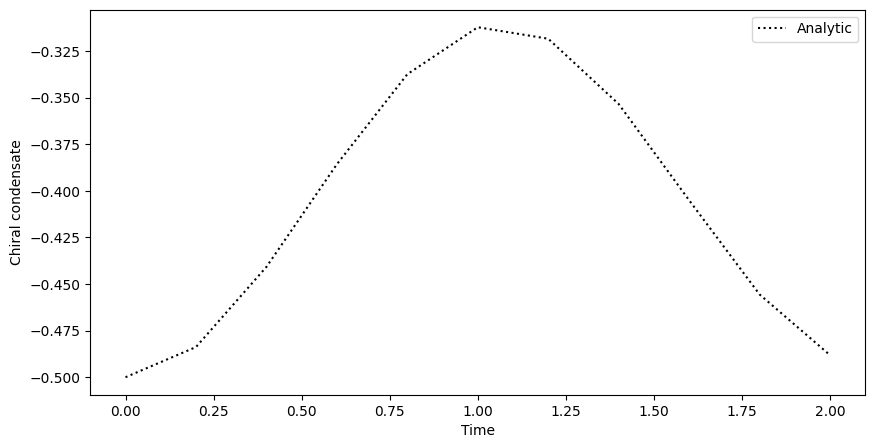

In [13]:
plt.figure(figsize=(10,5))
plt.plot(time_step_list_exact, exact_cc_n4_g1, 'k:',label='Analytic')
plt.xlabel('Time')
plt.ylabel('Chiral condensate')
plt.legend()
plt.show()

## Test (plain matrix): HS Gaussian sampling

### HS sampling parameters

In [15]:
xList = [[0.7116705324073784, 1.3081433259693211, -1.235550073225592, -0.15371167042129222, 0.36385020389126044, 0.35326382813264656, -0.32030707202175845, -1.7703150220514026, 1.7940320180951672], [2.717469068765414, -0.06340766522063562, 1.1075052992072951, 0.7985514010900847, 0.6719463092709441, 0.8550501924746035, -0.09892532341923979, -0.8322093451707376, 1.2274104315035348], [1.0720237713681513, 0.18910271445759258, -2.091714800872976, -1.9647007721835987, -0.7425291485581665, 0.5635350510045359, 1.6782510427754722, -0.5893520730800308, -0.6717988576173609], [-2.50655768243655, -1.7261809267140908, 0.3600017948942497, -0.0958876093601265, 2.0577783017893405, 0.28706435047134754, -1.0797113772767044, 0.8624359228311772, -0.03287179490486141], [-0.3719813539696942, -1.1064910851654781, -0.28416163790153814, 0.416242425529012, 0.08068061444464736, 0.38973514958614364, -0.3894507995647213, 0.46116510803606503, -2.0887697298444845], [-0.5905728642458361, -0.37117590633801684, -0.8676725260182834, -1.425727158629366, -0.07217161336708727, -0.8244981105460114, 0.09227852227625412, 0.5379423422223489, -0.29121796714247056], [0.720309660648819, 0.26419342290148556, -1.2391956561234194, 1.4042910031888893, 0.9320193200903745, -0.08025385177041806, 1.482190779645534, 0.8039756571785858, 1.2132251854379659], [-1.1441743475372552, 0.35742615325992155, -0.7861394040209653, -0.12081739791479572, 0.9349437735283456, 0.9248096085499126, -0.7737663532994151, 0.6389947462320403, 0.3854981148896893], [1.036025916035917, -1.7446330256272227, -1.9039913971658164, -0.27313839622516833, -0.8160036130303068, -0.8539133608867, 0.05445360819825442, 0.6549256070263213, 1.3615201733985438], [-0.4306461585001502, 1.3411686041906807, -0.6261823410466376, 0.7205888094381262, 0.5172124115567915, 0.26065110877252584, -0.051434591627981016, -1.0826841215058558, 0.19875291124923578], [-0.9636007716276629, -0.3240166327348737, 0.13354301727494144, 0.4405085654312534, 0.3940731789928238, 1.0210043716028807, 0.25014498791389966, -1.3497952343321589, -0.45278293973134426], [0.46455098152709656, -1.3573456885010486, -1.3832907533261676, 0.9662587130532965, 2.6420205309767, 0.03236252047948275, 0.49777193875089415, -2.01804106591788, -0.4356388412892116], [-0.08377094761921662, 1.3715475753904365, 1.0245939916791513, 0.9425621223677344, 0.40428198385289205, -1.5003610554571818, -0.3026713793716612, -0.32834253590038065, -0.15401453963751477], [0.7357840213552989, -0.3441942404776634, -1.1496237548647144, 0.4007681394039289, 0.06730916519929023, 0.8020990758335598, 1.1593626531991454, 0.0460630091828265, -1.3346553320340497], [0.4702320878170939, 0.16823654642326635, 1.0233092909984949, -1.7997072164754844, 1.0477488143707703, 2.9937593708540335, -1.0051572955218457, 2.0449367915311236, -0.5066166545823834], [-0.8625873425724001, 1.279274161954429, 0.9773254871925708, 0.9337729844792427, -0.946780293261186, -0.481072776702324, -0.44471101961523846, 0.12444736372275991, 0.5615660969426816], [-0.6324374174472258, 1.2312742156872767, -0.651430610101955, 0.05058828838532829, 1.4343644535186773, 0.276198135554316, 1.244135025983497, 1.1722459244560115, -0.21036273116785273], [-0.28091473266323785, 1.064922039237805, 0.44298329268543324, -0.017282796784043257, -0.7390476179030518, -1.2062827314818279, 0.1516969603098738, 2.061553537630296, 0.12496186015622912], [0.4650160477295204, -1.3428098813102038, 0.6388836112993892, -1.196294604383758, -0.021729188548316597, 1.056321955001925, 0.08668184064514721, -1.0459074879913262, 0.5240674659525009], [0.06498646174175544, 0.9552424845174468, 0.5602593401251585, -0.685107934642685, -1.238397527178548, 1.863690813599402, 0.9020301094152567, 0.40692719687767764, -1.9703730718013808], [-0.3284123515305428, -0.34276157340620234, -0.5464400127330213, -1.007436927401388, 1.307328734299264, -1.5923251549589739, 1.1655097261583083, 0.7479369025606422, -1.4733894941295784], [1.153716365482754, -0.10228174820574334, 1.5344194989538051, -0.194922103362462, 0.5009278519129363, -1.2229505976361523, -0.35010063398116736, -0.3696182090406815, -0.39374002906928046], [-0.368186234127634, -0.3678374320693102, 0.10860200621614881, 1.5647042774024202, -0.40105348294530335, -0.6407334228889998, 0.11062062427914365, -1.3442987059043674, -0.037752801161669285], [0.43315361864899754, 0.18661532268116612, 1.1549906425460723, 0.5133754881873716, 0.5322579297250318, -0.5375732387530596, -0.27089249973342644, -1.7555708887462695, -1.6308493850872827], [1.4468981900851239, 0.10811626658627703, 1.1768970613554643, -2.7724973501676358, -0.44155705951791724, 1.2779637619215554, 1.4043954637147844, 0.5459290664273261, 0.10035443009136376], [1.6100928078130343, 0.44469633130696223, -0.5737931631667996, -0.2796794164689026, -0.3774789139657677, 0.41484684646002057, 0.07585000797697646, -0.08115542002146207, 1.1483536685056637], [0.4591828841260904, -0.7438640516766108, 0.583977645340023, 1.4384873102659599, 0.5976913409619808, -0.138555984325332, 0.6118320773789002, -0.48055188356173156, 0.28050134552438805], [0.13725062545032932, 0.862635910677959, -0.4041333568384646, -0.20094372610952746, -2.9813609728767925, 0.279305683534236, 0.4846496954623088, -0.12017698099146261, -0.4684122645494343], [-1.1534976747116605, 0.5316392766923589, -2.1385403178878626, -0.20000598044627507, -0.8037193455448781, -0.5199478015068923, 0.7191453136328649, -0.4826121823183683, 1.5495429603050763], [0.6986793570295254, 1.0661889823398831, -0.5080559909014479, -0.9630983555779872, 1.5705185607889756, 0.7524381411317336, -0.7947345280913239, -1.2480569320160413, 0.20403572855650695], [0.15452780014939815, 1.1224772972767711, 0.3418287598527767, -0.5545519612825353, -0.054459345309814125, -1.2374769345707544, -0.6049772930471029, -0.7038266490084729, 0.36740128600756805], [-0.09625633048788498, -1.0861888425189052, -2.0424188296307837, 0.20353008507332174, 0.6943752537175393, -0.9125645442978406, 1.8961515737358225, 2.119314464675294, 0.032048903821052306], [0.8391717110466207, 1.61846194116805, -1.3986985434393073, -1.3372946858890213, -0.375216119352614, 0.2876031773613935, -1.4113691067602439, -0.6219775138646908, 0.8559067505135006], [-0.585280092947569, 0.18447584763644087, -0.6368329242317398, 1.3657876651511522, -0.3105562223503902, -0.6022535687341577, 0.8738953274243233, -0.34433159621810266, -0.01848625183928625], [0.19110406176187955, -0.07244560060847274, -0.19654889202983256, 0.7359415131431702, 0.5272460214559883, 0.31583421774874826, -0.6929250729462476, 0.5954482889347867, 0.9199661492835378], [0.692660676484468, 0.026092018021280215, 1.0863203902372958, 0.7664022831831635, 0.06924494025225456, 0.6537172913117825, 0.9693482131633812, 0.22393989707328124, 0.5150830885753466], [0.019151812358911165, 0.38273436898272795, 0.3585109140376272, 1.253579053485965, -1.3294985425856125, -0.798917713305046, 1.2642435486625343, -1.7787120535287748, 0.44656588527621127], [-0.11865569407317852, 1.1179417202478137, 0.2556677959712231, 0.97131369423754, 0.06196671675264215, -1.1938376701605167, -0.754537954364582, -1.8580595379308833, -0.802005529328722], [1.9803689485660891, 2.7326068184878154, 0.14514145224345779, -0.07760410832540776, -1.4714279936458674, 0.026082841288396497, -0.2808750015001175, 0.6318446312097229, 0.9857645430753684], [0.09462620411305342, 0.09529839017304827, 0.4784260872424225, -0.5734423754056174, -0.7857191625400761, 0.6766114183167966, -0.48444123714440085, 0.5596311064706391, 0.01653948728638069], [0.5644306857828641, -1.130397273285831, -0.5637768842084326, -0.7324217813447322, -1.3753377144641528, -0.4913455090599677, 0.4479711183389563, 0.44576944095563686, -1.560979425821748], [0.2684508807532087, 0.9847096736385085, -1.8452658026943025, -1.6615018200536973, 0.3658916322350867, -0.9887144957331733, -1.269912864361596, -0.26504386934157487, 1.0235271564141126], [-0.5918140252898333, 0.0361102526887443, -1.128746941665122, 1.0685957445025565, -1.4680982022737108, 0.033614639006606634, -0.4341463581881019, 1.784307111644903, -0.27073223171884175], [0.5856999513049718, -0.527533657525556, -0.3780703789725035, 0.9010904088851284, 0.0812671959383697, -0.8998289557675114, 0.6878559640862625, 0.09191646653275666, 0.31826146787391824], [0.2750060391255872, -1.758287692679369, -0.6547205460792485, -1.114065054229422, 0.5876324632730453, 0.062333425717857355, 1.5341013493309765, -0.6384422637979806, -1.1652626423647816], [2.6306924857116467, 0.08794743015234188, 1.543006434620589, -0.1947152543160771, -0.005792478634726267, 0.948245898866483, -1.189651132446043, -0.9228128057159478, 0.9892946709339122], [0.1800728532602735, 0.2783789206994704, -0.596528878808711, 1.2038202436919774, -0.8642036211387206, -0.46580380262681104, 0.09337235174876857, 2.3600295102039794, 2.3609753186823026], [-1.2974194247605877, 0.7745970187698641, -0.9106917344199327, 2.1856090433275095, 0.3262051545800182, 2.604726132673214, -2.1173676814565456, -0.6839744657751597, 0.13432432661740112], [-1.042977373593679, -1.2401491772184365, -2.0934778122879454, 0.7948661518229685, -0.6646093264548456, -1.6360281494900237, 1.328155944028088, -2.0912901762600775, -2.0979754378699833], [1.0461209995929626, 0.05412574886937998, 0.37469854939834557, 1.1662476747490724, -1.2515158834917264, 0.16669116274667953, 1.0248530150047968, -0.3947603010634195, -0.7443982521369481], [-0.9644483983645273, -0.0848085134099548, 1.548908454714134, 0.9951063748634097, -1.316582062804225, -0.4959719412669881, -0.7189461723239976, -1.7525463021533967, -0.21271857392481153], [-1.0057237884804788, 0.10388796684149267, 0.8113047150764251, 0.4119129118966359, -0.11902387706290264, 1.1527722519758583, -1.428672012616506, 0.3807534848792154, 0.28516873108384116], [-0.1871315433661897, 0.4222098790487359, -0.13357305945543216, 0.09665787072811553, -1.2086887752020228, -0.3429754113505709, 0.41503404208250055, -2.5068584205639377, 1.1171199588417595], [-1.7595989593878614, 1.2575489364886205, 0.33703876348797346, -1.5197016477725287, 0.06789666477383577, 0.5734797421061338, -1.127681926156585, 0.27513822925642484, -0.14497738559210577], [0.9395501063331031, 2.462377675632604, 0.5269162802909658, -1.1690658775852307, 0.7650761839834229, 0.0211342508778667, -1.0898621947577432, -1.3228732016395408, -0.19662338959407377], [-1.154179089307427, -0.6766241756195248, 1.1122424867580472, 0.41181323191001096, -1.3612675363556686, 2.8355661254761944, 1.4826776185657864, 1.791047112781437, -0.9037813487610011], [0.12769972260941972, -0.5995114137710795, -0.22898305969446844, -0.08514998642199745, -0.8979642973470917, -1.233362873449522, -0.3566330584853223, 0.49638946262694683, 0.09292141673765446], [-0.4912653658547368, 2.11051699939555, -0.49560358283968825, -1.026884137129207, 1.7877221856385508, -0.12039210924372658, -0.9560538448554816, -0.014141163443727877, -0.7301135717499362], [-1.0055393210885175, -0.12835457747900303, 0.5513156922231718, -0.32384046481085543, 0.06010589516369127, 0.22526366452121008, -2.133532979985193, 0.3215434658729714, -0.4077216973999746], [0.8593444266338159, -0.12989168104703147, -0.6380184196654934, 0.5024137268945452, -1.4280097482897276, 1.421805188110565, 0.4142527168205565, 0.1724975311009695, -0.16547257853889197], [-0.25635796100172586, 0.5784893420999788, -0.7787522838767736, 0.05194917825943828, 0.4211630655568764, -0.20362471847665042, 0.8464424590136856, 0.28954912416470524, 2.1794318361959073], [-0.8219224988464713, 0.016382865251513588, 0.7431328494441071, -1.0881599234906747, 1.7268272781860412, 0.09613404528299971, 0.5409739966943801, -0.15263195009766065, -0.8877328440913066], [0.021495076366492026, -0.21889169252315888, -0.6517895432618647, 1.012118532875937, -0.7155598799995108, -1.0410006160505512, 0.040595822519979036, 1.1729096082489738, -0.2928865026269203], [1.3632500979469593, 0.42070623601809026, 0.9330310485991294, -0.07207271493393284, -1.4374649415371878, 0.06165674901063505, 0.13853928552890293, 0.6685300122702781, -0.570541252636739], [0.013600032021197568, -1.5927235631332237, 0.13728358889674744, -1.7473348221261316, -0.6604497463719577, 1.2626878283325178, 0.4295433767219282, -0.8652796636468362, -0.19702080775034914], [-0.08650334351016448, -0.4512224995562513, 0.7954590358611646, -0.2459205711755559, 0.9233257110410769, 0.3063813952774723, -0.27483221336330704, 0.7905119531638931, 0.3916486048193769], [0.48661533354676045, 0.9868604539160837, -1.2488155479699645, 1.4502033597578359, -0.5385643369978824, 0.12182910961488563, 1.4079845184662176, -2.0027029716875413, -0.6279797548929275], [0.461022511154343, -0.26826771266378724, -0.3683810497626824, 1.4219041775831076, -2.0855172641622786, 0.8842976981515765, -1.5184586908363882, 2.488503930788333, 1.8723011562422072], [1.30613107487071, -0.010531104323736948, 0.537930062952824, 0.6639909618701314, 0.07400832431195038, -0.40937447641390107, -0.686507196096502, 0.6609206331673416, -1.8807216022200213], [-1.4752939552517772, -0.10412817721037669, 0.3003000442813021, 1.2585322328870456, 2.0608907966336623, 2.1018635095286395, 0.8750440945617595, -0.015814838953031315, -0.13715437179009363], [0.4911797397996973, 1.2499872724390482, 0.8491079126199977, -0.19977340833054189, -0.9166716783281964, 0.46472553331588684, 1.7189184784842482, -0.007675347257544726, 1.3013137184545311], [-2.2804848397208435, 0.04004732512435727, -0.6574765781370973, 0.6855617024164569, -0.30596625498770225, -0.07553403248340662, 1.0056729801210957, 1.7471170408478378, -1.2947841954105948], [0.3674656215337213, 1.2394998012758986, -0.33809152829246547, -0.8238363185980052, -0.009601998583699754, -0.5261951586040795, 0.8913820861329499, -0.28141651415032026, -0.8131183908306486], [1.5176116126562178, 0.33475146107091486, -0.390464028559039, 0.032869138761968855, 1.2264748198563926, -0.3672870836872024, 0.9367513778616534, 1.018510299426719, 0.22451781246393018], [-0.10569620482825184, -0.7895997332627581, -0.8864391059528418, -0.8571703287630211, -0.7197444868443437, 1.5500131211022974, -1.6980062554958641, 0.7515256581474755, -0.9752472844237285], [1.8662803215980281, 1.1825759222235224, -0.19248210046721573, 0.80366615917516, 0.8402577911262286, -0.23574487788688442, 1.3117477736621592, -0.882372843393071, 0.14498311182081497], [0.1155095285099984, -0.1600385231290034, -0.012694857104053206, 0.5441800078549477, 0.2604821909785925, 1.4042165537766893, -0.9443013681302533, -0.7815614890741823, -1.4845363792141515], [0.3997030112165937, -0.8624939537160855, -0.8742120089544367, 0.9735661362048676, 1.9636919405241857, -1.131527003218039, 0.917464411988163, 1.092282674812847, -0.6096048897919248], [0.926101117601467, 0.9103313654633279, 0.8047516716492371, -0.4420728229872505, -1.4770197096433966, 0.711881802110724, -0.776962125344287, 0.18826766296656594, 1.1536836969248487], [-0.6022197052775015, 0.8240313496270786, 1.3500002739492403, -0.9571360126194013, 0.4363287453669168, 0.17447579807012895, -0.24064936578534177, -0.32333253370736725, 0.3064777334749816], [0.6089240580893027, -1.2410696167884339, 0.9115018489481945, -0.033580835333935195, 2.141840988903593, 0.1608678590711607, 0.5868423482541412, 0.9939162945090695, -0.2886613903454275], [-0.18063375312894872, -2.2773274107089923, -1.0439934837758063, -0.42443596285774116, 1.0271078412378634, -0.1151903664765234, -1.5381523231898804, 0.22642883718630552, 0.05775256260574441], [-1.2967146430596188, -0.5429298956633868, -0.3607331189094284, -0.1544865461811871, -0.12651380453229197, -0.20265997804270328, -1.2266147937000402, 0.7702080751345012, -1.2776029561363753], [-1.064295780160199, -0.75403137014957, 0.5270925467757631, -1.2941869064043015, -0.9831138627700443, -0.31672921708630747, 0.9021577894218715, -0.006468306367839968, 0.6904495188146474], [0.23589645894249542, 0.9073206214481009, 0.28481138418351737, -1.3574378506929017, 0.866330989729629, -1.454887135703381, -1.5586081285559379, -0.8336321859508773, -0.3192260902396637], [-1.472199574803592, -2.0564093004253126, -0.8824141401342199, -0.0817876375275668, -2.367653797162531, 2.7146072014405966, -0.6168634928161245, -0.059844363590078456, 0.5134255590399756], [0.8570983944347562, -1.6367313025086139, -1.3720846536559688, -0.21524518058201403, -0.37521838333283447, -0.8082511481047508, -0.7716117164671434, 0.013294285536525442, -0.17135516203709872], [0.2304135535087254, -0.059440051964155693, -1.9324555752492822, 0.9551671561443213, -0.7375867826967999, -1.02947791707709, -0.038763554257379804, 0.007640145508715443, 1.6098740393306905], [0.2634873729007278, 1.1322870898396333, 0.2149581808099043, 0.8908473505984189, 0.10420370268683904, -0.3121473505060536, 0.8111110142940594, -2.055092522706978, 0.3529254885504099], [0.8415206742094632, -0.6212229309816056, 0.3675166090932605, 0.2132405124627842, -2.3493535082456853, 0.15700142609370074, 0.7523332936083611, -1.468651334388701, -0.15179335779276384], [-0.895715587518745, -1.129288106847434, -0.6723461992315369, -2.4198811033233874, -0.34060159776942533, 0.6304265940598446, 0.911704239167644, -1.1332377962288738, 0.5821616082036776], [-0.2820592508948593, -1.4274290617583976, 0.5677172503623065, 1.3952999341464993, 1.0894953367199167, -1.3327401754092658, 0.7646444910522971, 0.5207420503855029, -0.05262226699819635], [-2.079303240362374, 0.7680576577364214, 0.40161729375967936, -0.6037147934807177, -0.6197310511090954, 1.366260083027503, 0.45803382710272794, 0.34625316732999895, 0.8118930980904805], [-0.706806879566222, -0.5621803088334105, -0.19907720883352564, -2.7232015201917434, -1.0408364276366053, -0.7642875001406826, -0.9382268177094019, 0.7713367177370523, 0.4849741505501101], [-1.2710178512407408, -0.16503599741550842, 2.763607016342291, 1.2360026091210308, 0.8957260828660538, -2.181899059533131, 0.6383637661996985, 1.575716043368403, -0.9110304242889867], [0.37022625219902017, -2.570981185697858, -0.09929615103262744, 0.6177945241077749, -1.1975593295910079, -0.014328041859808356, 0.11710188302167175, 0.9397529991089819, 0.7806444675884836], [1.227572862036419, -0.30920887517017376, -1.5775840039985896, -2.1760806818467464, 1.1044479238577258, 0.21676126515846422, -0.5274702138075914, -0.5492289968476776, -1.1587053792372282], [-0.10186277484138462, -0.20080640913366496, 1.9690903667596007, -0.30771896078770195, 1.0209410633027656, -1.3154369802787225, 0.9637428389260991, -0.055540327296398004, 0.6561986390574225], [0.7524617350243532, 0.5351288500388791, -0.7014289753299394, 0.07658825251039283, 1.7444365422550585, -0.07682160643217842, 0.8827993555450967, -0.5960008068460595, 0.825917470364098], [-1.9792122372977856, 0.3915729696708293, -1.8540540016136662, -1.0095151041471329, -0.6595236318413764, 0.8550676138859892, 0.8562128554369324, -0.8854801139268531, 1.7838280824717367], [1.2402697746141065, 0.7699613709903261, 0.46827908739812435, -0.7198628525439226, -0.14949002612078222, 0.076929093765602, -2.6904023225162903, 0.3353109407460466, -0.2778514088321118], [-1.065236103820897, 0.5172737470838453, -0.8238162250773496, -1.0000744181088561, -0.09471621915303734, 1.2931704051937587, -0.13896772564900947, -0.8140438133119577, 0.24485595391989368], [0.5451696987716643, 0.7831182751859537, 2.0415874660062, -0.2665766566183945, -0.8731096001225591, 0.8668992425563076, 0.8688280880528932, -0.2915049644118054, 0.3937993901360749], [-0.1949635189568845, 0.1900220414041841, 0.0650136502794383, -0.5240276102098405, -0.14209416511769754, 0.7623227624232066, 0.8272351583049147, 0.9998244258273544, 0.6502839623847412], [1.8407551552052512, 0.042772167363100896, -0.6320919827723405, 0.6648738662071065, -0.7828970664169551, -0.6437154211386031, -0.19115549864504325, 0.39866006128171966, -0.5618929316566008], [0.744136551804292, 0.368789319476141, -0.2052689504351781, 0.9303809393565582, -0.495267076792632, 1.4668151827835727, 0.28773161918928625, -0.3473133196966838, -1.2704487993173041], [-0.3771548356122831, 1.1728179017993046, 0.7510159610575404, -0.3511767909084042, -0.32884041735208475, 0.04061448639345801, 0.496723047221528, 3.169656622059007, 0.504073098941556], [0.17952691158012463, -1.2452251804623786, 1.3744936097199794, 2.203766457205187, 1.0003461565872345, -0.18930219545391136, -1.0216066940512933, 0.41416003557368, -0.1720160356396465], [0.18072764672062785, 0.7040038090888016, -0.8384502946382143, 1.599247226073664, 0.06065167351865152, 0.3455181257068018, -0.1675507715744187, 0.8828268584732609, 0.5868289853123991], [0.06680485444945845, -0.6947094139193536, 0.2126601888301548, 0.8921972486536318, -1.0761611387408572, -0.165395660299069, 0.41480493550185416, -0.16610389016420066, -0.32342722450598593], [-0.9301481827003705, 0.7755518194403896, -0.4733505438246089, 1.178358056679774, 0.7110067966430269, -0.7845569018437993, 0.9230719460607945, -0.47666110023978286, -1.9276296954134662], [-1.4074373595204788, 0.16314453058140999, 1.1599230775218297, -1.0144802988015813, -1.4229967798579373, -0.8367872409629412, 2.8359942787765506, -1.6286316149052593, 0.10920571555786941], [1.2536178755217224, 0.5341172582188886, 0.08580283955430523, 0.5702379649963761, 0.43374732930273047, -0.6909312553564009, -0.020192037425744415, -1.714728728927272, -0.07649683121464497], [0.3298942669845463, -0.14837183211885668, -1.1154508307692501, -0.05580427247276724, -0.42053168629962057, 0.34609960444239196, 1.9359477004821575, 0.8707487584815208, -0.5369824870263302], [-1.108145276688425, 0.09753593836959443, 0.9204849875881785, -0.7183460063907043, -2.192495980977051, -0.89855632967461, 0.8291014055233215, -1.2656592770334167, -2.9440454620423835], [0.08948166442546399, -0.3385835980861816, 0.5390976651101027, -0.5608340027959454, -0.4944652148986391, -0.7258211566219336, 0.8502983230683006, -0.5670478675058125, 0.933785403371473], [-1.2288325225246983, 0.4112348103574542, -0.8725348782689242, -0.841118586122698, 0.05040467641397861, -0.9593479223676611, -0.029495799562839195, -0.23214783614877169, 1.487963906570824], [-0.27557516757549516, -0.3197512717689553, -2.1151235833772315, -1.3281012873147837, 0.751768252604266, -1.3862538841547036, -0.38405657496840406, -1.2425400135066456, 0.06641216375153888], [1.6801548365837324, -0.2763251013806101, 0.20818000458083524, 1.400633981114379, -1.2086596055130987, -0.8957972140060185, -0.9101266645601775, -0.9459020364960656, 0.5185709963533806], [0.06101657718008355, -1.2977891927130822, -0.6496664281169197, -0.7085676731733813, -0.39528625455755323, 0.9328974195496217, -0.914372838510736, -1.4166199157482857, 0.1618271685998392], [0.4005391567745835, -2.583969800574356, 0.04772996168115232, -0.3033770765358214, -0.334472563052062, -2.426207274166485, 1.03628888869873, -0.1751229199418379, -0.5797295829857192], [-0.3345830643577791, 0.19778272184876758, -0.25015869312091454, 0.19087002816858215, 1.2856483873368192, 0.3291746968665251, 0.7619576819135006, 0.5591058692765167, -0.3933924366627159], [-0.22283880145307502, -0.15240717810289298, -0.16402156561949266, 0.236826690038426, 0.30205158750449973, 0.2359094534372522, -0.2551725575999056, 0.11548783834109036, -0.8811798849103925], [-0.8120226228970261, -1.1521465696602458, 0.12191920320232333, -0.5988562340989715, 1.1319121424534329, -1.2199282172970343, -0.36527818280926494, -1.3582262533067735, 0.32339945391826647], [-0.08676512989627912, -0.5139289451560196, 0.006392555552835155, 0.5364369270277153, 0.24447594084585073, -1.1662964744835522, -0.3378118933657909, 1.0867256268291456, 0.03381732804753209], [0.8601270016614484, 0.07013125864809544, -1.649739809138933, 0.5581755219123029, -0.5805071329947724, 1.3851558989317572, -0.0018930923715919183, 0.07008300677013722, 0.8150478941157904], [-0.08373962274466741, -0.698585713600524, 1.5885796130833787, 1.3460334476824194, 0.09395219987157602, 0.042979956028284125, -0.5956466507680315, -0.45100176230650874, -2.0991757428957687], [-1.3776739359689971, -1.069785065000585, 0.2278637636497797, 0.6649472254877511, 0.6924399269132131, -0.7593310992008011, 1.1216737192723851, 1.8999828780865147, -0.26734327028265276], [0.02207910452905102, -0.49005475258238257, -0.21693635522083496, 0.3505002343660071, 0.4176364753686413, 0.7265381818842372, -1.5638309526736294, 0.9214520795831445, 0.5376478393847023], [0.480289475311401, -0.8239042569065036, 0.0059324529230712, 0.14754994925355133, 0.1542968591844939, 1.2706954020260388, 1.478311741208738, -2.022480964479157, 0.6210667256773124], [-0.6689646271705613, 0.30232818140238576, -0.6559562495568046, -1.6402167531076235, -0.0005905914160290268, 2.280767039493893, -0.16172271331515314, -1.270934972694816, -0.9168477368509507], [-0.21402997101794125, 0.49573863921502426, 3.290473122646751, -1.5604355834262618, -0.5456765551224828, -2.652465926040536, -0.18980780360541633, 0.6265212584653034, -0.031654622868038364], [-0.1133673008190867, -1.9355060093600827, 0.28531152254321196, -0.32805243467861006, 0.10861815239326879, -2.6968933854512755, 0.5972803002618355, -1.7167092401049902, 1.3610327223376646], [0.3943065537737883, 0.3371770340318154, 0.18469136346912135, -1.9983203784882746, -1.1672623440297152, 1.3263513672362854, -0.33368172501537063, 0.6853103518211423, 0.503592964124503], [-0.9206298651362502, 0.9480673480586335, 1.056579493158962, 1.9456384982676795, -0.5158268956333558, 0.19121574135647, 1.6048542094569802, -0.42379357065480877, -0.8240974902596416], [0.20059785769540206, 0.488554781845561, 0.4077206923242881, -1.2617667129975794, -0.01521803875310281, -0.7048557144865228, -0.38953439144342694, 1.434643460500235, -0.2599166946232471], [0.6937589930911864, -1.037570080806703, 0.1585686160924171, -0.20413002721607898, -0.8478302876829099, -0.12350759427017169, -2.137617685519196, -0.9653436213452945, -0.7277087264771182], [-0.012108336101832502, 0.06761668566358246, 0.794390751794586, 0.4276467681336378, 0.17677441214033107, 0.06945644729500208, -0.18348874549557928, 0.2639001241217131, -0.8270228475679061], [1.0646135579534717, 0.46286207150559106, -0.8461418861335547, -1.6623393514345102, 0.10157775911112948, -2.1672130735864794, 0.6223021195876997, 0.14181790931862728, -0.1352943690084339], [0.31485021028634863, -1.5147276982955828, 0.05416507842204654, 1.1075888975553692, -0.706884031832948, -1.4312695557656407, 1.0755682834709952, 0.27477123445108603, 1.856393100880041], [-0.12994058680085888, -0.9734892613051827, -0.31501426875401095, 1.1719943874333927, 0.2329630837756104, -2.122299373570296, 0.5211234181251232, 0.0004827339231839027, 0.17858823242606298], [0.3138142440100158, 0.19745929676873716, 1.1375263205316877, -2.6566927793979183, 0.953210083815801, -0.19067354595902813, -0.19651626816370274, -0.11350670006680934, -1.7387041889982051], [1.7079970837885992, -0.27853040632823084, -0.709815977708376, -0.3090646216261655, -0.06953950306644735, 0.8259085951414171, 0.16150165213785092, 0.8496116515473583, -0.48613901451680325], [-0.5470305022367948, 0.02993617598149908, -0.8394153260359104, 0.2318889963771377, 0.4208701801269686, -0.8826524196682642, -0.7190915356130811, 0.8438330083255307, -0.5554940273521546], [1.363643715390562, -0.26583467135961597, -1.1357053001107504, 0.9402812108773837, 0.4801122137634545, 0.047995183716094604, 0.14472924878343418, -0.4071165588758001, 0.008031720840237339], [0.760176748697697, -0.4027231971611246, -1.2720159435647913, 0.056002132867401466, 0.46343876619828, -0.2664855004963479, 0.03906718491955071, -1.8630582865281036, 0.9239937012232821], [-1.3739698439010566, -1.5836586582756957, 1.9171309766109528, -1.0234884024065978, -0.8621330659175076, -0.28602589322883926, 0.7330074384732528, 1.2933033677010635, -0.5837738186252109], [-0.3654416549247786, -0.9141359375088252, 0.6370838762085754, -0.8560790941655659, 1.4241661576266704, -0.3986595664126494, 0.862113839413142, -0.5880023644750506, 0.4893163734489048], [-0.4426053694776419, -0.6562338350527096, -0.138642054235562, -0.1616902225758031, 1.3613549524635047, 0.6809959426875382, -0.741658559823249, -0.19302116545712872, -0.7171650433491283], [-0.16514634103942422, 0.5791277439435998, -0.9007683127278568, -0.24168954846899104, -0.06339946153695472, 1.4868341766231519, -1.1705964595749931, -0.732958364124424, -0.061419084425185275], [-1.1554127775815262, 0.17355105226410072, -0.3157212224023923, -0.6985490053251815, 0.1519160832616551, 0.35242607137703696, -1.584818537413701, -0.26318379570910644, -0.424563218885242], [-0.40776677326887073, -1.7411308471783777, -0.9200186566228634, 1.0326667992155183, -0.7811760762593288, 0.1778281533998698, 0.16094726889194086, 0.3127520683864932, -0.742263178421074], [1.4813526049796664, 0.6893556667371354, 0.34069852801484307, -0.11345567319266542, -2.038371660215125, 0.9293662854483671, 0.7488257993415189, -0.10199496999554866, -0.1737155781865174], [0.3924117666392652, -0.6195735014074116, 1.782516941298013, 0.34249422318049266, 1.1847330921080683, -1.463039416931616, -0.6393291741412329, -0.6225108260686744, 0.7359257619964836], [-2.8038958445841744, 0.7376615813823825, -0.01400586146336989, -2.0656462922916594, 0.21063530520006965, 0.0630314372885605, 0.74212920469496, 0.19763571914798175, -0.8917675997190435], [0.7227442581418725, -1.2447712957541972, -1.3939164717342505, 0.17131316384738496, 1.2078874883879729, -0.15797820705782806, -0.8386988041080944, 0.9035994347323312, -0.08446501935325196], [0.15818272479188084, -0.06708484049968923, -0.19472394224770212, -1.8446039721792389, -1.3842353319705971, 3.1554536572489305, -0.6906283077778913, -1.6942103354220825, 0.39061118898808256], [-0.9902325913748055, 0.7385884984930419, -0.3212007678823236, 0.10383067177853901, -1.1226125833387675, 1.6791332559625012, -0.464048080787131, -0.7139966992156972, 1.3949931105502797], [0.2929644927021529, -0.3474761328523954, 0.33357249136481676, 0.6484003208771071, -0.7899827996321608, 0.11933185268449141, -0.6297147887641155, -0.5466853220544678, -0.2646170299319592], [-0.32811875752154274, 0.05958699157603148, -0.313291567797397, -0.1806536057949891, -0.09431055298120414, -0.16825077655989149, 0.44518792596844703, -0.6491435646686395, 1.403595655855212], [0.6487743718135796, 0.009414708092091542, -1.1628847591548161, -0.5488234956276776, 1.09604791183293, -0.267032600058552, 1.296062889939189, 0.2778604754605591, 0.15733287293489173], [0.44296388027503175, -0.8542326059638301, 1.2325963965200015, 1.9049060032837526, -0.06729467583805325, -1.1560206344347417, -1.4117200165759722, -1.419349439723833, -0.489130945039299], [-0.4819935553646812, 2.1855831057272064, 0.7543970705428976, 0.4496929565944679, -0.11178685449837657, 0.9177500495394898, 0.16428373512961142, 2.2404893158178583, -0.9931797539170708], [-1.003097973308528, 0.8282945339192429, 0.18855009898779485, 1.7636017740420598, -1.4887703678238224, 0.9837024573299024, -0.13262621014774195, -1.1676084601196102, -0.9850191519967433], [-0.6176010399648437, -0.7390783040728424, 0.05476414437000627, 0.68360830610927, -0.8737967204011132, 1.4904468941449485, 0.5214874200630271, 1.589065779355408, 0.19964639475570736], [0.16857491538592945, 0.1814862093393786, 0.009239688449461566, 0.5298411094943555, 1.1182267790415283, -0.19976716305405678, -0.8654128955704042, -0.8225548267443027, -0.5738837637643088], [-0.30457072346037195, -0.6124234491843371, 0.055421167661394245, 0.009526981317222153, 0.057789071981273754, -2.287198487233488, -2.4123459507291876, 0.20747353381454323, 2.4411395754755842], [-0.7665412475942769, 0.5088803467703689, 0.9334258179222625, 0.5128616558981799, 0.7420296701417262, -0.5777090828686924, -0.02739723231605824, -0.03389875906739919, 0.6787227204111851], [1.3655152891530793, 1.9589258638163751, -0.882290919901521, 0.33519071603577755, 1.4464919509209024, -0.673289802512648, -0.4329106005277499, 0.12105790518922767, 0.5710885417696137], [1.2540384743812183, 0.9003494257271949, 1.7507508133287089, 2.7072386121467336, -0.2530604142626877, -0.34056689449844163, 0.6663409792157944, -0.15875625869628054, -0.5036779295218876], [1.838975631981208, 0.692100324992611, -1.1918842026263747, 1.9302130770620476, -0.6630328063059925, 1.1205307797378576, 0.2765271810287684, 1.2188351618053785, 1.850402970829914], [-0.6393737192352399, -0.6963786650039039, 3.3144935600880627, 1.6368409747285204, 0.32560113858761897, 0.033755189865200944, -2.553213825574392, 0.533085373313116, 0.30539718932363613], [-0.9475330494235655, -0.6675314789316702, -1.5527445840964855, 1.2873540873314833, -0.24156384977450696, -1.3940631991048285, -0.18447904258934422, -2.0676975724066713, -0.637982813690528], [1.101642403974338, 1.3615932735002154, 0.42941038051456143, -1.6225428981524164, 1.0190167395054082, 0.20816184866774434, -1.2398136654619547, 0.9052407784925784, -1.0454756608782112], [0.6949280150318281, 0.30620541002763174, -2.1954268024351538, 1.3844834107489195, 0.038574373996791145, -1.065390825688009, -1.5658349203002142, -0.5281765202499066, -1.4066176468017992], [-0.2598197411456891, 0.7962478437343796, -0.3246346324910793, -1.0675746396045795, -2.1728551072711078, -0.039832933200195014, -1.1683286305879022, -1.3433953090427069, -0.01282544041983478], [0.010135438932772741, 2.4628650954771367, 0.7404696113855902, 0.2902795109391742, 1.2969731307787264, 0.40396738607140675, -0.7826935638350597, -0.28538811628130045, -0.4550725567789878], [-1.0746467325610076, 0.39102984879944247, 1.2708584504199696, -0.9912600049134996, 0.37512012998228494, 0.853450363540423, -1.8956231387552298, 0.8336087024627314, -0.7336748132138551], [0.5895684318590432, -1.5648012868212033, -0.3488713376417167, 0.34660802248415357, -0.10399665875612919, 1.9931075295242937, -2.3956056818672895, -1.2264029174059699, 1.3607687408965095], [-0.5686081707878324, -1.7069227541910654, -1.5128067552678197, -1.3597553934545201, 1.542712315968449, -1.1686383497667543, 0.4672666158766545, 0.6971744908476493, 0.21555683398813152], [1.4576809541870939, 0.40962939056756303, -0.3858120437100673, -0.3805833675098534, 0.016915596569524103, -0.3332012379376864, -0.0755702197475579, 0.831596657746217, -1.159068640132112], [-0.643923136894881, -0.9188607728056067, 0.9733005712517704, -1.5902037286437793, -0.7316601616392531, -0.2891983926367139, 0.023252413830466757, 0.11000183024049871, 1.1860800916922414], [1.7910036278792745, -1.4794879651372552, 0.948751954960435, 1.6149669976989995, -1.1758567025858588, 0.2837211254474155, -1.309918268126136, -0.4071009757051136, 0.9590590652166091], [-1.958541004472176, 0.7708812060130904, 0.16169256524929976, 0.6543983366071043, -0.5672766044967436, -0.7907622130040425, -1.6311187745394713, -1.8929437418899393, -1.424168675231496], [1.5930370304358878, -0.7088779023290771, -0.8006731892246242, -0.8633586326508236, -1.1764605080124038, 0.41083336741996335, 1.0894260436745018, -0.13771549218443194, 0.6894805497865671], [1.9115120842543065, -0.1551618801727859, -0.8808862298912511, -0.7419455476079797, -0.3288662091756136, 1.7160301373607918, -0.26106423058614175, -0.234555828262783, 0.6576631254083056], [0.7554909606887954, 0.48948206419346424, 1.1930150232800631, 0.27954187972897354, 0.060311750321066095, 0.6309909894195758, 0.5809520684731998, -0.11985442808464301, 0.9236382804354962], [-1.5732645948459725, -0.0577099161476811, -0.33830107424311423, -0.0511553296155141, -1.481405438768852, -0.7522557852291563, -1.270547487613832, 0.5781664910196047, 1.5061218092883775], [0.148239247964454, -0.6097927350710901, -0.7894653862112666, -0.47358670765726496, -1.8059354427781118, -0.7019562943743732, -1.3028971431728518, -0.04548397469148215, 0.3657119472057662], [-0.05291865944932074, 1.2077326198525256, 0.634827845829829, 0.5862985503648879, -0.7626952982338812, 0.9710243163647176, -0.7491383431254218, 0.0049734219366828, 0.7839724723796551], [0.2541117194232659, 0.7707502066575155, 0.022649549509407035, -0.4156224540084124, -0.9597643289857658, -0.28394051047347385, 0.14929271501485833, 0.754823594249673, -0.5293373684411468], [0.27370456495531575, 0.41459054120500144, 0.9207962592418328, 1.2555798467762953, 0.682467938246845, -0.1851423405610383, -1.4828111491483618, -0.4923896507833725, 0.3222854245747002], [1.3395632013660006, -0.9868731429269082, -0.3341201874604475, 0.3776624264820096, -0.9525068490172022, 0.9921864731667025, 0.4094670849073122, 0.32848261170621984, 0.855741859168066], [-0.40738205711640746, 0.36855724198924583, 0.6204989483741421, -0.22968033627240447, -0.08940256191590841, -1.9630342851720535, 1.026426556106992, -0.27218241891134426, -0.947167667695047], [0.11503480912998673, 0.7629464546285496, 0.8340930575078552, 0.6381825857995282, 0.18538264766740245, -1.2579733232655306, 0.4332592164574986, 0.05599873976058193, 0.30057605687903094], [0.09790862211645744, -0.935845506833839, -1.8123020902201539, -0.2110413412062197, -0.16282107152838987, 1.888198079276321, -0.045016989540830096, 0.6776229529802947, -1.7586966787084346], [1.689799550742736, -0.20419523344016297, -0.13340401068658683, -0.12441145069587083, 0.009494441803892324, -0.3433363856045982, 0.2630669528475948, 0.6301429215658634, 0.18545010568391024], [0.9467037240559555, 0.20725942421218244, 0.8382911781033741, 0.4256323048090988, -0.9383576230244669, 0.09986403968027052, -1.3817730319274384, 0.434481872201383, -0.6071882101272845], [1.0559206949735624, -1.1231083097222567, 2.015813439482756, -0.4716342208787545, -0.2575046062459462, -0.1489956222432571, -0.3745289146350781, 0.8249895383352452, 0.9505461360788107], [-1.642362524121598, 0.06532847593379713, 0.01954013966503097, -0.11584372602594455, -0.3007987640831542, -1.0613913593246218, -0.24305746723331728, -0.5464524213709925, 1.863861744903637], [0.21251343293425168, 0.8705065175430113, -1.450114014396271, -1.103198108055126, 0.45235619692504386, -1.4888561578897679, -1.0294224894789938, 3.1643982904509866, 0.5377461306361796], [1.5425729068272191, -0.25980769703068074, -0.6185426959955735, -1.010515338296624, -2.1801414260373733, 0.6601057456219783, -0.01889517025424301, 0.8116574718499466, -0.2744543730614031], [0.9319096554083203, 0.3860959009335198, -2.0409324148415204, 0.11717427114319963, -0.5792864758064358, -0.15463074266171709, 0.44046866715692334, 0.3262045768693566, -0.3694945609373896], [0.4447005008793077, 0.3453839807975665, -0.5268207844306998, -0.9286214740287857, 0.5587731124874301, 0.4390223221906734, 0.027284815033648182, 0.15168488552078993, -1.7806569317066088], [-0.3739861097661083, 0.11984917768242366, -0.3753881737817755, -0.6527112087343785, -0.9002846050645241, -1.6035587600115964, 0.7376026430103192, 0.9126898816364196, 0.04183325046407068], [0.7525548218652688, 0.4090032434985049, -2.829661600234969, -0.024912371141871573, 0.4686672775595779, -0.7577620987927061, 1.1760263390127237, 0.14241814044300583, -1.0931881544147783], [-0.4713840969845282, -0.7284645114064432, 0.0661793276738638, -0.0099679185904718, 0.11642695255008048, 1.4872689015173333, 0.6618439908739168, -0.6636999711719622, 0.4269414900710236], [1.2067293949887004, 0.885477723053022, 0.13382292051750244, -1.5117161506178525, 1.2017260044174916, -2.5170827432722787, 1.1325430324591341, -0.09132866539955717, 0.20829694664805007], [-1.6260947173585911, 0.09872936947657691, -1.430362458801035, 1.5929510486946856, 0.3247906067079166, -1.5125805677982698, -1.149839992629655, -0.02122347601440956, -0.20084458614281056], [-2.8804084984331144, -0.3784106637032397, 0.7011894590963552, -0.34285698735399367, -1.2425428687056705, 0.8300623213423208, 0.5553855046429368, -2.1154044476549148, 0.01562949286907028], [0.6282228534545419, -1.7931067915389671, 0.3012782867538262, 1.3648899368360252, 0.6887179662007444, 0.692322480594163, 3.0922644386613993, -1.332948712603396, 0.09603422471572103], [-0.1930793001425222, -0.9415936486306297, 1.6132879441754475, -0.4087964752545314, -0.6564156962844562, 0.9558750138836903, 1.1783900074244151, 0.41092097221956914, 0.6764412980990576], [-0.058689183980053156, 0.035007528468630665, 0.6818177524765909, -1.3075462668518916, 0.6947394426323051, -1.0307223100388592, -1.2045034964719883, -2.895917092199919, -0.5963183159725066], [1.7706600502391903, 0.04863110838281349, 0.9563504806003768, -0.6907463251161485, -1.8011800138380643, 0.5464309527949426, 1.6843798483042267, 0.17086213888620833, 1.6648444756196377], [0.9662860709978504, 0.4510361966501019, 1.18571821831399, 0.17370284634343924, 0.4295766328814957, -1.029695283025601, -0.2928923672924366, 1.622755165419186, 0.34693116275910957], [0.921592324139377, -0.09769032498141178, -0.4502696982014545, -0.18153149941255375, 0.379073663988135, -1.4054530137019805, 1.0319844513533878, 0.7292952337314218, -1.236067222496857], [-0.4783682699272483, -0.22094873281825864, -1.760950120482364, 0.7416969164850392, -2.148632361237721, 0.7931780435370576, -0.1342870963870834, 0.7106964248635637, 0.5597116974887775], [-0.858509875521312, 1.0213876638188644, -0.131997631727045, 0.8819677170563356, 0.3990466866292671, 0.8470777799860079, -0.05133377909552715, 1.1097585935897116, 0.06178347487662406], [1.3435153526509682, 0.7732662395228193, -1.0614936842441964, 0.38034314289197046, -0.3081148813530276, -0.8397280304483778, 1.513880229178235, -1.4568358535528796, 0.2552847272178115], [2.4876358509326004, -0.07477709662861176, 1.4856694796799448, -0.8407434952425147, 0.3645895475144409, 1.788392982785398, -0.20870175086176312, -0.4913239101942976, 0.22897977091178806], [-0.3493194734147389, -1.0746966022783766, 0.9030392223310464, -1.8066968683179516, -0.14132075238200228, -0.1271734678100085, -0.21475447822050142, -1.6195505210616123, 1.002212664599151], [1.1542642818706415, -1.30624326610838, 0.5889089397763316, 0.2351719980074244, -1.103969663226914, 1.0573603727735486, 1.5832398617110748, -0.5864240851544167, 1.415384770070937], [1.5137884530327104, -0.3077901081259844, -0.40199204383775855, 0.5450167836929147, 1.934622792658775, -1.3276032715037709, 0.557602780277945, 0.05309497518542772, -1.2202441824068135], [2.3025869206565557, 0.04594785718294293, 0.48116131120447625, 1.6952739363134235, -0.06905979253086163, 0.4810843721837951, -0.4662432662731145, 2.206349093707843, -0.9332191842491988], [1.3705680607612134, 0.4454549072401353, -0.10335868807697433, -0.26462548190109236, 1.1633346971144019, 0.15327871118064262, 0.7645887253187613, -1.6280866813528072, 0.33322616980257463], [0.7732658397862804, 0.6262921411368957, -2.207855064239262, -2.0402761175252917, 3.7768968701422594, -0.6964250636411418, -0.1304250713641078, -1.5360055411455118, -0.45383244157239183], [-0.3302972880712162, -0.9657394939051612, -1.3752155431831279, 0.7680442012904392, -1.3168098641834844, -0.9535980248885959, -1.0217553353704951, -1.6812588776947992, -0.6833304531147357], [-1.6765125724987553, -1.4594649669547886, 0.8344311151637492, 0.4469902692084987, 0.5136285282659678, 1.6037819018166173, 2.0784021282134124, -0.5136767403296832, -1.2729560463817668], [-0.8173702952366075, -0.10881292558361866, 1.1520229660869277, 1.3530589681952316, -0.150749941966712, -0.3933253021905682, 0.6637717207862628, -0.9213641329670327, -0.7583079454601716], [1.1916683077839014, -0.8604564013016958, -0.08394581154122632, -0.22943100844006922, 0.2352410050913821, 0.6521290821907237, 1.4634459801786364, 0.9049055510084121, 0.8119793788007492], [-0.8568741061604471, 0.5375910072922551, 0.8638082095922915, 0.3074991748088374, -1.053102560195586, -0.018335124049722804, -0.019122347163258942, -1.3338891334818206, 1.1861370869469539], [-0.4465879094336084, -1.3144552987097327, 1.599646236936062, -0.024068889178572073, -1.0141962336415593, 0.2532514938042036, 0.7369877636659682, -1.090011352152123, 1.317378402139112], [-0.22143536434008507, 1.4458986548504904, 0.12966167683214502, -0.9899579194051416, -0.25162704443748707, 0.51832948194052, 0.17195793417269936, 1.222072642313718, -0.8367575115594488], [-0.11865028460425858, -1.6643043051324966, 1.5747743495816677, -0.36507125329383416, 0.9893984254782671, 0.3543227251464254, 1.1628281466041028, -1.2709584206000295, 0.8867159257116392], [-0.9804557422801637, 0.08392683832759121, -0.1632795440090987, -1.8639892251243644, 2.8884039856364616, 0.3176522767705889, -0.3151421342929614, 0.21234225789915642, 0.8252616492717565], [0.10641140884367259, 0.18198580273022255, 1.1805270243193875, -0.5855381679170479, 0.18555918003286292, -0.25301522820767575, 1.385067701269732, -1.4401644741092288, 0.4059221999650304], [0.9732629020637307, 1.0162587188803551, 0.7152077105093949, -0.4054272669400414, -0.19146779051101614, 0.06845113983524524, 0.9108405681663526, -0.1412309522678727, -1.0862355799348093], [-1.3557695859796908, -0.16783752079320852, 0.003753140543089489, 0.443463936493186, 1.2474483416582824, 0.42461550842984214, -0.2073347666655837, -0.942766333054825, -1.3118976613575974], [0.2696101252538923, 0.8449180444436926, 0.2532070445601063, -1.687239304849812, 0.12080347419070754, 0.31424372261546185, -1.1993404660165219, -1.8352802810658144, -1.1709989580943714], [0.7215984786092962, -0.6364706731720763, 1.2715304901156361, -2.1172010562585317, -0.16528450170538778, 1.0851486574323692, -0.5960956157943447, 0.4188831797177544, -1.6464891683161789], [0.4566751967082984, -1.0771761416010224, -0.43317987267488645, 1.5155120791949512, -1.6373535686917198, -0.8357441907977601, 0.796791095711264, 1.2503587306867536, -1.2938384465344015], [2.416838259914672, -0.06665391035086309, 0.7355047050836265, 0.7548836281952167, -0.6187196010331396, -1.1040925304963314, 0.7055532367903424, -0.20269976652455984, -0.9707759322596898], [-0.7921200691302103, -0.30545850813987785, -1.9741457306286565, -1.0376020306908977, 1.1568094769367496, -0.3130319644085701, 0.20436893883974297, 0.825717152433071, -1.0294054657540608], [-0.42508571435177545, 0.2474834968966385, -1.559118683418712, 1.5532922020051778, 0.674920135219083, 0.3038300187765887, 0.2948342140904238, 0.1403552374631497, 0.19634204162654453], [1.390332580192032, 0.14156452470977282, -0.40954354842410007, 1.1939430307462693, -0.4882341666423791, 0.6904134342138183, -0.24805509869239473, 1.5317066281076928, -1.438046098971617], [0.4319674103679058, -0.6704960501558357, 0.553470349237471, 0.45980550613595966, 2.690933277453663, 0.4465354793312275, -0.37038316482483036, 0.1765839967540921, 0.36996989610708625], [1.8522419516664639, -1.7601344388215996, -1.7494547694553186, 0.5411543673333665, 1.4044607694591629, 0.3678908042669946, 1.2656310364684158, -0.22554965792281834, -1.953035233265937], [-0.46210400754118747, -0.687762579630418, -0.7978653324687239, 1.0046396841043872, 1.4520967106262042, -0.5721939435772342, -0.8231723331587831, -0.8878624823078821, 0.18634086565159527], [-0.7511475501272947, -0.4429674619333351, -0.6636013716451951, -0.9262682023302222, 2.1775946361703826, 0.20161115354353387, 0.013129548763738714, 0.34168363466629187, 0.6326405163366439], [-0.4403701175357645, -1.069883369029474, 1.4141457644697026, 1.4702676344885115, -0.11140240801663788, -0.8084989282757424, -0.6446077221619636, 1.2130346301019845, -2.0047796657755135], [-1.148345852288023, 1.4867387002973547, 0.11661201626283468, 0.5174682164490942, -1.2414990201160667, -0.5921933376227845, -0.9905233541510796, -0.7449003219233938, -0.6687378369213218], [0.26463166314819037, -0.8038950680293001, 3.0075835003805924, -0.6254908517471365, -0.6618660378575741, 0.41919417750543936, 0.05213630791780588, 0.44955534423490623, 0.5131576055014827], [0.46112518869120145, 1.0770604270404283, -0.015527512143772779, -1.5178028842327194, -0.31813184413693474, 0.9622868233999186, 0.9501537678044161, 0.5214957684652367, -0.40770776418586047], [0.5296851192316931, 2.7982457984316707, 0.12072853219394686, 0.23356772567465048, -1.401509631231461, -0.3667157775787809, 1.221598012270675, -1.2335671975528248, -1.3260661834660374], [0.7107664610121904, -1.3040837963003442, 0.6794177879908291, -0.4942336989817095, 0.23681153014102332, 1.670729084252555, 0.5483606124788, 0.7989938282640244, 0.38576640023012404], [-1.0213944921385476, -0.12721180654696385, 1.6951705880384635, 1.012900298129622, -0.21511849394096003, 1.9773973929687738, -0.14633442028302496, -0.05750528149472392, -1.1749267348595678]]

In [40]:
len(xList[0])

9

### HS sampling solution

In [17]:
# xList = xList[0:64]

hs_cc_n4_g1_sampling = []


u_array = np.complex128(np.zeros((2**N,2**N)))

# We compute the evolution using normal-distribution sampling
for x in xList:
    Local_Ham = Ham_Schwinger_Pauli_HS(N, 1.0j * np.exp(-np.pi * 1.0j/4) * np.array(x), dt, m, a, g)
    H_array = Local_Ham.to_matrix()
    u_array += sp.linalg.expm(-1j * dt * H_array)

# u_array is not exactly a unitary matrix so normalization is required.
u_array = u_array/len(xList)

hs_evolution_t = initial_state
hs_cc_n4_g1_sampling.append(np.real(hs_evolution_t.expectation_value(observable_cc)))

for t in time_step_list_exact[1:]:

    hs_evolution_t = hs_evolution_t.evolve(u_array)
    hs_evolution_t = hs_evolution_t/np.sqrt(hs_evolution_t.trace())
    hs_cc_n4_g1_sampling.append(np.real(hs_evolution_t.expectation_value(observable_cc)))

In [19]:
hs_cc_n4_g1_sampling

[np.float64(-0.49999999999999994),
 np.float64(-0.4836937872587833),
 np.float64(-0.4399582894055835),
 np.float64(-0.383456153714298),
 np.float64(-0.33356930026788534),
 np.float64(-0.30755696305472036),
 np.float64(-0.3143553467096256),
 np.float64(-0.3513335568509232),
 np.float64(-0.4052257908928712),
 np.float64(-0.45684221750539145),
 np.float64(-0.4877753860181866)]

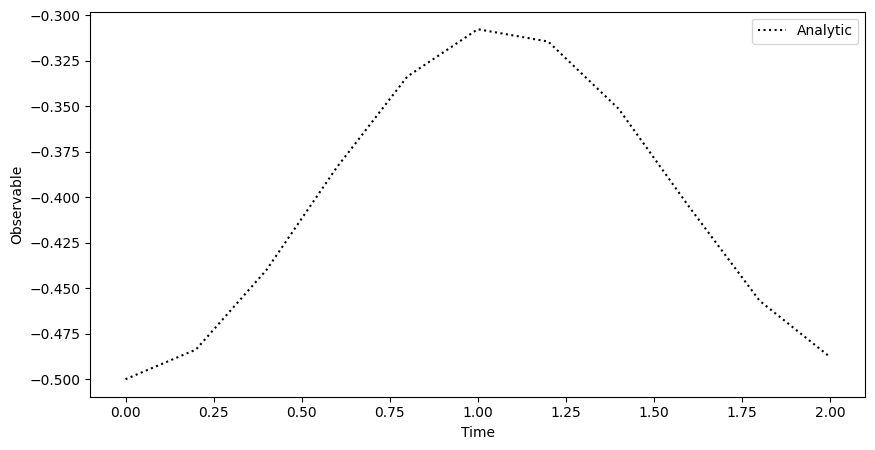

In [20]:
plt.figure(figsize=(10,5))
plt.plot(time_step_list_exact, hs_cc_n4_g1_sampling, 'k:',label='Analytic')
plt.xlabel('Time')
plt.ylabel('Observable')
plt.legend()
#plt.title('Gate-based time evolution of $\{N_s,M,p\}$={'+str(Ns)+','+str(M)+','+str(p)+'}, $\{\Delta,\omega,g\}$={'+str(delta)+', '+str(omega)+', '+str(g)+'}' )
plt.show()

## Test (plain matrix): HS saddle point

### HS minimization

In [21]:
def neg_f(y):
  return np.sum(y**2) - initial_state.expectation_value(Ldyn_Pauli_HS(N, y, dt, a, g)) * dt

init_y = np.zeros(N-1)

result = minimize(neg_f, init_y, args=(), method='Powell', options={'maxiter': 500, 'disp': True})
opt_y = result.x

Optimization terminated successfully.
         Current function value: 0.000000+0.000000j
         Iterations: 1
         Function evaluations: 36


In [22]:
opt_y

array([0., 0., 0., 0., 0.])

In [23]:
opt_y = np.zeros(6)

### HS saddle point solution

In [24]:
hs_cc_n4_g1_saddle = []

Local_Ham = Ham_Schwinger_Pauli_HS(N, opt_y, dt, m, a, g)
H_array = Local_Ham.to_matrix()
u_array = np.exp(1.0j * np.pi / 4) * sp.linalg.expm(-1j * dt * H_array)

hs_evolution_t = initial_state
hs_cc_n4_g1_saddle.append(np.real(hs_evolution_t.expectation_value(observable_cc)))

for t in time_step_list_exact[1:]:

    hs_evolution_t = hs_evolution_t.evolve(u_array)
    hs_evolution_t = hs_evolution_t/np.sqrt(hs_evolution_t.trace())
    hs_cc_n4_g1_saddle.append(np.real(hs_evolution_t.expectation_value(observable_cc)))

In [25]:
hs_cc_n4_g1_saddle

[np.float64(-0.49999999999999994),
 np.float64(-0.4836967271147524),
 np.float64(-0.4389935705235695),
 np.float64(-0.37740486251447225),
 np.float64(-0.3147306949942181),
 np.float64(-0.2669241921449378),
 np.float64(-0.24594640546796287),
 np.float64(-0.25670447303903426),
 np.float64(-0.2958721828218613),
 np.float64(-0.3528836003275402),
 np.float64(-0.41280867199638255)]

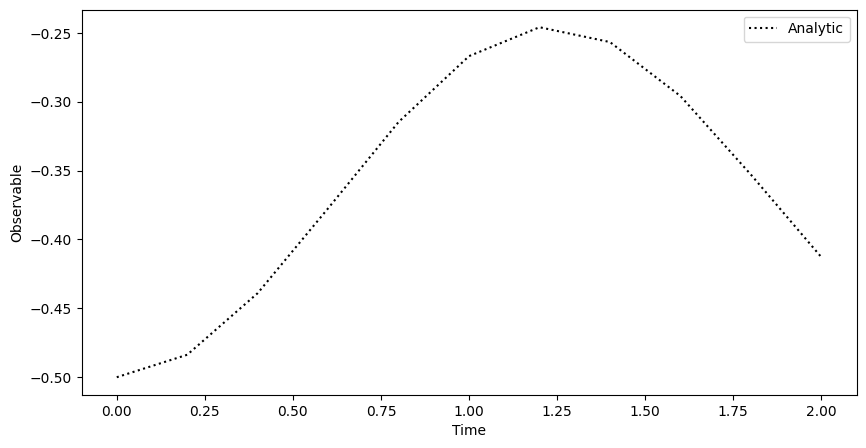

In [26]:
plt.figure(figsize=(10,5))
plt.plot(time_step_list_exact, hs_cc_n4_g1_saddle, 'k:',label='Analytic')
plt.xlabel('Time')
plt.ylabel('Observable')
plt.legend()
#plt.title('Gate-based time evolution of $\{N_s,M,p\}$={'+str(Ns)+','+str(M)+','+str(p)+'}, $\{\Delta,\omega,g\}$={'+str(delta)+', '+str(omega)+', '+str(g)+'}' )
plt.show()

## Test (qiskit sampler): global settings

## Test (qiskit sampler): raw Hamiltonian

In [27]:
shots = 8192

circuit = QuantumCircuit(N, N)
# prepare the initial state '0101...'
for i in range(int(N/2)):
    circuit.x([2*i])

# prepare the initial state '1010...'
# for i in range(int(N/2)):
#     circuit.x([2*i+1])

# Simulation (Naive)

virtual_pub_list = []
virtual_pub_list_elec_field = []
pub_list = []
pub_list_elec_field = []
tcirc_depth_orig = []

Local_Ham = Ham_Schwinger_Pauli(N, 0, 0, m, a, g).simplify()

# Schrodinger picture
evo_gate = PauliEvolutionGate(Local_Ham, dt, synthesis=SuzukiTrotter(order=1, reps=1))

for t in time_step_list_exact:

    # For doing a simulation using Aer_Sim
    virtual_pub_list.append([circuit.decompose().decompose(), observable_cc])
    #virtual_pub_list_elec_field.append((circuit.decompose().decompose(), observable_elec_field))

    # For actual hardware
    pm_circuit = pm.run(circuit)
    pm_corr = observable_cc.apply_layout(pm_circuit.layout)
    #pm_elec_field = observable_elec_field.apply_layout(pm_circuit.layout)
    pub_list.append((pm_circuit, pm_corr))
    #pub_list_elec_field.append((pm_circuit, pm_elec_field))

    # number of ecr gates
    tcirc_depth_orig.append(pm_circuit.depth(lambda x: x[0].name=="ecr"))

    circuit.append(evo_gate.definition, list(range(N)))

In [28]:
tcirc_depth_orig

[0, 40, 84, 136, 183, 237, 284, 327, 381, 424, 471]

In [29]:
sim_job = aer_estimator.run(pubs=virtual_pub_list, precision=1/np.sqrt(shots))
#sim_job_elec_field = sim_estimator.run(pubs=virtual_pub_list_elec_field, precision=1/np.sqrt(shots))

sim_result = sim_job.result()
#sim_result_elec_field = sim_job_elec_field.result()

sim_raw_cc_n10_g1 = [sim_result[i].data.evs for i in range(len(sim_result))]
#sim_values_elec_field = [sim_result_elec_field[i].data.evs for i in range(len(sim_result_elec_field))]

In [30]:
job_cc = estimator.run(pub_list, precision=1/np.sqrt(shots))

result_cc = job_cc.result()

rensselaer_raw_cc_n10_g1 = [result_cc[i].data.evs for i in range(len(pub_list))]

In [31]:
rensselaer_raw_cc_n10_g1

[array(-0.5034733),
 array(-0.12613452),
 array(-0.02067301),
 array(0.00636497),
 array(-0.00323362),
 array(0.00069149),
 array(0.00514121),
 array(-0.00144309),
 array(0.00975889),
 array(0.0012873),
 array(0.00299231)]

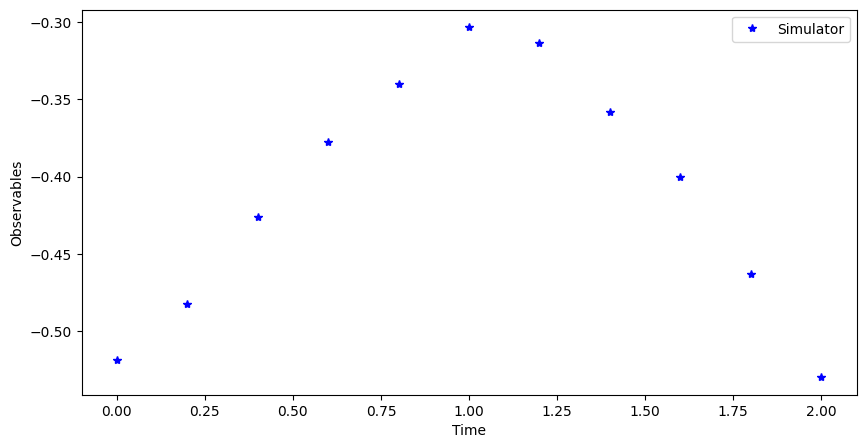

In [32]:
plt.figure(figsize=(10,5))
plt.plot(time_step_list_exact, sim_raw_cc_n10_g1, 'b*',label='Simulator')
# plt.plot(time_step_list, sim_values_elec_field, 'r+',label='Simulator')
plt.xlabel('Time')
plt.ylabel('Observables')
# plt.ylabel('Electric field')
plt.legend()
#plt.title('Gate-based time evolution of $\{N_s,M,p\}$={'+str(Ns)+','+str(M)+','+str(p)+'}, $\{\Delta,\omega,g\}$={'+str(delta)+', '+str(omega)+', '+str(g)+'}' )
plt.show()

## Test (qiskit sampler): HS Gaussian sampling (BAD)

In [33]:
Local_Ham_xi = Ham_Schwinger_Pauli_HS(N, [0.1,0.2,0.3], 0 * (-1j), m, a, g)

Local_Ham_xi
#SparsePauliOp.from_operator(PauliEvolutionGate(Local_Ham_xi, dt, synthesis=SuzukiTrotter(order=1, reps=1))).simplify()

SparsePauliOp(['XXIIII', 'YYIIII', 'IIXXII', 'IIYYII', 'IIIIXX', 'IIIIYY', 'IXXIII', 'IYYIII', 'IIIXXI', 'IIIYYI', 'ZIIIII', 'IZIIII', 'IIZIII', 'IIIZII', 'IIIIZI', 'IIIIIZ', 'IIIIII'],
              coeffs=[ 0.25+0.j,  0.25+0.j,  0.25+0.j,  0.25+0.j,  0.25+0.j,  0.25+0.j,
  0.25+0.j,  0.25+0.j,  0.25+0.j,  0.25+0.j, -0.5 +0.j,  0.5 +0.j,
 -0.5 +0.j,  0.5 +0.j, -0.5 +0.j,  0.5 +0.j,  0.  +0.j])

In [34]:
SparsePauliOp.from_operator(RXXGate(2*(1/(4*a))*dt).to_matrix())

SparsePauliOp(['II', 'XX'],
              coeffs=[0.99875026+0.j        , 0.        -0.04997917j])

In [35]:
SparsePauliOp(['IIII', 'XXII'],coeffs=[cos((1/(4*a))*dt),-(sin((1/(4*a))*dt))*1.0j]) @ SparsePauliOp(['IIII', 'IIXX'],coeffs=[cos((1/(4*a))*dt),-(sin((1/(4*a))*dt))*1.0j])

SparsePauliOp(['IIII', 'IIXX', 'XXII', 'XXXX'],
              coeffs=[ 0.99750208+0.j        ,  0.        -0.04991671j,  0.        -0.04991671j,
 -0.00249792-0.j        ])

In [36]:
SparsePauliOp.from_operator(RZGate(2*(m/2)*dt).to_matrix())

SparsePauliOp(['I', 'Z'],
              coeffs=[0.99500417+0.j        , 0.        -0.09983342j])

In [37]:
SparsePauliOp(['IIII', 'ZIII'],coeffs=[cos((m/2)*dt),-(sin((m/2)*dt))*1.0j]) @ SparsePauliOp(['IIII', 'IZII'],coeffs=[cos((m/2)*dt),-(sin((m/2)*dt))*1.0j])

SparsePauliOp(['IIII', 'IZII', 'ZIII', 'ZZII'],
              coeffs=[ 0.99003329+0.j        ,  0.        -0.09933467j,  0.        -0.09933467j,
 -0.00996671-0.j        ])

In [38]:
PauliEvolutionGate(Local_Ham_xi, dt, synthesis=SuzukiTrotter(order=1, reps=1)).definition.draw()

┌───────────┐┌───────────┐ ┌─────────┐                          
q_0: ┤0          ├┤0          ├─┤ Rz(0.2) ├──────────────────────────
     │  Rxx(0.1) ││  Ryy(0.1) │┌┴─────────┴┐┌───────────┐┌──────────┐
q_1: ┤1          ├┤1          ├┤0          ├┤0          ├┤ Rz(-0.2) ├
     ├───────────┤├───────────┤│  Rxx(0.1) ││  Ryy(0.1) │├─────────┬┘
q_2: ┤0          ├┤0          ├┤1          ├┤1          ├┤ Rz(0.2) ├─
     │  Rxx(0.1) ││  Ryy(0.1) │├───────────┤├───────────┤├─────────┴┐
q_3: ┤1          ├┤1          ├┤0          ├┤0          ├┤ Rz(-0.2) ├
     ├───────────┤├───────────┤│  Rxx(0.1) ││  Ryy(0.1) │├─────────┬┘
q_4: ┤0          ├┤0          ├┤1          ├┤1          ├┤ Rz(0.2) ├─
     │  Rxx(0.1) ││  Ryy(0.1) │└┬──────────┤└───────────┘└─────────┘ 
q_5: ┤1          ├┤1          ├─┤ Rz(-0.2) ├─────────────────────────
     └───────────┘└───────────┘ └──────────┘

In [39]:
# Simulation (HS transform)

xList = xList[0:16]

virtual_pub_list = []
virtual_pub_list_elec_field = []
pub_list = []
pub_list_elec_field = []
tcirc_depth = []

for ti in range(len(time_step_list_exact)):
    for xi in range(len(xList)):
        for xj in range(xi,len(xList)):

          Local_Ham_xi = Ham_Schwinger_Pauli_HS(N, xList[xi], time_step_list_exact[ti] * (-1j), m, a, g)
          Local_Ham_xj = Ham_Schwinger_Pauli_HS(N, xList[xj], time_step_list_exact[ti] * (-1j), m, a, g)

          observable_cc_heisenberg = observable_cc

          # Heisenberg picture
          evo_op_forward = SparsePauliOp.from_operator(PauliEvolutionGate(Local_Ham_xi, dt, synthesis=SuzukiTrotter(order=2, reps=1))).simplify()
          evo_op_backward = SparsePauliOp.from_operator(PauliEvolutionGate(Local_Ham_xj, -dt, synthesis=SuzukiTrotter(order=2, reps=1))).simplify()

          for tii in range(ti):
              observable_cc_heisenberg = (evo_op_backward @ observable_cc_heisenberg @ evo_op_forward).simplify().chop(1e-8)

          observable_cc_heisenberg_re = SparsePauliOp(observable_cc_heisenberg.paulis,observable_cc_heisenberg.coeffs.real)
          observable_cc_heisenberg_im = SparsePauliOp(observable_cc_heisenberg.paulis,observable_cc_heisenberg.coeffs.imag)

          virtual_pub_list.append([circuit.decompose().decompose(), observable_cc_heisenberg_re])
          virtual_pub_list.append([circuit.decompose().decompose(), observable_cc_heisenberg_im])

ValueError: Operator contains complex coefficients, which are not supported.

## Test (qiskit sampler): HS saddle point

In [57]:
shots = 8192

circuit = QuantumCircuit(N, N)
# prepare the initial state '0101...'
for i in range(int(N/2)):
    circuit.x([2*i])

# prepare the initial state '1010...'
# for i in range(int(N/2)):
#     circuit.x([2*i+1])

# Simulation (Naive)

virtual_pub_list = []
virtual_pub_list_elec_field = []
pub_list = []
pub_list_elec_field = []
tcirc_depth_hs = []

Local_Ham = Ham_Schwinger_Pauli_HS(N, opt_y, dt, m, a, g).simplify()

# Schrodinger picture
evo_gate = PauliEvolutionGate(Local_Ham, dt, synthesis=SuzukiTrotter(order=2, reps=2))

for t in time_step_list_exact:

    # For doing a simulation using Aer_Sim
    virtual_pub_list.append([circuit.decompose().decompose(), observable_cc])
    #virtual_pub_list_elec_field.append((circuit.decompose().decompose(), observable_elec_field))

    # For actual hardware
    pm_circuit = pm.run(circuit)
    pm_corr = observable_cc.apply_layout(pm_circuit.layout)
    #pm_elec_field = observable_elec_field.apply_layout(pm_circuit.layout)
    pub_list.append((pm_circuit, pm_corr))
    #pub_list_elec_field.append((pm_circuit, pm_elec_field))

    # number of 2-qubit gates
    tcirc_depth_hs.append(pm_circuit.depth(lambda x: x[0].name=="cz" or x[0].name=="ecr"))

    circuit.append(evo_gate.definition, list(range(N)))

In [58]:
tcirc_depth_hs

[0, 10, 18, 26, 34, 42, 50, 58, 66, 74, 82]

In [45]:
pub_list[1][0].draw()

global phase: π/2
          ┌─────────────┐┌────┐ ┌──────┐ ┌────────┐    ┌────┐    ┌────────────┐»
q_5 -> 32 ┤ Rz(-2.3378) ├┤ √X ├─┤1     ├─┤ Rz(-π) ├────┤ √X ├────┤ Rz(3.0416) ├»
          └┬────────────┤├────┤ │  Ecr │ └─┬────┬─┘┌───┴────┴───┐└───┬────┬───┘»
q_4 -> 36 ─┤ Rz(2.3378) ├┤ √X ├─┤0     ├───┤ √X ├──┤ Rz(3.0416) ├────┤ √X ├────»
          ┌┴────────────┤├────┤┌┴──────┴┐  └────┘  └──┬──────┬──┘  ┌─┴────┴─┐  »
q_1 -> 49 ┤ Rz(-2.9483) ├┤ √X ├┤ Rz(-π) ├─────────────┤1     ├─────┤ Rz(-π) ├──»
          └┬────────────┤├────┤└┬──────┬┘┌────────┐   │      │     └─┬────┬─┘  »
q_2 -> 50 ─┤ Rz(3.0466) ├┤ √X ├─┤1     ├─┤ Rz(-π) ├───┤      ├───────┤ √X ├────»
          ┌┴────────────┤├────┤ │  Ecr │ └─┬────┬─┘   │  Ecr │   ┌───┴────┴───┐»
q_3 -> 51 ┤ Rz(-3.0466) ├┤ √X ├─┤0     ├───┤ √X ├─────┤      ├───┤ Rz(3.0416) ├»
          └┬────────────┤├────┤┌┴──────┴┐  └────┘     │      │   └───┬────┬───┘»
q_0 -> 55 ─┤ Rz(2.9483) ├┤ √X ├┤ Rz(-π) ├─────────────┤0     ├───────┤ √X ├────»
           └────────────┘└────┘└────────┘             └──────┘       └────┘    »
«              ┌────┐       ┌──────┐   ┌────────┐    ┌────┐    ┌─────────────┐»
«q_5 -> 32 ────┤ √X ├───────┤1     ├───┤ Rz(-π) ├────┤ √X ├────┤ Rz(-1.0038) ├»
«            ┌─┴────┴─┐     │  Ecr │   └─┬────┬─┘┌───┴────┴───┐└────┬────┬───┘»
«q_4 -> 36 ──┤ Rz(-π) ├─────┤0     ├─────┤ √X ├──┤ Rz(2.3378) ├─────┤ √X ├────»
«            └─┬────┬─┘  ┌──┴──────┴──┐  ├────┤  └────────────┘    ┌┴────┴┐   »
«q_1 -> 49 ────┤ √X ├────┤ Rz(3.0416) ├──┤ √X ├────────────────────┤1     ├───»
«          ┌───┴────┴───┐└───┬────┬───┘ ┌┴────┴┐     ┌────┐        │      │   »
«q_2 -> 50 ┤ Rz(3.0416) ├────┤ √X ├─────┤1     ├─────┤ √X ├────────┤      ├───»
«          └───┬────┬───┘  ┌─┴────┴─┐   │  Ecr │     ├────┤        │  Ecr │   »
«q_3 -> 51 ────┤ √X ├──────┤ Rz(-π) ├───┤0     ├─────┤ √X ├────────┤      ├───»
«          ┌───┴────┴───┐  └─┬────┬─┘  ┌┴──────┴┐    └────┘        │      │   »
«q_0 -> 55 ┤ Rz(3.0416) ├────┤ √X ├────┤ Rz(-π) ├──────────────────┤0     ├───»
«          └────────────┘    └────┘    └────────┘                  └──────┘   »
«                                                                        »
«q_5 -> 32 ──────────────────────────────────────────────────────────────»
«                                                      ┌──────┐  ┌────┐  »
«q_4 -> 36 ────────────────────────────────────────────┤0     ├──┤ √X ├──»
«               ┌────┐    ┌────────────┐     ┌────┐    │      │ ┌┴────┴┐ »
«q_1 -> 49 ─────┤ √X ├────┤ Rz(2.9483) ├─────┤ √X ├────┤      ├─┤0     ├─»
«           ┌───┴────┴───┐└───┬────┬───┘   ┌─┴────┴─┐  │  Ecr │ │  Ecr │ »
«q_2 -> 50 ─┤ Rz(3.0466) ├────┤ √X ├───────┤ Rz(-π) ├──┤      ├─┤1     ├─»
«          ┌┴────────────┤    ├────┤       └────────┘  │      │┌┴──────┴┐»
«q_3 -> 51 ┤ Rz(-3.0466) ├────┤ √X ├───────────────────┤1     ├┤ Rz(-π) ├»
«          └──┬────────┬─┘    ├────┤    ┌─────────────┐└──────┘└────────┘»
«q_0 -> 55 ───┤ Rz(-π) ├──────┤ √X ├────┤ Rz(-3.1348) ├──────────────────»
«             └────────┘      └────┘    └─────────────┘                  »
«                                                                      »
«q_5 -> 32 ────────────────────────────────────────────────────────────»
«          ┌────────────┐    ┌────┐      ┌────────┐  ┌──────┐┌────────┐»
«q_4 -> 36 ┤ Rz(3.0416) ├────┤ √X ├──────┤ Rz(-π) ├──┤0     ├┤ Rz(-π) ├»
«          └───┬────┬───┘┌───┴────┴───┐  └─┬────┬─┘  │      │├────────┤»
«q_1 -> 49 ────┤ √X ├────┤ Rz(3.0416) ├────┤ √X ├────┤      ├┤ Rz(-π) ├»
«            ┌─┴────┴─┐  └───┬────┬───┘┌───┴────┴───┐│  Ecr │└─┬────┬─┘»
«q_2 -> 50 ──┤ Rz(-π) ├──────┤ √X ├────┤ Rz(3.0416) ├┤      ├──┤ √X ├──»
«            └─┬────┬─┘  ┌───┴────┴───┐└───┬────┬───┘│      │  ├────┤  »
«q_3 -> 51 ────┤ √X ├────┤ Rz(3.0416) ├────┤ √X ├────┤1     ├──┤ √X ├──»
«              └────┘    └────────────┘    └────┘    └──────┘  └────┘  »
«q_0 -> 55 ────────────────────────────────────────────────────────────»
«                                     

In [59]:
sim_job = aer_estimator.run(pubs=virtual_pub_list, precision=1/np.sqrt(shots))
#sim_job_elec_field = sim_estimator.run(pubs=virtual_pub_list_elec_field, precision=1/np.sqrt(shots))

sim_result = sim_job.result()
#sim_result_elec_field = sim_job_elec_field.result()

sim_hs_saddle_cc_n10_g1 = [sim_result[i].data.evs for i in range(len(sim_result))]
#sim_values_elec_field = [sim_result_elec_field[i].data.evs for i in range(len(sim_result_elec_field))]

In [60]:
job_cc = estimator.run(pub_list, precision=1/np.sqrt(shots))

result_cc = job_cc.result()

fez_hs_saddle_cc_n10_g1 = [result_cc[i].data.evs for i in range(len(pub_list))]

In [48]:
fez_hs_saddle_cc_n10_g1

[array(-0.50384862),
 array(-0.40972454),
 array(-0.40287277),
 array(-0.28076469),
 array(-0.16546201),
 array(-0.08091765),
 array(-0.05986049),
 array(-0.08266873),
 array(-0.11170688),
 array(-0.14397108),
 array(-0.1681759)]

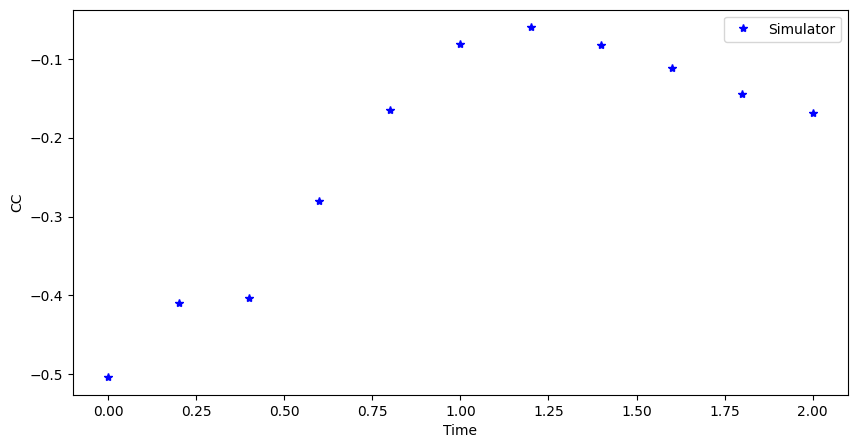

In [49]:
plt.figure(figsize=(10,5))
plt.plot(time_step_list_exact, fez_hs_saddle_cc_n10_g1, 'b*',label='Simulator')
# plt.plot(time_step_list, sim_values_elec_field, 'r+',label='Simulator')
plt.xlabel('Time')
plt.ylabel('CC')
# plt.ylabel('Electric field')
plt.legend()
#plt.title('Gate-based time evolution of $\{N_s,M,p\}$={'+str(Ns)+','+str(M)+','+str(p)+'}, $\{\Delta,\omega,g\}$={'+str(delta)+', '+str(omega)+', '+str(g)+'}' )
plt.show()

## Test (qiskit sampler): Comparison

Text(0.5, 1.0, 'Number of ECRs in circuit')

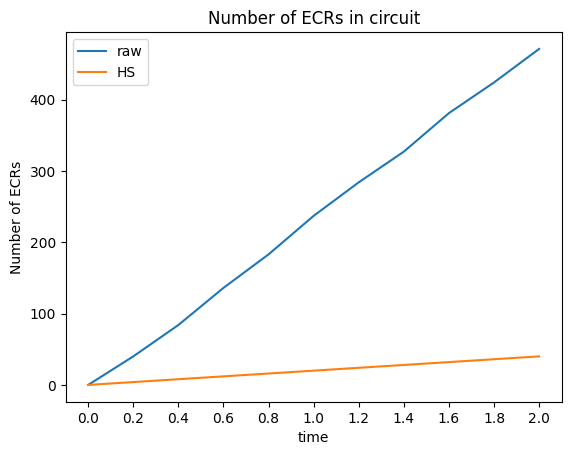

In [50]:
plt.plot(time_step_list_exact, tcirc_depth_orig, label='raw')
plt.plot(time_step_list_exact, tcirc_depth_hs, label='HS')
plt.xticks(time_step_list_exact)
plt.xlabel(r'time')
#plt.yscale('log',base=2)
plt.ylabel('Number of ECRs')
plt.legend()
plt.title(r'Number of ECRs in circuit')

Text(0.5, 1.0, 'Number of ECRs in circuit')

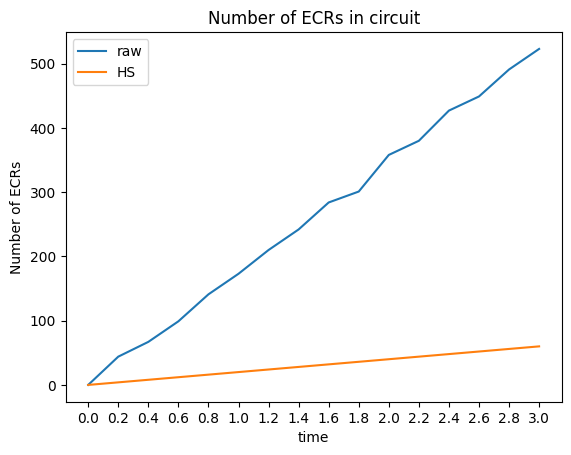

In [ ]:
plt.plot(time_step_list_exact, [0, 44, 67, 99, 141, 173, 210, 242, 284, 301, 358, 380, 427, 449, 491, 523], label='raw')
plt.plot(time_step_list_exact, [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60], label='HS')
plt.xticks(time_step_list_exact)
plt.xlabel(r'time')
#plt.yscale('log',base=2)
plt.ylabel('Number of ECRs')
plt.legend()
plt.title(r'Number of ECRs in circuit')


In [53]:
time_step_list_exact
sim_raw_cc_n10_g1

[array(-0.51830042),
 array(-0.4821606),
 array(-0.42621882),
 array(-0.37762971),
 array(-0.34019224),
 array(-0.30342182),
 array(-0.3137544),
 array(-0.3585022),
 array(-0.40018338),
 array(-0.46318931),
 array(-0.52958449)]

Text(0.5, 1.0, 'Schwinger Model (N=6, initial="101010")')

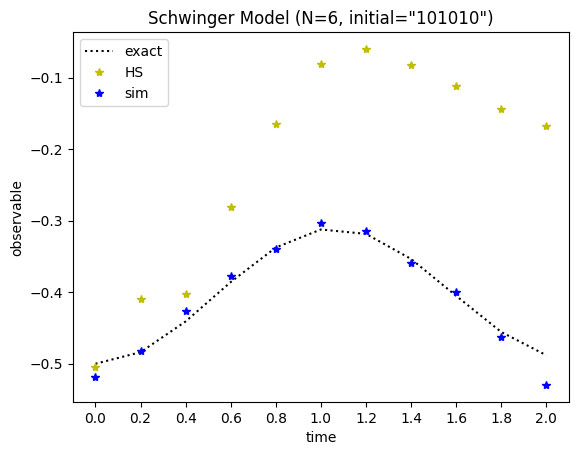

In [55]:
# t_start = 0
# t_max = 3
# dt = 0.5
# time_step_list_exact = np.linspace(t_start, t_max, (int((t_max - t_start)/dt))+1)

t_start = 0
t_max = 3
# dt = 0.2
dt = 0.5


t_start = 0
t_max = 2
dt = 0.2

time_step_list_exact = np.linspace(t_start, t_max, (int((t_max - t_start)/dt))+1)

rensselaer_raw_cc_n10_g1 = sim_raw_cc_n10_g1
rensselaer_hs_saddle_cc_n10_g1 = fez_hs_saddle_cc_n10_g1

plt.plot(time_step_list_exact, exact_cc_n4_g1, 'k:',label='exact')
plt.plot(time_step_list_exact, rensselaer_hs_saddle_cc_n10_g1, 'y*', label='HS')
plt.plot(time_step_list_exact, rensselaer_raw_cc_n10_g1, 'b*',label='sim')
plt.xticks(time_step_list_exact)
plt.xlabel(r'time')
#plt.yscale('log',base=2)
plt.ylabel(r'observable')
plt.legend()
plt.title(r'Schwinger Model (N=6, initial="101010")')

Text(0.5, 1.0, 'Schwinger Model (N=6, initial="101010")')

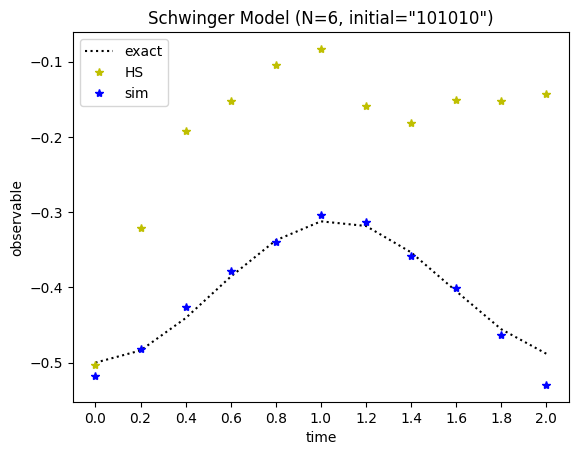

In [61]:
# t_start = 0
# t_max = 3
# dt = 0.5
# time_step_list_exact = np.linspace(t_start, t_max, (int((t_max - t_start)/dt))+1)

t_start = 0
t_max = 3
# dt = 0.2
dt = 0.5


t_start = 0
t_max = 2
dt = 0.2

time_step_list_exact = np.linspace(t_start, t_max, (int((t_max - t_start)/dt))+1)

rensselaer_raw_cc_n10_g1 = sim_raw_cc_n10_g1
rensselaer_hs_saddle_cc_n10_g1 = fez_hs_saddle_cc_n10_g1

plt.plot(time_step_list_exact, exact_cc_n4_g1, 'k:',label='exact')
plt.plot(time_step_list_exact, rensselaer_hs_saddle_cc_n10_g1, 'y*', label='HS')
plt.plot(time_step_list_exact, rensselaer_raw_cc_n10_g1, 'b*',label='sim')
plt.xticks(time_step_list_exact)
plt.xlabel(r'time')
#plt.yscale('log',base=2)
plt.ylabel(r'observable')
plt.legend()
plt.title(r'Schwinger Model (N=6, initial="101010")')

Text(0.5, 1.0, 'Schwinger Model (N=6, initial="101010")')

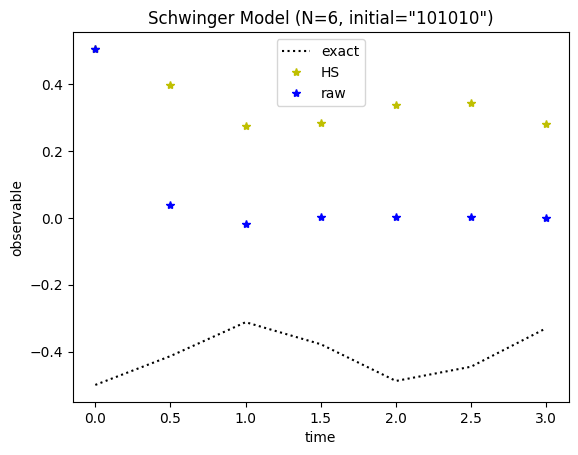

In [105]:
t_start = 0
t_max = 3
dt = 0.5
time_step_list_exact = np.linspace(t_start, t_max, (int((t_max - t_start)/dt))+1)

rensselaer_raw_cc_n10_g1=[(0.50545202),(0.03858509),(-0.0181481),(0.00333773),(0.00114955),(0.00330087),(-0.00170072)]

rensselaer_hs_saddle_cc_n10_g1=[(0.50501779),(0.39662385),(0.27513033),(0.28349256),(0.33653601),(0.34466838),(0.28161649)]

plt.plot(time_step_list_exact, exact_cc_n4_g1, 'k:',label='exact')
plt.plot(time_step_list_exact, rensselaer_hs_saddle_cc_n10_g1, 'y*', label='HS')
plt.plot(time_step_list_exact, rensselaer_raw_cc_n10_g1, 'b*',label='raw')
plt.xticks(time_step_list_exact)
plt.xlabel(r'time')
#plt.yscale('log',base=2)
plt.ylabel(r'observable')
plt.legend()
plt.title(r'Schwinger Model (N=6, initial="101010")')

In [99]:
rensselaer_raw_cc_n10_g1

[0.50545202,
 0.03858509,
 -0.0181481,
 0.00333773,
 0.00114955,
 0.00330087,
 -0.00170072]

In [101]:
time_step_list_exact

array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. ])

In [102]:
exact_cc_n4_g1

array([-0.5       , -0.48381917, -0.4408341 , -0.38578654, -0.33748285,
       -0.31227647, -0.31845023, -0.35347632, -0.40507593, -0.45560986,
       -0.48816268])

Text(0.5, 1.0, 'Schwinger Model (N=6, initial="010101")')

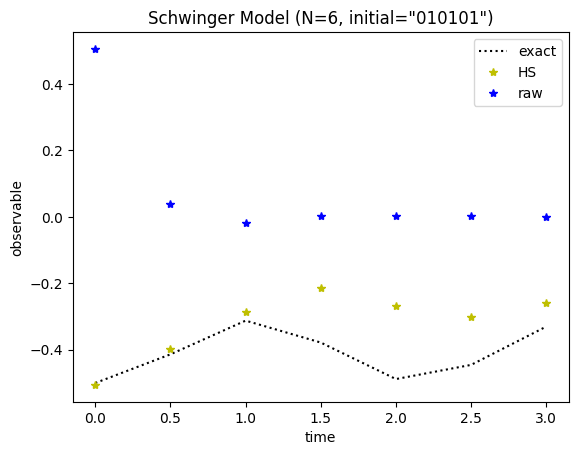

In [106]:
#rensselaer_raw_cc_n10_g1=[(-0.50685319),(0.03256135),(0.0155295),(-0.00425024),(0.01146767),(-0.00249208),(-0.00052641)]

rensselaer_hs_saddle_cc_n10_g1=[(-0.50578921),(-0.39831606),(-0.2860411),(-0.2146374),(-0.2669163),(-0.30206657),(-0.25869298)]

plt.plot(time_step_list_exact, exact_cc_n4_g1, 'k:',label='exact')
plt.plot(time_step_list_exact, rensselaer_hs_saddle_cc_n10_g1, 'y*', label='HS')
plt.plot(time_step_list_exact, rensselaer_raw_cc_n10_g1, 'b*',label='raw')
plt.xticks(time_step_list_exact)
plt.xlabel(r'time')
#plt.yscale('log',base=2)
plt.ylabel(r'observable')
plt.legend()
plt.title(r'Schwinger Model (N=6, initial="010101")')

Text(0.5, 1.0, 'Schwinger Model (N=8, initial="10101010")')

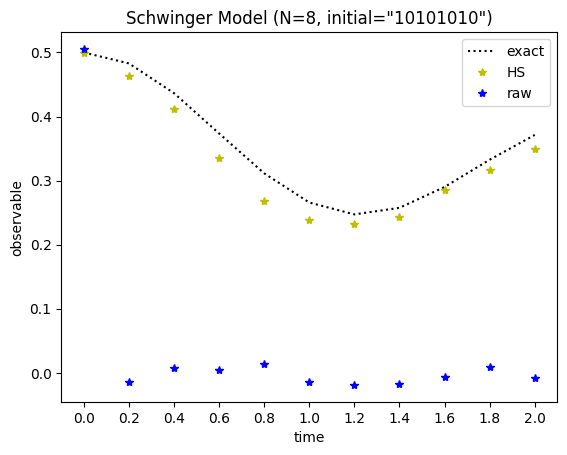

In [ ]:
t_start = 0
t_max = 2
dt = 0.2

time_step_list_exact = np.linspace(t_start, t_max, (int((t_max - t_start)/dt))+1)

rensselaer_raw_cc_n10_g1=[(0.50552064),(-0.01476078),(0.00808158),(0.00441811),(0.01458588),(-0.01465252),(-0.01881986),(-0.01774234),(-0.00707586),(0.00952905),(-0.00868233)]

rensselaer_hs_saddle_cc_n10_g1=[(0.49891199),(0.46602822),(0.42202259),(0.35921337),(0.31069824),(0.2756508),(0.25865238),(0.24929623),(0.25563066),(0.27053576),(0.27709279)]

fez_hs_saddle_cc_n10_g1=[(0.49931812),(0.46401396),(0.41100259),(0.33574614),(0.26880861),(0.23884393),(0.23215752),(0.24381889),(0.28467207),(0.31673348),(0.3501107)]

plt.plot(time_step_list_exact, exact_cc_n4_g1, 'k:',label='exact')
plt.plot(time_step_list_exact, fez_hs_saddle_cc_n10_g1, 'y*', label='HS')
plt.plot(time_step_list_exact, rensselaer_raw_cc_n10_g1, 'b*',label='raw')
plt.xticks(time_step_list_exact)
plt.xlabel(r'time')
#plt.yscale('log',base=2)
plt.ylabel(r'observable')
plt.legend()
plt.title(r'Schwinger Model (N=8, initial="10101010")')

In [ ]:
t_start = 0
t_max = 2
dt = 0.2

time_step_list_exact = np.linspace(t_start, t_max, (int((t_max - t_start)/dt))+1)

rensselaer_raw_cc_n10_g1=[(-0.50552064),(-0.01476078),(0.00808158),(0.00441811),(0.01458588),(-0.01465252),(-0.01881986),(-0.01774234),(-0.00707586),(0.00952905),(-0.00868233)]

rensselaer_hs_saddle_cc_n10_g1=[(-0.49943823),(-0.46446012),(-0.42736156),(-0.38948427),(-0.33043644),(-0.27390822),(-0.24141677),(-0.21927038),(-0.21370953),(-0.21951621),(-0.23061216)]

fez_hs_saddle_cc_n10_g1=[(-0.48796953),(-0.47872387),(-0.4170336),(-0.34502182),(-0.27501815),(-0.21488977),(-0.19670347),(-0.20346687),(-0.22938061),(-0.26417684),(-0.30708156)]

plt.plot(time_step_list_exact, exact_cc_n4_g1, 'k:',label='exact')
plt.plot(time_step_list_exact, fez_hs_saddle_cc_n10_g1, 'y*', label='HS')
plt.plot(time_step_list_exact, rensselaer_raw_cc_n10_g1, 'b*',label='raw')
plt.xticks(time_step_list_exact)
plt.xlabel(r'time')
#plt.yscale('log',base=2)
plt.ylabel(r'observable')
plt.legend()
plt.title(r'Schwinger Model (N=8, initial="01010101")')

NameError: name 'exact_cc_n4_g1' is not defined

Text(0.5, 1.0, 'Schwinger Model (N=18, initial="0101...")')

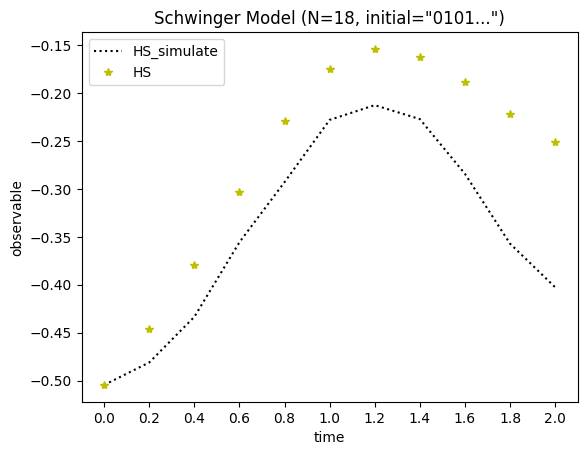

In [ ]:
t_start = 0
t_max = 2
dt = 0.2

time_step_list_exact = np.linspace(t_start, t_max, (int((t_max - t_start)/dt))+1)

fez_hs_saddle_cc_n10_g1=[(-0.50441641),(-0.44608028),(-0.37943751),(-0.30296454),(-0.22936764),(-0.17486698),(-0.15392394),(-0.16267048),(-0.18815131),(-0.22194795),(-0.2515367)]

plt.plot(time_step_list_exact, sim_hs_saddle_cc_n10_g1, 'k:', label='HS_simulate')
plt.plot(time_step_list_exact, fez_hs_saddle_cc_n10_g1, 'y*', label='HS')
plt.xticks(time_step_list_exact)
plt.xlabel(r'time')
#plt.yscale('log',base=2)
plt.ylabel(r'observable')
plt.legend()
plt.title(r'Schwinger Model (N=18, initial="0101...")')

Text(0.5, 1.0, 'Schwinger Model (N=128, initial="0101...")')

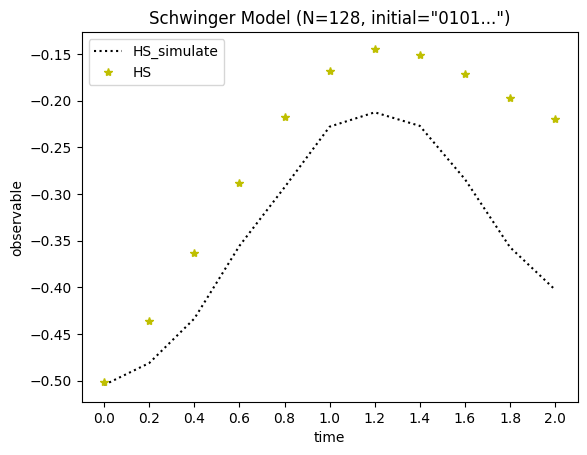

In [ ]:
t_start = 0
t_max = 2
dt = 0.2

time_step_list_exact = np.linspace(t_start, t_max, (int((t_max - t_start)/dt))+1)

fez_hs_saddle_cc_n10_g1=[(-0.50112171),(-0.43552117),(-0.36322099),(-0.28851465),(-0.21723296),(-0.16800886),(-0.14472176),(-0.15124874),(-0.17140515),(-0.19768902),(-0.21965724)]


plt.plot(time_step_list_exact, sim_hs_saddle_cc_n10_g1, 'k:', label='HS_simulate')
plt.plot(time_step_list_exact, fez_hs_saddle_cc_n10_g1, 'y*', label='HS')
plt.xticks(time_step_list_exact)
plt.xlabel(r'time')
#plt.yscale('log',base=2)
plt.ylabel(r'observable')
plt.legend()
plt.title(r'Schwinger Model (N=128, initial="0101...")')